# Notebook 04 — Dynamic Regression and SARIMAX

## Fintech Liquidity Forecasting and Reserve Optimization

### Objective

This notebook evaluates whether dynamic regression and SARIMAX models can
improve daily cash-outflow forecasts by incorporating valid exogenous
information while preserving the temporal dependence of the residuals.

The main goals are to:

1. Classify each exogenous variable according to its availability at the
   forecast origin.
2. Model calendar, operational and scenario-based effects without temporal
   leakage.
3. Combine regression effects with ARIMA or seasonal ARIMA error structures.
4. Evaluate all candidate models using the same 20 expanding-window folds
   and 28-day forecast horizon used in Notebook 03.
5. Compare the results against the historical weekday average benchmark
   and the selected ETS model.
6. Diagnose residual autocorrelation, bias and performance during operational
   events.

### Methodological constraints

- The target is `total_cash_outflow`, expressed in ARS millions.
- Forecast horizon: 28 days.
- Backtesting: 20 expanding-window folds with a 28-day step.
- Future observed values cannot be used as exogenous inputs unless they are
  genuinely known at the forecast origin.
- Model selection will be based primarily on out-of-sample performance.
- AIC, AICc and BIC will be used only as supporting diagnostics.
- All generated tables will be saved under `data/processed/`.
- All useful figures will be saved under `figures/`.
- All output filenames created in this notebook will use the `04_` prefix.

### Validated starting point

The selected ETS model is `ets_log_damped_additive`. It improves approximately
5.17% in MAE and 5.70% in RMSE over the best benchmark,
`historical_weekday_average`, but systematically underestimates payday windows,
promotions, merchant settlements and macroeconomic shocks because it does not
use exogenous variables.

In [7]:
# ============================================================================
# 1. Imports and project configuration
# ============================================================================

from pathlib import Path
import json
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels

from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX


# ----------------------------------------------------------------------------
# Reproducibility and display settings
# ----------------------------------------------------------------------------

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


# ----------------------------------------------------------------------------
# Notebook constants
# ----------------------------------------------------------------------------

NOTEBOOK_PREFIX = "04"

DATE_COLUMN = "date"
TARGET_COLUMN = "total_cash_outflow"

FORECAST_HORIZON = 28
BACKTEST_STEP = 28
N_FOLDS = 20


# ----------------------------------------------------------------------------
# Project paths
# ----------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIRECTORY.parent
    if CURRENT_DIRECTORY.name.lower() == "notebooks"
    else CURRENT_DIRECTORY
)

DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW_DIR = DATA_DIR / "raw"
DATA_PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_RAW_DIR.exists(), (
    f"Raw-data directory was not found: {DATA_RAW_DIR}\n"
    "Check that the notebook is being executed from the project or notebooks directory."
)


# ----------------------------------------------------------------------------
# Environment summary
# ----------------------------------------------------------------------------

print(f"Project root:       {PROJECT_ROOT}")
print(f"Raw data directory: {DATA_RAW_DIR}")
print(f"Processed data:     {DATA_PROCESSED_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")
print(f"Models directory:   {MODELS_DIR}")
print()
print(f"Python version:      {sys.version.split()[0]}")
print(f"NumPy version:       {np.__version__}")
print(f"Pandas version:      {pd.__version__}")
print(f"Statsmodels version: {statsmodels.__version__}")

Project root:       C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting
Raw data directory: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\raw
Processed data:     C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed
Figures directory:  C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures
Models directory:   C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\models

Python version:      3.11.9
NumPy version:       2.4.2
Pandas version:      3.0.1
Statsmodels version: 0.14.6


In [8]:
# ============================================================================
# 2. Load and audit the validated daily dataset
# ============================================================================

DATA_PATH = DATA_RAW_DIR / "synthetic_fintech_daily.csv"

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=[DATE_COLUMN],
)

df = (
    df.sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Required variables
# ----------------------------------------------------------------------------

required_columns = {
    DATE_COLUMN,
    TARGET_COLUMN,
    "withdrawal_amount",
    "outgoing_transfer_amount",
}

missing_required_columns = required_columns.difference(df.columns)

assert not missing_required_columns, (
    f"Required columns are missing: {sorted(missing_required_columns)}"
)


# ----------------------------------------------------------------------------
# Temporal checks
# ----------------------------------------------------------------------------

expected_calendar = pd.date_range(
    start=df[DATE_COLUMN].min(),
    end=df[DATE_COLUMN].max(),
    freq="D",
)

missing_dates = expected_calendar.difference(df[DATE_COLUMN])
duplicated_dates = int(df[DATE_COLUMN].duplicated().sum())

inferred_frequency = pd.infer_freq(df[DATE_COLUMN])


# ----------------------------------------------------------------------------
# Accounting identity check
# ----------------------------------------------------------------------------

component_sum = (
    df["withdrawal_amount"]
    + df["outgoing_transfer_amount"]
)

identity_absolute_error = (
    df[TARGET_COLUMN] - component_sum
).abs()

maximum_identity_error = float(identity_absolute_error.max())


# ----------------------------------------------------------------------------
# Input audit table
# ----------------------------------------------------------------------------

input_audit = pd.DataFrame(
    [
        {
            "check": "row_count",
            "observed": str(len(df)),
            "expected": "1308",
            "status": "PASS" if len(df) == 1308 else "FAIL",
        },
        {
            "check": "column_count",
            "observed": str(df.shape[1]),
            "expected": "39",
            "status": "PASS" if df.shape[1] == 39 else "FAIL",
        },
        {
            "check": "start_date",
            "observed": df[DATE_COLUMN].min().strftime("%Y-%m-%d"),
            "expected": "2023-01-01",
            "status": (
                "PASS"
                if df[DATE_COLUMN].min() == pd.Timestamp("2023-01-01")
                else "FAIL"
            ),
        },
        {
            "check": "end_date",
            "observed": df[DATE_COLUMN].max().strftime("%Y-%m-%d"),
            "expected": "2026-07-31",
            "status": (
                "PASS"
                if df[DATE_COLUMN].max() == pd.Timestamp("2026-07-31")
                else "FAIL"
            ),
        },
        {
            "check": "inferred_frequency",
            "observed": str(inferred_frequency),
            "expected": "D",
            "status": "PASS" if inferred_frequency == "D" else "FAIL",
        },
        {
            "check": "missing_dates",
            "observed": str(len(missing_dates)),
            "expected": "0",
            "status": "PASS" if len(missing_dates) == 0 else "FAIL",
        },
        {
            "check": "duplicated_dates",
            "observed": str(duplicated_dates),
            "expected": "0",
            "status": "PASS" if duplicated_dates == 0 else "FAIL",
        },
        {
            "check": "target_missing_values",
            "observed": str(int(df[TARGET_COLUMN].isna().sum())),
            "expected": "0",
            "status": (
                "PASS"
                if df[TARGET_COLUMN].isna().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "target_non_finite_values",
            "observed": str(
                int((~np.isfinite(df[TARGET_COLUMN])).sum())
            ),
            "expected": "0",
            "status": (
                "PASS"
                if np.isfinite(df[TARGET_COLUMN]).all()
                else "FAIL"
            ),
        },
        {
            "check": "target_non_positive_values",
            "observed": str(int((df[TARGET_COLUMN] <= 0).sum())),
            "expected": "0",
            "status": (
                "PASS"
                if (df[TARGET_COLUMN] > 0).all()
                else "FAIL"
            ),
        },
        {
            "check": "maximum_accounting_identity_error",
            "observed": f"{maximum_identity_error:.10f}",
            "expected": "<= 0.000001",
            "status": (
                "PASS"
                if maximum_identity_error <= 1e-6
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save and verify the audit output
# ----------------------------------------------------------------------------

INPUT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_input_data_audit.csv"
)

input_audit.to_csv(INPUT_AUDIT_PATH, index=False)

assert INPUT_AUDIT_PATH.exists(), (
    f"Audit output was not created: {INPUT_AUDIT_PATH}"
)

display(input_audit)

print(f"Dataset shape: {df.shape}")
print(
    "Date range: "
    f"{df[DATE_COLUMN].min().date()} to "
    f"{df[DATE_COLUMN].max().date()}"
)
print(f"Target unit: ARS millions")
print(f"Saved audit: {INPUT_AUDIT_PATH}")

assert input_audit["status"].eq("PASS").all(), (
    "At least one dataset audit check failed. "
    "Do not continue until the input data are reviewed."
)

,check,observed,expected,status
0,row_count,1308,1308,PASS
1,column_count,39,39,PASS
2,start_date,2023-01-01,2023-01-01,PASS
3,end_date,2026-07-31,2026-07-31,PASS
4,inferred_frequency,D,D,PASS
5,missing_dates,0,0,PASS
6,duplicated_dates,0,0,PASS
7,target_missing_values,0,0,PASS
8,target_non_finite_values,0,0,PASS
9,target_non_positive_values,0,0,PASS


Dataset shape: (1308, 39)
Date range: 2023-01-01 to 2026-07-31
Target unit: ARS millions
Saved audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_input_data_audit.csv


In [10]:
# ============================================================================
# 3. Reconstruct and validate the shared rolling-origin folds
# ============================================================================

n_observations = len(df)

initial_train_size = (
    n_observations
    - FORECAST_HORIZON
    - (N_FOLDS - 1) * BACKTEST_STEP
)

assert initial_train_size > 0, (
    "The requested backtesting configuration does not leave "
    "enough observations for the initial training window."
)


# ----------------------------------------------------------------------------
# Build expanding-window folds
# ----------------------------------------------------------------------------

fold_records = []

for fold_index in range(N_FOLDS):

    train_end_position = (
        initial_train_size
        - 1
        + fold_index * BACKTEST_STEP
    )

    test_start_position = train_end_position + 1
    test_end_position = (
        test_start_position
        + FORECAST_HORIZON
        - 1
    )

    fold_records.append(
        {
            "fold_id": f"fold_{fold_index + 1:02d}",
            "train_start": df.loc[0, DATE_COLUMN],
            "train_end": df.loc[train_end_position, DATE_COLUMN],
            "forecast_origin": df.loc[train_end_position, DATE_COLUMN],
            "test_start": df.loc[test_start_position, DATE_COLUMN],
            "test_end": df.loc[test_end_position, DATE_COLUMN],
            "train_size": train_end_position + 1,
            "test_size": FORECAST_HORIZON,
            "forecast_horizon": FORECAST_HORIZON,
            "step": BACKTEST_STEP,
        }
    )

folds_df = pd.DataFrame(fold_records)


# ----------------------------------------------------------------------------
# Fold-level validation
# ----------------------------------------------------------------------------

test_start_differences = (
    folds_df["test_start"]
    .diff()
    .dropna()
    .dt.days
)

fold_audit = pd.DataFrame(
    [
        {
            "check": "number_of_folds",
            "observed": len(folds_df),
            "expected": N_FOLDS,
            "status": (
                "PASS"
                if len(folds_df) == N_FOLDS
                else "FAIL"
            ),
        },
        {
            "check": "initial_train_size",
            "observed": initial_train_size,
            "expected": 748,
            "status": (
                "PASS"
                if initial_train_size == 748
                else "FAIL"
            ),
        },
        {
            "check": "all_test_windows_have_28_days",
            "observed": bool(
                folds_df["test_size"]
                .eq(FORECAST_HORIZON)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if folds_df["test_size"]
                .eq(FORECAST_HORIZON)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_fold_steps_have_28_days",
            "observed": bool(
                test_start_differences
                .eq(BACKTEST_STEP)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if test_start_differences
                .eq(BACKTEST_STEP)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "first_test_start",
            "observed": (
                folds_df.loc[0, "test_start"]
                .strftime("%Y-%m-%d")
            ),
            "expected": "2025-01-18",
            "status": (
                "PASS"
                if folds_df.loc[0, "test_start"]
                == pd.Timestamp("2025-01-18")
                else "FAIL"
            ),
        },
        {
            "check": "last_test_end",
            "observed": (
                folds_df.loc[
                    len(folds_df) - 1,
                    "test_end",
                ].strftime("%Y-%m-%d")
            ),
            "expected": "2026-07-31",
            "status": (
                "PASS"
                if folds_df.loc[
                    len(folds_df) - 1,
                    "test_end",
                ]
                == pd.Timestamp("2026-07-31")
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save fold definitions and audit
# ----------------------------------------------------------------------------

FOLDS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_backtest_folds.csv"
)

FOLDS_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_backtest_folds_audit.csv"
)

folds_df.to_csv(FOLDS_PATH, index=False)
fold_audit.to_csv(FOLDS_AUDIT_PATH, index=False)

assert FOLDS_PATH.exists(), (
    f"Fold definition output was not created: {FOLDS_PATH}"
)

assert FOLDS_AUDIT_PATH.exists(), (
    f"Fold audit output was not created: {FOLDS_AUDIT_PATH}"
)


# ----------------------------------------------------------------------------
# Optional comparison with a Notebook 03 fold-definition file
# ----------------------------------------------------------------------------

required_comparison_columns = {
    "fold_id",
    "train_end",
    "test_start",
    "test_end",
}

eligible_notebook_03_files = []

for candidate_path in sorted(
    DATA_PROCESSED_DIR.glob("03_*fold*.csv")
):
    candidate_df = pd.read_csv(candidate_path)

    if (
        len(candidate_df) == N_FOLDS
        and required_comparison_columns.issubset(
            candidate_df.columns
        )
    ):
        eligible_notebook_03_files.append(
            (candidate_path, candidate_df)
        )

if eligible_notebook_03_files:

    previous_folds_path, previous_folds = (
        eligible_notebook_03_files[0]
    )

    comparison_columns = [
        "fold_id",
        "train_end",
        "test_start",
        "test_end",
    ]

    current_comparison = folds_df[
        comparison_columns
    ].copy()

    previous_comparison = previous_folds[
        comparison_columns
    ].copy()

    for column in ["train_end", "test_start", "test_end"]:
        current_comparison[column] = pd.to_datetime(
            current_comparison[column]
        ).dt.strftime("%Y-%m-%d")

        previous_comparison[column] = pd.to_datetime(
            previous_comparison[column]
        ).dt.strftime("%Y-%m-%d")

    pd.testing.assert_frame_equal(
        current_comparison.reset_index(drop=True),
        previous_comparison.reset_index(drop=True),
        check_dtype=False,
    )

    print(
        "Notebook 04 folds exactly match:"
        f"\n{previous_folds_path}"
    )

else:
    print(
        "No compatible Notebook 03 fold-definition file "
        "was detected automatically."
    )
    print(
        "The folds were reconstructed from the validated "
        "20-fold, 28-day horizon and 28-day step configuration."
    )


# ----------------------------------------------------------------------------
# Display key results
# ----------------------------------------------------------------------------

display(
    folds_df.iloc[[0, -1]].reset_index(drop=True)
)

display(fold_audit)

print(f"Saved folds:      {FOLDS_PATH}")
print(f"Saved fold audit: {FOLDS_AUDIT_PATH}")

assert fold_audit["status"].eq("PASS").all(), (
    "At least one fold audit check failed. "
    "Do not continue to model construction."
)

Notebook 04 folds exactly match:
C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_backtest_folds.csv


,fold_id,train_start,train_end,forecast_origin,test_start,test_end,train_size,test_size,forecast_horizon,step
0,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,748,28,28,28
1,fold_20,2023-01-01,2026-07-03,2026-07-03,2026-07-04,2026-07-31,1280,28,28,28


,check,observed,expected,status
0,number_of_folds,20,20,PASS
1,initial_train_size,748,748,PASS
2,all_test_windows_have_28_days,True,True,PASS
3,all_fold_steps_have_28_days,True,True,PASS
4,first_test_start,2025-01-18,2025-01-18,PASS
5,last_test_end,2026-07-31,2026-07-31,PASS


Saved folds:      C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_backtest_folds.csv
Saved fold audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_backtest_folds_audit.csv


## 2. Variable inventory and preliminary leakage screening

Before defining the dynamic-regression specification, all dataset variables
must be reviewed according to their meaning and their availability at the
forecast origin.

This step does not select model features. It creates a reproducible inventory
containing:

- Data type.
- Missing-value count.
- Number of unique values.
- Observed range.
- Binary-variable identification.
- Preliminary structural role.
- Potential direct relationship with the target.

Variables will be classified in the next step as:

1. Known in advance.
2. Forecasted separately.
3. Available only through scenarios.
4. Lagged information available at the forecast origin.
5. Unavailable or leakage-prone.

Contemporaneous target components and operational variables observed only
after the target date cannot be used directly as future regressors.

In [11]:
# ============================================================================
# 4. Build the dataset variable inventory
# ============================================================================

TARGET_COMPONENT_COLUMNS = {
    "withdrawal_amount",
    "outgoing_transfer_amount",
}

inventory_records = []

for column in df.columns:

    series = df[column]

    is_datetime = pd.api.types.is_datetime64_any_dtype(series)
    is_numeric = pd.api.types.is_numeric_dtype(series)

    non_missing_values = series.dropna()
    unique_values = int(non_missing_values.nunique())

    if is_datetime:
        observed_min = (
            non_missing_values.min().strftime("%Y-%m-%d")
            if not non_missing_values.empty
            else None
        )
        observed_max = (
            non_missing_values.max().strftime("%Y-%m-%d")
            if not non_missing_values.empty
            else None
        )

    elif is_numeric:
        observed_min = (
            float(non_missing_values.min())
            if not non_missing_values.empty
            else np.nan
        )
        observed_max = (
            float(non_missing_values.max())
            if not non_missing_values.empty
            else np.nan
        )

    else:
        observed_min = None
        observed_max = None

    unique_non_missing_set = set(
        non_missing_values.unique().tolist()
    )

    is_binary = (
        unique_values <= 2
        and unique_non_missing_set.issubset(
            {0, 1, False, True}
        )
    )

    if column == DATE_COLUMN:
        preliminary_role = "date_index"
        direct_target_relation = False

    elif column == TARGET_COLUMN:
        preliminary_role = "target"
        direct_target_relation = True

    elif column in TARGET_COMPONENT_COLUMNS:
        preliminary_role = "target_component"
        direct_target_relation = True

    else:
        preliminary_role = "pending_review"
        direct_target_relation = False

    example_values = (
        non_missing_values
        .astype(str)
        .drop_duplicates()
        .head(5)
        .tolist()
    )

    inventory_records.append(
        {
            "variable": column,
            "dtype": str(series.dtype),
            "missing_count": int(series.isna().sum()),
            "missing_pct": float(series.isna().mean() * 100),
            "unique_values": unique_values,
            "is_numeric": bool(is_numeric),
            "is_datetime": bool(is_datetime),
            "is_binary": bool(is_binary),
            "observed_min": observed_min,
            "observed_max": observed_max,
            "preliminary_role": preliminary_role,
            "direct_target_relation": direct_target_relation,
            "example_values": " | ".join(example_values),
        }
    )

variable_inventory = pd.DataFrame(inventory_records)


# ----------------------------------------------------------------------------
# Save and verify the inventory
# ----------------------------------------------------------------------------

VARIABLE_INVENTORY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_variable_inventory.csv"
)

variable_inventory.to_csv(
    VARIABLE_INVENTORY_PATH,
    index=False,
)

assert VARIABLE_INVENTORY_PATH.exists(), (
    f"Variable inventory was not created: "
    f"{VARIABLE_INVENTORY_PATH}"
)

assert len(variable_inventory) == df.shape[1], (
    "The inventory does not contain one row per dataset column."
)

assert variable_inventory["variable"].is_unique, (
    "Duplicated variable names were found in the inventory."
)


# ----------------------------------------------------------------------------
# Display the inventory
# ----------------------------------------------------------------------------

display(
    variable_inventory[
        [
            "variable",
            "dtype",
            "missing_count",
            "unique_values",
            "is_binary",
            "observed_min",
            "observed_max",
            "preliminary_role",
        ]
    ]
)

print(f"Variables inventoried: {len(variable_inventory)}")
print(
    "Binary variables detected: "
    f"{int(variable_inventory['is_binary'].sum())}"
)
print(
    "Variables pending availability review: "
    f"{int(variable_inventory['preliminary_role'].eq('pending_review').sum())}"
)
print(f"Saved inventory: {VARIABLE_INVENTORY_PATH}")

,variable,dtype,missing_count,unique_values,is_binary,observed_min,observed_max,preliminary_role
0,date,datetime64[us],0,1308,False,2023-01-01,2026-07-31,date_index
1,year,int64,0,4,False,"2,023.0000","2,026.0000",pending_review
2,quarter,int64,0,4,False,1.0000,4.0000,pending_review
3,month,int64,0,12,False,1.0000,12.0000,pending_review
4,day_of_month,int64,0,31,False,1.0000,31.0000,pending_review
5,day_of_week,int64,0,7,False,0.0000,6.0000,pending_review
6,day_name,str,0,7,False,None,None,pending_review
7,is_weekend,int64,0,2,True,0.0000,1.0000,pending_review
8,is_month_start,int64,0,2,True,0.0000,1.0000,pending_review
9,is_month_end,int64,0,2,True,0.0000,1.0000,pending_review


Variables inventoried: 39
Binary variables detected: 13
Variables pending availability review: 35
Saved inventory: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_variable_inventory.csv


## 3. Exogenous-variable availability audit

A valid exogenous regressor must have a value that can be obtained at the
forecast origin for every date in the 28-day forecast horizon.

Variables are classified into four operational availability groups:

1. **Known in advance:** deterministic calendar variables or planned business
   events whose future values are available at the forecast origin.
2. **Requires separate forecast:** variables that may be useful but whose future
   path must first be forecasted without using realized test-period values.
3. **Scenario only:** variables that can be included under an explicit stress or
   planning scenario, but not as realized future inputs in operational
   backtesting.
4. **Not available at origin:** contemporaneous operational measurements or
   unexpected events that cannot be used directly as future regressors.

Target components, redundant encodings and descriptive text fields are also
identified explicitly.

The initial operational candidates are intentionally restricted to variables
whose complete 28-day future path is known at every forecast origin.

In [12]:
# ============================================================================
# 5. Classify exogenous-variable availability at the forecast origin
# ============================================================================

availability_metadata = {
    # ------------------------------------------------------------------------
    # Index and target
    # ------------------------------------------------------------------------
    "date": {
        "future_availability": "not_applicable",
        "modeling_role": "time_index",
        "candidate_group": "none",
        "initial_candidate": False,
        "leakage_risk": "none",
        "assumption_required": False,
        "rationale": "Forecast index; not included as a numerical regressor.",
    },
    "total_cash_outflow": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "target",
        "candidate_group": "none",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Forecast target. Future realized values cannot be used as predictors.",
    },

    # ------------------------------------------------------------------------
    # Deterministic calendar encodings
    # ------------------------------------------------------------------------
    "year": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_calendar_encoding",
        "candidate_group": "secondary_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known from the calendar, but a raw year variable is a coarse and discontinuous trend representation.",
    },
    "quarter": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_calendar_encoding",
        "candidate_group": "secondary_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance but largely redundant with month.",
    },
    "month": {
        "future_availability": "known_in_advance",
        "modeling_role": "secondary_candidate",
        "candidate_group": "secondary_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance. Month dummies may be evaluated later if residual annual patterns remain.",
    },
    "day_of_month": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_calendar_encoding",
        "candidate_group": "secondary_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance, but payday and month-boundary indicators provide more interpretable effects.",
    },
    "day_of_week": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "weekly_calendar",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known for the complete forecast horizon and suitable for weekday dummy encoding.",
    },
    "day_name": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_calendar_encoding",
        "candidate_group": "weekly_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Exact text equivalent of day_of_week.",
    },
    "is_weekend": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_calendar_encoding",
        "candidate_group": "weekly_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance but redundant when weekday dummies are included.",
    },
    "is_month_start": {
        "future_availability": "known_in_advance",
        "modeling_role": "secondary_candidate",
        "candidate_group": "business_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance and available for a later specification if residual month-start effects remain.",
    },
    "is_month_end": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "business_calendar",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Deterministic calendar effect known for every future date.",
    },
    "is_holiday": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "business_calendar",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Official holiday calendars are assumed to be available before the forecast origin.",
    },
    "holiday_name": {
        "future_availability": "known_in_advance",
        "modeling_role": "secondary_candidate",
        "candidate_group": "business_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance but sparse; the first model uses the broader holiday indicator.",
    },

    # ------------------------------------------------------------------------
    # Payday effects
    # ------------------------------------------------------------------------
    "is_nominal_payday": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_calendar_encoding",
        "candidate_group": "payday_calendar",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Known in advance but superseded by the operationally adjusted payday indicator.",
    },
    "is_payday": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "payday_calendar",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "Adjusted salary-payment dates can be generated from calendar rules before forecasting.",
    },
    "is_payday_window": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "payday_calendar",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": False,
        "rationale": "The complete payday window is deterministic and known for the forecast horizon.",
    },

    # ------------------------------------------------------------------------
    # Planned commercial and settlement events
    # ------------------------------------------------------------------------
    "is_promotion": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_event_encoding",
        "candidate_group": "planned_events",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": True,
        "rationale": "Assumed to come from the approved campaign calendar; redundant when intensity is included.",
    },
    "promotion_intensity": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "planned_events",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": True,
        "rationale": "Assumed to be a planned campaign input available before the forecast origin.",
    },
    "is_large_merchant_settlement": {
        "future_availability": "known_in_advance",
        "modeling_role": "redundant_event_encoding",
        "candidate_group": "planned_events",
        "initial_candidate": False,
        "leakage_risk": "low",
        "assumption_required": True,
        "rationale": "Assumed to represent scheduled settlements; redundant when settlement intensity is included.",
    },
    "merchant_settlement_intensity": {
        "future_availability": "known_in_advance",
        "modeling_role": "candidate_regressor",
        "candidate_group": "planned_events",
        "initial_candidate": True,
        "leakage_risk": "low",
        "assumption_required": True,
        "rationale": "Assumed to be known from the merchant settlement schedule before forecasting.",
    },

    # ------------------------------------------------------------------------
    # Unexpected operational events
    # ------------------------------------------------------------------------
    "system_incident": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "diagnostic_only",
        "candidate_group": "unexpected_events",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Future incidents are unknown; realized values may only be used to stratify forecast errors.",
    },
    "system_incident_intensity": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "diagnostic_only",
        "candidate_group": "unexpected_events",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Realized incident severity is unavailable at the forecast origin.",
    },
    "event_count": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "diagnostic_only",
        "candidate_group": "aggregate_events",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Aggregates planned and unplanned realized events and therefore cannot be used operationally.",
    },
    "has_any_event": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "diagnostic_only",
        "candidate_group": "aggregate_events",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Contains realized information from events that may not have been known at the forecast origin.",
    },

    # ------------------------------------------------------------------------
    # Macroeconomic shocks and scenarios
    # ------------------------------------------------------------------------
    "is_macro_shock": {
        "future_availability": "scenario_only",
        "modeling_role": "stress_scenario_only",
        "candidate_group": "macro_scenarios",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": True,
        "rationale": "Realized future shocks are unknown; the indicator is valid only under an explicit stress scenario.",
    },
    "macro_shock_intensity": {
        "future_availability": "scenario_only",
        "modeling_role": "stress_scenario_only",
        "candidate_group": "macro_scenarios",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": True,
        "rationale": "Future shock intensity must be supplied as a scenario, not copied from realized test data.",
    },
    "macro_shock_description": {
        "future_availability": "scenario_only",
        "modeling_role": "descriptive_only",
        "candidate_group": "macro_scenarios",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": True,
        "rationale": "Descriptive scenario label; not suitable as an operational numerical regressor.",
    },

    # ------------------------------------------------------------------------
    # Operational variables unavailable for future target dates
    # ------------------------------------------------------------------------
    "active_users": {
        "future_availability": "requires_separate_forecast",
        "modeling_role": "future_extension",
        "candidate_group": "forecasted_drivers",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Potentially predictive, but the realized future user count is unavailable and must be forecast separately.",
    },
    "withdrawal_count": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "exclude_contemporaneous",
        "candidate_group": "target_adjacent_operations",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Same-day future transaction count is unknown and directly related to the target component.",
    },
    "transfer_count": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "exclude_contemporaneous",
        "candidate_group": "target_adjacent_operations",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Same-day future transfer count is unknown and directly related to the target component.",
    },
    "average_withdrawal_ticket": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "exclude_contemporaneous",
        "candidate_group": "target_adjacent_operations",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Future realized ticket value participates directly in generating withdrawal amount.",
    },
    "average_transfer_ticket": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "exclude_contemporaneous",
        "candidate_group": "target_adjacent_operations",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Future realized ticket value participates directly in generating transfer amount.",
    },
    "average_user_balance": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "exclude_contemporaneous",
        "candidate_group": "operational_measurements",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "The future daily average balance is not known for the complete 28-day horizon.",
    },
    "withdrawal_amount": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "target_component",
        "candidate_group": "none",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Direct component of total_cash_outflow and therefore prohibited as a future predictor.",
    },
    "outgoing_transfer_amount": {
        "future_availability": "not_available_at_origin",
        "modeling_role": "target_component",
        "candidate_group": "none",
        "initial_candidate": False,
        "leakage_risk": "critical",
        "assumption_required": False,
        "rationale": "Direct component of total_cash_outflow and therefore prohibited as a future predictor.",
    },

    # ------------------------------------------------------------------------
    # Macroeconomic paths requiring forecasts or scenarios
    # ------------------------------------------------------------------------
    "exchange_rate": {
        "future_availability": "requires_separate_forecast",
        "modeling_role": "future_extension",
        "candidate_group": "forecasted_drivers",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "The realized future exchange-rate path cannot be used without a separate forecast or scenario.",
    },
    "exchange_rate_change": {
        "future_availability": "requires_separate_forecast",
        "modeling_role": "future_extension",
        "candidate_group": "forecasted_drivers",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Future realized changes require a separate leakage-free forecast.",
    },
    "exchange_rate_volatility": {
        "future_availability": "requires_separate_forecast",
        "modeling_role": "future_extension",
        "candidate_group": "forecasted_drivers",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": False,
        "rationale": "Future realized volatility is unknown and must be forecast or supplied by scenario.",
    },
    "interest_rate": {
        "future_availability": "scenario_only",
        "modeling_role": "scenario_candidate",
        "candidate_group": "macro_scenarios",
        "initial_candidate": False,
        "leakage_risk": "high",
        "assumption_required": True,
        "rationale": "The future policy-rate path must be defined through an explicit planning scenario.",
    },
}


# ----------------------------------------------------------------------------
# Validate that every dataset variable has exactly one classification
# ----------------------------------------------------------------------------

dataset_variables = set(df.columns)
classified_variables = set(availability_metadata)

unclassified_variables = dataset_variables - classified_variables
unknown_classifications = classified_variables - dataset_variables

assert not unclassified_variables, (
    "Variables without availability classification: "
    f"{sorted(unclassified_variables)}"
)

assert not unknown_classifications, (
    "Classifications were defined for variables not present in the dataset: "
    f"{sorted(unknown_classifications)}"
)


# ----------------------------------------------------------------------------
# Convert metadata to a table and merge with the validated inventory
# ----------------------------------------------------------------------------

availability_table = (
    pd.DataFrame.from_dict(
        availability_metadata,
        orient="index",
    )
    .rename_axis("variable")
    .reset_index()
)

availability_audit = variable_inventory.merge(
    availability_table,
    on="variable",
    how="left",
    validate="one_to_one",
)

availability_audit["review_status"] = "PRELIMINARY"

availability_summary = (
    availability_audit
    .groupby(
        [
            "future_availability",
            "modeling_role",
        ],
        dropna=False,
    )
    .agg(
        variable_count=("variable", "size"),
        initial_candidate_count=("initial_candidate", "sum"),
    )
    .reset_index()
    .sort_values(
        [
            "future_availability",
            "modeling_role",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Leakage controls
# ----------------------------------------------------------------------------

invalid_initial_candidates = availability_audit.loc[
    availability_audit["initial_candidate"]
    & ~availability_audit["future_availability"].eq("known_in_advance")
]

assert invalid_initial_candidates.empty, (
    "At least one initial candidate is not fully known in advance:\n"
    f"{invalid_initial_candidates['variable'].tolist()}"
)

critical_candidates = availability_audit.loc[
    availability_audit["initial_candidate"]
    & availability_audit["leakage_risk"].eq("critical")
]

assert critical_candidates.empty, (
    "A critical-leakage variable was selected as an initial candidate."
)

assert len(availability_audit) == df.shape[1], (
    "The availability audit must contain one row per dataset variable."
)


# ----------------------------------------------------------------------------
# Save and verify both tables
# ----------------------------------------------------------------------------

AVAILABILITY_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_availability_audit.csv"
)

AVAILABILITY_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_availability_summary.csv"
)

availability_audit.to_csv(
    AVAILABILITY_AUDIT_PATH,
    index=False,
)

availability_summary.to_csv(
    AVAILABILITY_SUMMARY_PATH,
    index=False,
)

assert AVAILABILITY_AUDIT_PATH.exists()
assert AVAILABILITY_SUMMARY_PATH.exists()


# ----------------------------------------------------------------------------
# Display review tables
# ----------------------------------------------------------------------------

initial_candidates = availability_audit.loc[
    availability_audit["initial_candidate"],
    [
        "variable",
        "future_availability",
        "candidate_group",
        "assumption_required",
        "rationale",
    ],
].reset_index(drop=True)

display(availability_summary)
display(initial_candidates)

print(f"Variables classified: {len(availability_audit)}")
print(f"Initial candidates:   {len(initial_candidates)}")
print(f"Saved audit:          {AVAILABILITY_AUDIT_PATH}")
print(f"Saved summary:        {AVAILABILITY_SUMMARY_PATH}")

,future_availability,modeling_role,variable_count,initial_candidate_count
0,known_in_advance,candidate_regressor,7,7
1,known_in_advance,redundant_calendar_encoding,6,0
2,known_in_advance,redundant_event_encoding,2,0
3,known_in_advance,secondary_candidate,3,0
4,not_applicable,time_index,1,0
5,not_available_at_origin,diagnostic_only,4,0
6,not_available_at_origin,exclude_contemporaneous,5,0
7,not_available_at_origin,target,1,0
8,not_available_at_origin,target_component,2,0
9,requires_separate_forecast,future_extension,4,0


,variable,future_availability,candidate_group,assumption_required,rationale
0,day_of_week,known_in_advance,weekly_calendar,False,Known for the complete forecast horizon and su...
1,is_month_end,known_in_advance,business_calendar,False,Deterministic calendar effect known for every ...
2,is_holiday,known_in_advance,business_calendar,False,Official holiday calendars are assumed to be a...
3,is_payday,known_in_advance,payday_calendar,False,Adjusted salary-payment dates can be generated...
4,is_payday_window,known_in_advance,payday_calendar,False,The complete payday window is deterministic an...
5,promotion_intensity,known_in_advance,planned_events,True,Assumed to be a planned campaign input availab...
6,merchant_settlement_intensity,known_in_advance,planned_events,True,Assumed to be known from the merchant settleme...


Variables classified: 39
Initial candidates:   7
Saved audit:          C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_availability_audit.csv
Saved summary:        C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_availability_summary.csv


## 4. Known-future exogenous design matrix

The initial exogenous design matrix contains only variables whose complete
future path is available at every forecast origin.

`day_of_week` is represented through categorical dummy variables rather than
as a continuous integer. Monday (`day_of_week = 0`) is used as the reference
category.

The complete preliminary matrix includes:

- Six weekday dummy variables.
- Month-end indicator.
- Holiday indicator.
- Payday indicator.
- Payday-window indicator.
- Planned promotion intensity.
- Scheduled merchant-settlement intensity.

This is still a candidate matrix. Before fitting any model, it must be checked
for missing values, non-finite values, constant columns, exact duplicates,
rank deficiency and potentially redundant payday definitions.

In [13]:
# ============================================================================
# 6. Build and audit the known-future exogenous design matrix
# ============================================================================

from itertools import combinations


# ----------------------------------------------------------------------------
# Mark the availability classification as validated
# ----------------------------------------------------------------------------

availability_audit["review_status"] = "VALIDATED"

availability_audit.to_csv(
    AVAILABILITY_AUDIT_PATH,
    index=False,
)

assert AVAILABILITY_AUDIT_PATH.exists()


# ----------------------------------------------------------------------------
# Fixed exogenous-design specification
# ----------------------------------------------------------------------------

DAY_OF_WEEK_CATEGORIES = list(range(7))
DAY_OF_WEEK_REFERENCE = 0  # Monday

KNOWN_FUTURE_NUMERIC_COLUMNS = [
    "is_month_end",
    "is_holiday",
    "is_payday",
    "is_payday_window",
    "promotion_intensity",
    "merchant_settlement_intensity",
]


def build_known_future_exog(data):
    """
    Build the preliminary leakage-safe exogenous design matrix.

    Weekday categories are fixed from 0 to 6 so that every fold and every
    forecast horizon produces the same columns. Monday is the reference day.
    """

    required_columns = {
        "day_of_week",
        *KNOWN_FUTURE_NUMERIC_COLUMNS,
    }

    missing_columns = required_columns.difference(data.columns)

    if missing_columns:
        raise ValueError(
            "Missing columns required for the exogenous matrix: "
            f"{sorted(missing_columns)}"
        )

    weekday_category = pd.Categorical(
        data["day_of_week"],
        categories=DAY_OF_WEEK_CATEGORIES,
        ordered=True,
    )

    weekday_dummies = pd.get_dummies(
        weekday_category,
        prefix="dow",
        dtype=float,
    )

    reference_column = f"dow_{DAY_OF_WEEK_REFERENCE}"

    if reference_column not in weekday_dummies.columns:
        raise ValueError(
            f"Reference weekday column was not created: {reference_column}"
        )

    weekday_dummies = weekday_dummies.drop(
        columns=reference_column
    )

    numeric_exog = (
        data[KNOWN_FUTURE_NUMERIC_COLUMNS]
        .astype(float)
        .reset_index(drop=True)
    )

    weekday_dummies = weekday_dummies.reset_index(drop=True)

    exog = pd.concat(
        [
            weekday_dummies,
            numeric_exog,
        ],
        axis=1,
    )

    if exog.columns.duplicated().any():
        duplicated_names = exog.columns[
            exog.columns.duplicated()
        ].tolist()

        raise ValueError(
            f"Duplicated exogenous column names: {duplicated_names}"
        )

    return exog


X_known_future = build_known_future_exog(df)


# ----------------------------------------------------------------------------
# Fundamental validity checks
# ----------------------------------------------------------------------------

assert len(X_known_future) == len(df)

assert X_known_future.isna().sum().sum() == 0, (
    "The exogenous matrix contains missing values."
)

assert np.isfinite(X_known_future.to_numpy()).all(), (
    "The exogenous matrix contains non-finite values."
)


# ----------------------------------------------------------------------------
# Column-level audit
# ----------------------------------------------------------------------------

design_audit_records = []

for column in X_known_future.columns:

    series = X_known_future[column]

    unique_values = int(series.nunique(dropna=True))
    standard_deviation = float(series.std(ddof=0))

    design_audit_records.append(
        {
            "feature": column,
            "missing_count": int(series.isna().sum()),
            "non_finite_count": int(
                (~np.isfinite(series)).sum()
            ),
            "unique_values": unique_values,
            "nonzero_count": int(series.ne(0).sum()),
            "observed_min": float(series.min()),
            "observed_max": float(series.max()),
            "mean": float(series.mean()),
            "standard_deviation": standard_deviation,
            "is_zero_variance": bool(
                np.isclose(standard_deviation, 0.0)
            ),
        }
    )

exogenous_design_audit = pd.DataFrame(
    design_audit_records
)


# ----------------------------------------------------------------------------
# Search for exact duplicate columns
# ----------------------------------------------------------------------------

duplicate_pair_records = []

for left_column, right_column in combinations(
    X_known_future.columns,
    2,
):
    if np.array_equal(
        X_known_future[left_column].to_numpy(),
        X_known_future[right_column].to_numpy(),
    ):
        duplicate_pair_records.append(
            {
                "feature_1": left_column,
                "feature_2": right_column,
                "relationship": "exact_duplicate",
            }
        )

exact_duplicate_columns = pd.DataFrame(
    duplicate_pair_records,
    columns=[
        "feature_1",
        "feature_2",
        "relationship",
    ],
)


# ----------------------------------------------------------------------------
# Matrix-rank and condition-number diagnostics
# ----------------------------------------------------------------------------

design_with_intercept = np.column_stack(
    [
        np.ones(len(X_known_future)),
        X_known_future.to_numpy(dtype=float),
    ]
)

matrix_rank = int(
    np.linalg.matrix_rank(design_with_intercept)
)

number_of_parameters = int(
    design_with_intercept.shape[1]
)

is_full_rank = matrix_rank == number_of_parameters


# Standardization prevents the intensity scales from dominating
# the condition-number diagnostic.
feature_means = X_known_future.mean(axis=0)
feature_stds = X_known_future.std(axis=0, ddof=0)

standardized_design = (
    X_known_future - feature_means
) / feature_stds

standardized_with_intercept = np.column_stack(
    [
        np.ones(len(standardized_design)),
        standardized_design.to_numpy(dtype=float),
    ]
)

standardized_condition_number = float(
    np.linalg.cond(standardized_with_intercept)
)


design_summary = pd.DataFrame(
    [
        {
            "check": "number_of_rows",
            "observed": len(X_known_future),
            "expected": len(df),
            "status": (
                "PASS"
                if len(X_known_future) == len(df)
                else "FAIL"
            ),
        },
        {
            "check": "number_of_exogenous_features",
            "observed": X_known_future.shape[1],
            "expected": 12,
            "status": (
                "PASS"
                if X_known_future.shape[1] == 12
                else "FAIL"
            ),
        },
        {
            "check": "missing_values",
            "observed": int(
                X_known_future.isna().sum().sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if X_known_future.isna().sum().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "non_finite_values",
            "observed": int(
                (~np.isfinite(
                    X_known_future.to_numpy()
                )).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if np.isfinite(
                    X_known_future.to_numpy()
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "zero_variance_features",
            "observed": int(
                exogenous_design_audit[
                    "is_zero_variance"
                ].sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if not exogenous_design_audit[
                    "is_zero_variance"
                ].any()
                else "FAIL"
            ),
        },
        {
            "check": "exact_duplicate_feature_pairs",
            "observed": len(exact_duplicate_columns),
            "expected": 0,
            "status": (
                "PASS"
                if exact_duplicate_columns.empty
                else "FAIL"
            ),
        },
        {
            "check": "matrix_rank_with_intercept",
            "observed": matrix_rank,
            "expected": number_of_parameters,
            "status": (
                "PASS"
                if is_full_rank
                else "FAIL"
            ),
        },
        {
            "check": "standardized_condition_number",
            "observed": standardized_condition_number,
            "expected": "diagnostic_only",
            "status": "REVIEW",
        },
    ]
)


# ----------------------------------------------------------------------------
# Payday-overlap audit
# ----------------------------------------------------------------------------

payday_mask = df["is_payday"].eq(1)
payday_window_mask = df["is_payday_window"].eq(1)

payday_overlap_audit = pd.DataFrame(
    [
        {
            "payday_days": int(payday_mask.sum()),
            "payday_window_days": int(
                payday_window_mask.sum()
            ),
            "payday_inside_window_days": int(
                (payday_mask & payday_window_mask).sum()
            ),
            "payday_outside_window_days": int(
                (payday_mask & ~payday_window_mask).sum()
            ),
            "window_non_payday_days": int(
                (~payday_mask & payday_window_mask).sum()
            ),
            "correlation": float(
                df[
                    [
                        "is_payday",
                        "is_payday_window",
                    ]
                ].corr().iloc[0, 1]
            ),
        }
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

KNOWN_FUTURE_MATRIX_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_known_future_exogenous_matrix.csv"
)

DESIGN_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_design_audit.csv"
)

DESIGN_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_design_summary.csv"
)

DUPLICATE_COLUMNS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exact_duplicate_exogenous_columns.csv"
)

PAYDAY_OVERLAP_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_payday_overlap_audit.csv"
)


known_future_matrix_output = pd.concat(
    [
        df[[DATE_COLUMN]].reset_index(drop=True),
        X_known_future,
    ],
    axis=1,
)

known_future_matrix_output.to_csv(
    KNOWN_FUTURE_MATRIX_PATH,
    index=False,
)

exogenous_design_audit.to_csv(
    DESIGN_AUDIT_PATH,
    index=False,
)

design_summary.to_csv(
    DESIGN_SUMMARY_PATH,
    index=False,
)

exact_duplicate_columns.to_csv(
    DUPLICATE_COLUMNS_PATH,
    index=False,
)

payday_overlap_audit.to_csv(
    PAYDAY_OVERLAP_PATH,
    index=False,
)


output_paths = [
    KNOWN_FUTURE_MATRIX_PATH,
    DESIGN_AUDIT_PATH,
    DESIGN_SUMMARY_PATH,
    DUPLICATE_COLUMNS_PATH,
    PAYDAY_OVERLAP_PATH,
]

for output_path in output_paths:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the relevant diagnostics
# ----------------------------------------------------------------------------

display(design_summary)
display(exogenous_design_audit)
display(payday_overlap_audit)

if exact_duplicate_columns.empty:
    print("No exact duplicate exogenous columns were detected.")
else:
    display(exact_duplicate_columns)

print()
print(
    "Exogenous features: "
    f"{X_known_future.columns.tolist()}"
)
print(
    "Weekday reference category: "
    "day_of_week = 0 (Monday)"
)
print(
    "Standardized condition number: "
    f"{standardized_condition_number:.4f}"
)

assert design_summary.loc[
    design_summary["status"].eq("FAIL")
].empty, (
    "The candidate exogenous design failed at least one structural audit."
)

,check,observed,expected,status
0,number_of_rows,"1,308.0000",1308,PASS
1,number_of_exogenous_features,12.0000,12,PASS
2,missing_values,0.0000,0,PASS
3,non_finite_values,0.0000,0,PASS
4,zero_variance_features,0.0000,0,PASS
5,exact_duplicate_feature_pairs,0.0000,0,PASS
6,matrix_rank_with_intercept,13.0000,13,PASS
7,standardized_condition_number,3.3730,diagnostic_only,REVIEW


,feature,missing_count,non_finite_count,unique_values,nonzero_count,observed_min,observed_max,mean,standard_deviation,is_zero_variance
0,dow_1,0,0,2,187,0.0000,1.0000,0.1430,0.3500,False
1,dow_2,0,0,2,187,0.0000,1.0000,0.1430,0.3500,False
2,dow_3,0,0,2,187,0.0000,1.0000,0.1430,0.3500,False
3,dow_4,0,0,2,187,0.0000,1.0000,0.1430,0.3500,False
4,dow_5,0,0,2,186,0.0000,1.0000,0.1422,0.3493,False
5,dow_6,0,0,2,187,0.0000,1.0000,0.1430,0.3500,False
6,is_month_end,0,0,2,43,0.0000,1.0000,0.0329,0.1783,False
7,is_holiday,0,0,2,73,0.0000,1.0000,0.0558,0.2296,False
8,is_payday,0,0,2,86,0.0000,1.0000,0.0657,0.2478,False
9,is_payday_window,0,0,2,258,0.0000,1.0000,0.1972,0.3979,False


,payday_days,payday_window_days,payday_inside_window_days,payday_outside_window_days,window_non_payday_days,correlation
0,86,258,86,0,172,0.5352


No exact duplicate exogenous columns were detected.

Exogenous features: ['dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'is_month_end', 'is_holiday', 'is_payday', 'is_payday_window', 'promotion_intensity', 'merchant_settlement_intensity']
Weekday reference category: day_of_week = 0 (Monday)
Standardized condition number: 3.3730


## 5. Exogenous-feature support across backtesting folds

A feature may have sufficient variation in the complete dataset but still be
unidentifiable in an early training fold.

This is especially relevant for sparse planned events such as promotions and
large merchant settlements.

For every exogenous feature and every rolling-origin fold, this audit records:

- Training and test observations.
- Number of nonzero values.
- Number of unique values.
- Standard deviation.
- Presence of feature variation in the training window.
- Presence of the event in the test horizon.

A feature with zero training variance cannot be estimated in that fold.

Features with fewer than five nonzero training observations are marked for
review because their coefficients may be unstable. This threshold is a
diagnostic heuristic, not a formal statistical selection rule.

In [14]:
# ============================================================================
# 7. Audit exogenous-feature support within every backtesting fold
# ============================================================================

MIN_NONZERO_TRAIN_SUPPORT = 5


# ----------------------------------------------------------------------------
# Prepare a dated version of the exogenous matrix
# ----------------------------------------------------------------------------

dated_exogenous_matrix = pd.concat(
    [
        df[[DATE_COLUMN]].reset_index(drop=True),
        X_known_future.reset_index(drop=True),
    ],
    axis=1,
)

dated_exogenous_matrix[DATE_COLUMN] = pd.to_datetime(
    dated_exogenous_matrix[DATE_COLUMN]
)

folds_for_support = folds_df.copy()

for date_column in [
    "train_start",
    "train_end",
    "forecast_origin",
    "test_start",
    "test_end",
]:
    folds_for_support[date_column] = pd.to_datetime(
        folds_for_support[date_column]
    )


# ----------------------------------------------------------------------------
# Calculate feature support for every fold
# ----------------------------------------------------------------------------

fold_support_records = []

for _, fold in folds_for_support.iterrows():

    train_mask = (
        dated_exogenous_matrix[DATE_COLUMN]
        .between(
            fold["train_start"],
            fold["train_end"],
            inclusive="both",
        )
    )

    test_mask = (
        dated_exogenous_matrix[DATE_COLUMN]
        .between(
            fold["test_start"],
            fold["test_end"],
            inclusive="both",
        )
    )

    train_exog = dated_exogenous_matrix.loc[
        train_mask,
        X_known_future.columns,
    ]

    test_exog = dated_exogenous_matrix.loc[
        test_mask,
        X_known_future.columns,
    ]

    assert len(train_exog) == fold["train_size"], (
        f"Unexpected training size in {fold['fold_id']}: "
        f"{len(train_exog)} instead of {fold['train_size']}."
    )

    assert len(test_exog) == fold["test_size"], (
        f"Unexpected test size in {fold['fold_id']}: "
        f"{len(test_exog)} instead of {fold['test_size']}."
    )

    for feature in X_known_future.columns:

        train_series = train_exog[feature]
        test_series = test_exog[feature]

        train_unique_values = int(
            train_series.nunique(dropna=True)
        )

        test_unique_values = int(
            test_series.nunique(dropna=True)
        )

        train_nonzero_count = int(
            train_series.ne(0).sum()
        )

        test_nonzero_count = int(
            test_series.ne(0).sum()
        )

        train_standard_deviation = float(
            train_series.std(ddof=0)
        )

        test_standard_deviation = float(
            test_series.std(ddof=0)
        )

        has_training_variation = bool(
            train_unique_values > 1
            and not np.isclose(
                train_standard_deviation,
                0.0,
            )
        )

        if not has_training_variation:
            support_status = "FAIL"
            support_note = "zero_training_variance"

        elif train_nonzero_count < MIN_NONZERO_TRAIN_SUPPORT:
            support_status = "REVIEW"
            support_note = "low_nonzero_training_support"

        else:
            support_status = "PASS"
            support_note = "sufficient_training_support"

        fold_support_records.append(
            {
                "fold_id": fold["fold_id"],
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "test_start": fold["test_start"],
                "test_end": fold["test_end"],
                "feature": feature,
                "train_observations": len(train_series),
                "test_observations": len(test_series),
                "train_unique_values": train_unique_values,
                "test_unique_values": test_unique_values,
                "train_nonzero_count": train_nonzero_count,
                "test_nonzero_count": test_nonzero_count,
                "train_standard_deviation": (
                    train_standard_deviation
                ),
                "test_standard_deviation": (
                    test_standard_deviation
                ),
                "has_training_variation": (
                    has_training_variation
                ),
                "has_test_activity": bool(
                    test_nonzero_count > 0
                ),
                "support_status": support_status,
                "support_note": support_note,
            }
        )

exogenous_fold_support = pd.DataFrame(
    fold_support_records
)


# ----------------------------------------------------------------------------
# Feature-level summary across all folds
# ----------------------------------------------------------------------------

exogenous_fold_support_summary = (
    exogenous_fold_support
    .groupby("feature", as_index=False)
    .agg(
        minimum_train_nonzero_count=(
            "train_nonzero_count",
            "min",
        ),
        maximum_train_nonzero_count=(
            "train_nonzero_count",
            "max",
        ),
        minimum_train_unique_values=(
            "train_unique_values",
            "min",
        ),
        folds_with_zero_training_variance=(
            "has_training_variation",
            lambda values: int((~values).sum()),
        ),
        folds_with_low_training_support=(
            "support_status",
            lambda values: int(
                (values == "REVIEW").sum()
            ),
        ),
        folds_with_test_activity=(
            "has_test_activity",
            "sum",
        ),
        total_test_nonzero_count=(
            "test_nonzero_count",
            "sum",
        ),
    )
    .sort_values(
        [
            "minimum_train_nonzero_count",
            "feature",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Notebook-level audit
# ----------------------------------------------------------------------------

failed_support_rows = exogenous_fold_support.loc[
    exogenous_fold_support["support_status"].eq("FAIL")
]

review_support_rows = exogenous_fold_support.loc[
    exogenous_fold_support["support_status"].eq("REVIEW")
]

exogenous_fold_support_audit = pd.DataFrame(
    [
        {
            "check": "expected_fold_feature_rows",
            "observed": len(exogenous_fold_support),
            "expected": (
                N_FOLDS
                * X_known_future.shape[1]
            ),
            "status": (
                "PASS"
                if len(exogenous_fold_support)
                == N_FOLDS * X_known_future.shape[1]
                else "FAIL"
            ),
        },
        {
            "check": "features_with_zero_training_variance",
            "observed": int(
                exogenous_fold_support_summary[
                    "folds_with_zero_training_variance"
                ].gt(0).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if failed_support_rows.empty
                else "FAIL"
            ),
        },
        {
            "check": "fold_feature_rows_with_low_support",
            "observed": len(review_support_rows),
            "expected": "diagnostic_only",
            "status": (
                "PASS"
                if review_support_rows.empty
                else "REVIEW"
            ),
        },
        {
            "check": "all_training_window_sizes_match",
            "observed": bool(
                exogenous_fold_support[
                    "train_observations"
                ].gt(0).all()
            ),
            "expected": True,
            "status": "PASS",
        },
        {
            "check": "all_test_windows_have_28_rows",
            "observed": bool(
                exogenous_fold_support[
                    "test_observations"
                ].eq(FORECAST_HORIZON).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if exogenous_fold_support[
                    "test_observations"
                ].eq(FORECAST_HORIZON).all()
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save and verify every generated table
# ----------------------------------------------------------------------------

FOLD_SUPPORT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_fold_support.csv"
)

FOLD_SUPPORT_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_fold_support_summary.csv"
)

FOLD_SUPPORT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_fold_support_audit.csv"
)

exogenous_fold_support.to_csv(
    FOLD_SUPPORT_PATH,
    index=False,
)

exogenous_fold_support_summary.to_csv(
    FOLD_SUPPORT_SUMMARY_PATH,
    index=False,
)

exogenous_fold_support_audit.to_csv(
    FOLD_SUPPORT_AUDIT_PATH,
    index=False,
)

for output_path in [
    FOLD_SUPPORT_PATH,
    FOLD_SUPPORT_SUMMARY_PATH,
    FOLD_SUPPORT_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the main diagnostics
# ----------------------------------------------------------------------------

display(exogenous_fold_support_audit)

display(exogenous_fold_support_summary)

if not review_support_rows.empty:
    display(
        review_support_rows[
            [
                "fold_id",
                "feature",
                "train_nonzero_count",
                "test_nonzero_count",
                "support_note",
            ]
        ].reset_index(drop=True)
    )

print(f"Saved fold support: {FOLD_SUPPORT_PATH}")
print(
    "Saved support summary: "
    f"{FOLD_SUPPORT_SUMMARY_PATH}"
)
print(
    "Saved support audit: "
    f"{FOLD_SUPPORT_AUDIT_PATH}"
)

assert failed_support_rows.empty, (
    "At least one exogenous feature has zero variance in a "
    "training fold. The common model specification must be "
    "revised before fitting SARIMAX."
)

,check,observed,expected,status
0,expected_fold_feature_rows,240,240,PASS
1,features_with_zero_training_variance,0,0,PASS
2,fold_feature_rows_with_low_support,18,diagnostic_only,REVIEW
3,all_training_window_sizes_match,True,True,PASS
4,all_test_windows_have_28_rows,True,True,PASS


,feature,minimum_train_nonzero_count,maximum_train_nonzero_count,minimum_train_unique_values,folds_with_zero_training_variance,folds_with_low_training_support,folds_with_test_activity,total_test_nonzero_count
0,merchant_settlement_intensity,2,5,3,0,18,3,3
1,promotion_intensity,20,33,6,0,0,5,16
2,is_month_end,24,42,2,0,0,19,19
3,is_holiday,41,71,2,0,0,17,32
4,is_payday,50,85,2,0,0,20,36
5,dow_5,106,182,2,0,0,20,80
6,dow_1,107,183,2,0,0,20,80
7,dow_2,107,183,2,0,0,20,80
8,dow_3,107,183,2,0,0,20,80
9,dow_4,107,183,2,0,0,20,80


,fold_id,feature,train_nonzero_count,test_nonzero_count,support_note
0,fold_01,merchant_settlement_intensity,2,0,low_nonzero_training_support
1,fold_02,merchant_settlement_intensity,2,0,low_nonzero_training_support
2,fold_03,merchant_settlement_intensity,2,0,low_nonzero_training_support
3,fold_04,merchant_settlement_intensity,2,1,low_nonzero_training_support
4,fold_05,merchant_settlement_intensity,3,0,low_nonzero_training_support
5,fold_06,merchant_settlement_intensity,3,0,low_nonzero_training_support
6,fold_07,merchant_settlement_intensity,3,0,low_nonzero_training_support
7,fold_08,merchant_settlement_intensity,3,0,low_nonzero_training_support
8,fold_09,merchant_settlement_intensity,3,0,low_nonzero_training_support
9,fold_10,merchant_settlement_intensity,3,0,low_nonzero_training_support


Saved fold support: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_fold_support.csv
Saved support summary: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_fold_support_summary.csv
Saved support audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_fold_support_audit.csv


## 6. Exogenous model specifications

The fold-level support audit confirms that all candidate regressors have
training variation in every backtesting fold.

However, planned merchant settlements are extremely sparse:

- Only two settlement observations are available in the initial training fold.
- Eighteen of the twenty folds contain fewer than five training observations.
- Only three settlement days occur across the complete out-of-sample period.

Therefore, merchant settlement intensity will not be required in the primary
model specification. It will be retained in an extended sensitivity model
because it is operationally relevant and assumed to be known in advance.

Three nested exogenous specifications are defined:

1. **Calendar core:** weekday, month-end, holiday and payday effects.
2. **Calendar plus promotion:** core effects plus planned promotion intensity.
3. **Calendar plus promotion and settlement:** extended sensitivity
   specification including scheduled merchant settlements.

The third specification may improve forecasts on settlement dates, but its
coefficient stability and generalizability must be interpreted cautiously.

In [15]:
# ============================================================================
# 8. Freeze the exogenous model specifications
# ============================================================================

WEEKDAY_FEATURES = [
    "dow_1",
    "dow_2",
    "dow_3",
    "dow_4",
    "dow_5",
    "dow_6",
]

CALENDAR_CORE_FEATURES = [
    *WEEKDAY_FEATURES,
    "is_month_end",
    "is_holiday",
    "is_payday",
    "is_payday_window",
]

PROMOTION_FEATURES = [
    "promotion_intensity",
]

SETTLEMENT_FEATURES = [
    "merchant_settlement_intensity",
]


EXOGENOUS_SPECIFICATIONS = {
    "calendar_core": {
        "features": CALENDAR_CORE_FEATURES,
        "evaluation_role": "primary",
        "description": (
            "Known-future weekday, month-end, holiday and payday effects."
        ),
    },
    "calendar_promotion": {
        "features": (
            CALENDAR_CORE_FEATURES
            + PROMOTION_FEATURES
        ),
        "evaluation_role": "primary",
        "description": (
            "Calendar core plus planned promotion intensity."
        ),
    },
    "calendar_promotion_settlement": {
        "features": (
            CALENDAR_CORE_FEATURES
            + PROMOTION_FEATURES
            + SETTLEMENT_FEATURES
        ),
        "evaluation_role": "sensitivity_only",
        "description": (
            "Extended specification including sparse scheduled "
            "merchant settlements."
        ),
    },
}


# ----------------------------------------------------------------------------
# Validate specification contents
# ----------------------------------------------------------------------------

available_exogenous_features = set(
    X_known_future.columns
)

for specification_name, specification in (
    EXOGENOUS_SPECIFICATIONS.items()
):
    specification_features = specification["features"]

    missing_features = (
        set(specification_features)
        - available_exogenous_features
    )

    assert not missing_features, (
        f"{specification_name} contains unavailable features: "
        f"{sorted(missing_features)}"
    )

    assert len(specification_features) == len(
        set(specification_features)
    ), (
        f"{specification_name} contains duplicated features."
    )


# Confirm that the specifications are strictly nested.
assert set(
    EXOGENOUS_SPECIFICATIONS[
        "calendar_core"
    ]["features"]
).issubset(
    EXOGENOUS_SPECIFICATIONS[
        "calendar_promotion"
    ]["features"]
)

assert set(
    EXOGENOUS_SPECIFICATIONS[
        "calendar_promotion"
    ]["features"]
).issubset(
    EXOGENOUS_SPECIFICATIONS[
        "calendar_promotion_settlement"
    ]["features"]
)


# ----------------------------------------------------------------------------
# Document the feature-level decisions
# ----------------------------------------------------------------------------

feature_decision_map = {
    **{
        feature: {
            "support_decision": "retain_primary",
            "decision_reason": (
                "Deterministic calendar feature with sufficient "
                "training variation in every fold."
            ),
        }
        for feature in CALENDAR_CORE_FEATURES
    },
    "promotion_intensity": {
        "support_decision": "retain_primary",
        "decision_reason": (
            "Planned future variable with at least 20 nonzero "
            "training observations in every fold."
        ),
    },
    "merchant_settlement_intensity": {
        "support_decision": "retain_sensitivity_only",
        "decision_reason": (
            "Operationally relevant and known in advance, but "
            "18 of 20 folds contain fewer than five nonzero "
            "training observations."
        ),
    },
}

exogenous_feature_decisions = (
    exogenous_fold_support_summary
    .merge(
        pd.DataFrame.from_dict(
            feature_decision_map,
            orient="index",
        )
        .rename_axis("feature")
        .reset_index(),
        on="feature",
        how="left",
        validate="one_to_one",
    )
)

assert exogenous_feature_decisions[
    "support_decision"
].notna().all(), (
    "At least one exogenous feature lacks a support decision."
)

exogenous_feature_decisions[
    "review_status"
] = "VALIDATED"


# ----------------------------------------------------------------------------
# Create a long-format specification registry
# ----------------------------------------------------------------------------

specification_records = []

for specification_name, specification in (
    EXOGENOUS_SPECIFICATIONS.items()
):

    for feature_position, feature in enumerate(
        specification["features"],
        start=1,
    ):
        specification_records.append(
            {
                "specification_name": specification_name,
                "evaluation_role": specification[
                    "evaluation_role"
                ],
                "feature_position": feature_position,
                "feature": feature,
                "description": specification[
                    "description"
                ],
                "review_status": "VALIDATED",
            }
        )

exogenous_model_specifications = pd.DataFrame(
    specification_records
)


# ----------------------------------------------------------------------------
# Create one summary row per specification
# ----------------------------------------------------------------------------

specification_summary_records = []

for specification_name, specification in (
    EXOGENOUS_SPECIFICATIONS.items()
):

    features = specification["features"]

    specification_summary_records.append(
        {
            "specification_name": specification_name,
            "evaluation_role": specification[
                "evaluation_role"
            ],
            "number_of_features": len(features),
            "includes_weekday_dummies": all(
                feature in features
                for feature in WEEKDAY_FEATURES
            ),
            "includes_promotion": (
                "promotion_intensity" in features
            ),
            "includes_merchant_settlement": (
                "merchant_settlement_intensity"
                in features
            ),
            "feature_list": " | ".join(features),
            "description": specification[
                "description"
            ],
            "review_status": "VALIDATED",
        }
    )

exogenous_specification_summary = pd.DataFrame(
    specification_summary_records
)


# ----------------------------------------------------------------------------
# Save and verify every generated table
# ----------------------------------------------------------------------------

FEATURE_DECISIONS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_feature_decisions.csv"
)

MODEL_SPECIFICATIONS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_model_specifications.csv"
)

SPECIFICATION_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_exogenous_specification_summary.csv"
)

exogenous_feature_decisions.to_csv(
    FEATURE_DECISIONS_PATH,
    index=False,
)

exogenous_model_specifications.to_csv(
    MODEL_SPECIFICATIONS_PATH,
    index=False,
)

exogenous_specification_summary.to_csv(
    SPECIFICATION_SUMMARY_PATH,
    index=False,
)

for output_path in [
    FEATURE_DECISIONS_PATH,
    MODEL_SPECIFICATIONS_PATH,
    SPECIFICATION_SUMMARY_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Final structural checks
# ----------------------------------------------------------------------------

expected_feature_counts = {
    "calendar_core": 10,
    "calendar_promotion": 11,
    "calendar_promotion_settlement": 12,
}

observed_feature_counts = (
    exogenous_specification_summary
    .set_index("specification_name")[
        "number_of_features"
    ]
    .to_dict()
)

assert observed_feature_counts == expected_feature_counts, (
    "Unexpected feature counts in the exogenous specifications."
)

assert (
    exogenous_specification_summary[
        "review_status"
    ]
    .eq("VALIDATED")
    .all()
)


# ----------------------------------------------------------------------------
# Display the decision tables
# ----------------------------------------------------------------------------

display(
    exogenous_feature_decisions[
        [
            "feature",
            "minimum_train_nonzero_count",
            "maximum_train_nonzero_count",
            "folds_with_low_training_support",
            "folds_with_test_activity",
            "total_test_nonzero_count",
            "support_decision",
        ]
    ]
)

display(
    exogenous_specification_summary[
        [
            "specification_name",
            "evaluation_role",
            "number_of_features",
            "includes_promotion",
            "includes_merchant_settlement",
            "review_status",
        ]
    ]
)

print(f"Saved decisions:      {FEATURE_DECISIONS_PATH}")
print(f"Saved specifications: {MODEL_SPECIFICATIONS_PATH}")
print(f"Saved summary:        {SPECIFICATION_SUMMARY_PATH}")

,feature,minimum_train_nonzero_count,maximum_train_nonzero_count,folds_with_low_training_support,folds_with_test_activity,total_test_nonzero_count,support_decision
0,merchant_settlement_intensity,2,5,18,3,3,retain_sensitivity_only
1,promotion_intensity,20,33,0,5,16,retain_primary
2,is_month_end,24,42,0,19,19,retain_primary
3,is_holiday,41,71,0,17,32,retain_primary
4,is_payday,50,85,0,20,36,retain_primary
5,dow_5,106,182,0,20,80,retain_primary
6,dow_1,107,183,0,20,80,retain_primary
7,dow_2,107,183,0,20,80,retain_primary
8,dow_3,107,183,0,20,80,retain_primary
9,dow_4,107,183,0,20,80,retain_primary


,specification_name,evaluation_role,number_of_features,includes_promotion,includes_merchant_settlement,review_status
0,calendar_core,primary,10,False,False,VALIDATED
1,calendar_promotion,primary,11,True,False,VALIDATED
2,calendar_promotion_settlement,sensitivity_only,12,True,True,VALIDATED


Saved decisions:      C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_feature_decisions.csv
Saved specifications: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_model_specifications.csv
Saved summary:        C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_exogenous_specification_summary.csv


## 7. Target transformation and development sample

Dynamic-regression and SARIMAX candidates will initially be estimated on the
natural logarithm of `total_cash_outflow`.

The log transformation is consistent with the multiplicative structure
validated during the exploratory analysis and with the selected ETS benchmark.
It also ensures that back-transformed forecasts remain positive.

Because the target contains no zero or negative observations, the natural
logarithm is used directly rather than `log1p`.

The first rolling-origin training window is used as the development sample:

- Development start: 2023-01-01.
- Development end: 2025-01-17.
- Development observations: 748.
- No observations from the first test horizon or later folds are used to
  define the initial ARIMA-error candidates.

The development sample is used only for model specification and diagnostics.
Final model comparisons will use all twenty validated backtesting folds.

In [16]:
# ============================================================================
# 9. Prepare the transformed target and the leakage-safe development sample
# ============================================================================

LOG_TARGET_COLUMN = "log_total_cash_outflow"


# ----------------------------------------------------------------------------
# Build the complete modeling table
# ----------------------------------------------------------------------------

modeling_dataset = pd.concat(
    [
        df[
            [
                DATE_COLUMN,
                TARGET_COLUMN,
            ]
        ].reset_index(drop=True),
        X_known_future.reset_index(drop=True),
    ],
    axis=1,
)

assert modeling_dataset[TARGET_COLUMN].gt(0).all(), (
    "The natural logarithm requires a strictly positive target."
)

modeling_dataset[LOG_TARGET_COLUMN] = np.log(
    modeling_dataset[TARGET_COLUMN]
)


# Keep target variables immediately after the date column.
modeling_dataset = modeling_dataset[
    [
        DATE_COLUMN,
        TARGET_COLUMN,
        LOG_TARGET_COLUMN,
        *X_known_future.columns,
    ]
]


# ----------------------------------------------------------------------------
# Validate the transformation
# ----------------------------------------------------------------------------

reconstructed_target = np.exp(
    modeling_dataset[LOG_TARGET_COLUMN]
)

maximum_inverse_transformation_error = float(
    np.max(
        np.abs(
            reconstructed_target
            - modeling_dataset[TARGET_COLUMN]
        )
    )
)

target_transformation_audit = pd.DataFrame(
    [
        {
            "check": "target_strictly_positive",
            "observed": bool(
                modeling_dataset[TARGET_COLUMN]
                .gt(0)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if modeling_dataset[TARGET_COLUMN]
                .gt(0)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "log_target_missing_values",
            "observed": int(
                modeling_dataset[
                    LOG_TARGET_COLUMN
                ].isna().sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if modeling_dataset[
                    LOG_TARGET_COLUMN
                ].isna().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "log_target_non_finite_values",
            "observed": int(
                (
                    ~np.isfinite(
                        modeling_dataset[
                            LOG_TARGET_COLUMN
                        ]
                    )
                ).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if np.isfinite(
                    modeling_dataset[
                        LOG_TARGET_COLUMN
                    ]
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "maximum_inverse_transformation_error",
            "observed": maximum_inverse_transformation_error,
            "expected": "<= 1e-10",
            "status": (
                "PASS"
                if maximum_inverse_transformation_error
                <= 1e-10
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Select the first-fold training window as the development sample
# ----------------------------------------------------------------------------

development_fold = folds_df.iloc[0].copy()

development_start = pd.to_datetime(
    development_fold["train_start"]
)

development_end = pd.to_datetime(
    development_fold["train_end"]
)

first_test_start = pd.to_datetime(
    development_fold["test_start"]
)

development_mask = (
    modeling_dataset[DATE_COLUMN]
    .between(
        development_start,
        development_end,
        inclusive="both",
    )
)

development_data = (
    modeling_dataset.loc[development_mask]
    .copy()
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Development-sample controls
# ----------------------------------------------------------------------------

development_sample_audit = pd.DataFrame(
    [
        {
            "check": "development_fold_id",
            "observed": development_fold["fold_id"],
            "expected": "fold_01",
            "status": (
                "PASS"
                if development_fold["fold_id"]
                == "fold_01"
                else "FAIL"
            ),
        },
        {
            "check": "development_row_count",
            "observed": len(development_data),
            "expected": int(
                development_fold["train_size"]
            ),
            "status": (
                "PASS"
                if len(development_data)
                == int(
                    development_fold["train_size"]
                )
                else "FAIL"
            ),
        },
        {
            "check": "development_start_date",
            "observed": (
                development_data[
                    DATE_COLUMN
                ].min().strftime("%Y-%m-%d")
            ),
            "expected": development_start.strftime(
                "%Y-%m-%d"
            ),
            "status": (
                "PASS"
                if development_data[
                    DATE_COLUMN
                ].min() == development_start
                else "FAIL"
            ),
        },
        {
            "check": "development_end_date",
            "observed": (
                development_data[
                    DATE_COLUMN
                ].max().strftime("%Y-%m-%d")
            ),
            "expected": development_end.strftime(
                "%Y-%m-%d"
            ),
            "status": (
                "PASS"
                if development_data[
                    DATE_COLUMN
                ].max() == development_end
                else "FAIL"
            ),
        },
        {
            "check": "development_precedes_first_test",
            "observed": bool(
                development_data[
                    DATE_COLUMN
                ].max() < first_test_start
            ),
            "expected": True,
            "status": (
                "PASS"
                if development_data[
                    DATE_COLUMN
                ].max() < first_test_start
                else "FAIL"
            ),
        },
        {
            "check": "development_missing_values",
            "observed": int(
                development_data.isna().sum().sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if development_data
                .isna()
                .sum()
                .sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "development_non_finite_numeric_values",
            "observed": int(
                (
                    ~np.isfinite(
                        development_data
                        .select_dtypes(
                            include=[np.number]
                        )
                        .to_numpy()
                    )
                ).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if np.isfinite(
                    development_data
                    .select_dtypes(
                        include=[np.number]
                    )
                    .to_numpy()
                ).all()
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

MODELING_DATASET_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_modeling_dataset.csv"
)

TARGET_TRANSFORMATION_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_target_transformation_audit.csv"
)

DEVELOPMENT_SAMPLE_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_development_sample_audit.csv"
)

modeling_dataset.to_csv(
    MODELING_DATASET_PATH,
    index=False,
)

target_transformation_audit.to_csv(
    TARGET_TRANSFORMATION_AUDIT_PATH,
    index=False,
)

development_sample_audit.to_csv(
    DEVELOPMENT_SAMPLE_AUDIT_PATH,
    index=False,
)


for output_path in [
    MODELING_DATASET_PATH,
    TARGET_TRANSFORMATION_AUDIT_PATH,
    DEVELOPMENT_SAMPLE_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the validation results
# ----------------------------------------------------------------------------

display(target_transformation_audit)
display(development_sample_audit)

print(
    "Development sample: "
    f"{development_data[DATE_COLUMN].min().date()} "
    "to "
    f"{development_data[DATE_COLUMN].max().date()}"
)

print(
    "Development observations: "
    f"{len(development_data)}"
)

print(
    "First excluded test date: "
    f"{first_test_start.date()}"
)

print(
    "Raw target range: "
    f"{development_data[TARGET_COLUMN].min():,.4f} to "
    f"{development_data[TARGET_COLUMN].max():,.4f}"
)

print(
    "Log target range: "
    f"{development_data[LOG_TARGET_COLUMN].min():.4f} to "
    f"{development_data[LOG_TARGET_COLUMN].max():.4f}"
)

print(f"Saved modeling dataset: {MODELING_DATASET_PATH}")
print(
    "Saved transformation audit: "
    f"{TARGET_TRANSFORMATION_AUDIT_PATH}"
)
print(
    "Saved development audit: "
    f"{DEVELOPMENT_SAMPLE_AUDIT_PATH}"
)


assert target_transformation_audit[
    "status"
].eq("PASS").all(), (
    "The target transformation failed at least one audit."
)

assert development_sample_audit[
    "status"
].eq("PASS").all(), (
    "The development sample failed at least one temporal audit."
)

,check,observed,expected,status
0,target_strictly_positive,True,True,PASS
1,log_target_missing_values,0,0,PASS
2,log_target_non_finite_values,0,0,PASS
3,maximum_inverse_transformation_error,0.0000,<= 1e-10,PASS


,check,observed,expected,status
0,development_fold_id,fold_01,fold_01,PASS
1,development_row_count,748,748,PASS
2,development_start_date,2023-01-01,2023-01-01,PASS
3,development_end_date,2025-01-17,2025-01-17,PASS
4,development_precedes_first_test,True,True,PASS
5,development_missing_values,0,0,PASS
6,development_non_finite_numeric_values,0,0,PASS


Development sample: 2023-01-01 to 2025-01-17
Development observations: 748
First excluded test date: 2025-01-18
Raw target range: 149.4500 to 1,058.0340
Log target range: 5.0070 to 6.9642
Saved modeling dataset: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_modeling_dataset.csv
Saved transformation audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_target_transformation_audit.csv
Saved development audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_development_sample_audit.csv


## 8. Independent-error regression diagnostic

The first statistical model combines the validated known-future regressors
with independent Gaussian errors.

The `calendar_promotion` specification is used because it contains:

- Weekday effects.
- Month-end effects.
- Holidays.
- Exact payday effects.
- Payday-window effects.
- Planned promotion intensity.

No autoregressive, moving-average or seasonal error terms are included at this
stage.

This model is fitted only on the first-fold development sample. Its purpose is
diagnostic:

1. Verify that the regression can be estimated reliably.
2. Inspect the direction and uncertainty of the coefficients.
3. Determine whether residual autocorrelation remains.
4. Use the residual ACF, PACF and Ljung–Box results to define a small set of
   ARIMA-error candidates.

The coefficients are predictive associations within the synthetic data-
generating process. They should not be interpreted automatically as causal
effects.

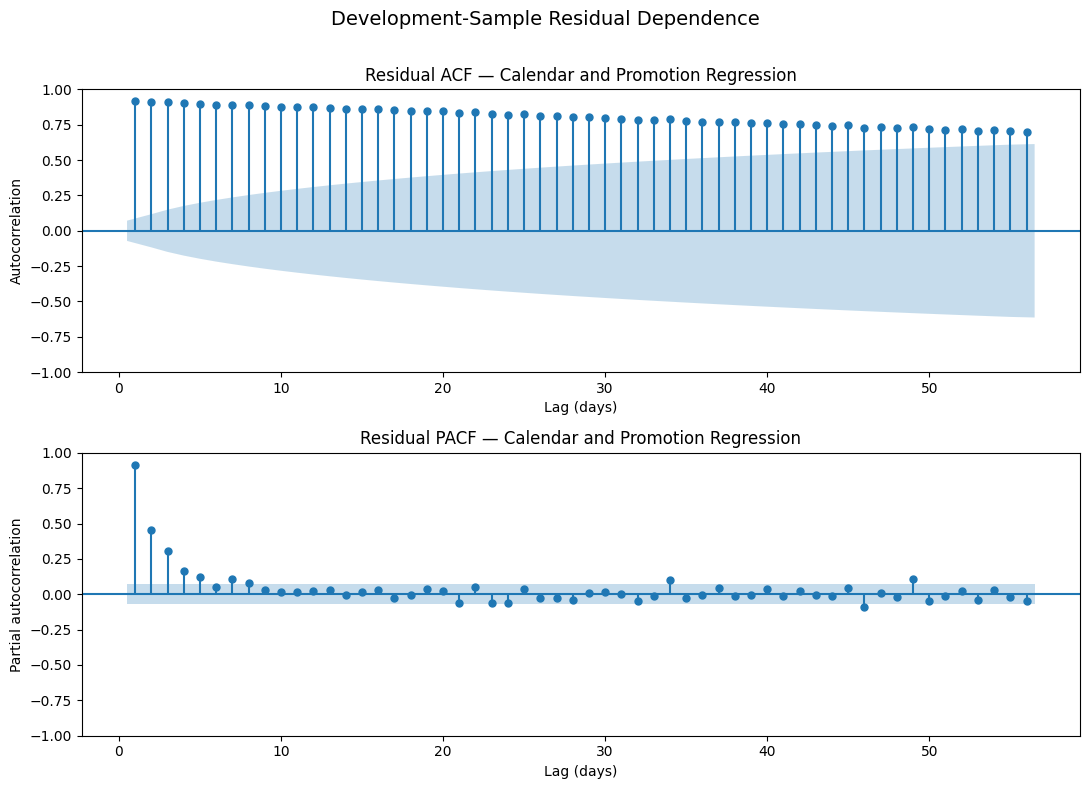

,parameter,parameter_role,estimate,standard_error,z_statistic,p_value,ci_95_lower,ci_95_upper,statistically_significant_05
0,dow_1,exogenous_regressor,-0.0449,0.0386,-1.1635,0.2446,-0.1206,0.0307,False
1,dow_2,exogenous_regressor,-0.0725,0.0400,-1.8136,0.0697,-0.1508,0.0058,False
2,dow_3,exogenous_regressor,-0.0232,0.0391,-0.5919,0.5539,-0.0999,0.0536,False
3,dow_4,exogenous_regressor,0.0852,0.0406,2.0967,0.0360,0.0056,0.1648,True
4,dow_5,exogenous_regressor,-0.2889,0.0397,-7.2769,0.0000,-0.3668,-0.2111,True
5,dow_6,exogenous_regressor,-0.5211,0.0390,-13.3556,0.0000,-0.5975,-0.4446,True
6,is_month_end,exogenous_regressor,0.1761,0.0606,2.9053,0.0037,0.0573,0.2949,True
7,is_holiday,exogenous_regressor,-0.1469,0.0458,-3.2083,0.0013,-0.2367,-0.0572,True
8,is_payday,exogenous_regressor,-0.0057,0.0514,-0.1117,0.9111,-0.1064,0.0950,False
9,is_payday_window,exogenous_regressor,0.2465,0.0317,7.7792,0.0000,0.1844,0.3087,True


,model_name,sample_start,sample_end,observations,exogenous_specification,number_of_exogenous_features,arima_order,seasonal_order,optimizer_converged,log_likelihood,aic,bic,hqic,residual_mean,residual_standard_deviation,residual_rmse_log,maximum_absolute_residual,ljung_box_pvalue_lag_7,ljung_box_pvalue_lag_14,ljung_box_pvalue_lag_21,ljung_box_pvalue_lag_28,review_status
0,development_calendar_promotion_independent_errors,2023-01-01,2025-01-17,748,calendar_promotion,11,"(0, 0, 0)","(0, 0, 0, 0)",True,-121.6740,269.3480,329.3742,292.4802,0.0000,0.2847,0.2847,0.7081,0.0000,0.0000,0.0000,0.0000,PRELIMINARY


,lag,ljung_box_statistic,p_value,reject_no_autocorrelation_05
0,7,"4,305.2832",0.0000,True
1,14,"8,389.3237",0.0000,True
2,21,"12,280.8795",0.0000,True
3,28,"15,929.3136",0.0000,True


Optimizer converged: True
Residual mean: 0.000005
Residual standard deviation: 0.284713
Saved residual figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_development_independent_regression_acf_pacf.png


In [17]:
# ============================================================================
# 10. Fit the independent-error regression on the development sample
# ============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# ----------------------------------------------------------------------------
# Development specification
# ----------------------------------------------------------------------------

DEVELOPMENT_SPECIFICATION = "calendar_promotion"

development_features = EXOGENOUS_SPECIFICATIONS[
    DEVELOPMENT_SPECIFICATION
]["features"]

development_target = (
    development_data[LOG_TARGET_COLUMN]
    .astype(float)
)

development_exog = (
    development_data[development_features]
    .astype(float)
)


# ----------------------------------------------------------------------------
# Fit regression with independent errors
# ----------------------------------------------------------------------------

independent_regression_model = SARIMAX(
    endog=development_target,
    exog=development_exog,
    order=(0, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True,
)

independent_regression_result = (
    independent_regression_model.fit(
        method="lbfgs",
        maxiter=500,
        disp=False,
    )
)

optimizer_converged = bool(
    independent_regression_result
    .mle_retvals
    .get("converged", False)
)

assert optimizer_converged, (
    "The independent-error regression did not converge. "
    "Do not interpret its coefficients or residual diagnostics."
)


# ----------------------------------------------------------------------------
# Coefficient table
# ----------------------------------------------------------------------------

confidence_intervals = (
    independent_regression_result
    .conf_int(alpha=0.05)
)

coefficient_table = pd.DataFrame(
    {
        "parameter": (
            independent_regression_result
            .params
            .index
        ),
        "estimate": (
            independent_regression_result
            .params
            .to_numpy()
        ),
        "standard_error": (
            independent_regression_result
            .bse
            .to_numpy()
        ),
        "z_statistic": (
            independent_regression_result
            .zvalues
            .to_numpy()
        ),
        "p_value": (
            independent_regression_result
            .pvalues
            .to_numpy()
        ),
        "ci_95_lower": (
            confidence_intervals.iloc[:, 0]
            .to_numpy()
        ),
        "ci_95_upper": (
            confidence_intervals.iloc[:, 1]
            .to_numpy()
        ),
    }
)

coefficient_table["parameter_role"] = np.select(
    [
        coefficient_table["parameter"].eq("intercept"),
        coefficient_table["parameter"].eq("sigma2"),
        coefficient_table["parameter"].isin(
            development_features
        ),
    ],
    [
        "intercept",
        "residual_variance",
        "exogenous_regressor",
    ],
    default="other",
)

coefficient_table["statistically_significant_05"] = (
    coefficient_table["p_value"] < 0.05
)

coefficient_table = coefficient_table[
    [
        "parameter",
        "parameter_role",
        "estimate",
        "standard_error",
        "z_statistic",
        "p_value",
        "ci_95_lower",
        "ci_95_upper",
        "statistically_significant_05",
    ]
]


# ----------------------------------------------------------------------------
# Residual series
# ----------------------------------------------------------------------------

development_fitted_log = pd.Series(
    independent_regression_result.fittedvalues,
    index=development_data.index,
    name="fitted_log_target",
)

development_residuals = pd.Series(
    independent_regression_result.resid,
    index=development_data.index,
    name="residual",
)

residual_output = pd.DataFrame(
    {
        DATE_COLUMN: development_data[DATE_COLUMN],
        "observed_log_target": development_target,
        "fitted_log_target": development_fitted_log,
        "residual": development_residuals,
    }
)

residual_output["observed_target"] = np.exp(
    residual_output["observed_log_target"]
)

residual_output["median_fitted_target"] = np.exp(
    residual_output["fitted_log_target"]
)


# ----------------------------------------------------------------------------
# Ljung-Box screening
# ----------------------------------------------------------------------------
# model_df=0 is used here as a residual-autocorrelation screening diagnostic.
# ARMA degrees of freedom will be incorporated when ARIMA-error models are
# evaluated.

LJUNG_BOX_LAGS = [7, 14, 21, 28]

ljung_box_table = (
    acorr_ljungbox(
        development_residuals,
        lags=LJUNG_BOX_LAGS,
        model_df=0,
        return_df=True,
    )
    .reset_index()
    .rename(
        columns={
            "index": "lag",
            "lb_stat": "ljung_box_statistic",
            "lb_pvalue": "p_value",
        }
    )
)

ljung_box_table["reject_no_autocorrelation_05"] = (
    ljung_box_table["p_value"] < 0.05
)


# ----------------------------------------------------------------------------
# Model-level diagnostics
# ----------------------------------------------------------------------------

residual_mean = float(
    development_residuals.mean()
)

residual_standard_deviation = float(
    development_residuals.std(ddof=0)
)

residual_rmse_log = float(
    np.sqrt(
        np.mean(
            np.square(development_residuals)
        )
    )
)

maximum_absolute_residual = float(
    development_residuals.abs().max()
)

independent_regression_diagnostics = pd.DataFrame(
    [
        {
            "model_name": (
                "development_calendar_promotion_"
                "independent_errors"
            ),
            "sample_start": (
                development_data[
                    DATE_COLUMN
                ].min().strftime("%Y-%m-%d")
            ),
            "sample_end": (
                development_data[
                    DATE_COLUMN
                ].max().strftime("%Y-%m-%d")
            ),
            "observations": int(
                independent_regression_result.nobs
            ),
            "exogenous_specification": (
                DEVELOPMENT_SPECIFICATION
            ),
            "number_of_exogenous_features": len(
                development_features
            ),
            "arima_order": "(0, 0, 0)",
            "seasonal_order": "(0, 0, 0, 0)",
            "optimizer_converged": optimizer_converged,
            "log_likelihood": float(
                independent_regression_result.llf
            ),
            "aic": float(
                independent_regression_result.aic
            ),
            "bic": float(
                independent_regression_result.bic
            ),
            "hqic": float(
                independent_regression_result.hqic
            ),
            "residual_mean": residual_mean,
            "residual_standard_deviation": (
                residual_standard_deviation
            ),
            "residual_rmse_log": residual_rmse_log,
            "maximum_absolute_residual": (
                maximum_absolute_residual
            ),
            "ljung_box_pvalue_lag_7": float(
                ljung_box_table.loc[
                    ljung_box_table["lag"].eq(7),
                    "p_value",
                ].iloc[0]
            ),
            "ljung_box_pvalue_lag_14": float(
                ljung_box_table.loc[
                    ljung_box_table["lag"].eq(14),
                    "p_value",
                ].iloc[0]
            ),
            "ljung_box_pvalue_lag_21": float(
                ljung_box_table.loc[
                    ljung_box_table["lag"].eq(21),
                    "p_value",
                ].iloc[0]
            ),
            "ljung_box_pvalue_lag_28": float(
                ljung_box_table.loc[
                    ljung_box_table["lag"].eq(28),
                    "p_value",
                ].iloc[0]
            ),
            "review_status": "PRELIMINARY",
        }
    ]
)


# ----------------------------------------------------------------------------
# Residual ACF and PACF figure
# ----------------------------------------------------------------------------

MAX_CORRELATION_LAG = 56

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 8),
)

plot_acf(
    development_residuals,
    lags=MAX_CORRELATION_LAG,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "Residual ACF — Calendar and Promotion Regression"
)
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    development_residuals,
    lags=MAX_CORRELATION_LAG,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "Residual PACF — Calendar and Promotion Regression"
)
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Partial autocorrelation")

fig.suptitle(
    "Development-Sample Residual Dependence",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

RESIDUAL_ACF_PACF_PATH = (
    FIGURES_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_regression_acf_pacf.png"
    )
)

fig.savefig(
    RESIDUAL_ACF_PACF_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

assert RESIDUAL_ACF_PACF_PATH.exists(), (
    f"Residual figure was not created: "
    f"{RESIDUAL_ACF_PACF_PATH}"
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

COEFFICIENT_TABLE_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_regression_coefficients.csv"
    )
)

INDEPENDENT_DIAGNOSTICS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_regression_diagnostics.csv"
    )
)

LJUNG_BOX_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_regression_ljung_box.csv"
    )
)

INDEPENDENT_RESIDUALS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_regression_residuals.csv"
    )
)

coefficient_table.to_csv(
    COEFFICIENT_TABLE_PATH,
    index=False,
)

independent_regression_diagnostics.to_csv(
    INDEPENDENT_DIAGNOSTICS_PATH,
    index=False,
)

ljung_box_table.to_csv(
    LJUNG_BOX_PATH,
    index=False,
)

residual_output.to_csv(
    INDEPENDENT_RESIDUALS_PATH,
    index=False,
)

for output_path in [
    COEFFICIENT_TABLE_PATH,
    INDEPENDENT_DIAGNOSTICS_PATH,
    LJUNG_BOX_PATH,
    INDEPENDENT_RESIDUALS_PATH,
    RESIDUAL_ACF_PACF_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the main results
# ----------------------------------------------------------------------------

display(
    coefficient_table.loc[
        coefficient_table[
            "parameter_role"
        ].eq("exogenous_regressor")
    ].reset_index(drop=True)
)

display(independent_regression_diagnostics)

display(ljung_box_table)

print(
    "Optimizer converged: "
    f"{optimizer_converged}"
)

print(
    "Residual mean: "
    f"{residual_mean:.6f}"
)

print(
    "Residual standard deviation: "
    f"{residual_standard_deviation:.6f}"
)

print(
    "Saved residual figure: "
    f"{RESIDUAL_ACF_PACF_PATH}"
)

## 9. Deterministic-trend diagnostic

The independent-error regression leaves extremely persistent residual
autocorrelation. The residual ACF decays slowly across the complete 56-day
diagnostic range rather than showing only isolated weekly-seasonal peaks.

This pattern may result partly from an omitted long-term growth component.
Before defining ARIMA-error orders, a deterministic continuous time trend is
tested.

The diagnostic trend is defined as:

$$
\text{time index in years}
=
\frac{\text{date} - \text{2023-01-01}}{365.25}
$$

This variable is leakage-safe because it is calculated exclusively from the
calendar and is therefore known for the complete forecast horizon.

Two models are compared on exactly the same development sample:

1. Calendar and promotion regression with independent errors.
2. The same regression augmented with a deterministic time trend.

AIC, BIC and residual diagnostics are comparable because both models use the
same transformed target, observations and estimation sample.

The trend will be incorporated into the formal exogenous specifications only
if it improves the model and materially reduces residual persistence.

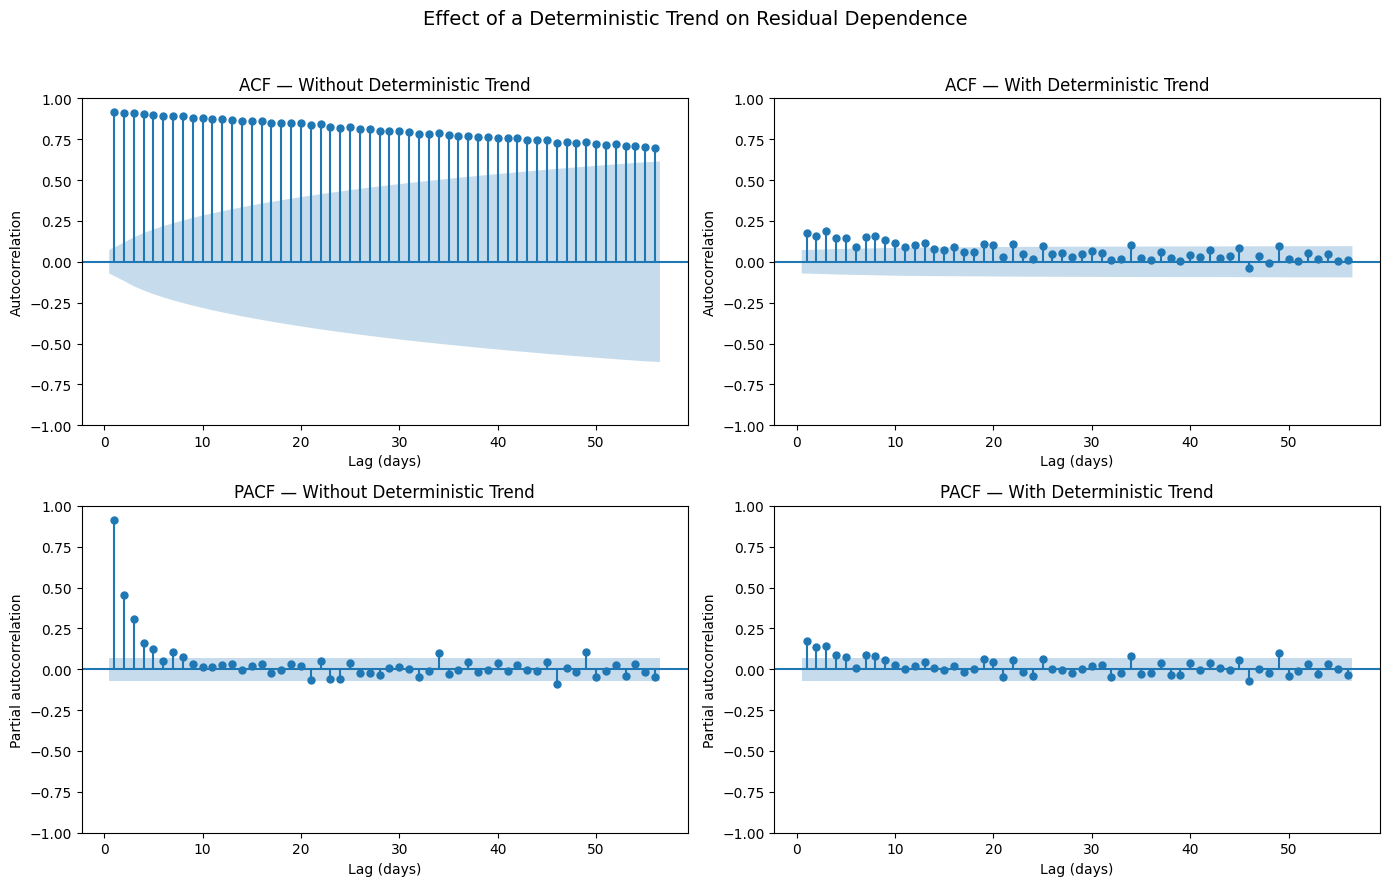

,model_name,includes_deterministic_trend,number_of_exogenous_features,log_likelihood,aic,bic,residual_standard_deviation,residual_rmse_log,ljung_box_pvalue_lag_7,ljung_box_pvalue_lag_14,ljung_box_pvalue_lag_28,delta_aic_vs_no_trend,delta_bic_vs_no_trend,residual_std_reduction_pct
0,calendar_promotion_independent_errors,False,11,-121.6740,269.3480,329.3742,0.2847,0.2847,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,calendar_promotion_trend_independent_errors,True,12,742.9352,"-1,457.8704","-1,393.2268",0.0896,0.0896,0.0000,0.0000,0.0000,"-1,727.2184","-1,722.6010",68.5224


,parameter,parameter_role,estimate,standard_error,z_statistic,p_value,ci_95_lower,ci_95_upper,statistically_significant_05
0,is_month_end,exogenous_regressor,0.1688,0.0167,10.1185,0.0000,0.1361,0.2015,True
1,is_holiday,exogenous_regressor,-0.1290,0.0188,-6.8561,0.0000,-0.1659,-0.0921,True
2,is_payday,exogenous_regressor,-0.0031,0.0155,-0.1978,0.8432,-0.0334,0.0273,False
3,is_payday_window,exogenous_regressor,0.2456,0.0098,25.1474,0.0000,0.2265,0.2647,True
4,promotion_intensity,exogenous_regressor,1.1204,0.1722,6.5071,0.0000,0.7829,1.4579,True
5,time_index_years,deterministic_trend,0.4574,0.0059,78.0848,0.0000,0.4459,0.4688,True


,lag,ljung_box_statistic,p_value,reject_no_autocorrelation_05
0,7,123.7557,0.0000,True
1,14,193.7303,0.0000,True
2,21,227.4360,0.0000,True
3,28,251.3430,0.0000,True


Trend-design condition number: 3.3037
Trend optimizer converged: True
Saved comparison figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_development_independent_vs_trend_acf_pacf.png


In [18]:
# ============================================================================
# 11. Test a deterministic trend before defining ARIMA-error orders
# ============================================================================

TREND_FEATURE = "time_index_years"
TREND_ORIGIN = modeling_dataset[DATE_COLUMN].min()


# ----------------------------------------------------------------------------
# Construct the deterministic trend
# ----------------------------------------------------------------------------

development_time_index_years = (
    (
        development_data[DATE_COLUMN]
        - TREND_ORIGIN
    ).dt.days
    / 365.25
).astype(float)

development_exog_with_trend = (
    development_data[development_features]
    .astype(float)
    .copy()
)

development_exog_with_trend[TREND_FEATURE] = (
    development_time_index_years.to_numpy()
)

trend_features = [
    *development_features,
    TREND_FEATURE,
]


# ----------------------------------------------------------------------------
# Document the feature definition
# ----------------------------------------------------------------------------

trend_feature_definition = pd.DataFrame(
    [
        {
            "feature": TREND_FEATURE,
            "definition": (
                "(date - 2023-01-01).days / 365.25"
            ),
            "unit": "years_since_dataset_start",
            "future_availability": "known_in_advance",
            "leakage_risk": "low",
            "modeling_role": "deterministic_trend_candidate",
            "development_minimum": float(
                development_time_index_years.min()
            ),
            "development_maximum": float(
                development_time_index_years.max()
            ),
            "review_status": "PRELIMINARY",
        }
    ]
)


# ----------------------------------------------------------------------------
# Structural audit of the augmented design
# ----------------------------------------------------------------------------

trend_design_with_intercept = np.column_stack(
    [
        np.ones(len(development_exog_with_trend)),
        development_exog_with_trend.to_numpy(
            dtype=float
        ),
    ]
)

trend_design_rank = int(
    np.linalg.matrix_rank(
        trend_design_with_intercept
    )
)

trend_design_parameter_count = int(
    trend_design_with_intercept.shape[1]
)

assert (
    trend_design_rank
    == trend_design_parameter_count
), (
    "The trend-augmented exogenous matrix is rank deficient."
)

trend_feature_stds = (
    development_exog_with_trend
    .std(axis=0, ddof=0)
)

assert trend_feature_stds.gt(0).all(), (
    "The trend-augmented design contains a zero-variance feature."
)

standardized_trend_design = (
    development_exog_with_trend
    - development_exog_with_trend.mean(axis=0)
) / trend_feature_stds

standardized_trend_design_with_intercept = (
    np.column_stack(
        [
            np.ones(
                len(standardized_trend_design)
            ),
            standardized_trend_design.to_numpy(
                dtype=float
            ),
        ]
    )
)

trend_design_condition_number = float(
    np.linalg.cond(
        standardized_trend_design_with_intercept
    )
)


# ----------------------------------------------------------------------------
# Fit the trend-augmented regression with independent errors
# ----------------------------------------------------------------------------

trend_regression_model = SARIMAX(
    endog=development_target,
    exog=development_exog_with_trend,
    order=(0, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True,
)

trend_regression_result = trend_regression_model.fit(
    method="lbfgs",
    maxiter=500,
    disp=False,
)

trend_optimizer_converged = bool(
    trend_regression_result
    .mle_retvals
    .get("converged", False)
)

assert trend_optimizer_converged, (
    "The trend-augmented regression did not converge."
)


# ----------------------------------------------------------------------------
# Trend-model coefficient table
# ----------------------------------------------------------------------------

trend_confidence_intervals = (
    trend_regression_result
    .conf_int(alpha=0.05)
)

trend_coefficient_table = pd.DataFrame(
    {
        "parameter": (
            trend_regression_result
            .params
            .index
        ),
        "estimate": (
            trend_regression_result
            .params
            .to_numpy()
        ),
        "standard_error": (
            trend_regression_result
            .bse
            .to_numpy()
        ),
        "z_statistic": (
            trend_regression_result
            .zvalues
            .to_numpy()
        ),
        "p_value": (
            trend_regression_result
            .pvalues
            .to_numpy()
        ),
        "ci_95_lower": (
            trend_confidence_intervals
            .iloc[:, 0]
            .to_numpy()
        ),
        "ci_95_upper": (
            trend_confidence_intervals
            .iloc[:, 1]
            .to_numpy()
        ),
    }
)

trend_coefficient_table["parameter_role"] = np.select(
    [
        trend_coefficient_table[
            "parameter"
        ].eq("intercept"),
        trend_coefficient_table[
            "parameter"
        ].eq("sigma2"),
        trend_coefficient_table[
            "parameter"
        ].eq(TREND_FEATURE),
        trend_coefficient_table[
            "parameter"
        ].isin(development_features),
    ],
    [
        "intercept",
        "residual_variance",
        "deterministic_trend",
        "exogenous_regressor",
    ],
    default="other",
)

trend_coefficient_table[
    "statistically_significant_05"
] = (
    trend_coefficient_table["p_value"]
    < 0.05
)

trend_coefficient_table = trend_coefficient_table[
    [
        "parameter",
        "parameter_role",
        "estimate",
        "standard_error",
        "z_statistic",
        "p_value",
        "ci_95_lower",
        "ci_95_upper",
        "statistically_significant_05",
    ]
]


# ----------------------------------------------------------------------------
# Trend-model residuals
# ----------------------------------------------------------------------------

trend_fitted_log = pd.Series(
    trend_regression_result.fittedvalues,
    index=development_data.index,
    name="fitted_log_target",
)

trend_residuals = pd.Series(
    trend_regression_result.resid,
    index=development_data.index,
    name="residual",
)

trend_residual_output = pd.DataFrame(
    {
        DATE_COLUMN: development_data[
            DATE_COLUMN
        ],
        "observed_log_target": development_target,
        "fitted_log_target": trend_fitted_log,
        "residual": trend_residuals,
        TREND_FEATURE: (
            development_time_index_years
        ),
    }
)

trend_residual_output["observed_target"] = np.exp(
    trend_residual_output[
        "observed_log_target"
    ]
)

trend_residual_output[
    "median_fitted_target"
] = np.exp(
    trend_residual_output[
        "fitted_log_target"
    ]
)


# ----------------------------------------------------------------------------
# Ljung-Box diagnostic
# ----------------------------------------------------------------------------

trend_ljung_box_table = (
    acorr_ljungbox(
        trend_residuals,
        lags=LJUNG_BOX_LAGS,
        model_df=0,
        return_df=True,
    )
    .reset_index()
    .rename(
        columns={
            "index": "lag",
            "lb_stat": "ljung_box_statistic",
            "lb_pvalue": "p_value",
        }
    )
)

trend_ljung_box_table[
    "reject_no_autocorrelation_05"
] = (
    trend_ljung_box_table["p_value"]
    < 0.05
)


# ----------------------------------------------------------------------------
# Trend-model diagnostics
# ----------------------------------------------------------------------------

trend_residual_mean = float(
    trend_residuals.mean()
)

trend_residual_standard_deviation = float(
    trend_residuals.std(ddof=0)
)

trend_residual_rmse_log = float(
    np.sqrt(
        np.mean(
            np.square(trend_residuals)
        )
    )
)

trend_regression_diagnostics = pd.DataFrame(
    [
        {
            "model_name": (
                "development_calendar_promotion_"
                "trend_independent_errors"
            ),
            "sample_start": (
                development_data[
                    DATE_COLUMN
                ].min().strftime("%Y-%m-%d")
            ),
            "sample_end": (
                development_data[
                    DATE_COLUMN
                ].max().strftime("%Y-%m-%d")
            ),
            "observations": int(
                trend_regression_result.nobs
            ),
            "number_of_exogenous_features": len(
                trend_features
            ),
            "includes_deterministic_trend": True,
            "arima_order": "(0, 0, 0)",
            "seasonal_order": "(0, 0, 0, 0)",
            "optimizer_converged": (
                trend_optimizer_converged
            ),
            "design_rank_with_intercept": (
                trend_design_rank
            ),
            "design_parameter_count": (
                trend_design_parameter_count
            ),
            "standardized_condition_number": (
                trend_design_condition_number
            ),
            "log_likelihood": float(
                trend_regression_result.llf
            ),
            "aic": float(
                trend_regression_result.aic
            ),
            "bic": float(
                trend_regression_result.bic
            ),
            "hqic": float(
                trend_regression_result.hqic
            ),
            "residual_mean": (
                trend_residual_mean
            ),
            "residual_standard_deviation": (
                trend_residual_standard_deviation
            ),
            "residual_rmse_log": (
                trend_residual_rmse_log
            ),
            "maximum_absolute_residual": float(
                trend_residuals.abs().max()
            ),
            "ljung_box_pvalue_lag_7": float(
                trend_ljung_box_table.loc[
                    trend_ljung_box_table[
                        "lag"
                    ].eq(7),
                    "p_value",
                ].iloc[0]
            ),
            "ljung_box_pvalue_lag_14": float(
                trend_ljung_box_table.loc[
                    trend_ljung_box_table[
                        "lag"
                    ].eq(14),
                    "p_value",
                ].iloc[0]
            ),
            "ljung_box_pvalue_lag_21": float(
                trend_ljung_box_table.loc[
                    trend_ljung_box_table[
                        "lag"
                    ].eq(21),
                    "p_value",
                ].iloc[0]
            ),
            "ljung_box_pvalue_lag_28": float(
                trend_ljung_box_table.loc[
                    trend_ljung_box_table[
                        "lag"
                    ].eq(28),
                    "p_value",
                ].iloc[0]
            ),
            "review_status": "PRELIMINARY",
        }
    ]
)


# ----------------------------------------------------------------------------
# Comparable model summary
# ----------------------------------------------------------------------------

independent_diagnostic_row = (
    independent_regression_diagnostics
    .iloc[0]
)

trend_diagnostic_row = (
    trend_regression_diagnostics
    .iloc[0]
)

independent_vs_trend_comparison = pd.DataFrame(
    [
        {
            "model_name": (
                "calendar_promotion_"
                "independent_errors"
            ),
            "includes_deterministic_trend": False,
            "number_of_exogenous_features": len(
                development_features
            ),
            "log_likelihood": float(
                independent_diagnostic_row[
                    "log_likelihood"
                ]
            ),
            "aic": float(
                independent_diagnostic_row["aic"]
            ),
            "bic": float(
                independent_diagnostic_row["bic"]
            ),
            "residual_standard_deviation": float(
                independent_diagnostic_row[
                    "residual_standard_deviation"
                ]
            ),
            "residual_rmse_log": float(
                independent_diagnostic_row[
                    "residual_rmse_log"
                ]
            ),
            "ljung_box_pvalue_lag_7": float(
                independent_diagnostic_row[
                    "ljung_box_pvalue_lag_7"
                ]
            ),
            "ljung_box_pvalue_lag_14": float(
                independent_diagnostic_row[
                    "ljung_box_pvalue_lag_14"
                ]
            ),
            "ljung_box_pvalue_lag_28": float(
                independent_diagnostic_row[
                    "ljung_box_pvalue_lag_28"
                ]
            ),
            "delta_aic_vs_no_trend": 0.0,
            "delta_bic_vs_no_trend": 0.0,
            "residual_std_reduction_pct": 0.0,
        },
        {
            "model_name": (
                "calendar_promotion_trend_"
                "independent_errors"
            ),
            "includes_deterministic_trend": True,
            "number_of_exogenous_features": len(
                trend_features
            ),
            "log_likelihood": float(
                trend_diagnostic_row[
                    "log_likelihood"
                ]
            ),
            "aic": float(
                trend_diagnostic_row["aic"]
            ),
            "bic": float(
                trend_diagnostic_row["bic"]
            ),
            "residual_standard_deviation": float(
                trend_diagnostic_row[
                    "residual_standard_deviation"
                ]
            ),
            "residual_rmse_log": float(
                trend_diagnostic_row[
                    "residual_rmse_log"
                ]
            ),
            "ljung_box_pvalue_lag_7": float(
                trend_diagnostic_row[
                    "ljung_box_pvalue_lag_7"
                ]
            ),
            "ljung_box_pvalue_lag_14": float(
                trend_diagnostic_row[
                    "ljung_box_pvalue_lag_14"
                ]
            ),
            "ljung_box_pvalue_lag_28": float(
                trend_diagnostic_row[
                    "ljung_box_pvalue_lag_28"
                ]
            ),
            "delta_aic_vs_no_trend": float(
                trend_diagnostic_row["aic"]
                - independent_diagnostic_row["aic"]
            ),
            "delta_bic_vs_no_trend": float(
                trend_diagnostic_row["bic"]
                - independent_diagnostic_row["bic"]
            ),
            "residual_std_reduction_pct": float(
                100
                * (
                    independent_diagnostic_row[
                        "residual_standard_deviation"
                    ]
                    - trend_diagnostic_row[
                        "residual_standard_deviation"
                    ]
                )
                / independent_diagnostic_row[
                    "residual_standard_deviation"
                ]
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Comparative residual ACF and PACF figure
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
)

plot_acf(
    development_residuals,
    lags=MAX_CORRELATION_LAG,
    zero=False,
    ax=axes[0, 0],
)

axes[0, 0].set_title(
    "ACF — Without Deterministic Trend"
)
axes[0, 0].set_xlabel("Lag (days)")
axes[0, 0].set_ylabel("Autocorrelation")

plot_acf(
    trend_residuals,
    lags=MAX_CORRELATION_LAG,
    zero=False,
    ax=axes[0, 1],
)

axes[0, 1].set_title(
    "ACF — With Deterministic Trend"
)
axes[0, 1].set_xlabel("Lag (days)")
axes[0, 1].set_ylabel("Autocorrelation")

plot_pacf(
    development_residuals,
    lags=MAX_CORRELATION_LAG,
    zero=False,
    method="ywm",
    ax=axes[1, 0],
)

axes[1, 0].set_title(
    "PACF — Without Deterministic Trend"
)
axes[1, 0].set_xlabel("Lag (days)")
axes[1, 0].set_ylabel("Partial autocorrelation")

plot_pacf(
    trend_residuals,
    lags=MAX_CORRELATION_LAG,
    zero=False,
    method="ywm",
    ax=axes[1, 1],
)

axes[1, 1].set_title(
    "PACF — With Deterministic Trend"
)
axes[1, 1].set_xlabel("Lag (days)")
axes[1, 1].set_ylabel("Partial autocorrelation")

fig.suptitle(
    "Effect of a Deterministic Trend on Residual Dependence",
    fontsize=14,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

TREND_COMPARISON_FIGURE_PATH = (
    FIGURES_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_vs_trend_acf_pacf.png"
    )
)

fig.savefig(
    TREND_COMPARISON_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

assert TREND_COMPARISON_FIGURE_PATH.exists()


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

TREND_FEATURE_DEFINITION_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "trend_feature_definition.csv"
    )
)

TREND_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "trend_regression_coefficients.csv"
    )
)

TREND_DIAGNOSTICS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "trend_regression_diagnostics.csv"
    )
)

TREND_LJUNG_BOX_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "trend_regression_ljung_box.csv"
    )
)

TREND_RESIDUALS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "trend_regression_residuals.csv"
    )
)

TREND_COMPARISON_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "independent_vs_trend_comparison.csv"
    )
)

trend_feature_definition.to_csv(
    TREND_FEATURE_DEFINITION_PATH,
    index=False,
)

trend_coefficient_table.to_csv(
    TREND_COEFFICIENTS_PATH,
    index=False,
)

trend_regression_diagnostics.to_csv(
    TREND_DIAGNOSTICS_PATH,
    index=False,
)

trend_ljung_box_table.to_csv(
    TREND_LJUNG_BOX_PATH,
    index=False,
)

trend_residual_output.to_csv(
    TREND_RESIDUALS_PATH,
    index=False,
)

independent_vs_trend_comparison.to_csv(
    TREND_COMPARISON_PATH,
    index=False,
)


for output_path in [
    TREND_FEATURE_DEFINITION_PATH,
    TREND_COEFFICIENTS_PATH,
    TREND_DIAGNOSTICS_PATH,
    TREND_LJUNG_BOX_PATH,
    TREND_RESIDUALS_PATH,
    TREND_COMPARISON_PATH,
    TREND_COMPARISON_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the relevant results
# ----------------------------------------------------------------------------

display(independent_vs_trend_comparison)

display(
    trend_coefficient_table.loc[
        trend_coefficient_table[
            "parameter"
        ].isin(
            [
                TREND_FEATURE,
                "is_month_end",
                "is_holiday",
                "is_payday",
                "is_payday_window",
                "promotion_intensity",
            ]
        )
    ].reset_index(drop=True)
)

display(trend_ljung_box_table)

print(
    "Trend-design condition number: "
    f"{trend_design_condition_number:.4f}"
)

print(
    "Trend optimizer converged: "
    f"{trend_optimizer_converged}"
)

print(
    "Saved comparison figure: "
    f"{TREND_COMPARISON_FIGURE_PATH}"
)

## 10. Final modeling specifications and ARIMA-error candidates

The deterministic time trend materially improves the development-sample
regression and removes most of the long-range residual persistence.

The trend is therefore retained as a known-future predictor in all operational
model specifications:

$$
\text{time\_index\_years}_t
=
\frac{\text{date}_t-\text{2023-01-01}}{365.25}
$$

The transformed-target regression becomes:

$$
\log(Y_t)
=
\beta_0
+
\mathbf{x}_t^\top\boldsymbol{\beta}
+
\beta_{\text{trend}}\text{time\_index\_years}_t
+
n_t
$$

where the remaining error process \(n_t\) will be represented through a small
set of ARMA or seasonal ARMA structures.

Because the deterministic trend removes the near-unit-root residual pattern,
the initial candidate set uses:

$$
d = 0
\qquad\text{and}\qquad
D = 0
$$

The candidates are intentionally limited to:

- Independent errors as a diagnostic reference.
- AR(1).
- AR(2).
- MA(1).
- ARMA(1,1).
- AR(1) with an additional seasonal AR(1) term at period 7.

The seasonal model is retained as a sensitivity candidate. Weekday dummy
variables already represent the deterministic weekly pattern, and the residual
ACF does not show a dominant isolated weekly spike.

Candidate screening will use the same development sample. AICc and BIC will
support model reduction, but final selection will depend on rolling-origin
backtesting over the twenty validated folds.

In [19]:
# ============================================================================
# 12. Freeze the deterministic trend and ARIMA-error candidate registry
# ============================================================================

# ----------------------------------------------------------------------------
# Add the validated deterministic trend to the complete modeling dataset
# ----------------------------------------------------------------------------

modeling_dataset_with_trend = modeling_dataset.copy()

modeling_dataset_with_trend[TREND_FEATURE] = (
    (
        modeling_dataset_with_trend[DATE_COLUMN]
        - TREND_ORIGIN
    ).dt.days
    / 365.25
).astype(float)

assert modeling_dataset_with_trend[TREND_FEATURE].notna().all()

assert np.isfinite(
    modeling_dataset_with_trend[TREND_FEATURE]
).all()

assert modeling_dataset_with_trend[TREND_FEATURE].is_monotonic_increasing

assert np.isclose(
    modeling_dataset_with_trend[TREND_FEATURE].iloc[0],
    0.0,
)


# ----------------------------------------------------------------------------
# Record the deterministic-trend decision
# ----------------------------------------------------------------------------

trend_comparison_row = (
    independent_vs_trend_comparison
    .loc[
        independent_vs_trend_comparison[
            "includes_deterministic_trend"
        ]
    ]
    .iloc[0]
)

deterministic_trend_decision = pd.DataFrame(
    [
        {
            "feature": TREND_FEATURE,
            "decision": "retain_primary",
            "future_availability": "known_in_advance",
            "definition": (
                "(date - 2023-01-01).days / 365.25"
            ),
            "unit": "years_since_dataset_start",
            "coefficient_estimate": float(
                trend_coefficient_table.loc[
                    trend_coefficient_table[
                        "parameter"
                    ].eq(TREND_FEATURE),
                    "estimate",
                ].iloc[0]
            ),
            "delta_aic_vs_no_trend": float(
                trend_comparison_row[
                    "delta_aic_vs_no_trend"
                ]
            ),
            "delta_bic_vs_no_trend": float(
                trend_comparison_row[
                    "delta_bic_vs_no_trend"
                ]
            ),
            "residual_std_reduction_pct": float(
                trend_comparison_row[
                    "residual_std_reduction_pct"
                ]
            ),
            "decision_reason": (
                "The deterministic trend strongly improves AIC and BIC, "
                "reduces residual standard deviation by more than 68%, "
                "and removes most long-range residual persistence."
            ),
            "review_status": "VALIDATED",
        }
    ]
)


# ----------------------------------------------------------------------------
# Create the final exogenous specifications used for model fitting
# ----------------------------------------------------------------------------

MODELING_SPECIFICATIONS = {
    "calendar_core_trend": {
        "features": [
            *CALENDAR_CORE_FEATURES,
            TREND_FEATURE,
        ],
        "evaluation_role": "primary",
        "description": (
            "Calendar effects plus the validated deterministic trend."
        ),
    },
    "calendar_promotion_trend": {
        "features": [
            *CALENDAR_CORE_FEATURES,
            *PROMOTION_FEATURES,
            TREND_FEATURE,
        ],
        "evaluation_role": "primary",
        "description": (
            "Calendar effects, planned promotion intensity and "
            "the validated deterministic trend."
        ),
    },
    "calendar_promotion_settlement_trend": {
        "features": [
            *CALENDAR_CORE_FEATURES,
            *PROMOTION_FEATURES,
            *SETTLEMENT_FEATURES,
            TREND_FEATURE,
        ],
        "evaluation_role": "sensitivity_only",
        "description": (
            "Extended specification including sparse scheduled "
            "merchant settlements."
        ),
    },
}


# ----------------------------------------------------------------------------
# Validate specification structure
# ----------------------------------------------------------------------------

available_modeling_features = set(
    modeling_dataset_with_trend.columns
)

specification_records = []

for specification_name, specification in (
    MODELING_SPECIFICATIONS.items()
):

    features = specification["features"]

    missing_features = (
        set(features)
        - available_modeling_features
    )

    assert not missing_features, (
        f"{specification_name} contains unavailable features: "
        f"{sorted(missing_features)}"
    )

    assert len(features) == len(set(features)), (
        f"{specification_name} contains duplicated features."
    )

    for feature_position, feature in enumerate(
        features,
        start=1,
    ):
        specification_records.append(
            {
                "specification_name": specification_name,
                "evaluation_role": specification[
                    "evaluation_role"
                ],
                "feature_position": feature_position,
                "feature": feature,
                "description": specification[
                    "description"
                ],
                "review_status": "VALIDATED",
            }
        )

modeling_specifications_with_trend = pd.DataFrame(
    specification_records
)


expected_modeling_feature_counts = {
    "calendar_core_trend": 11,
    "calendar_promotion_trend": 12,
    "calendar_promotion_settlement_trend": 13,
}

observed_modeling_feature_counts = (
    modeling_specifications_with_trend
    .groupby("specification_name")
    .size()
    .to_dict()
)

assert (
    observed_modeling_feature_counts
    == expected_modeling_feature_counts
)


# ----------------------------------------------------------------------------
# Define a small ARIMA-error candidate registry
# ----------------------------------------------------------------------------

ARIMA_ERROR_CANDIDATES = {
    "independent_errors": {
        "order": (0, 0, 0),
        "seasonal_order": (0, 0, 0, 0),
        "candidate_role": "diagnostic_reference",
        "rationale": (
            "Reference regression without residual time-series terms."
        ),
    },
    "ar1_errors": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 0, 0),
        "candidate_role": "primary_candidate",
        "rationale": (
            "Tests short-memory persistence concentrated at lag 1."
        ),
    },
    "ar2_errors": {
        "order": (2, 0, 0),
        "seasonal_order": (0, 0, 0, 0),
        "candidate_role": "primary_candidate",
        "rationale": (
            "Allows the first two residual lags to contribute directly."
        ),
    },
    "ma1_errors": {
        "order": (0, 0, 1),
        "seasonal_order": (0, 0, 0, 0),
        "candidate_role": "primary_candidate",
        "rationale": (
            "Tests whether residual dependence is better represented "
            "as a short-lived innovation effect."
        ),
    },
    "arma11_errors": {
        "order": (1, 0, 1),
        "seasonal_order": (0, 0, 0, 0),
        "candidate_role": "primary_candidate",
        "rationale": (
            "Represents a compact combination of persistence and "
            "innovation dynamics."
        ),
    },
    "ar1_seasonal_ar1_7_errors": {
        "order": (1, 0, 0),
        "seasonal_order": (1, 0, 0, 7),
        "candidate_role": "seasonal_sensitivity",
        "rationale": (
            "Tests whether a weekly residual AR term adds value beyond "
            "the deterministic weekday dummy variables."
        ),
    },
}


candidate_records = []

for candidate_name, candidate in (
    ARIMA_ERROR_CANDIDATES.items()
):

    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]

    candidate_records.append(
        {
            "candidate_name": candidate_name,
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "P": seasonal_order[0],
            "D": seasonal_order[1],
            "Q": seasonal_order[2],
            "seasonal_period": seasonal_order[3],
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "candidate_role": candidate[
                "candidate_role"
            ],
            "rationale": candidate["rationale"],
            "development_status": "PENDING",
        }
    )

arima_error_candidates = pd.DataFrame(
    candidate_records
)


# ----------------------------------------------------------------------------
# Candidate-registry controls
# ----------------------------------------------------------------------------

assert arima_error_candidates[
    "candidate_name"
].is_unique

assert arima_error_candidates["d"].eq(0).all()

assert arima_error_candidates["D"].eq(0).all()

assert set(
    arima_error_candidates["seasonal_period"]
).issubset({0, 7})

assert len(arima_error_candidates) == 6


# ----------------------------------------------------------------------------
# Save and verify every generated table
# ----------------------------------------------------------------------------

MODELING_DATASET_WITH_TREND_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_modeling_dataset_with_trend.csv"
)

DETERMINISTIC_TREND_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_deterministic_trend_decision.csv"
)

MODELING_SPECIFICATIONS_WITH_TREND_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_modeling_specifications_with_trend.csv"
)

ARIMA_ERROR_CANDIDATES_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima_error_candidates.csv"
)

modeling_dataset_with_trend.to_csv(
    MODELING_DATASET_WITH_TREND_PATH,
    index=False,
)

deterministic_trend_decision.to_csv(
    DETERMINISTIC_TREND_DECISION_PATH,
    index=False,
)

modeling_specifications_with_trend.to_csv(
    MODELING_SPECIFICATIONS_WITH_TREND_PATH,
    index=False,
)

arima_error_candidates.to_csv(
    ARIMA_ERROR_CANDIDATES_PATH,
    index=False,
)


for output_path in [
    MODELING_DATASET_WITH_TREND_PATH,
    DETERMINISTIC_TREND_DECISION_PATH,
    MODELING_SPECIFICATIONS_WITH_TREND_PATH,
    ARIMA_ERROR_CANDIDATES_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the frozen decisions
# ----------------------------------------------------------------------------

display(deterministic_trend_decision)

display(
    modeling_specifications_with_trend
    .groupby(
        [
            "specification_name",
            "evaluation_role",
            "review_status",
        ],
        as_index=False,
    )
    .agg(
        number_of_features=("feature", "size"),
        feature_list=(
            "feature",
            lambda values: " | ".join(values),
        ),
    )
)

display(arima_error_candidates)

print(
    "Validated trend feature: "
    f"{TREND_FEATURE}"
)

print(
    "ARIMA-error candidates defined: "
    f"{len(arima_error_candidates)}"
)

print(
    "Saved modeling dataset: "
    f"{MODELING_DATASET_WITH_TREND_PATH}"
)

print(
    "Saved ARIMA candidate registry: "
    f"{ARIMA_ERROR_CANDIDATES_PATH}"
)

,feature,decision,future_availability,definition,unit,coefficient_estimate,delta_aic_vs_no_trend,delta_bic_vs_no_trend,residual_std_reduction_pct,decision_reason,review_status
0,time_index_years,retain_primary,known_in_advance,(date - 2023-01-01).days / 365.25,years_since_dataset_start,0.4574,"-1,727.2184","-1,722.6010",68.5224,The deterministic trend strongly improves AIC ...,VALIDATED


,specification_name,evaluation_role,review_status,number_of_features,feature_list
0,calendar_core_trend,primary,VALIDATED,11,dow_1 | dow_2 | dow_3 | dow_4 | dow_5 | dow_6 ...
1,calendar_promotion_settlement_trend,sensitivity_only,VALIDATED,13,dow_1 | dow_2 | dow_3 | dow_4 | dow_5 | dow_6 ...
2,calendar_promotion_trend,primary,VALIDATED,12,dow_1 | dow_2 | dow_3 | dow_4 | dow_5 | dow_6 ...


,candidate_name,p,d,q,P,D,Q,seasonal_period,order,seasonal_order,candidate_role,rationale,development_status
0,independent_errors,0,0,0,0,0,0,0,"(0, 0, 0)","(0, 0, 0, 0)",diagnostic_reference,Reference regression without residual time-ser...,PENDING
1,ar1_errors,1,0,0,0,0,0,0,"(1, 0, 0)","(0, 0, 0, 0)",primary_candidate,Tests short-memory persistence concentrated at...,PENDING
2,ar2_errors,2,0,0,0,0,0,0,"(2, 0, 0)","(0, 0, 0, 0)",primary_candidate,Allows the first two residual lags to contribu...,PENDING
3,ma1_errors,0,0,1,0,0,0,0,"(0, 0, 1)","(0, 0, 0, 0)",primary_candidate,Tests whether residual dependence is better re...,PENDING
4,arma11_errors,1,0,1,0,0,0,0,"(1, 0, 1)","(0, 0, 0, 0)",primary_candidate,Represents a compact combination of persistenc...,PENDING
5,ar1_seasonal_ar1_7_errors,1,0,0,1,0,0,7,"(1, 0, 0)","(1, 0, 0, 7)",seasonal_sensitivity,Tests whether a weekly residual AR term adds v...,PENDING


Validated trend feature: time_index_years
ARIMA-error candidates defined: 6
Saved modeling dataset: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_modeling_dataset_with_trend.csv
Saved ARIMA candidate registry: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_arima_error_candidates.csv


## 11. Development-sample screening of ARIMA-error candidates

The six predefined ARIMA-error structures are fitted using the same:

- Development sample.
- Log-transformed target.
- `calendar_promotion_trend` exogenous specification.
- Maximum-likelihood estimation method.

The modeled relationship is:

$$
\log(Y_t)
=
\beta_0
+
\mathbf{x}_t^\top\boldsymbol{\beta}
+
n_t
$$

where:

$$
n_t
\sim
\operatorname{SARIMA}(p,0,q)(P,0,Q)_7
$$

The candidate comparison records:

- Optimizer convergence.
- AIC, AICc, BIC and HQIC.
- Residual dispersion.
- Ljung–Box diagnostics.
- Minimum AR- and MA-root modulus.
- Non-finite standard errors.
- Estimation warnings.

AICc is calculated as:

$$
\operatorname{AICc}
=
\operatorname{AIC}
+
\frac{2k(k+1)}{n-k-1}
$$

where \(k\) is the number of estimated parameters and \(n\) is the number of
development observations.

AICc and BIC are used only for candidate reduction. Final model selection will
depend on out-of-sample performance across the twenty validated folds.

In [20]:
# ============================================================================
# 13. Fit and screen the development-sample ARIMA-error candidates
# ============================================================================

import time


# ----------------------------------------------------------------------------
# Fixed development data and model specification
# ----------------------------------------------------------------------------

DEVELOPMENT_MODELING_SPECIFICATION = "calendar_promotion_trend"
ROOT_BOUNDARY_REVIEW_THRESHOLD = 1.05

development_model_features = MODELING_SPECIFICATIONS[
    DEVELOPMENT_MODELING_SPECIFICATION
]["features"]

development_data_with_trend = (
    modeling_dataset_with_trend.loc[
        modeling_dataset_with_trend[DATE_COLUMN].between(
            development_start,
            development_end,
            inclusive="both",
        )
    ]
    .copy()
    .reset_index(drop=True)
)

development_model_target = (
    development_data_with_trend[LOG_TARGET_COLUMN]
    .astype(float)
)

development_model_exog = (
    development_data_with_trend[
        development_model_features
    ]
    .astype(float)
)


assert len(development_data_with_trend) == 748

assert development_model_exog.shape == (
    748,
    len(development_model_features),
)

assert development_model_exog.isna().sum().sum() == 0

assert np.isfinite(
    development_model_exog.to_numpy()
).all()


# ----------------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------------

def calculate_aicc(aic, number_of_parameters, number_of_observations):
    """Calculate the finite-sample corrected Akaike information criterion."""

    denominator = (
        number_of_observations
        - number_of_parameters
        - 1
    )

    if denominator <= 0:
        return np.nan

    correction = (
        2
        * number_of_parameters
        * (number_of_parameters + 1)
        / denominator
    )

    return float(aic + correction)


def minimum_root_modulus(root_values):
    """Return the minimum modulus of a root array or NaN when no roots exist."""

    roots = np.asarray(
        root_values,
        dtype=complex,
    )

    if roots.size == 0:
        return np.nan

    return float(
        np.min(
            np.abs(roots)
        )
    )


# ----------------------------------------------------------------------------
# Fit every predefined candidate
# ----------------------------------------------------------------------------

comparison_records = []
coefficient_records = []
ljung_box_records = []
residual_records = []
failure_records = []

fitted_development_results = {}


for candidate_name, candidate in ARIMA_ERROR_CANDIDATES.items():

    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]

    fit_start_time = time.perf_counter()

    try:
        with warnings.catch_warnings(record=True) as captured_warnings:

            warnings.simplefilter("always")

            candidate_model = SARIMAX(
                endog=development_model_target,
                exog=development_model_exog,
                order=order,
                seasonal_order=seasonal_order,
                trend="c",
                enforce_stationarity=True,
                enforce_invertibility=True,
                simple_differencing=False,
            )

            candidate_result = candidate_model.fit(
                method="lbfgs",
                maxiter=500,
                disp=False,
            )

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        warning_messages = sorted(
            {
                str(warning.message)
                for warning in captured_warnings
            }
        )

        warning_text = " | ".join(
            warning_messages
        )

        optimizer_converged = bool(
            candidate_result
            .mle_retvals
            .get("converged", False)
        )

        parameter_names = list(
            candidate_result.param_names
        )

        parameter_values = np.asarray(
            candidate_result.params,
            dtype=float,
        )

        standard_errors = np.asarray(
            candidate_result.bse,
            dtype=float,
        )

        z_statistics = np.asarray(
            candidate_result.zvalues,
            dtype=float,
        )

        p_values = np.asarray(
            candidate_result.pvalues,
            dtype=float,
        )

        confidence_intervals = np.asarray(
            candidate_result.conf_int(
                alpha=0.05
            ),
            dtype=float,
        )

        finite_standard_errors = bool(
            np.isfinite(
                standard_errors
            ).all()
        )

        number_of_parameters = int(
            len(parameter_values)
        )

        number_of_observations = int(
            candidate_result.nobs
        )

        candidate_aicc = calculate_aicc(
            aic=float(candidate_result.aic),
            number_of_parameters=number_of_parameters,
            number_of_observations=number_of_observations,
        )


        # --------------------------------------------------------------------
        # Residual diagnostics
        # --------------------------------------------------------------------

        full_residuals = pd.Series(
            np.asarray(
                candidate_result.resid,
                dtype=float,
            ),
            index=development_data_with_trend.index,
            name="residual",
        )

        likelihood_burn = int(
            getattr(
                candidate_result,
                "loglikelihood_burn",
                getattr(
                    candidate_result.model,
                    "loglikelihood_burn",
                    0,
                ),
            )
            or 0
        )

        diagnostic_residuals = (
            full_residuals
            .iloc[likelihood_burn:]
            .dropna()
        )

        assert len(diagnostic_residuals) > 0

        residual_mean = float(
            diagnostic_residuals.mean()
        )

        residual_standard_deviation = float(
            diagnostic_residuals.std(ddof=0)
        )

        residual_rmse_log = float(
            np.sqrt(
                np.mean(
                    np.square(
                        diagnostic_residuals
                    )
                )
            )
        )

        maximum_absolute_residual = float(
            diagnostic_residuals.abs().max()
        )


        # --------------------------------------------------------------------
        # Ljung-Box with ARMA degrees-of-freedom adjustment
        # --------------------------------------------------------------------

        model_degrees_of_freedom = int(
            order[0]
            + order[2]
            + seasonal_order[0]
            + seasonal_order[2]
        )

        candidate_ljung_box = acorr_ljungbox(
            diagnostic_residuals,
            lags=LJUNG_BOX_LAGS,
            model_df=model_degrees_of_freedom,
            return_df=True,
        )

        candidate_ljung_box.index.name = "lag"

        candidate_ljung_box = (
            candidate_ljung_box
            .reset_index()
            .rename(
                columns={
                    "lb_stat": "ljung_box_statistic",
                    "lb_pvalue": "p_value",
                }
            )
        )

        candidate_ljung_box[
            "reject_no_autocorrelation_05"
        ] = (
            candidate_ljung_box["p_value"]
            < 0.05
        )

        candidate_ljung_box[
            "candidate_name"
        ] = candidate_name

        candidate_ljung_box[
            "model_degrees_of_freedom"
        ] = model_degrees_of_freedom

        ljung_box_records.extend(
            candidate_ljung_box[
                [
                    "candidate_name",
                    "lag",
                    "model_degrees_of_freedom",
                    "ljung_box_statistic",
                    "p_value",
                    "reject_no_autocorrelation_05",
                ]
            ].to_dict("records")
        )


        # --------------------------------------------------------------------
        # Root diagnostics
        # --------------------------------------------------------------------

        minimum_ar_root_modulus = (
            minimum_root_modulus(
                candidate_result.arroots
            )
        )

        minimum_ma_root_modulus = (
            minimum_root_modulus(
                candidate_result.maroots
            )
        )

        ar_root_near_boundary = bool(
            np.isfinite(
                minimum_ar_root_modulus
            )
            and minimum_ar_root_modulus
            < ROOT_BOUNDARY_REVIEW_THRESHOLD
        )

        ma_root_near_boundary = bool(
            np.isfinite(
                minimum_ma_root_modulus
            )
            and minimum_ma_root_modulus
            < ROOT_BOUNDARY_REVIEW_THRESHOLD
        )

        any_root_near_boundary = bool(
            ar_root_near_boundary
            or ma_root_near_boundary
        )


        # --------------------------------------------------------------------
        # Screening status
        # --------------------------------------------------------------------

        if not optimizer_converged:
            screening_status = "REVIEW_NONCONVERGENCE"

        elif not finite_standard_errors:
            screening_status = "REVIEW_STANDARD_ERRORS"

        elif any_root_near_boundary:
            screening_status = "REVIEW_NEAR_BOUNDARY"

        else:
            screening_status = "FIT_OK"


        # --------------------------------------------------------------------
        # Model comparison row
        # --------------------------------------------------------------------

        ljung_box_pvalues = (
            candidate_ljung_box
            .set_index("lag")["p_value"]
            .to_dict()
        )

        comparison_records.append(
            {
                "candidate_name": candidate_name,
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "fit_succeeded": True,
                "optimizer_converged": optimizer_converged,
                "screening_status": screening_status,
                "observations": number_of_observations,
                "diagnostic_residual_count": len(
                    diagnostic_residuals
                ),
                "loglikelihood_burn": likelihood_burn,
                "number_of_parameters": number_of_parameters,
                "log_likelihood": float(
                    candidate_result.llf
                ),
                "aic": float(
                    candidate_result.aic
                ),
                "aicc": candidate_aicc,
                "bic": float(
                    candidate_result.bic
                ),
                "hqic": float(
                    candidate_result.hqic
                ),
                "residual_mean": residual_mean,
                "residual_standard_deviation": (
                    residual_standard_deviation
                ),
                "residual_rmse_log": residual_rmse_log,
                "maximum_absolute_residual": (
                    maximum_absolute_residual
                ),
                "minimum_ar_root_modulus": (
                    minimum_ar_root_modulus
                ),
                "minimum_ma_root_modulus": (
                    minimum_ma_root_modulus
                ),
                "ar_root_near_boundary": (
                    ar_root_near_boundary
                ),
                "ma_root_near_boundary": (
                    ma_root_near_boundary
                ),
                "finite_standard_errors": (
                    finite_standard_errors
                ),
                "ljung_box_pvalue_lag_7": float(
                    ljung_box_pvalues[7]
                ),
                "ljung_box_pvalue_lag_14": float(
                    ljung_box_pvalues[14]
                ),
                "ljung_box_pvalue_lag_21": float(
                    ljung_box_pvalues[21]
                ),
                "ljung_box_pvalue_lag_28": float(
                    ljung_box_pvalues[28]
                ),
                "ljung_box_all_lags_pass_05": bool(
                    candidate_ljung_box[
                        "p_value"
                    ].ge(0.05).all()
                ),
                "fit_seconds": fit_seconds,
                "warning_count": len(
                    warning_messages
                ),
                "warning_messages": warning_text,
                "error_message": "",
            }
        )


        # --------------------------------------------------------------------
        # Coefficient rows
        # --------------------------------------------------------------------

        for parameter_index, parameter_name in enumerate(
            parameter_names
        ):

            if parameter_name == "intercept":
                parameter_role = "intercept"

            elif parameter_name == "sigma2":
                parameter_role = "residual_variance"

            elif parameter_name in development_model_features:
                parameter_role = "exogenous_regressor"

            elif (
                parameter_name.startswith("ar.")
                or parameter_name.startswith("ma.")
            ):
                parameter_role = "arima_error_parameter"

            else:
                parameter_role = "other"

            coefficient_records.append(
                {
                    "candidate_name": candidate_name,
                    "parameter": parameter_name,
                    "parameter_role": parameter_role,
                    "estimate": float(
                        parameter_values[
                            parameter_index
                        ]
                    ),
                    "standard_error": float(
                        standard_errors[
                            parameter_index
                        ]
                    ),
                    "z_statistic": float(
                        z_statistics[
                            parameter_index
                        ]
                    ),
                    "p_value": float(
                        p_values[
                            parameter_index
                        ]
                    ),
                    "ci_95_lower": float(
                        confidence_intervals[
                            parameter_index,
                            0,
                        ]
                    ),
                    "ci_95_upper": float(
                        confidence_intervals[
                            parameter_index,
                            1,
                        ]
                    ),
                    "statistically_significant_05": bool(
                        p_values[
                            parameter_index
                        ]
                        < 0.05
                    ),
                }
            )


        # --------------------------------------------------------------------
        # Residual rows
        # --------------------------------------------------------------------

        for residual_position, residual_value in enumerate(
            full_residuals
        ):

            residual_records.append(
                {
                    "candidate_name": candidate_name,
                    DATE_COLUMN: (
                        development_data_with_trend
                        .loc[
                            residual_position,
                            DATE_COLUMN,
                        ]
                    ),
                    "residual": float(
                        residual_value
                    ),
                    "loglikelihood_burn": likelihood_burn,
                    "used_for_diagnostics": bool(
                        residual_position
                        >= likelihood_burn
                    ),
                }
            )

        fitted_development_results[
            candidate_name
        ] = candidate_result


    except Exception as error:

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        failure_records.append(
            {
                "candidate_name": candidate_name,
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "error_type": type(error).__name__,
                "error_message": str(error),
                "fit_seconds": fit_seconds,
            }
        )

        comparison_records.append(
            {
                "candidate_name": candidate_name,
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "fit_succeeded": False,
                "optimizer_converged": False,
                "screening_status": "FIT_FAILED",
                "observations": len(
                    development_model_target
                ),
                "diagnostic_residual_count": np.nan,
                "loglikelihood_burn": np.nan,
                "number_of_parameters": np.nan,
                "log_likelihood": np.nan,
                "aic": np.nan,
                "aicc": np.nan,
                "bic": np.nan,
                "hqic": np.nan,
                "residual_mean": np.nan,
                "residual_standard_deviation": np.nan,
                "residual_rmse_log": np.nan,
                "maximum_absolute_residual": np.nan,
                "minimum_ar_root_modulus": np.nan,
                "minimum_ma_root_modulus": np.nan,
                "ar_root_near_boundary": False,
                "ma_root_near_boundary": False,
                "finite_standard_errors": False,
                "ljung_box_pvalue_lag_7": np.nan,
                "ljung_box_pvalue_lag_14": np.nan,
                "ljung_box_pvalue_lag_21": np.nan,
                "ljung_box_pvalue_lag_28": np.nan,
                "ljung_box_all_lags_pass_05": False,
                "fit_seconds": fit_seconds,
                "warning_count": 0,
                "warning_messages": "",
                "error_message": str(error),
            }
        )


# ----------------------------------------------------------------------------
# Build and rank the candidate-comparison table
# ----------------------------------------------------------------------------

development_candidate_comparison = pd.DataFrame(
    comparison_records
)

successful_fit_mask = (
    development_candidate_comparison[
        "fit_succeeded"
    ]
    & development_candidate_comparison[
        "aicc"
    ].notna()
)

minimum_aicc = (
    development_candidate_comparison.loc[
        successful_fit_mask,
        "aicc",
    ].min()
)

minimum_bic = (
    development_candidate_comparison.loc[
        successful_fit_mask,
        "bic",
    ].min()
)

development_candidate_comparison[
    "delta_aicc"
] = (
    development_candidate_comparison["aicc"]
    - minimum_aicc
)

development_candidate_comparison[
    "delta_bic"
] = (
    development_candidate_comparison["bic"]
    - minimum_bic
)

development_candidate_comparison[
    "aicc_rank"
] = (
    development_candidate_comparison["aicc"]
    .rank(
        method="min",
        ascending=True,
        na_option="bottom",
    )
    .astype("Int64")
)

development_candidate_comparison[
    "bic_rank"
] = (
    development_candidate_comparison["bic"]
    .rank(
        method="min",
        ascending=True,
        na_option="bottom",
    )
    .astype("Int64")
)

development_candidate_comparison = (
    development_candidate_comparison
    .sort_values(
        [
            "fit_succeeded",
            "aicc",
        ],
        ascending=[
            False,
            True,
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)


development_candidate_coefficients = pd.DataFrame(
    coefficient_records
)

development_candidate_ljung_box = pd.DataFrame(
    ljung_box_records
)

development_candidate_residuals = pd.DataFrame(
    residual_records
)

development_candidate_failures = pd.DataFrame(
    failure_records,
    columns=[
        "candidate_name",
        "order",
        "seasonal_order",
        "error_type",
        "error_message",
        "fit_seconds",
    ],
)


# ----------------------------------------------------------------------------
# Ljung-Box pivot table for compact review
# ----------------------------------------------------------------------------

development_ljung_box_pivot = (
    development_candidate_ljung_box
    .pivot(
        index="candidate_name",
        columns="lag",
        values="p_value",
    )
    .rename(
        columns=lambda lag: (
            f"ljung_box_pvalue_lag_{lag}"
        )
    )
    .reset_index()
)


# ----------------------------------------------------------------------------
# Update the candidate registry with development status
# ----------------------------------------------------------------------------

development_candidate_screening_registry = (
    arima_error_candidates
    .drop(
        columns=["development_status"]
    )
    .merge(
        development_candidate_comparison[
            [
                "candidate_name",
                "fit_succeeded",
                "optimizer_converged",
                "screening_status",
                "aicc",
                "delta_aicc",
                "bic",
                "delta_bic",
                "ljung_box_pvalue_lag_28",
                "warning_count",
            ]
        ],
        on="candidate_name",
        how="left",
        validate="one_to_one",
    )
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

DEVELOPMENT_CANDIDATE_COMPARISON_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_comparison.csv"
    )
)

DEVELOPMENT_CANDIDATE_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_coefficients.csv"
    )
)

DEVELOPMENT_CANDIDATE_LJUNG_BOX_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_ljung_box.csv"
    )
)

DEVELOPMENT_CANDIDATE_LJUNG_BOX_PIVOT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_ljung_box_pivot.csv"
    )
)

DEVELOPMENT_CANDIDATE_RESIDUALS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_residuals.csv"
    )
)

DEVELOPMENT_CANDIDATE_SCREENING_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_screening_registry.csv"
    )
)

DEVELOPMENT_CANDIDATE_FAILURES_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "arima_candidate_failures.csv"
    )
)


development_candidate_comparison.to_csv(
    DEVELOPMENT_CANDIDATE_COMPARISON_PATH,
    index=False,
)

development_candidate_coefficients.to_csv(
    DEVELOPMENT_CANDIDATE_COEFFICIENTS_PATH,
    index=False,
)

development_candidate_ljung_box.to_csv(
    DEVELOPMENT_CANDIDATE_LJUNG_BOX_PATH,
    index=False,
)

development_ljung_box_pivot.to_csv(
    DEVELOPMENT_CANDIDATE_LJUNG_BOX_PIVOT_PATH,
    index=False,
)

development_candidate_residuals.to_csv(
    DEVELOPMENT_CANDIDATE_RESIDUALS_PATH,
    index=False,
)

development_candidate_screening_registry.to_csv(
    DEVELOPMENT_CANDIDATE_SCREENING_PATH,
    index=False,
)

development_candidate_failures.to_csv(
    DEVELOPMENT_CANDIDATE_FAILURES_PATH,
    index=False,
)


for output_path in [
    DEVELOPMENT_CANDIDATE_COMPARISON_PATH,
    DEVELOPMENT_CANDIDATE_COEFFICIENTS_PATH,
    DEVELOPMENT_CANDIDATE_LJUNG_BOX_PATH,
    DEVELOPMENT_CANDIDATE_LJUNG_BOX_PIVOT_PATH,
    DEVELOPMENT_CANDIDATE_RESIDUALS_PATH,
    DEVELOPMENT_CANDIDATE_SCREENING_PATH,
    DEVELOPMENT_CANDIDATE_FAILURES_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Minimum execution controls
# ----------------------------------------------------------------------------

assert len(
    development_candidate_comparison
) == len(ARIMA_ERROR_CANDIDATES)

assert development_candidate_comparison[
    "candidate_name"
].is_unique

assert (
    development_candidate_comparison[
        "candidate_name"
    ]
    .eq("independent_errors")
    .any()
)

assert development_candidate_comparison.loc[
    development_candidate_comparison[
        "candidate_name"
    ].eq("independent_errors"),
    "fit_succeeded",
].iloc[0], (
    "The independent-error reference model failed unexpectedly."
)


# ----------------------------------------------------------------------------
# Display the main screening outputs
# ----------------------------------------------------------------------------

comparison_display_columns = [
    "candidate_name",
    "order",
    "seasonal_order",
    "optimizer_converged",
    "screening_status",
    "number_of_parameters",
    "aicc",
    "delta_aicc",
    "bic",
    "delta_bic",
    "residual_standard_deviation",
    "minimum_ar_root_modulus",
    "minimum_ma_root_modulus",
    "ljung_box_pvalue_lag_7",
    "ljung_box_pvalue_lag_14",
    "ljung_box_pvalue_lag_28",
    "warning_count",
]

display(
    development_candidate_comparison[
        comparison_display_columns
    ]
)

display(development_ljung_box_pivot)

if not development_candidate_failures.empty:
    display(development_candidate_failures)
else:
    print("No candidate fit failures were recorded.")

warning_candidates = (
    development_candidate_comparison.loc[
        development_candidate_comparison[
            "warning_count"
        ].gt(0),
        [
            "candidate_name",
            "screening_status",
            "warning_count",
            "warning_messages",
        ],
    ]
)

if not warning_candidates.empty:
    display(warning_candidates)
else:
    print("No estimation warnings were recorded.")

print(
    "Successful fits: "
    f"{int(development_candidate_comparison['fit_succeeded'].sum())}"
    f" / {len(development_candidate_comparison)}"
)

print(
    "Saved candidate comparison: "
    f"{DEVELOPMENT_CANDIDATE_COMPARISON_PATH}"
)

,candidate_name,order,seasonal_order,optimizer_converged,screening_status,number_of_parameters,aicc,delta_aicc,bic,delta_bic,residual_standard_deviation,minimum_ar_root_modulus,minimum_ma_root_modulus,ljung_box_pvalue_lag_7,ljung_box_pvalue_lag_14,ljung_box_pvalue_lag_28,warning_count
0,arma11_errors,"(1, 0, 1)","(0, 0, 0, 0)",True,REVIEW_NEAR_BOUNDARY,16,"-1,520.9037",0.0000,"-1,447.7694",0.0000,0.0856,1.0135,1.1118,0.4838,0.8755,0.7457,0
1,ar2_errors,"(2, 0, 0)","(0, 0, 0, 0)",True,FIT_OK,16,"-1,487.9782",32.9255,"-1,414.8439",32.9255,0.0876,2.0090,NaN,0.0001,0.0000,0.0000,0
2,ar1_seasonal_ar1_7_errors,"(1, 0, 0)","(1, 0, 0, 7)",True,FIT_OK,16,"-1,486.9875",33.9162,"-1,413.8532",33.9162,0.0876,1.3235,NaN,0.0000,0.0000,0.0000,0
3,ar1_errors,"(1, 0, 0)","(0, 0, 0, 0)",True,FIT_OK,15,"-1,477.9288",42.9748,"-1,409.3235",38.4459,0.0883,5.0207,NaN,0.0000,0.0000,0.0000,0
4,ma1_errors,"(0, 0, 1)","(0, 0, 0, 0)",True,FIT_OK,15,"-1,473.8153",47.0884,"-1,405.2100",42.5594,0.0885,NaN,6.9876,0.0000,0.0000,0.0000,0
5,independent_errors,"(0, 0, 0)","(0, 0, 0, 0)",True,FIT_OK,14,"-1,457.2975",63.6062,"-1,393.2268",54.5426,0.0896,NaN,NaN,0.0000,0.0000,0.0000,0


lag,candidate_name,ljung_box_pvalue_lag_7,ljung_box_pvalue_lag_14,ljung_box_pvalue_lag_21,ljung_box_pvalue_lag_28
0,ar1_errors,0.0000,0.0000,0.0000,0.0000
1,ar1_seasonal_ar1_7_errors,0.0000,0.0000,0.0000,0.0000
2,ar2_errors,0.0001,0.0000,0.0000,0.0000
3,arma11_errors,0.4838,0.8755,0.8023,0.7457
4,independent_errors,0.0000,0.0000,0.0000,0.0000
5,ma1_errors,0.0000,0.0000,0.0000,0.0000


No candidate fit failures were recorded.
No estimation warnings were recorded.
Successful fits: 6 / 6
Saved candidate comparison: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_development_arima_candidate_comparison.csv


## 12. ARMA(1,1) parameter stability across training folds

The development screening identifies the ARMA(1,1) error model as the only
candidate that removes the detected residual autocorrelation.

However, its AR root is close to the stationarity boundary:

$$
\min |\text{AR root}| = 1.0135
$$

A technically stationary model can still be operationally unstable when its
estimated AR coefficient is very close to one.

The ARMA(1,1) error process is:

$$
n_t
=
\phi_1 n_{t-1}
+
\varepsilon_t
+
\theta_1 \varepsilon_{t-1}
$$

For each expanding training fold, this audit records:

- AR coefficient \(\phi_1\).
- MA coefficient \(\theta_1\).
- Minimum AR- and MA-root modulus.
- Distance of the AR root from the unit circle.
- Approximate AR persistence half-life.
- AR–MA cancellation gap.
- Correlation between the estimated AR and MA parameters.
- Deterministic-trend coefficient.
- Optimizer convergence and estimation warnings.

The cancellation diagnostic is defined as:

$$
\text{cancellation gap}
=
|\phi_1+\theta_1|
$$

under the Statsmodels moving-average sign convention. A small value indicates
that the AR and MA polynomials may be partially cancelling each other.

This is a stability diagnostic rather than a formal rejection test. The model
will proceed to forecast backtesting only if the near-boundary behavior is
reasonably stable across the rolling training windows.

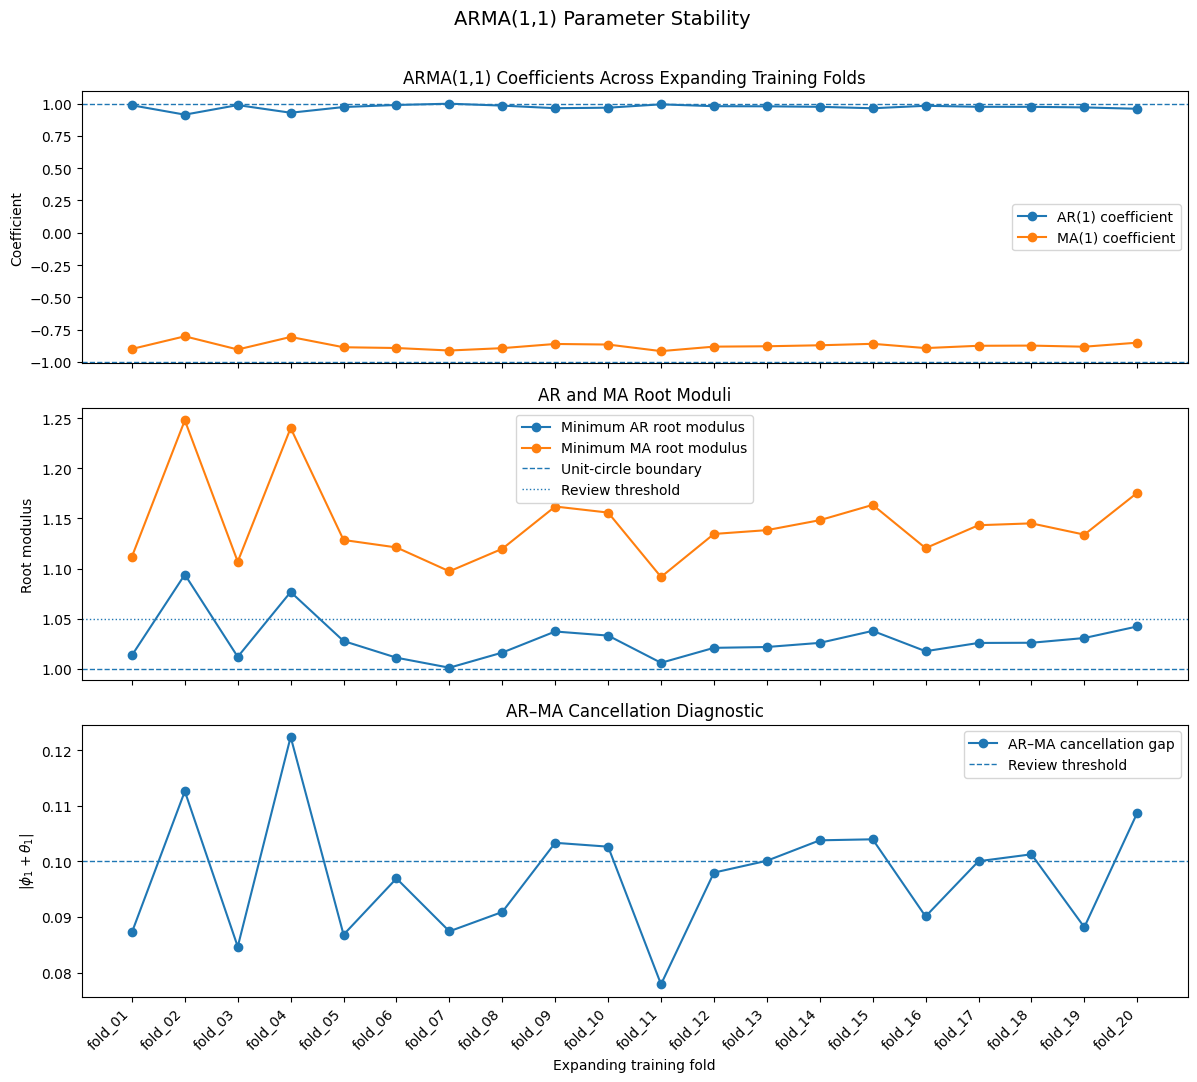

,fold_id,ar_coefficient,ma_coefficient,minimum_ar_root_modulus,minimum_ma_root_modulus,ar_half_life_days,ar_ma_cancellation_gap,ar_ma_parameter_correlation,trend_coefficient,stability_status,warning_count
0,fold_01,0.9867,-0.8994,1.0135,1.1118,51.6124,0.0872,-0.7136,0.4539,REVIEW_BOUNDARY_AND_CANCELLATION,0
1,fold_02,0.9141,-0.8015,1.0940,1.2477,7.7148,0.1126,-0.9234,0.4552,REVIEW_NONCONVERGENCE,1
2,fold_03,0.9881,-0.9035,1.0120,1.1069,58.0192,0.0847,-0.7121,0.4329,REVIEW_BOUNDARY_AND_CANCELLATION,0
3,fold_04,0.9288,-0.8064,1.0766,1.2400,9.3887,0.1224,-0.8896,0.4408,FIT_OK,0
4,fold_05,0.9730,-0.8862,1.0278,1.1285,25.3086,0.0868,-0.8194,0.4358,REVIEW_BOUNDARY_AND_CANCELLATION,0
5,fold_06,0.9890,-0.8920,1.0112,1.1210,62.4884,0.0969,-0.6611,0.4236,REVIEW_NONCONVERGENCE,1
6,fold_07,0.9988,-0.9114,1.0012,1.0972,583.4233,0.0874,-0.3422,0.4125,REVIEW_BOUNDARY_AND_CANCELLATION,0
7,fold_08,0.9840,-0.8931,1.0163,1.1197,42.9918,0.0909,-0.7043,0.4255,REVIEW_BOUNDARY_AND_CANCELLATION,0
8,fold_09,0.9641,-0.8607,1.0373,1.1618,18.9441,0.1033,-0.8229,0.4171,REVIEW_NEAR_AR_BOUNDARY,0
9,fold_10,0.9679,-0.8652,1.0332,1.1558,21.2276,0.1026,-0.8060,0.4127,REVIEW_NEAR_AR_BOUNDARY,0


,candidate_name,expected_folds,successful_fits,failed_fits,converged_fits,folds_with_warnings,minimum_ar_coefficient,maximum_ar_coefficient,minimum_ma_coefficient,maximum_ma_coefficient,minimum_ar_root_modulus,maximum_ar_root_modulus,minimum_cancellation_gap,maximum_cancellation_gap,minimum_ar_half_life_days,maximum_ar_half_life_days,folds_near_ar_boundary,folds_with_ar_ma_cancellation,minimum_trend_coefficient,maximum_trend_coefficient,review_status
0,arma11_errors,20,20,0,18,2,0.9141,0.9988,-0.9161,-0.8015,1.0012,1.0940,0.0779,0.1224,7.7148,583.4233,18,10,0.3840,0.4552,PRELIMINARY


No ARMA(1,1) fold-fit failures were recorded.
Saved stability table: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_arma11_fold_parameter_stability.csv
Saved stability figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_arma11_fold_parameter_stability.png


In [21]:
# ============================================================================
# 14. Audit ARMA(1,1) parameter stability across all training folds
# ============================================================================

ARMA11_CANDIDATE_NAME = "arma11_errors"

ARMA11_ORDER = ARIMA_ERROR_CANDIDATES[
    ARMA11_CANDIDATE_NAME
]["order"]

ARMA11_SEASONAL_ORDER = ARIMA_ERROR_CANDIDATES[
    ARMA11_CANDIDATE_NAME
]["seasonal_order"]

AR_ROOT_REVIEW_THRESHOLD = 1.05
CANCELLATION_GAP_REVIEW_THRESHOLD = 0.10


# ----------------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------------

def get_parameter_value(result, parameter_name):
    """Extract a named fitted parameter."""

    parameter_series = pd.Series(
        np.asarray(result.params, dtype=float),
        index=result.param_names,
    )

    if parameter_name not in parameter_series.index:
        return np.nan

    return float(parameter_series.loc[parameter_name])


def get_parameter_standard_error(result, parameter_name):
    """Extract a named parameter standard error."""

    standard_error_series = pd.Series(
        np.asarray(result.bse, dtype=float),
        index=result.param_names,
    )

    if parameter_name not in standard_error_series.index:
        return np.nan

    return float(
        standard_error_series.loc[parameter_name]
    )


def calculate_ar_half_life(ar_coefficient):
    """
    Calculate the approximate half-life of an AR(1) shock.

    Returns NaN when the coefficient does not represent a stable,
    nonzero AR(1) decay.
    """

    absolute_ar = abs(ar_coefficient)

    if (
        not np.isfinite(absolute_ar)
        or absolute_ar <= 0
        or absolute_ar >= 1
    ):
        return np.nan

    return float(
        np.log(0.5)
        / np.log(absolute_ar)
    )


# ----------------------------------------------------------------------------
# Fit ARMA(1,1) on every expanding training fold
# ----------------------------------------------------------------------------

arma11_stability_records = []
arma11_failure_records = []

folds_for_stability = folds_df.copy()

for date_column in [
    "train_start",
    "train_end",
    "test_start",
    "test_end",
]:
    folds_for_stability[date_column] = pd.to_datetime(
        folds_for_stability[date_column]
    )


for _, fold in folds_for_stability.iterrows():

    fold_start_time = time.perf_counter()

    train_mask = (
        modeling_dataset_with_trend[DATE_COLUMN]
        .between(
            fold["train_start"],
            fold["train_end"],
            inclusive="both",
        )
    )

    fold_training_data = (
        modeling_dataset_with_trend.loc[
            train_mask
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_target = (
        fold_training_data[LOG_TARGET_COLUMN]
        .astype(float)
    )

    fold_exog = (
        fold_training_data[
            development_model_features
        ]
        .astype(float)
    )

    assert len(fold_training_data) == int(
        fold["train_size"]
    )

    try:
        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter("always")

            fold_model = SARIMAX(
                endog=fold_target,
                exog=fold_exog,
                order=ARMA11_ORDER,
                seasonal_order=ARMA11_SEASONAL_ORDER,
                trend="c",
                enforce_stationarity=True,
                enforce_invertibility=True,
                simple_differencing=False,
            )

            fold_result = fold_model.fit(
                method="lbfgs",
                maxiter=500,
                disp=False,
            )

        fit_seconds = float(
            time.perf_counter()
            - fold_start_time
        )

        warning_messages = sorted(
            {
                str(warning.message)
                for warning in captured_warnings
            }
        )

        optimizer_converged = bool(
            fold_result
            .mle_retvals
            .get("converged", False)
        )

        ar_coefficient = get_parameter_value(
            fold_result,
            "ar.L1",
        )

        ma_coefficient = get_parameter_value(
            fold_result,
            "ma.L1",
        )

        trend_coefficient = get_parameter_value(
            fold_result,
            TREND_FEATURE,
        )

        ar_standard_error = (
            get_parameter_standard_error(
                fold_result,
                "ar.L1",
            )
        )

        ma_standard_error = (
            get_parameter_standard_error(
                fold_result,
                "ma.L1",
            )
        )

        minimum_ar_root = minimum_root_modulus(
            fold_result.arroots
        )

        minimum_ma_root = minimum_root_modulus(
            fold_result.maroots
        )

        ar_root_distance_from_unit_circle = (
            minimum_ar_root - 1.0
            if np.isfinite(minimum_ar_root)
            else np.nan
        )

        cancellation_gap = float(
            abs(
                ar_coefficient
                + ma_coefficient
            )
        )

        ar_half_life_days = (
            calculate_ar_half_life(
                ar_coefficient
            )
        )


        # --------------------------------------------------------------------
        # AR–MA parameter correlation
        # --------------------------------------------------------------------

        covariance_matrix = pd.DataFrame(
            np.asarray(
                fold_result.cov_params(),
                dtype=float,
            ),
            index=fold_result.param_names,
            columns=fold_result.param_names,
        )

        if {
            "ar.L1",
            "ma.L1",
        }.issubset(covariance_matrix.index):

            ar_ma_covariance = float(
                covariance_matrix.loc[
                    "ar.L1",
                    "ma.L1",
                ]
            )

            ar_variance = float(
                covariance_matrix.loc[
                    "ar.L1",
                    "ar.L1",
                ]
            )

            ma_variance = float(
                covariance_matrix.loc[
                    "ma.L1",
                    "ma.L1",
                ]
            )

            correlation_denominator = np.sqrt(
                ar_variance
                * ma_variance
            )

            ar_ma_parameter_correlation = (
                ar_ma_covariance
                / correlation_denominator
                if correlation_denominator > 0
                else np.nan
            )

        else:
            ar_ma_parameter_correlation = np.nan


        # --------------------------------------------------------------------
        # Fold-level review status
        # --------------------------------------------------------------------

        finite_parameter_diagnostics = bool(
            np.isfinite(
                [
                    ar_coefficient,
                    ma_coefficient,
                    ar_standard_error,
                    ma_standard_error,
                    minimum_ar_root,
                    minimum_ma_root,
                    cancellation_gap,
                ]
            ).all()
        )

        near_ar_boundary = bool(
            minimum_ar_root
            < AR_ROOT_REVIEW_THRESHOLD
        )

        near_cancellation = bool(
            cancellation_gap
            < CANCELLATION_GAP_REVIEW_THRESHOLD
        )

        if not optimizer_converged:
            stability_status = (
                "REVIEW_NONCONVERGENCE"
            )

        elif not finite_parameter_diagnostics:
            stability_status = (
                "REVIEW_NONFINITE_DIAGNOSTICS"
            )

        elif near_ar_boundary and near_cancellation:
            stability_status = (
                "REVIEW_BOUNDARY_AND_CANCELLATION"
            )

        elif near_ar_boundary:
            stability_status = (
                "REVIEW_NEAR_AR_BOUNDARY"
            )

        elif near_cancellation:
            stability_status = (
                "REVIEW_AR_MA_CANCELLATION"
            )

        else:
            stability_status = "FIT_OK"


        arma11_stability_records.append(
            {
                "fold_id": fold["fold_id"],
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "train_size": int(
                    fold["train_size"]
                ),
                "optimizer_converged": (
                    optimizer_converged
                ),
                "ar_coefficient": ar_coefficient,
                "ar_standard_error": ar_standard_error,
                "ma_coefficient": ma_coefficient,
                "ma_standard_error": ma_standard_error,
                "minimum_ar_root_modulus": (
                    minimum_ar_root
                ),
                "minimum_ma_root_modulus": (
                    minimum_ma_root
                ),
                "ar_root_distance_from_unit_circle": (
                    ar_root_distance_from_unit_circle
                ),
                "ar_half_life_days": (
                    ar_half_life_days
                ),
                "ar_ma_cancellation_gap": (
                    cancellation_gap
                ),
                "ar_ma_parameter_correlation": (
                    ar_ma_parameter_correlation
                ),
                "trend_coefficient": (
                    trend_coefficient
                ),
                "near_ar_boundary": (
                    near_ar_boundary
                ),
                "near_ar_ma_cancellation": (
                    near_cancellation
                ),
                "stability_status": (
                    stability_status
                ),
                "fit_seconds": fit_seconds,
                "warning_count": len(
                    warning_messages
                ),
                "warning_messages": (
                    " | ".join(
                        warning_messages
                    )
                ),
            }
        )

    except Exception as error:

        fit_seconds = float(
            time.perf_counter()
            - fold_start_time
        )

        arma11_failure_records.append(
            {
                "fold_id": fold["fold_id"],
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "error_type": type(error).__name__,
                "error_message": str(error),
                "fit_seconds": fit_seconds,
            }
        )


arma11_fold_parameter_stability = (
    pd.DataFrame(
        arma11_stability_records
    )
)

arma11_fold_parameter_failures = pd.DataFrame(
    arma11_failure_records,
    columns=[
        "fold_id",
        "train_start",
        "train_end",
        "error_type",
        "error_message",
        "fit_seconds",
    ],
)


# ----------------------------------------------------------------------------
# Stability summary
# ----------------------------------------------------------------------------

arma11_fold_parameter_stability_summary = pd.DataFrame(
    [
        {
            "candidate_name": ARMA11_CANDIDATE_NAME,
            "expected_folds": N_FOLDS,
            "successful_fits": len(
                arma11_fold_parameter_stability
            ),
            "failed_fits": len(
                arma11_fold_parameter_failures
            ),
            "converged_fits": int(
                arma11_fold_parameter_stability[
                    "optimizer_converged"
                ].sum()
            ),
            "folds_with_warnings": int(
                arma11_fold_parameter_stability[
                    "warning_count"
                ].gt(0).sum()
            ),
            "minimum_ar_coefficient": float(
                arma11_fold_parameter_stability[
                    "ar_coefficient"
                ].min()
            ),
            "maximum_ar_coefficient": float(
                arma11_fold_parameter_stability[
                    "ar_coefficient"
                ].max()
            ),
            "minimum_ma_coefficient": float(
                arma11_fold_parameter_stability[
                    "ma_coefficient"
                ].min()
            ),
            "maximum_ma_coefficient": float(
                arma11_fold_parameter_stability[
                    "ma_coefficient"
                ].max()
            ),
            "minimum_ar_root_modulus": float(
                arma11_fold_parameter_stability[
                    "minimum_ar_root_modulus"
                ].min()
            ),
            "maximum_ar_root_modulus": float(
                arma11_fold_parameter_stability[
                    "minimum_ar_root_modulus"
                ].max()
            ),
            "minimum_cancellation_gap": float(
                arma11_fold_parameter_stability[
                    "ar_ma_cancellation_gap"
                ].min()
            ),
            "maximum_cancellation_gap": float(
                arma11_fold_parameter_stability[
                    "ar_ma_cancellation_gap"
                ].max()
            ),
            "minimum_ar_half_life_days": float(
                arma11_fold_parameter_stability[
                    "ar_half_life_days"
                ].min()
            ),
            "maximum_ar_half_life_days": float(
                arma11_fold_parameter_stability[
                    "ar_half_life_days"
                ].max()
            ),
            "folds_near_ar_boundary": int(
                arma11_fold_parameter_stability[
                    "near_ar_boundary"
                ].sum()
            ),
            "folds_with_ar_ma_cancellation": int(
                arma11_fold_parameter_stability[
                    "near_ar_ma_cancellation"
                ].sum()
            ),
            "minimum_trend_coefficient": float(
                arma11_fold_parameter_stability[
                    "trend_coefficient"
                ].min()
            ),
            "maximum_trend_coefficient": float(
                arma11_fold_parameter_stability[
                    "trend_coefficient"
                ].max()
            ),
            "review_status": "PRELIMINARY",
        }
    ]
)


# ----------------------------------------------------------------------------
# Save tables
# ----------------------------------------------------------------------------

ARMA11_STABILITY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arma11_fold_parameter_stability.csv"
)

ARMA11_STABILITY_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arma11_fold_parameter_stability_summary.csv"
)

ARMA11_STABILITY_FAILURES_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arma11_fold_parameter_failures.csv"
)

arma11_fold_parameter_stability.to_csv(
    ARMA11_STABILITY_PATH,
    index=False,
)

arma11_fold_parameter_stability_summary.to_csv(
    ARMA11_STABILITY_SUMMARY_PATH,
    index=False,
)

arma11_fold_parameter_failures.to_csv(
    ARMA11_STABILITY_FAILURES_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Parameter-stability figure
# ----------------------------------------------------------------------------

plot_data = (
    arma11_fold_parameter_stability
    .sort_values("train_end")
    .reset_index(drop=True)
)

plot_positions = np.arange(
    1,
    len(plot_data) + 1,
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 11),
    sharex=True,
)

axes[0].plot(
    plot_positions,
    plot_data["ar_coefficient"],
    marker="o",
    label="AR(1) coefficient",
)

axes[0].plot(
    plot_positions,
    plot_data["ma_coefficient"],
    marker="o",
    label="MA(1) coefficient",
)

axes[0].axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)

axes[0].axhline(
    -1.0,
    linestyle="--",
    linewidth=1,
)

axes[0].set_title(
    "ARMA(1,1) Coefficients Across Expanding Training Folds"
)

axes[0].set_ylabel("Coefficient")
axes[0].legend()


axes[1].plot(
    plot_positions,
    plot_data["minimum_ar_root_modulus"],
    marker="o",
    label="Minimum AR root modulus",
)

axes[1].plot(
    plot_positions,
    plot_data["minimum_ma_root_modulus"],
    marker="o",
    label="Minimum MA root modulus",
)

axes[1].axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Unit-circle boundary",
)

axes[1].axhline(
    AR_ROOT_REVIEW_THRESHOLD,
    linestyle=":",
    linewidth=1,
    label="Review threshold",
)

axes[1].set_title(
    "AR and MA Root Moduli"
)

axes[1].set_ylabel("Root modulus")
axes[1].legend()


axes[2].plot(
    plot_positions,
    plot_data["ar_ma_cancellation_gap"],
    marker="o",
    label="AR–MA cancellation gap",
)

axes[2].axhline(
    CANCELLATION_GAP_REVIEW_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label="Review threshold",
)

axes[2].set_title(
    "AR–MA Cancellation Diagnostic"
)

axes[2].set_xlabel("Expanding training fold")
axes[2].set_ylabel(
    r"$|\phi_1 + \theta_1|$"
)

axes[2].set_xticks(plot_positions)

axes[2].set_xticklabels(
    plot_data["fold_id"],
    rotation=45,
    ha="right",
)

axes[2].legend()

fig.suptitle(
    "ARMA(1,1) Parameter Stability",
    fontsize=14,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

ARMA11_STABILITY_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_arma11_fold_parameter_stability.png"
)

fig.savefig(
    ARMA11_STABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs
# ----------------------------------------------------------------------------

for output_path in [
    ARMA11_STABILITY_PATH,
    ARMA11_STABILITY_SUMMARY_PATH,
    ARMA11_STABILITY_FAILURES_PATH,
    ARMA11_STABILITY_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert (
    len(arma11_fold_parameter_stability)
    + len(arma11_fold_parameter_failures)
    == N_FOLDS
), (
    "Not every fold produced either a successful fit or a recorded failure."
)


# ----------------------------------------------------------------------------
# Display results
# ----------------------------------------------------------------------------

display(
    arma11_fold_parameter_stability[
        [
            "fold_id",
            "ar_coefficient",
            "ma_coefficient",
            "minimum_ar_root_modulus",
            "minimum_ma_root_modulus",
            "ar_half_life_days",
            "ar_ma_cancellation_gap",
            "ar_ma_parameter_correlation",
            "trend_coefficient",
            "stability_status",
            "warning_count",
        ]
    ]
)

display(
    arma11_fold_parameter_stability_summary
)

if not arma11_fold_parameter_failures.empty:
    display(arma11_fold_parameter_failures)
else:
    print("No ARMA(1,1) fold-fit failures were recorded.")

print(
    "Saved stability table: "
    f"{ARMA11_STABILITY_PATH}"
)

print(
    "Saved stability figure: "
    f"{ARMA11_STABILITY_FIGURE_PATH}"
)

## 13. Targeted integrated-error alternatives

The ARMA(1,1) error model produces white-noise residuals in the development
sample, but its parameters are not sufficiently stable across expanding
training windows.

The recurring combination:

$$
\phi_1 \approx 1
$$

and

$$
\theta_1 < 0
$$

suggests that the stationary ARMA model may be approximating an integrated
error process through near-boundary and partially cancelling parameters.

Therefore, three targeted alternatives are evaluated:

$$
\operatorname{ARIMA}(0,1,0)
$$

$$
\operatorname{ARIMA}(0,1,1)
$$

$$
\operatorname{ARIMA}(1,1,0)
$$

The regression relationship remains:

$$
\log(Y_t)
=
\mathbf{x}_t^\top\boldsymbol{\beta}
+
n_t
$$

where the exogenous matrix includes calendar effects, planned promotion
intensity and the validated deterministic time trend.

No additional constant is included in the integrated models. Their stochastic
error level already represents a time-varying baseline, while
`time_index_years` represents the deterministic growth component.

The existing ARMA(1,1) levels model is retained in the comparison as a
sensitivity reference.

Information criteria remain supporting diagnostics. The main objective of this
block is to identify a compact integrated model with:

- Successful convergence.
- Finite standard errors.
- No root-boundary problems.
- Acceptable residual autocorrelation.
- Interpretable and stable parameters.

In [23]:
# ============================================================================
# 15. Evaluate targeted integrated-error alternatives
# ============================================================================

# ----------------------------------------------------------------------------
# Record the ARMA(1,1) stability decision
# ----------------------------------------------------------------------------

arma11_summary_row = (
    arma11_fold_parameter_stability_summary
    .iloc[0]
)

arma11_stability_decision = pd.DataFrame(
    [
        {
            "candidate_name": "arma11_errors",
            "previous_role": "primary_candidate",
            "updated_role": "sensitivity_only",
            "successful_fits": int(
                arma11_summary_row["successful_fits"]
            ),
            "converged_fits": int(
                arma11_summary_row["converged_fits"]
            ),
            "folds_near_ar_boundary": int(
                arma11_summary_row[
                    "folds_near_ar_boundary"
                ]
            ),
            "folds_with_ar_ma_cancellation": int(
                arma11_summary_row[
                    "folds_with_ar_ma_cancellation"
                ]
            ),
            "minimum_ar_half_life_days": float(
                arma11_summary_row[
                    "minimum_ar_half_life_days"
                ]
            ),
            "maximum_ar_half_life_days": float(
                arma11_summary_row[
                    "maximum_ar_half_life_days"
                ]
            ),
            "decision_reason": (
                "The model produced near-boundary AR roots in 18 of 20 "
                "folds, AR-MA cancellation in 10 folds, two nonconverged "
                "fits and highly unstable persistence half-lives."
            ),
            "review_status": "VALIDATED",
        }
    ]
)


# ----------------------------------------------------------------------------
# Define only the targeted integrated alternatives
# ----------------------------------------------------------------------------

INTEGRATED_ERROR_CANDIDATES = {
    "arima010_errors": {
        "order": (0, 1, 0),
        "seasonal_order": (0, 0, 0, 0),
        "trend": "n",
        "candidate_role": "integrated_reference",
        "rationale": (
            "Random-walk error level without additional AR or MA dynamics."
        ),
    },
    "arima011_errors": {
        "order": (0, 1, 1),
        "seasonal_order": (0, 0, 0, 0),
        "trend": "n",
        "candidate_role": "primary_integrated_candidate",
        "rationale": (
            "Parsimonious integrated alternative to the near-boundary "
            "ARMA(1,1) specification."
        ),
    },
    "arima110_errors": {
        "order": (1, 1, 0),
        "seasonal_order": (0, 0, 0, 0),
        "trend": "n",
        "candidate_role": "integrated_sensitivity",
        "rationale": (
            "Tests whether differenced residual persistence is better "
            "represented by an autoregressive term."
        ),
    },
}


integrated_candidate_records = []

for candidate_name, candidate in (
    INTEGRATED_ERROR_CANDIDATES.items()
):

    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]

    integrated_candidate_records.append(
        {
            "candidate_name": candidate_name,
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "P": seasonal_order[0],
            "D": seasonal_order[1],
            "Q": seasonal_order[2],
            "seasonal_period": seasonal_order[3],
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "trend_setting": candidate["trend"],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "rationale": candidate["rationale"],
            "development_status": "PENDING",
        }
    )

integrated_error_candidate_registry = pd.DataFrame(
    integrated_candidate_records
)

assert len(integrated_error_candidate_registry) == 3
assert integrated_error_candidate_registry["d"].eq(1).all()
assert integrated_error_candidate_registry["D"].eq(0).all()


# ----------------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------------

def extract_named_parameter(result, parameter_name):
    """Return a named model parameter or NaN when it is not present."""

    parameter_series = pd.Series(
        np.asarray(result.params, dtype=float),
        index=result.param_names,
    )

    return float(
        parameter_series.get(
            parameter_name,
            np.nan,
        )
    )


def extract_named_standard_error(result, parameter_name):
    """Return a named parameter standard error or NaN."""

    standard_error_series = pd.Series(
        np.asarray(result.bse, dtype=float),
        index=result.param_names,
    )

    return float(
        standard_error_series.get(
            parameter_name,
            np.nan,
        )
    )


# ----------------------------------------------------------------------------
# Fit the three integrated candidates
# ----------------------------------------------------------------------------

integrated_comparison_records = []
integrated_coefficient_records = []
integrated_ljung_box_records = []
integrated_residual_records = []
integrated_failure_records = []

fitted_integrated_development_results = {}


for candidate_name, candidate in (
    INTEGRATED_ERROR_CANDIDATES.items()
):

    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]
    trend_setting = candidate["trend"]

    fit_start_time = time.perf_counter()

    try:
        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter("always")

            candidate_model = SARIMAX(
                endog=development_model_target,
                exog=development_model_exog,
                order=order,
                seasonal_order=seasonal_order,
                trend=trend_setting,
                enforce_stationarity=True,
                enforce_invertibility=True,
                simple_differencing=False,
            )

            candidate_result = candidate_model.fit(
                method="lbfgs",
                maxiter=500,
                disp=False,
            )

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        warning_messages = sorted(
            {
                str(warning.message)
                for warning in captured_warnings
            }
        )

        optimizer_converged = bool(
            candidate_result
            .mle_retvals
            .get("converged", False)
        )

        parameter_names = list(
            candidate_result.param_names
        )

        parameter_values = np.asarray(
            candidate_result.params,
            dtype=float,
        )

        standard_errors = np.asarray(
            candidate_result.bse,
            dtype=float,
        )

        z_statistics = np.asarray(
            candidate_result.zvalues,
            dtype=float,
        )

        p_values = np.asarray(
            candidate_result.pvalues,
            dtype=float,
        )

        confidence_intervals = np.asarray(
            candidate_result.conf_int(
                alpha=0.05
            ),
            dtype=float,
        )

        finite_standard_errors = bool(
            np.isfinite(
                standard_errors
            ).all()
        )

        number_of_parameters = len(
            parameter_values
        )

        number_of_observations = int(
            candidate_result.nobs
        )

        likelihood_burn = int(
            getattr(
                candidate_result,
                "loglikelihood_burn",
                getattr(
                    candidate_result.model,
                    "loglikelihood_burn",
                    0,
                ),
            )
            or 0
        )


        # --------------------------------------------------------------------
        # Residual diagnostics
        # --------------------------------------------------------------------

        full_residuals = pd.Series(
            np.asarray(
                candidate_result.resid,
                dtype=float,
            ),
            index=development_data_with_trend.index,
            name="residual",
        )

        diagnostic_residuals = (
            full_residuals
            .iloc[likelihood_burn:]
            .dropna()
        )

        effective_observations = len(
            diagnostic_residuals
        )

        candidate_aicc = calculate_aicc(
            aic=float(candidate_result.aic),
            number_of_parameters=number_of_parameters,
            number_of_observations=effective_observations,
        )

        residual_mean = float(
            diagnostic_residuals.mean()
        )

        residual_standard_deviation = float(
            diagnostic_residuals.std(ddof=0)
        )

        residual_rmse_log = float(
            np.sqrt(
                np.mean(
                    np.square(
                        diagnostic_residuals
                    )
                )
            )
        )


        # --------------------------------------------------------------------
        # Ljung-Box test
        # --------------------------------------------------------------------

        model_degrees_of_freedom = int(
            order[0]
            + order[2]
            + seasonal_order[0]
            + seasonal_order[2]
        )

        candidate_ljung_box = (
            acorr_ljungbox(
                diagnostic_residuals,
                lags=LJUNG_BOX_LAGS,
                model_df=model_degrees_of_freedom,
                return_df=True,
            )
            .reset_index()
            .rename(
                columns={
                    "index": "lag",
                    "lb_stat": "ljung_box_statistic",
                    "lb_pvalue": "p_value",
                }
            )
        )

        candidate_ljung_box[
            "candidate_name"
        ] = candidate_name

        candidate_ljung_box[
            "model_degrees_of_freedom"
        ] = model_degrees_of_freedom

        candidate_ljung_box[
            "reject_no_autocorrelation_05"
        ] = (
            candidate_ljung_box["p_value"]
            < 0.05
        )

        integrated_ljung_box_records.extend(
            candidate_ljung_box[
                [
                    "candidate_name",
                    "lag",
                    "model_degrees_of_freedom",
                    "ljung_box_statistic",
                    "p_value",
                    "reject_no_autocorrelation_05",
                ]
            ].to_dict("records")
        )


        # --------------------------------------------------------------------
        # Root diagnostics
        # --------------------------------------------------------------------

        minimum_ar_root = minimum_root_modulus(
            candidate_result.arroots
        )

        minimum_ma_root = minimum_root_modulus(
            candidate_result.maroots
        )

        ar_root_near_boundary = bool(
            np.isfinite(minimum_ar_root)
            and minimum_ar_root
            < ROOT_BOUNDARY_REVIEW_THRESHOLD
        )

        ma_root_near_boundary = bool(
            np.isfinite(minimum_ma_root)
            and minimum_ma_root
            < ROOT_BOUNDARY_REVIEW_THRESHOLD
        )


        # --------------------------------------------------------------------
        # Screening status
        # --------------------------------------------------------------------

        if not optimizer_converged:
            screening_status = (
                "REVIEW_NONCONVERGENCE"
            )

        elif not finite_standard_errors:
            screening_status = (
                "REVIEW_STANDARD_ERRORS"
            )

        elif (
            ar_root_near_boundary
            or ma_root_near_boundary
        ):
            screening_status = (
                "REVIEW_NEAR_BOUNDARY"
            )

        else:
            screening_status = "FIT_OK"


        ljung_box_pvalues = (
            candidate_ljung_box
            .set_index("lag")["p_value"]
            .to_dict()
        )


        # --------------------------------------------------------------------
        # Model comparison record
        # --------------------------------------------------------------------

        integrated_comparison_records.append(
            {
                "candidate_name": candidate_name,
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "trend_setting": trend_setting,
                "fit_succeeded": True,
                "optimizer_converged": (
                    optimizer_converged
                ),
                "screening_status": (
                    screening_status
                ),
                "observations": (
                    number_of_observations
                ),
                "effective_observations": (
                    effective_observations
                ),
                "loglikelihood_burn": (
                    likelihood_burn
                ),
                "number_of_parameters": (
                    number_of_parameters
                ),
                "log_likelihood": float(
                    candidate_result.llf
                ),
                "aic": float(
                    candidate_result.aic
                ),
                "aicc": candidate_aicc,
                "bic": float(
                    candidate_result.bic
                ),
                "hqic": float(
                    candidate_result.hqic
                ),
                "residual_mean": residual_mean,
                "residual_standard_deviation": (
                    residual_standard_deviation
                ),
                "residual_rmse_log": (
                    residual_rmse_log
                ),
                "minimum_ar_root_modulus": (
                    minimum_ar_root
                ),
                "minimum_ma_root_modulus": (
                    minimum_ma_root
                ),
                "ar_root_near_boundary": (
                    ar_root_near_boundary
                ),
                "ma_root_near_boundary": (
                    ma_root_near_boundary
                ),
                "finite_standard_errors": (
                    finite_standard_errors
                ),
                "trend_coefficient": (
                    extract_named_parameter(
                        candidate_result,
                        TREND_FEATURE,
                    )
                ),
                "trend_standard_error": (
                    extract_named_standard_error(
                        candidate_result,
                        TREND_FEATURE,
                    )
                ),
                "ljung_box_pvalue_lag_7": float(
                    ljung_box_pvalues[7]
                ),
                "ljung_box_pvalue_lag_14": float(
                    ljung_box_pvalues[14]
                ),
                "ljung_box_pvalue_lag_21": float(
                    ljung_box_pvalues[21]
                ),
                "ljung_box_pvalue_lag_28": float(
                    ljung_box_pvalues[28]
                ),
                "ljung_box_all_lags_pass_05": bool(
                    candidate_ljung_box[
                        "p_value"
                    ].ge(0.05).all()
                ),
                "warning_count": len(
                    warning_messages
                ),
                "warning_messages": (
                    " | ".join(
                        warning_messages
                    )
                ),
                "fit_seconds": fit_seconds,
                "error_message": "",
            }
        )


        # --------------------------------------------------------------------
        # Coefficient table
        # --------------------------------------------------------------------

        for parameter_index, parameter_name in enumerate(
            parameter_names
        ):

            if parameter_name == "sigma2":
                parameter_role = (
                    "residual_variance"
                )

            elif parameter_name == TREND_FEATURE:
                parameter_role = (
                    "deterministic_trend"
                )

            elif parameter_name in development_model_features:
                parameter_role = (
                    "exogenous_regressor"
                )

            elif (
                parameter_name.startswith("ar.")
                or parameter_name.startswith("ma.")
            ):
                parameter_role = (
                    "arima_error_parameter"
                )

            else:
                parameter_role = "other"

            integrated_coefficient_records.append(
                {
                    "candidate_name": (
                        candidate_name
                    ),
                    "parameter": parameter_name,
                    "parameter_role": (
                        parameter_role
                    ),
                    "estimate": float(
                        parameter_values[
                            parameter_index
                        ]
                    ),
                    "standard_error": float(
                        standard_errors[
                            parameter_index
                        ]
                    ),
                    "z_statistic": float(
                        z_statistics[
                            parameter_index
                        ]
                    ),
                    "p_value": float(
                        p_values[
                            parameter_index
                        ]
                    ),
                    "ci_95_lower": float(
                        confidence_intervals[
                            parameter_index,
                            0,
                        ]
                    ),
                    "ci_95_upper": float(
                        confidence_intervals[
                            parameter_index,
                            1,
                        ]
                    ),
                    "statistically_significant_05": bool(
                        p_values[
                            parameter_index
                        ] < 0.05
                    ),
                }
            )


        # --------------------------------------------------------------------
        # Residual table
        # --------------------------------------------------------------------

        for residual_position, residual_value in enumerate(
            full_residuals
        ):

            integrated_residual_records.append(
                {
                    "candidate_name": (
                        candidate_name
                    ),
                    DATE_COLUMN: (
                        development_data_with_trend
                        .loc[
                            residual_position,
                            DATE_COLUMN,
                        ]
                    ),
                    "residual": float(
                        residual_value
                    ),
                    "loglikelihood_burn": (
                        likelihood_burn
                    ),
                    "used_for_diagnostics": bool(
                        residual_position
                        >= likelihood_burn
                    ),
                }
            )

        fitted_integrated_development_results[
            candidate_name
        ] = candidate_result


    except Exception as error:

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        integrated_failure_records.append(
            {
                "candidate_name": candidate_name,
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "error_type": type(error).__name__,
                "error_message": str(error),
                "fit_seconds": fit_seconds,
            }
        )

        integrated_comparison_records.append(
            {
                "candidate_name": candidate_name,
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "order": str(order),
                "seasonal_order": str(
                    seasonal_order
                ),
                "trend_setting": trend_setting,
                "fit_succeeded": False,
                "optimizer_converged": False,
                "screening_status": "FIT_FAILED",
                "observations": len(
                    development_model_target
                ),
                "effective_observations": np.nan,
                "loglikelihood_burn": np.nan,
                "number_of_parameters": np.nan,
                "log_likelihood": np.nan,
                "aic": np.nan,
                "aicc": np.nan,
                "bic": np.nan,
                "hqic": np.nan,
                "residual_mean": np.nan,
                "residual_standard_deviation": np.nan,
                "residual_rmse_log": np.nan,
                "minimum_ar_root_modulus": np.nan,
                "minimum_ma_root_modulus": np.nan,
                "ar_root_near_boundary": False,
                "ma_root_near_boundary": False,
                "finite_standard_errors": False,
                "trend_coefficient": np.nan,
                "trend_standard_error": np.nan,
                "ljung_box_pvalue_lag_7": np.nan,
                "ljung_box_pvalue_lag_14": np.nan,
                "ljung_box_pvalue_lag_21": np.nan,
                "ljung_box_pvalue_lag_28": np.nan,
                "ljung_box_all_lags_pass_05": False,
                "warning_count": 0,
                "warning_messages": "",
                "fit_seconds": fit_seconds,
                "error_message": str(error),
            }
        )


# ----------------------------------------------------------------------------
# Build output tables
# ----------------------------------------------------------------------------

development_integrated_error_comparison = (
    pd.DataFrame(
        integrated_comparison_records
    )
)

successful_integrated_mask = (
    development_integrated_error_comparison[
        "fit_succeeded"
    ]
    & development_integrated_error_comparison[
        "aicc"
    ].notna()
)

minimum_integrated_aicc = (
    development_integrated_error_comparison.loc[
        successful_integrated_mask,
        "aicc",
    ].min()
)

minimum_integrated_bic = (
    development_integrated_error_comparison.loc[
        successful_integrated_mask,
        "bic",
    ].min()
)

development_integrated_error_comparison[
    "delta_aicc_within_integrated"
] = (
    development_integrated_error_comparison[
        "aicc"
    ]
    - minimum_integrated_aicc
)

development_integrated_error_comparison[
    "delta_bic_within_integrated"
] = (
    development_integrated_error_comparison[
        "bic"
    ]
    - minimum_integrated_bic
)

development_integrated_error_comparison = (
    development_integrated_error_comparison
    .sort_values(
        [
            "fit_succeeded",
            "aicc",
        ],
        ascending=[
            False,
            True,
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)


development_integrated_error_coefficients = (
    pd.DataFrame(
        integrated_coefficient_records
    )
)

development_integrated_error_ljung_box = (
    pd.DataFrame(
        integrated_ljung_box_records
    )
)

development_integrated_error_residuals = (
    pd.DataFrame(
        integrated_residual_records
    )
)

development_integrated_error_failures = (
    pd.DataFrame(
        integrated_failure_records,
        columns=[
            "candidate_name",
            "order",
            "seasonal_order",
            "error_type",
            "error_message",
            "fit_seconds",
        ],
    )
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

INTEGRATED_CANDIDATE_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_integrated_error_candidate_registry.csv"
)

INTEGRATED_COMPARISON_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "integrated_error_comparison.csv"
    )
)

INTEGRATED_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "integrated_error_coefficients.csv"
    )
)

INTEGRATED_LJUNG_BOX_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "integrated_error_ljung_box.csv"
    )
)

INTEGRATED_RESIDUALS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "integrated_error_residuals.csv"
    )
)

INTEGRATED_FAILURES_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_development_"
        "integrated_error_failures.csv"
    )
)

ARMA11_STABILITY_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arma11_stability_decision.csv"
)


integrated_error_candidate_registry.to_csv(
    INTEGRATED_CANDIDATE_REGISTRY_PATH,
    index=False,
)

development_integrated_error_comparison.to_csv(
    INTEGRATED_COMPARISON_PATH,
    index=False,
)

development_integrated_error_coefficients.to_csv(
    INTEGRATED_COEFFICIENTS_PATH,
    index=False,
)

development_integrated_error_ljung_box.to_csv(
    INTEGRATED_LJUNG_BOX_PATH,
    index=False,
)

development_integrated_error_residuals.to_csv(
    INTEGRATED_RESIDUALS_PATH,
    index=False,
)

development_integrated_error_failures.to_csv(
    INTEGRATED_FAILURES_PATH,
    index=False,
)

arma11_stability_decision.to_csv(
    ARMA11_STABILITY_DECISION_PATH,
    index=False,
)


for output_path in [
    INTEGRATED_CANDIDATE_REGISTRY_PATH,
    INTEGRATED_COMPARISON_PATH,
    INTEGRATED_COEFFICIENTS_PATH,
    INTEGRATED_LJUNG_BOX_PATH,
    INTEGRATED_RESIDUALS_PATH,
    INTEGRATED_FAILURES_PATH,
    ARMA11_STABILITY_DECISION_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Validation controls
# ----------------------------------------------------------------------------

assert len(
    development_integrated_error_comparison
) == len(INTEGRATED_ERROR_CANDIDATES)

assert development_integrated_error_comparison[
    "candidate_name"
].is_unique

assert (
    len(development_integrated_error_comparison)
    == 3
)


# ----------------------------------------------------------------------------
# Display the relevant outputs
# ----------------------------------------------------------------------------

integrated_display_columns = [
    "candidate_name",
    "order",
    "optimizer_converged",
    "screening_status",
    "number_of_parameters",
    "aicc",
    "delta_aicc_within_integrated",
    "bic",
    "delta_bic_within_integrated",
    "residual_standard_deviation",
    "minimum_ar_root_modulus",
    "minimum_ma_root_modulus",
    "trend_coefficient",
    "trend_standard_error",
    "ljung_box_pvalue_lag_7",
    "ljung_box_pvalue_lag_14",
    "ljung_box_pvalue_lag_21",
    "ljung_box_pvalue_lag_28",
    "ljung_box_all_lags_pass_05",
    "warning_count",
]

display(
    development_integrated_error_comparison[
        integrated_display_columns
    ]
)

display(
    development_integrated_error_coefficients.loc[
        development_integrated_error_coefficients[
            "parameter_role"
        ].isin(
            [
                "arima_error_parameter",
                "deterministic_trend",
            ]
        )
    ].reset_index(drop=True)
)

display(arma11_stability_decision)

if not development_integrated_error_failures.empty:
    display(
        development_integrated_error_failures
    )
else:
    print(
        "No integrated-candidate fit failures were recorded."
    )

integrated_warning_rows = (
    development_integrated_error_comparison.loc[
        development_integrated_error_comparison[
            "warning_count"
        ].gt(0),
        [
            "candidate_name",
            "screening_status",
            "warning_count",
            "warning_messages",
        ],
    ]
)

if not integrated_warning_rows.empty:
    display(integrated_warning_rows)
else:
    print(
        "No integrated-candidate estimation warnings were recorded."
    )

print(
    "Successful integrated fits: "
    f"{int(development_integrated_error_comparison['fit_succeeded'].sum())}"
    f" / {len(development_integrated_error_comparison)}"
)

,candidate_name,order,optimizer_converged,screening_status,number_of_parameters,aicc,delta_aicc_within_integrated,bic,delta_bic_within_integrated,residual_standard_deviation,minimum_ar_root_modulus,minimum_ma_root_modulus,trend_coefficient,trend_standard_error,ljung_box_pvalue_lag_7,ljung_box_pvalue_lag_14,ljung_box_pvalue_lag_21,ljung_box_pvalue_lag_28,ljung_box_all_lags_pass_05,warning_count
0,arima011_errors,"(0, 1, 1)",True,FIT_OK,14,"-1,513.9835",0.0000,"-1,449.9323",0.0000,0.0861,NaN,1.1027,0.4373,0.1127,0.5996,0.9102,0.8385,0.7704,True,0
1,arima110_errors,"(1, 1, 0)",False,REVIEW_NONCONVERGENCE,14,"-1,288.8716",225.1119,"-1,224.8205",225.1119,0.1002,2.0285,NaN,0.3731,0.9232,0.0000,0.0000,0.0000,0.0000,False,1
2,arima010_errors,"(0, 1, 0)",True,FIT_OK,13,"-1,084.6019",429.3816,"-1,025.0897",424.8427,0.1150,NaN,NaN,0.3735,1.5707,0.0000,0.0000,0.0000,0.0000,False,0


,candidate_name,parameter,parameter_role,estimate,standard_error,z_statistic,p_value,ci_95_lower,ci_95_upper,statistically_significant_05
0,arima010_errors,time_index_years,deterministic_trend,0.3735,1.5707,0.2378,0.8120,-2.7050,3.4520,False
1,arima011_errors,time_index_years,deterministic_trend,0.4373,0.1127,3.8819,0.0001,0.2165,0.6582,True
2,arima011_errors,ma.L1,arima_error_parameter,-0.9069,0.0168,-53.9590,0.0000,-0.9398,-0.8739,True
3,arima110_errors,time_index_years,deterministic_trend,0.3731,0.9232,0.4042,0.6861,-1.4364,2.1826,False
4,arima110_errors,ar.L1,arima_error_parameter,-0.4930,0.0277,-17.8131,0.0000,-0.5472,-0.4387,True


,candidate_name,previous_role,updated_role,successful_fits,converged_fits,folds_near_ar_boundary,folds_with_ar_ma_cancellation,minimum_ar_half_life_days,maximum_ar_half_life_days,decision_reason,review_status
0,arma11_errors,primary_candidate,sensitivity_only,20,18,18,10,7.7148,583.4233,The model produced near-boundary AR roots in 1...,VALIDATED


No integrated-candidate fit failures were recorded.


,candidate_name,screening_status,warning_count,warning_messages
1,arima110_errors,REVIEW_NONCONVERGENCE,1,Maximum Likelihood optimization failed to conv...


Successful integrated fits: 3 / 3


## 14. ARIMA(0,1,1) parameter stability across training folds

The targeted integrated-error screening selects ARIMA(0,1,1) as the primary
candidate.

The model is:

$$
\log(Y_t)
=
\mathbf{x}_t^\top\boldsymbol{\beta}
+
n_t
$$

with:

$$
(1-B)n_t
=
(1+\theta_1 B)\varepsilon_t
$$

The development estimate is:

$$
\hat{\theta}_1 = -0.9069
$$

with a minimum MA-root modulus of:

$$
1.1027
$$

Unlike the stationary ARMA(1,1) model, the integrated specification does not
require an AR coefficient close to one. The stochastic level is represented
directly through first differencing.

The model is now fitted independently on all twenty expanding training
windows. The audit evaluates:

- Optimizer convergence.
- Estimation warnings.
- MA coefficient and standard error.
- MA-root modulus and invertibility.
- Deterministic-trend coefficient.
- Residual Ljung–Box diagnostics.
- Parameter stability as the training sample expands.

The model will proceed to forecast backtesting only if the parameters remain
reasonably stable and no systematic boundary or convergence problems appear.

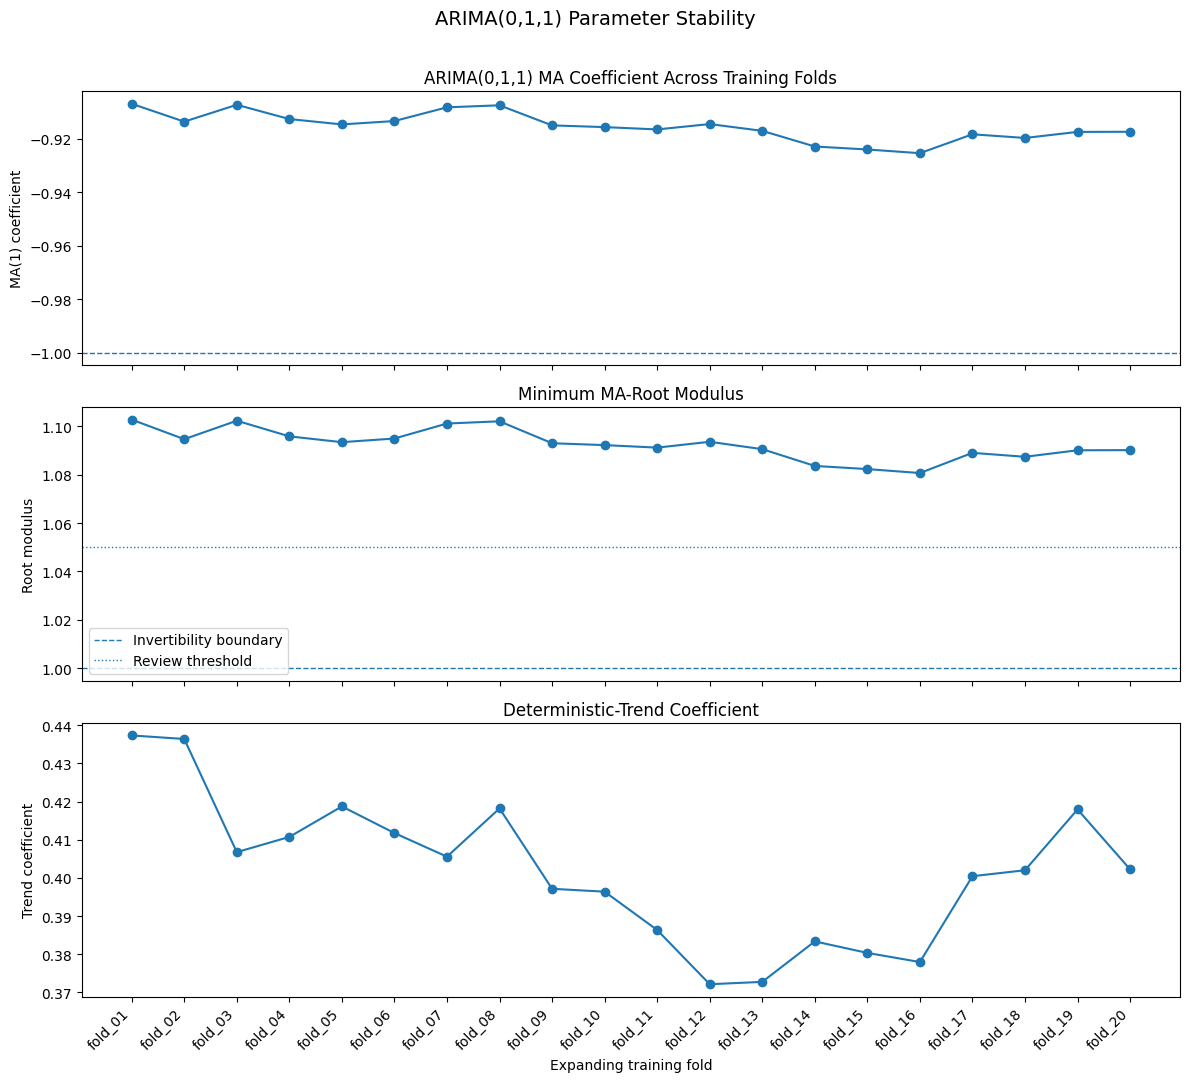

,selected_candidate,selected_order,selected_role,development_aicc,development_bic,development_residual_standard_deviation,development_ma_root_modulus,development_ljung_box_all_lags_pass_05,arma11_aicc,arma11_bic,delta_aicc_vs_arma11,delta_bic_vs_arma11,decision_reason,review_status
0,arima011_errors,"(0, 1, 1)",primary_candidate_pending_fold_stability,"-1,513.9835","-1,449.9323",0.0861,1.1027,True,"-1,520.9037","-1,447.7694",6.9202,-2.1629,"ARIMA(0,1,1) produces white-noise residuals wi...",VALIDATED


,fold_id,ma_coefficient,ma_standard_error,minimum_ma_root_modulus,trend_coefficient,trend_standard_error,ljung_box_pvalue_lag_7,ljung_box_pvalue_lag_14,ljung_box_pvalue_lag_28,stability_status,warning_count
0,fold_01,-0.9069,0.0168,1.1027,0.4373,0.1127,0.5996,0.9102,0.7704,FIT_OK,0
1,fold_02,-0.9136,0.0158,1.0946,0.4364,0.1033,0.5507,0.9038,0.7091,FIT_OK,0
2,fold_03,-0.9073,0.0163,1.1022,0.4068,0.1088,0.4890,0.8690,0.7753,FIT_OK,0
3,fold_04,-0.9126,0.0154,1.0958,0.4108,0.1011,0.5200,0.8865,0.8071,FIT_OK,0
4,fold_05,-0.9146,0.0150,1.0934,0.4187,0.0973,0.6295,0.9287,0.8462,FIT_OK,0
5,fold_06,-0.9133,0.0149,1.0949,0.4118,0.0972,0.5780,0.9240,0.8305,FIT_OK,0
6,fold_07,-0.9082,0.0150,1.1011,0.4056,0.1019,0.6818,0.8750,0.6739,FIT_OK,0
7,fold_08,-0.9075,0.0148,1.1020,0.4182,0.1000,0.6445,0.8506,0.6589,FIT_OK,0
8,fold_09,-0.9150,0.0139,1.0929,0.3972,0.0936,0.6862,0.9074,0.6770,FIT_OK,0
9,fold_10,-0.9156,0.0136,1.0922,0.3964,0.0909,0.6910,0.8816,0.6371,FIT_OK,0


,candidate_name,expected_folds,successful_fits,failed_fits,converged_fits,folds_with_warnings,folds_near_ma_boundary,folds_passing_all_ljung_box_lags,minimum_ma_coefficient,maximum_ma_coefficient,minimum_ma_root_modulus,maximum_ma_root_modulus,minimum_trend_coefficient,maximum_trend_coefficient,minimum_residual_standard_deviation,maximum_residual_standard_deviation,review_status
0,arima011_errors,20,20,0,20,0,0,20,-0.9254,-0.9069,1.0806,1.1027,0.3721,0.4373,0.0861,0.0896,PRELIMINARY


No ARIMA(0,1,1) fold-fit failures were recorded.
Saved stability table: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_arima011_fold_parameter_stability.csv
Saved stability figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_arima011_fold_parameter_stability.png


In [24]:
# ============================================================================
# 16. Audit ARIMA(0,1,1) parameter stability across all training folds
# ============================================================================

ARIMA011_CANDIDATE_NAME = "arima011_errors"

ARIMA011_ORDER = INTEGRATED_ERROR_CANDIDATES[
    ARIMA011_CANDIDATE_NAME
]["order"]

ARIMA011_SEASONAL_ORDER = INTEGRATED_ERROR_CANDIDATES[
    ARIMA011_CANDIDATE_NAME
]["seasonal_order"]

ARIMA011_TREND_SETTING = INTEGRATED_ERROR_CANDIDATES[
    ARIMA011_CANDIDATE_NAME
]["trend"]

MA_ROOT_REVIEW_THRESHOLD = 1.05


# ----------------------------------------------------------------------------
# Record the development-stage candidate decision
# ----------------------------------------------------------------------------

arima011_development_row = (
    development_integrated_error_comparison
    .loc[
        development_integrated_error_comparison[
            "candidate_name"
        ].eq(ARIMA011_CANDIDATE_NAME)
    ]
    .iloc[0]
)

arma11_development_row = (
    development_candidate_comparison
    .loc[
        development_candidate_comparison[
            "candidate_name"
        ].eq("arma11_errors")
    ]
    .iloc[0]
)

integrated_candidate_decision = pd.DataFrame(
    [
        {
            "selected_candidate": ARIMA011_CANDIDATE_NAME,
            "selected_order": str(ARIMA011_ORDER),
            "selected_role": "primary_candidate_pending_fold_stability",
            "development_aicc": float(
                arima011_development_row["aicc"]
            ),
            "development_bic": float(
                arima011_development_row["bic"]
            ),
            "development_residual_standard_deviation": float(
                arima011_development_row[
                    "residual_standard_deviation"
                ]
            ),
            "development_ma_root_modulus": float(
                arima011_development_row[
                    "minimum_ma_root_modulus"
                ]
            ),
            "development_ljung_box_all_lags_pass_05": bool(
                arima011_development_row[
                    "ljung_box_all_lags_pass_05"
                ]
            ),
            "arma11_aicc": float(
                arma11_development_row["aicc"]
            ),
            "arma11_bic": float(
                arma11_development_row["bic"]
            ),
            "delta_aicc_vs_arma11": float(
                arima011_development_row["aicc"]
                - arma11_development_row["aicc"]
            ),
            "delta_bic_vs_arma11": float(
                arima011_development_row["bic"]
                - arma11_development_row["bic"]
            ),
            "decision_reason": (
                "ARIMA(0,1,1) produces white-noise residuals with a stable "
                "invertible MA root, uses fewer parameters than ARMA(1,1), "
                "has a slightly better BIC and avoids the near-unit AR root "
                "and AR-MA cancellation observed across folds."
            ),
            "review_status": "VALIDATED",
        }
    ]
)


# ----------------------------------------------------------------------------
# Helper for named parameter extraction
# ----------------------------------------------------------------------------

def extract_parameter_diagnostics(result, parameter_name):
    """Return estimate, standard error and p-value for a fitted parameter."""

    estimates = pd.Series(
        np.asarray(result.params, dtype=float),
        index=result.param_names,
    )

    standard_errors = pd.Series(
        np.asarray(result.bse, dtype=float),
        index=result.param_names,
    )

    p_values = pd.Series(
        np.asarray(result.pvalues, dtype=float),
        index=result.param_names,
    )

    return (
        float(estimates.get(parameter_name, np.nan)),
        float(standard_errors.get(parameter_name, np.nan)),
        float(p_values.get(parameter_name, np.nan)),
    )


# ----------------------------------------------------------------------------
# Fit ARIMA(0,1,1) in every expanding training fold
# ----------------------------------------------------------------------------

arima011_stability_records = []
arima011_failure_records = []

folds_for_arima011 = folds_df.copy()

for date_column in [
    "train_start",
    "train_end",
    "test_start",
    "test_end",
]:
    folds_for_arima011[date_column] = pd.to_datetime(
        folds_for_arima011[date_column]
    )


for _, fold in folds_for_arima011.iterrows():

    fit_start_time = time.perf_counter()

    training_mask = (
        modeling_dataset_with_trend[DATE_COLUMN]
        .between(
            fold["train_start"],
            fold["train_end"],
            inclusive="both",
        )
    )

    fold_training_data = (
        modeling_dataset_with_trend.loc[
            training_mask
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_target = (
        fold_training_data[LOG_TARGET_COLUMN]
        .astype(float)
    )

    fold_exog = (
        fold_training_data[
            development_model_features
        ]
        .astype(float)
    )

    assert len(fold_training_data) == int(
        fold["train_size"]
    )

    assert fold_exog.isna().sum().sum() == 0

    assert np.isfinite(
        fold_exog.to_numpy()
    ).all()

    try:
        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter("always")

            fold_model = SARIMAX(
                endog=fold_target,
                exog=fold_exog,
                order=ARIMA011_ORDER,
                seasonal_order=ARIMA011_SEASONAL_ORDER,
                trend=ARIMA011_TREND_SETTING,
                enforce_stationarity=True,
                enforce_invertibility=True,
                simple_differencing=False,
            )

            fold_result = fold_model.fit(
                method="lbfgs",
                maxiter=500,
                disp=False,
            )

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        warning_messages = sorted(
            {
                str(warning.message)
                for warning in captured_warnings
            }
        )

        optimizer_converged = bool(
            fold_result
            .mle_retvals
            .get("converged", False)
        )


        # --------------------------------------------------------------------
        # Parameter estimates
        # --------------------------------------------------------------------

        (
            ma_coefficient,
            ma_standard_error,
            ma_p_value,
        ) = extract_parameter_diagnostics(
            fold_result,
            "ma.L1",
        )

        (
            trend_coefficient,
            trend_standard_error,
            trend_p_value,
        ) = extract_parameter_diagnostics(
            fold_result,
            TREND_FEATURE,
        )

        minimum_ma_root_modulus = minimum_root_modulus(
            fold_result.maroots
        )

        ma_root_distance_from_unit_circle = (
            minimum_ma_root_modulus - 1.0
            if np.isfinite(
                minimum_ma_root_modulus
            )
            else np.nan
        )

        near_ma_boundary = bool(
            np.isfinite(
                minimum_ma_root_modulus
            )
            and minimum_ma_root_modulus
            < MA_ROOT_REVIEW_THRESHOLD
        )


        # --------------------------------------------------------------------
        # Residual diagnostics
        # --------------------------------------------------------------------

        full_residuals = pd.Series(
            np.asarray(
                fold_result.resid,
                dtype=float,
            )
        )

        likelihood_burn = int(
            getattr(
                fold_result,
                "loglikelihood_burn",
                getattr(
                    fold_result.model,
                    "loglikelihood_burn",
                    0,
                ),
            )
            or 0
        )

        diagnostic_residuals = (
            full_residuals
            .iloc[likelihood_burn:]
            .dropna()
        )

        fold_ljung_box = (
            acorr_ljungbox(
                diagnostic_residuals,
                lags=LJUNG_BOX_LAGS,
                model_df=1,
                return_df=True,
            )
            .reset_index()
            .rename(
                columns={
                    "index": "lag",
                    "lb_stat": "ljung_box_statistic",
                    "lb_pvalue": "p_value",
                }
            )
        )

        ljung_box_pvalues = (
            fold_ljung_box
            .set_index("lag")["p_value"]
            .to_dict()
        )

        ljung_box_all_lags_pass = bool(
            fold_ljung_box["p_value"]
            .ge(0.05)
            .all()
        )


        # --------------------------------------------------------------------
        # Fold-level status
        # --------------------------------------------------------------------

        finite_diagnostics = bool(
            np.isfinite(
                [
                    ma_coefficient,
                    ma_standard_error,
                    minimum_ma_root_modulus,
                    trend_coefficient,
                    trend_standard_error,
                ]
            ).all()
        )

        if not optimizer_converged:
            stability_status = "REVIEW_NONCONVERGENCE"

        elif not finite_diagnostics:
            stability_status = "REVIEW_NONFINITE_DIAGNOSTICS"

        elif near_ma_boundary:
            stability_status = "REVIEW_NEAR_MA_BOUNDARY"

        elif not ljung_box_all_lags_pass:
            stability_status = "REVIEW_RESIDUAL_AUTOCORRELATION"

        else:
            stability_status = "FIT_OK"


        arima011_stability_records.append(
            {
                "fold_id": fold["fold_id"],
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "train_size": int(
                    fold["train_size"]
                ),
                "optimizer_converged": optimizer_converged,
                "ma_coefficient": ma_coefficient,
                "ma_standard_error": ma_standard_error,
                "ma_p_value": ma_p_value,
                "minimum_ma_root_modulus": (
                    minimum_ma_root_modulus
                ),
                "ma_root_distance_from_unit_circle": (
                    ma_root_distance_from_unit_circle
                ),
                "near_ma_boundary": near_ma_boundary,
                "trend_coefficient": trend_coefficient,
                "trend_standard_error": (
                    trend_standard_error
                ),
                "trend_p_value": trend_p_value,
                "residual_mean": float(
                    diagnostic_residuals.mean()
                ),
                "residual_standard_deviation": float(
                    diagnostic_residuals.std(
                        ddof=0
                    )
                ),
                "ljung_box_pvalue_lag_7": float(
                    ljung_box_pvalues[7]
                ),
                "ljung_box_pvalue_lag_14": float(
                    ljung_box_pvalues[14]
                ),
                "ljung_box_pvalue_lag_21": float(
                    ljung_box_pvalues[21]
                ),
                "ljung_box_pvalue_lag_28": float(
                    ljung_box_pvalues[28]
                ),
                "ljung_box_all_lags_pass_05": (
                    ljung_box_all_lags_pass
                ),
                "stability_status": stability_status,
                "warning_count": len(
                    warning_messages
                ),
                "warning_messages": " | ".join(
                    warning_messages
                ),
                "fit_seconds": fit_seconds,
            }
        )

    except Exception as error:

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        arima011_failure_records.append(
            {
                "fold_id": fold["fold_id"],
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "error_type": type(error).__name__,
                "error_message": str(error),
                "fit_seconds": fit_seconds,
            }
        )


arima011_fold_parameter_stability = pd.DataFrame(
    arima011_stability_records
)

arima011_fold_parameter_failures = pd.DataFrame(
    arima011_failure_records,
    columns=[
        "fold_id",
        "train_start",
        "train_end",
        "error_type",
        "error_message",
        "fit_seconds",
    ],
)


# ----------------------------------------------------------------------------
# Stability summary
# ----------------------------------------------------------------------------

arima011_fold_parameter_stability_summary = pd.DataFrame(
    [
        {
            "candidate_name": ARIMA011_CANDIDATE_NAME,
            "expected_folds": N_FOLDS,
            "successful_fits": len(
                arima011_fold_parameter_stability
            ),
            "failed_fits": len(
                arima011_fold_parameter_failures
            ),
            "converged_fits": int(
                arima011_fold_parameter_stability[
                    "optimizer_converged"
                ].sum()
            ),
            "folds_with_warnings": int(
                arima011_fold_parameter_stability[
                    "warning_count"
                ].gt(0)
                .sum()
            ),
            "folds_near_ma_boundary": int(
                arima011_fold_parameter_stability[
                    "near_ma_boundary"
                ].sum()
            ),
            "folds_passing_all_ljung_box_lags": int(
                arima011_fold_parameter_stability[
                    "ljung_box_all_lags_pass_05"
                ].sum()
            ),
            "minimum_ma_coefficient": float(
                arima011_fold_parameter_stability[
                    "ma_coefficient"
                ].min()
            ),
            "maximum_ma_coefficient": float(
                arima011_fold_parameter_stability[
                    "ma_coefficient"
                ].max()
            ),
            "minimum_ma_root_modulus": float(
                arima011_fold_parameter_stability[
                    "minimum_ma_root_modulus"
                ].min()
            ),
            "maximum_ma_root_modulus": float(
                arima011_fold_parameter_stability[
                    "minimum_ma_root_modulus"
                ].max()
            ),
            "minimum_trend_coefficient": float(
                arima011_fold_parameter_stability[
                    "trend_coefficient"
                ].min()
            ),
            "maximum_trend_coefficient": float(
                arima011_fold_parameter_stability[
                    "trend_coefficient"
                ].max()
            ),
            "minimum_residual_standard_deviation": float(
                arima011_fold_parameter_stability[
                    "residual_standard_deviation"
                ].min()
            ),
            "maximum_residual_standard_deviation": float(
                arima011_fold_parameter_stability[
                    "residual_standard_deviation"
                ].max()
            ),
            "review_status": "PRELIMINARY",
        }
    ]
)


# ----------------------------------------------------------------------------
# Save tables
# ----------------------------------------------------------------------------

INTEGRATED_CANDIDATE_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_integrated_candidate_decision.csv"
)

ARIMA011_STABILITY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_fold_parameter_stability.csv"
)

ARIMA011_STABILITY_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_fold_parameter_stability_summary.csv"
)

ARIMA011_FAILURES_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_fold_parameter_failures.csv"
)

integrated_candidate_decision.to_csv(
    INTEGRATED_CANDIDATE_DECISION_PATH,
    index=False,
)

arima011_fold_parameter_stability.to_csv(
    ARIMA011_STABILITY_PATH,
    index=False,
)

arima011_fold_parameter_stability_summary.to_csv(
    ARIMA011_STABILITY_SUMMARY_PATH,
    index=False,
)

arima011_fold_parameter_failures.to_csv(
    ARIMA011_FAILURES_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Parameter-stability figure
# ----------------------------------------------------------------------------

plot_data = (
    arima011_fold_parameter_stability
    .sort_values("train_end")
    .reset_index(drop=True)
)

plot_positions = np.arange(
    1,
    len(plot_data) + 1,
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 11),
    sharex=True,
)

axes[0].plot(
    plot_positions,
    plot_data["ma_coefficient"],
    marker="o",
)

axes[0].axhline(
    -1.0,
    linestyle="--",
    linewidth=1,
)

axes[0].set_title(
    "ARIMA(0,1,1) MA Coefficient Across Training Folds"
)

axes[0].set_ylabel("MA(1) coefficient")


axes[1].plot(
    plot_positions,
    plot_data["minimum_ma_root_modulus"],
    marker="o",
)

axes[1].axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Invertibility boundary",
)

axes[1].axhline(
    MA_ROOT_REVIEW_THRESHOLD,
    linestyle=":",
    linewidth=1,
    label="Review threshold",
)

axes[1].set_title(
    "Minimum MA-Root Modulus"
)

axes[1].set_ylabel("Root modulus")
axes[1].legend()


axes[2].plot(
    plot_positions,
    plot_data["trend_coefficient"],
    marker="o",
)

axes[2].set_title(
    "Deterministic-Trend Coefficient"
)

axes[2].set_xlabel("Expanding training fold")
axes[2].set_ylabel("Trend coefficient")

axes[2].set_xticks(plot_positions)

axes[2].set_xticklabels(
    plot_data["fold_id"],
    rotation=45,
    ha="right",
)

fig.suptitle(
    "ARIMA(0,1,1) Parameter Stability",
    fontsize=14,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

ARIMA011_STABILITY_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_fold_parameter_stability.png"
)

fig.savefig(
    ARIMA011_STABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs
# ----------------------------------------------------------------------------

for output_path in [
    INTEGRATED_CANDIDATE_DECISION_PATH,
    ARIMA011_STABILITY_PATH,
    ARIMA011_STABILITY_SUMMARY_PATH,
    ARIMA011_FAILURES_PATH,
    ARIMA011_STABILITY_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )

assert (
    len(arima011_fold_parameter_stability)
    + len(arima011_fold_parameter_failures)
    == N_FOLDS
), (
    "Not every fold produced either a successful fit or a recorded failure."
)


# ----------------------------------------------------------------------------
# Display results
# ----------------------------------------------------------------------------

display(integrated_candidate_decision)

display(
    arima011_fold_parameter_stability[
        [
            "fold_id",
            "ma_coefficient",
            "ma_standard_error",
            "minimum_ma_root_modulus",
            "trend_coefficient",
            "trend_standard_error",
            "ljung_box_pvalue_lag_7",
            "ljung_box_pvalue_lag_14",
            "ljung_box_pvalue_lag_28",
            "stability_status",
            "warning_count",
        ]
    ]
)

display(
    arima011_fold_parameter_stability_summary
)

if not arima011_fold_parameter_failures.empty:
    display(
        arima011_fold_parameter_failures
    )
else:
    print(
        "No ARIMA(0,1,1) fold-fit failures were recorded."
    )

print(
    "Saved stability table: "
    f"{ARIMA011_STABILITY_PATH}"
)

print(
    "Saved stability figure: "
    f"{ARIMA011_STABILITY_FIGURE_PATH}"
)

## 15. Fold-01 forecasting pipeline smoke test

The ARIMA(0,1,1) error structure passed the parameter-stability gate across all
twenty expanding training windows.

Before running the complete rolling-origin backtest, the forecasting pipeline
is validated on `fold_01` using two primary exogenous specifications:

1. `calendar_core_trend`
2. `calendar_promotion_trend`

For each specification, the model is trained through 2025-01-17 and produces a
28-day forecast for 2025-01-18 through 2025-02-14.

Because the model is estimated on the logarithmic scale, two inverse
transformations are evaluated.

The conditional median on the original scale is:

$$
\widehat{Y}_{t+h}^{\,\text{median}}
=
\exp\left(\widehat{\mu}_{t+h}\right)
$$

Under a Gaussian forecast distribution on the log scale, the conditional mean
is approximated by:

$$
\widehat{Y}_{t+h}^{\,\text{mean}}
=
\exp\left(
\widehat{\mu}_{t+h}
+
\frac{1}{2}\widehat{\sigma}_{t+h}^{2}
\right)
$$

where:

- \(\widehat{\mu}_{t+h}\) is the forecast mean on the log scale.
- \(\widehat{\sigma}_{t+h}^{2}\) is the predictive variance on the log scale.

Both versions are retained during the smoke test. The primary point-forecast
transformation will be frozen before the complete twenty-fold backtest.

The smoke test verifies:

- Exact train and test dates.
- Correct exogenous-column order.
- Twenty-eight forecasts per model.
- Positive and finite back-transformed forecasts.
- Optimizer convergence.
- Stable MA roots.
- Valid MAE, RMSE, MASE, RMSSE and mean error calculations.

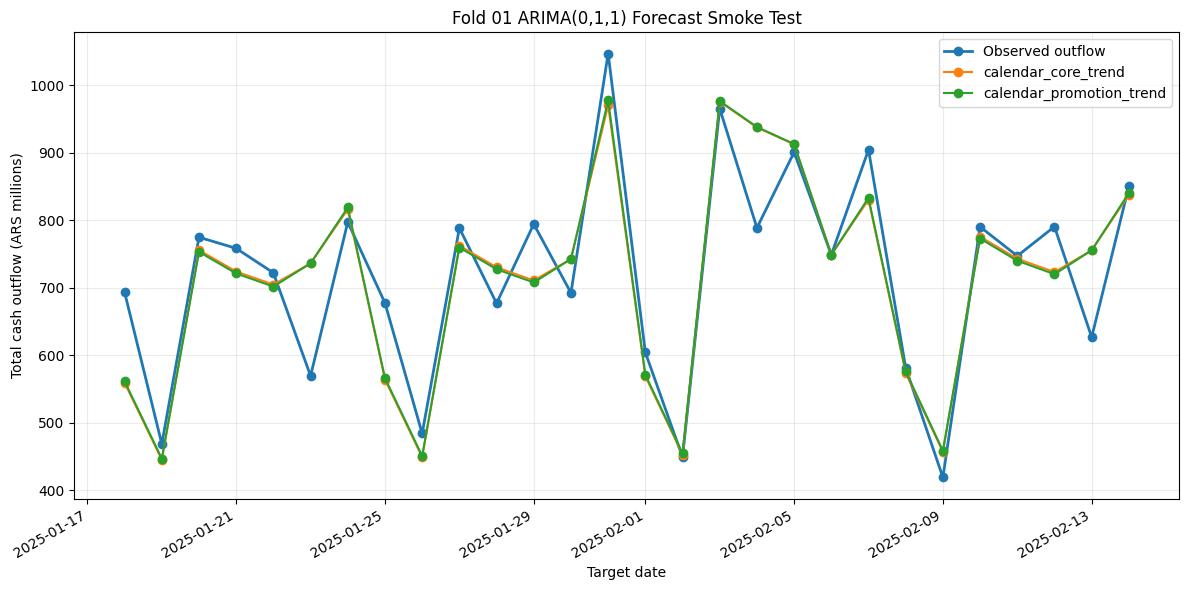

,candidate_name,order,seasonal_order,trend_setting,successful_fits,converged_fits,folds_with_warnings,folds_near_ma_boundary,folds_passing_all_ljung_box_lags,minimum_ma_coefficient,maximum_ma_coefficient,minimum_ma_root_modulus,maximum_ma_root_modulus,minimum_trend_coefficient,maximum_trend_coefficient,decision,decision_reason,review_status
0,arima011_errors,"(0, 1, 1)","(0, 0, 0, 0)",n,20,20,0,0,20,-0.9254,-0.9069,1.0806,1.1027,0.3721,0.4373,VALIDATED_FOR_FORECAST_BACKTEST,All twenty fold fits converged without warning...,VALIDATED


,check,observed,expected,status
0,prediction_row_count,56,56,PASS
1,models_evaluated,2,2,PASS
2,twenty_eight_dates_per_model,True,True,PASS
3,forecast_dates_match_fold_test_window,True,True,PASS
4,all_forecasts_positive,True,True,PASS
5,all_forecasts_finite,True,True,PASS
6,all_fits_converged,True,True,PASS
7,all_ma_roots_above_review_threshold,True,True,PASS
8,maximum_mean_to_median_ratio,1.0050,diagnostic_only,REVIEW


,model_name,number_of_exogenous_features,optimizer_converged,ma_coefficient,minimum_ma_root_modulus,trend_coefficient,warning_count,status
0,calendar_core_trend_arima011_errors,11,True,-0.8989,1.1125,0.4360,0,PASS
1,calendar_promotion_trend_arima011_errors,12,True,-0.9069,1.1027,0.4373,0,PASS


,fold_id,model_name,specification_name,point_forecast_type,observations,mae,rmse,mean_error,mase,rmsse,mean_actual,mean_prediction,promotion_days,payday_window_days,holiday_days,merchant_settlement_days
0,fold_01,calendar_core_trend_arima011_errors,calendar_core_trend,lognormal_mean,28,50.2873,69.0423,-5.2872,0.6228,0.6224,718.0036,712.7164,0,3,0,0
1,fold_01,calendar_promotion_trend_arima011_errors,calendar_promotion_trend,lognormal_mean,28,50.4183,68.7590,-5.0348,0.6244,0.6198,718.0036,712.9688,0,3,0,0
2,fold_01,calendar_core_trend_arima011_errors,calendar_core_trend,median,28,51.0469,69.1735,-8.4799,0.6322,0.6236,718.0036,709.5237,0,3,0,0
3,fold_01,calendar_promotion_trend_arima011_errors,calendar_promotion_trend,median,28,51.1243,68.8702,-7.9883,0.6331,0.6208,718.0036,710.0153,0,3,0,0


Forecast period: 2025-01-18 to 2025-02-14
Maximum mean-to-median ratio: 1.005027
Saved smoke-test figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_fold01_arima011_smoke_test_forecast.png


In [25]:
# ============================================================================
# 17. Validate the complete ARIMA(0,1,1) forecasting pipeline on fold_01
# ============================================================================

SMOKE_TEST_FOLD_ID = "fold_01"

SMOKE_TEST_SPECIFICATIONS = [
    "calendar_core_trend",
    "calendar_promotion_trend",
]

SEASONAL_SCALING_LAG = 7


# ----------------------------------------------------------------------------
# Finalize the ARIMA(0,1,1) stability decision
# ----------------------------------------------------------------------------

arima011_fold_parameter_stability_summary[
    "review_status"
] = "VALIDATED"

arima011_fold_parameter_stability_summary.to_csv(
    ARIMA011_STABILITY_SUMMARY_PATH,
    index=False,
)

arima011_stability_decision = pd.DataFrame(
    [
        {
            "candidate_name": ARIMA011_CANDIDATE_NAME,
            "order": str(ARIMA011_ORDER),
            "seasonal_order": str(
                ARIMA011_SEASONAL_ORDER
            ),
            "trend_setting": ARIMA011_TREND_SETTING,
            "successful_fits": int(
                len(
                    arima011_fold_parameter_stability
                )
            ),
            "converged_fits": int(
                arima011_fold_parameter_stability[
                    "optimizer_converged"
                ].sum()
            ),
            "folds_with_warnings": int(
                arima011_fold_parameter_stability[
                    "warning_count"
                ].gt(0).sum()
            ),
            "folds_near_ma_boundary": int(
                arima011_fold_parameter_stability[
                    "near_ma_boundary"
                ].sum()
            ),
            "folds_passing_all_ljung_box_lags": int(
                arima011_fold_parameter_stability[
                    "ljung_box_all_lags_pass_05"
                ].sum()
            ),
            "minimum_ma_coefficient": float(
                arima011_fold_parameter_stability[
                    "ma_coefficient"
                ].min()
            ),
            "maximum_ma_coefficient": float(
                arima011_fold_parameter_stability[
                    "ma_coefficient"
                ].max()
            ),
            "minimum_ma_root_modulus": float(
                arima011_fold_parameter_stability[
                    "minimum_ma_root_modulus"
                ].min()
            ),
            "maximum_ma_root_modulus": float(
                arima011_fold_parameter_stability[
                    "minimum_ma_root_modulus"
                ].max()
            ),
            "minimum_trend_coefficient": float(
                arima011_fold_parameter_stability[
                    "trend_coefficient"
                ].min()
            ),
            "maximum_trend_coefficient": float(
                arima011_fold_parameter_stability[
                    "trend_coefficient"
                ].max()
            ),
            "decision": "VALIDATED_FOR_FORECAST_BACKTEST",
            "decision_reason": (
                "All twenty fold fits converged without warnings, "
                "all MA roots remained above the review threshold, "
                "and every fold passed the residual Ljung-Box checks."
            ),
            "review_status": "VALIDATED",
        }
    ]
)

ARIMA011_STABILITY_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_stability_decision.csv"
)

arima011_stability_decision.to_csv(
    ARIMA011_STABILITY_DECISION_PATH,
    index=False,
)

assert ARIMA011_STABILITY_DECISION_PATH.exists()


# ----------------------------------------------------------------------------
# Select and validate fold_01
# ----------------------------------------------------------------------------

smoke_test_fold = (
    folds_df.loc[
        folds_df["fold_id"].eq(
            SMOKE_TEST_FOLD_ID
        )
    ]
    .iloc[0]
    .copy()
)

for date_column in [
    "train_start",
    "train_end",
    "test_start",
    "test_end",
]:
    smoke_test_fold[date_column] = pd.to_datetime(
        smoke_test_fold[date_column]
    )


train_mask = (
    modeling_dataset_with_trend[DATE_COLUMN]
    .between(
        smoke_test_fold["train_start"],
        smoke_test_fold["train_end"],
        inclusive="both",
    )
)

test_mask = (
    modeling_dataset_with_trend[DATE_COLUMN]
    .between(
        smoke_test_fold["test_start"],
        smoke_test_fold["test_end"],
        inclusive="both",
    )
)

smoke_train_data = (
    modeling_dataset_with_trend.loc[
        train_mask
    ]
    .copy()
    .reset_index(drop=True)
)

smoke_test_data = (
    modeling_dataset_with_trend.loc[
        test_mask
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(smoke_train_data) == int(
    smoke_test_fold["train_size"]
)

assert len(smoke_test_data) == FORECAST_HORIZON

assert (
    smoke_train_data[DATE_COLUMN].max()
    < smoke_test_data[DATE_COLUMN].min()
)


# ----------------------------------------------------------------------------
# Seasonal scaling denominators calculated only from training observations
# ----------------------------------------------------------------------------

training_target_original = (
    smoke_train_data[TARGET_COLUMN]
    .to_numpy(dtype=float)
)

seasonal_differences = (
    training_target_original[
        SEASONAL_SCALING_LAG:
    ]
    - training_target_original[
        :-SEASONAL_SCALING_LAG
    ]
)

mase_denominator = float(
    np.mean(
        np.abs(
            seasonal_differences
        )
    )
)

rmsse_denominator = float(
    np.sqrt(
        np.mean(
            np.square(
                seasonal_differences
            )
        )
    )
)

assert mase_denominator > 0
assert rmsse_denominator > 0


# ----------------------------------------------------------------------------
# Fit and forecast helper
# ----------------------------------------------------------------------------

def fit_arima011_forecast(
    train_data,
    test_data,
    specification_name,
):
    """
    Fit ARIMA(0,1,1) errors with a fixed known-future exogenous specification.

    Returns:
        predictions, metrics, fit audit and coefficient tables.
    """

    features = MODELING_SPECIFICATIONS[
        specification_name
    ]["features"]

    train_target = (
        train_data[LOG_TARGET_COLUMN]
        .astype(float)
    )

    train_exog = (
        train_data[features]
        .astype(float)
    )

    future_exog = (
        test_data[features]
        .astype(float)
    )

    assert list(
        train_exog.columns
    ) == list(
        future_exog.columns
    )

    assert train_exog.isna().sum().sum() == 0
    assert future_exog.isna().sum().sum() == 0

    assert np.isfinite(
        train_exog.to_numpy()
    ).all()

    assert np.isfinite(
        future_exog.to_numpy()
    ).all()


    fit_start_time = time.perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter("always")

        model = SARIMAX(
            endog=train_target,
            exog=train_exog,
            order=ARIMA011_ORDER,
            seasonal_order=ARIMA011_SEASONAL_ORDER,
            trend=ARIMA011_TREND_SETTING,
            enforce_stationarity=True,
            enforce_invertibility=True,
            simple_differencing=False,
        )

        result = model.fit(
            method="lbfgs",
            maxiter=500,
            disp=False,
        )

    fit_seconds = float(
        time.perf_counter()
        - fit_start_time
    )

    warning_messages = sorted(
        {
            str(warning.message)
            for warning in captured_warnings
        }
    )

    optimizer_converged = bool(
        result
        .mle_retvals
        .get("converged", False)
    )

    assert optimizer_converged, (
        f"{specification_name} did not converge."
    )


    # ------------------------------------------------------------------------
    # Forecast on the log scale
    # ------------------------------------------------------------------------

    forecast_result = result.get_forecast(
        steps=len(test_data),
        exog=future_exog,
    )

    forecast_log_mean = np.asarray(
        forecast_result.predicted_mean,
        dtype=float,
    )

    if hasattr(
        forecast_result,
        "var_pred_mean",
    ):
        forecast_log_variance = np.asarray(
            forecast_result.var_pred_mean,
            dtype=float,
        )
    else:
        forecast_log_variance = np.square(
            np.asarray(
                forecast_result.se_mean,
                dtype=float,
            )
        )

    forecast_log_variance = np.maximum(
        forecast_log_variance,
        0.0,
    )

    assert len(forecast_log_mean) == len(
        test_data
    )

    assert len(forecast_log_variance) == len(
        test_data
    )

    assert np.isfinite(
        forecast_log_mean
    ).all()

    assert np.isfinite(
        forecast_log_variance
    ).all()


    # ------------------------------------------------------------------------
    # Original-scale inverse transformations
    # ------------------------------------------------------------------------

    forecast_median = np.exp(
        forecast_log_mean
    )

    forecast_lognormal_mean = np.exp(
        forecast_log_mean
        + 0.5 * forecast_log_variance
    )

    actual_values = (
        test_data[TARGET_COLUMN]
        .to_numpy(dtype=float)
    )

    model_name = (
        f"{specification_name}_"
        f"{ARIMA011_CANDIDATE_NAME}"
    )


    # ------------------------------------------------------------------------
    # Prediction table
    # ------------------------------------------------------------------------

    prediction_table = pd.DataFrame(
        {
            "fold_id": SMOKE_TEST_FOLD_ID,
            "model_name": model_name,
            "specification_name": specification_name,
            "forecast_origin": (
                smoke_test_fold["train_end"]
            ),
            "target_date": (
                test_data[DATE_COLUMN]
                .to_numpy()
            ),
            "forecast_horizon": np.arange(
                1,
                len(test_data) + 1,
            ),
            "actual": actual_values,
            "forecast_log_mean": (
                forecast_log_mean
            ),
            "forecast_log_variance": (
                forecast_log_variance
            ),
            "forecast_median": forecast_median,
            "forecast_lognormal_mean": (
                forecast_lognormal_mean
            ),
            "mean_to_median_ratio": (
                forecast_lognormal_mean
                / forecast_median
            ),
            "is_month_end": (
                test_data["is_month_end"]
                .to_numpy(dtype=int)
            ),
            "is_holiday": (
                test_data["is_holiday"]
                .to_numpy(dtype=int)
            ),
            "is_payday": (
                test_data["is_payday"]
                .to_numpy(dtype=int)
            ),
            "is_payday_window": (
                test_data["is_payday_window"]
                .to_numpy(dtype=int)
            ),
            "promotion_intensity": (
                test_data[
                    "promotion_intensity"
                ].to_numpy(dtype=float)
            ),
            "merchant_settlement_intensity": (
                test_data[
                    "merchant_settlement_intensity"
                ].to_numpy(dtype=float)
            ),
        }
    )

    prediction_table["is_promotion"] = (
        prediction_table[
            "promotion_intensity"
        ].gt(0).astype(int)
    )

    prediction_table[
        "is_large_merchant_settlement"
    ] = (
        prediction_table[
            "merchant_settlement_intensity"
        ].gt(0).astype(int)
    )


    # ------------------------------------------------------------------------
    # Point-forecast metrics
    # ------------------------------------------------------------------------

    metric_records = []

    point_forecast_columns = {
        "median": "forecast_median",
        "lognormal_mean": (
            "forecast_lognormal_mean"
        ),
    }

    for (
        point_forecast_type,
        forecast_column,
    ) in point_forecast_columns.items():

        predictions = prediction_table[
            forecast_column
        ].to_numpy(dtype=float)

        errors = (
            predictions
            - actual_values
        )

        mae = float(
            np.mean(
                np.abs(errors)
            )
        )

        rmse = float(
            np.sqrt(
                np.mean(
                    np.square(errors)
                )
            )
        )

        mean_error = float(
            np.mean(errors)
        )

        metric_records.append(
            {
                "fold_id": SMOKE_TEST_FOLD_ID,
                "model_name": model_name,
                "specification_name": (
                    specification_name
                ),
                "point_forecast_type": (
                    point_forecast_type
                ),
                "observations": len(
                    prediction_table
                ),
                "mae": mae,
                "rmse": rmse,
                "mean_error": mean_error,
                "mase": float(
                    mae
                    / mase_denominator
                ),
                "rmsse": float(
                    rmse
                    / rmsse_denominator
                ),
                "mean_actual": float(
                    np.mean(
                        actual_values
                    )
                ),
                "mean_prediction": float(
                    np.mean(
                        predictions
                    )
                ),
                "promotion_days": int(
                    prediction_table[
                        "is_promotion"
                    ].sum()
                ),
                "payday_window_days": int(
                    prediction_table[
                        "is_payday_window"
                    ].sum()
                ),
                "holiday_days": int(
                    prediction_table[
                        "is_holiday"
                    ].sum()
                ),
                "merchant_settlement_days": int(
                    prediction_table[
                        "is_large_merchant_settlement"
                    ].sum()
                ),
            }
        )

    metrics_table = pd.DataFrame(
        metric_records
    )


    # ------------------------------------------------------------------------
    # Fit audit
    # ------------------------------------------------------------------------

    minimum_ma_root = minimum_root_modulus(
        result.maroots
    )

    ma_coefficient = extract_named_parameter(
        result,
        "ma.L1",
    )

    trend_coefficient = extract_named_parameter(
        result,
        TREND_FEATURE,
    )

    fit_audit = pd.DataFrame(
        [
            {
                "fold_id": SMOKE_TEST_FOLD_ID,
                "model_name": model_name,
                "specification_name": (
                    specification_name
                ),
                "train_start": (
                    train_data[
                        DATE_COLUMN
                    ].min()
                ),
                "train_end": (
                    train_data[
                        DATE_COLUMN
                    ].max()
                ),
                "test_start": (
                    test_data[
                        DATE_COLUMN
                    ].min()
                ),
                "test_end": (
                    test_data[
                        DATE_COLUMN
                    ].max()
                ),
                "train_observations": len(
                    train_data
                ),
                "test_observations": len(
                    test_data
                ),
                "number_of_exogenous_features": (
                    len(features)
                ),
                "feature_list": " | ".join(
                    features
                ),
                "optimizer_converged": (
                    optimizer_converged
                ),
                "ma_coefficient": (
                    ma_coefficient
                ),
                "minimum_ma_root_modulus": (
                    minimum_ma_root
                ),
                "trend_coefficient": (
                    trend_coefficient
                ),
                "aic": float(
                    result.aic
                ),
                "bic": float(
                    result.bic
                ),
                "fit_seconds": fit_seconds,
                "warning_count": len(
                    warning_messages
                ),
                "warning_messages": " | ".join(
                    warning_messages
                ),
                "status": (
                    "PASS"
                    if (
                        optimizer_converged
                        and minimum_ma_root
                        > MA_ROOT_REVIEW_THRESHOLD
                        and len(
                            warning_messages
                        ) == 0
                    )
                    else "REVIEW"
                ),
            }
        ]
    )


    # ------------------------------------------------------------------------
    # Coefficient table
    # ------------------------------------------------------------------------

    confidence_intervals = np.asarray(
        result.conf_int(alpha=0.05),
        dtype=float,
    )

    coefficient_table = pd.DataFrame(
        {
            "fold_id": SMOKE_TEST_FOLD_ID,
            "model_name": model_name,
            "specification_name": (
                specification_name
            ),
            "parameter": result.param_names,
            "estimate": np.asarray(
                result.params,
                dtype=float,
            ),
            "standard_error": np.asarray(
                result.bse,
                dtype=float,
            ),
            "p_value": np.asarray(
                result.pvalues,
                dtype=float,
            ),
            "ci_95_lower": (
                confidence_intervals[:, 0]
            ),
            "ci_95_upper": (
                confidence_intervals[:, 1]
            ),
        }
    )

    return (
        prediction_table,
        metrics_table,
        fit_audit,
        coefficient_table,
    )


# ----------------------------------------------------------------------------
# Execute both primary specifications
# ----------------------------------------------------------------------------

prediction_outputs = []
metric_outputs = []
fit_audit_outputs = []
coefficient_outputs = []

for specification_name in (
    SMOKE_TEST_SPECIFICATIONS
):

    (
        prediction_table,
        metrics_table,
        fit_audit,
        coefficient_table,
    ) = fit_arima011_forecast(
        train_data=smoke_train_data,
        test_data=smoke_test_data,
        specification_name=(
            specification_name
        ),
    )

    prediction_outputs.append(
        prediction_table
    )

    metric_outputs.append(
        metrics_table
    )

    fit_audit_outputs.append(
        fit_audit
    )

    coefficient_outputs.append(
        coefficient_table
    )


smoke_test_predictions = pd.concat(
    prediction_outputs,
    ignore_index=True,
)

smoke_test_metrics = pd.concat(
    metric_outputs,
    ignore_index=True,
)

smoke_test_fit_audit = pd.concat(
    fit_audit_outputs,
    ignore_index=True,
)

smoke_test_coefficients = pd.concat(
    coefficient_outputs,
    ignore_index=True,
)


# ----------------------------------------------------------------------------
# Pipeline-level validation
# ----------------------------------------------------------------------------

expected_prediction_rows = (
    len(SMOKE_TEST_SPECIFICATIONS)
    * FORECAST_HORIZON
)

model_date_counts = (
    smoke_test_predictions
    .groupby("model_name")[
        "target_date"
    ]
    .nunique()
)

test_date_set = set(
    smoke_test_data[DATE_COLUMN]
)

dates_match_test_window = bool(
    smoke_test_predictions
    .groupby("model_name")[
        "target_date"
    ]
    .apply(
        lambda values: (
            set(
                pd.to_datetime(values)
            )
            == test_date_set
        )
    )
    .all()
)

all_forecasts_positive = bool(
    smoke_test_predictions[
        [
            "forecast_median",
            "forecast_lognormal_mean",
        ]
    ]
    .gt(0)
    .all()
    .all()
)

all_forecasts_finite = bool(
    np.isfinite(
        smoke_test_predictions[
            [
                "forecast_log_mean",
                "forecast_log_variance",
                "forecast_median",
                "forecast_lognormal_mean",
            ]
        ].to_numpy()
    ).all()
)

pipeline_audit = pd.DataFrame(
    [
        {
            "check": "prediction_row_count",
            "observed": len(
                smoke_test_predictions
            ),
            "expected": (
                expected_prediction_rows
            ),
            "status": (
                "PASS"
                if len(
                    smoke_test_predictions
                )
                == expected_prediction_rows
                else "FAIL"
            ),
        },
        {
            "check": "models_evaluated",
            "observed": (
                smoke_test_predictions[
                    "model_name"
                ].nunique()
            ),
            "expected": len(
                SMOKE_TEST_SPECIFICATIONS
            ),
            "status": (
                "PASS"
                if smoke_test_predictions[
                    "model_name"
                ].nunique()
                == len(
                    SMOKE_TEST_SPECIFICATIONS
                )
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_dates_per_model",
            "observed": bool(
                model_date_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if model_date_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "forecast_dates_match_fold_test_window",
            "observed": (
                dates_match_test_window
            ),
            "expected": True,
            "status": (
                "PASS"
                if dates_match_test_window
                else "FAIL"
            ),
        },
        {
            "check": "all_forecasts_positive",
            "observed": (
                all_forecasts_positive
            ),
            "expected": True,
            "status": (
                "PASS"
                if all_forecasts_positive
                else "FAIL"
            ),
        },
        {
            "check": "all_forecasts_finite",
            "observed": (
                all_forecasts_finite
            ),
            "expected": True,
            "status": (
                "PASS"
                if all_forecasts_finite
                else "FAIL"
            ),
        },
        {
            "check": "all_fits_converged",
            "observed": bool(
                smoke_test_fit_audit[
                    "optimizer_converged"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if smoke_test_fit_audit[
                    "optimizer_converged"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "all_ma_roots_above_review_threshold",
            "observed": bool(
                smoke_test_fit_audit[
                    "minimum_ma_root_modulus"
                ].gt(
                    MA_ROOT_REVIEW_THRESHOLD
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if smoke_test_fit_audit[
                    "minimum_ma_root_modulus"
                ].gt(
                    MA_ROOT_REVIEW_THRESHOLD
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "maximum_mean_to_median_ratio",
            "observed": float(
                smoke_test_predictions[
                    "mean_to_median_ratio"
                ].max()
            ),
            "expected": "diagnostic_only",
            "status": "REVIEW",
        },
    ]
)


# ----------------------------------------------------------------------------
# Save all generated tables
# ----------------------------------------------------------------------------

SMOKE_PREDICTIONS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold01_"
        "arima011_smoke_test_predictions.csv"
    )
)

SMOKE_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold01_"
        "arima011_smoke_test_metrics.csv"
    )
)

SMOKE_FIT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold01_"
        "arima011_smoke_test_fit_audit.csv"
    )
)

SMOKE_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold01_"
        "arima011_smoke_test_coefficients.csv"
    )
)

SMOKE_PIPELINE_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold01_"
        "arima011_smoke_test_pipeline_audit.csv"
    )
)

smoke_test_predictions.to_csv(
    SMOKE_PREDICTIONS_PATH,
    index=False,
)

smoke_test_metrics.to_csv(
    SMOKE_METRICS_PATH,
    index=False,
)

smoke_test_fit_audit.to_csv(
    SMOKE_FIT_AUDIT_PATH,
    index=False,
)

smoke_test_coefficients.to_csv(
    SMOKE_COEFFICIENTS_PATH,
    index=False,
)

pipeline_audit.to_csv(
    SMOKE_PIPELINE_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Forecast figure
# ----------------------------------------------------------------------------

forecast_mean_pivot = (
    smoke_test_predictions
    .pivot(
        index="target_date",
        columns="specification_name",
        values="forecast_lognormal_mean",
    )
    .sort_index()
)

actual_series = (
    smoke_test_predictions
    .drop_duplicates(
        subset=["target_date"]
    )
    .set_index("target_date")[
        "actual"
    ]
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    actual_series.index,
    actual_series.values,
    marker="o",
    linewidth=2,
    label="Observed outflow",
)

for specification_name in (
    SMOKE_TEST_SPECIFICATIONS
):
    ax.plot(
        forecast_mean_pivot.index,
        forecast_mean_pivot[
            specification_name
        ],
        marker="o",
        label=specification_name,
    )

promotion_dates = (
    smoke_test_predictions.loc[
        smoke_test_predictions[
            "is_promotion"
        ].eq(1),
        "target_date",
    ]
    .drop_duplicates()
)

for promotion_date in promotion_dates:
    ax.axvline(
        promotion_date,
        linestyle=":",
        linewidth=1,
        alpha=0.5,
    )

ax.set_title(
    "Fold 01 ARIMA(0,1,1) Forecast Smoke Test"
)

ax.set_xlabel("Target date")
ax.set_ylabel(
    "Total cash outflow (ARS millions)"
)

ax.legend()
ax.grid(alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()

SMOKE_FORECAST_FIGURE_PATH = (
    FIGURES_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold01_"
        "arima011_smoke_test_forecast.png"
    )
)

fig.savefig(
    SMOKE_FORECAST_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify output existence and critical checks
# ----------------------------------------------------------------------------

for output_path in [
    ARIMA011_STABILITY_DECISION_PATH,
    SMOKE_PREDICTIONS_PATH,
    SMOKE_METRICS_PATH,
    SMOKE_FIT_AUDIT_PATH,
    SMOKE_COEFFICIENTS_PATH,
    SMOKE_PIPELINE_AUDIT_PATH,
    SMOKE_FORECAST_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: "
        f"{output_path}"
    )


assert pipeline_audit.loc[
    pipeline_audit["status"].eq("FAIL")
].empty, (
    "The fold-01 forecasting pipeline failed at least one audit."
)


# ----------------------------------------------------------------------------
# Display the outputs required for review
# ----------------------------------------------------------------------------

display(arima011_stability_decision)

display(pipeline_audit)

display(
    smoke_test_fit_audit[
        [
            "model_name",
            "number_of_exogenous_features",
            "optimizer_converged",
            "ma_coefficient",
            "minimum_ma_root_modulus",
            "trend_coefficient",
            "warning_count",
            "status",
        ]
    ]
)

display(
    smoke_test_metrics.sort_values(
        [
            "point_forecast_type",
            "mae",
        ]
    ).reset_index(drop=True)
)

print(
    "Forecast period: "
    f"{smoke_test_data[DATE_COLUMN].min().date()} "
    "to "
    f"{smoke_test_data[DATE_COLUMN].max().date()}"
)

print(
    "Maximum mean-to-median ratio: "
    f"{smoke_test_predictions['mean_to_median_ratio'].max():.6f}"
)

print(
    "Saved smoke-test figure: "
    f"{SMOKE_FORECAST_FIGURE_PATH}"
)

## 16. Full rolling-origin backtest of the primary ARIMA(0,1,1) models

The fold-01 smoke test validates the complete forecasting pipeline.

The original-scale point forecast is frozen as the conditional lognormal mean:

$$
\widehat{Y}_{t+h}
=
\exp\left(
\widehat{\mu}_{t+h}
+
\frac{1}{2}\widehat{\sigma}_{t+h}^{2}
\right)
$$

This transformation is selected because it represents the expected outflow
under the Gaussian log-scale forecast distribution and produced lower MAE and
less negative bias than the conditional median in the smoke test.

Two primary exogenous specifications are now evaluated:

1. `calendar_core_trend`
2. `calendar_promotion_trend`

Both use the validated ARIMA error structure:

$$
n_t
\sim
\operatorname{ARIMA}(0,1,1)
$$

The complete evaluation uses:

- Twenty expanding-window folds.
- A 28-day forecast horizon.
- A 28-day step.
- Exactly the same folds used for the benchmarks and ETS models.
- Training-only MASE and RMSSE scaling denominators.
- Known-future exogenous values only.

This block generates the forecasts and general performance metrics. Event-level
performance and comparison against Notebook 03 will be reviewed only after the
backtest pipeline passes all structural checks.

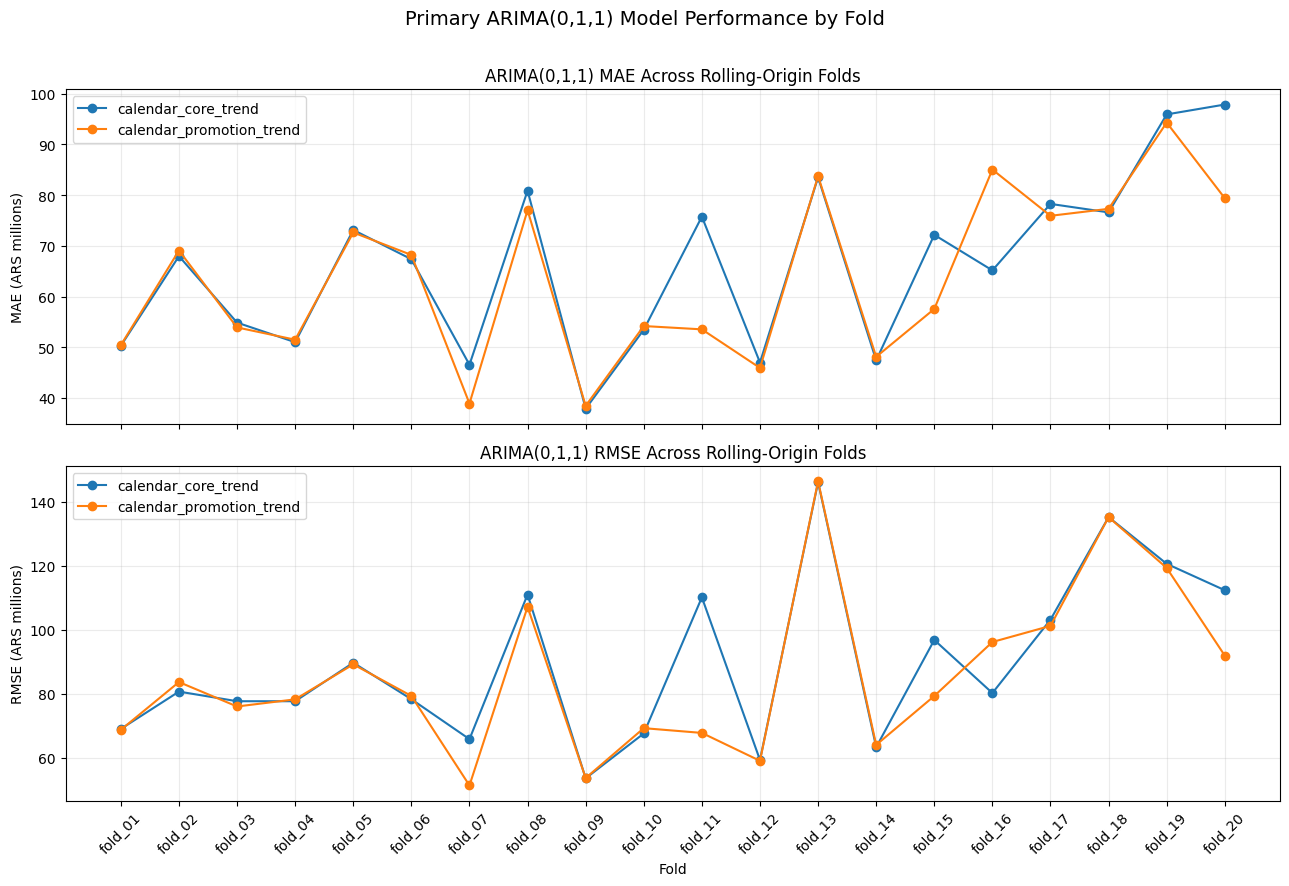

The backtest was completed, but at least one fold-model combination requires targeted review.


,check,observed,expected,status
5,all_fits_converged,False,True,FAIL
6,all_fit_statuses_pass,False,True,FAIL


,selected_transformation,definition,interpretation,maximum_smoke_test_mean_to_median_ratio,mean_mae_across_smoke_models,median_mae_across_smoke_models,mean_absolute_bias_across_smoke_models,median_absolute_bias_across_smoke_models,decision_reason,review_status
0,lognormal_mean,exp(forecast_log_mean + 0.5 * forecast_log_var...,Conditional mean on the original scale under a...,1.0050,50.3528,51.0856,5.1610,8.2341,The lognormal mean represents expected cash ou...,VALIDATED


,check,observed,expected,status
0,expected_model_fits,40,40,PASS
1,expected_prediction_rows,1120,1120,PASS
2,expected_fold_metric_rows,40,40,PASS
3,twenty_eight_horizons_per_fold_model,True,True,PASS
4,twenty_eight_dates_per_fold_model,True,True,PASS
5,all_fits_converged,False,True,FAIL
6,all_fit_statuses_pass,False,True,FAIL
7,all_ma_roots_above_review_threshold,True,True,PASS
8,all_predictions_positive,True,True,PASS
9,all_predictions_finite,True,True,PASS


,model_name,specification_name,point_forecast_type,folds_evaluated,predictions,mae,rmse,mean_error,mean_actual,mean_prediction,mean_fold_mase,mean_fold_rmsse,fold_mae_standard_deviation,fold_rmse_standard_deviation,minimum_fold_mae,maximum_fold_mae,promotion_days,merchant_settlement_days
0,calendar_promotion_trend_arima011_errors,calendar_promotion_trend,lognormal_mean,20,560,63.7503,89.4678,4.4592,907.6713,912.1305,0.6664,0.6491,16.4488,25.7694,38.4542,94.2808,16,3
1,calendar_core_trend_arima011_errors,calendar_core_trend,lognormal_mean,20,560,66.1449,93.4276,3.7437,907.6713,911.4150,0.6902,0.6787,17.0372,25.9727,37.8922,97.8412,16,3


,specification_name,fits,converged_fits,minimum_ma_root,maximum_ma_root,minimum_trend_coefficient,maximum_trend_coefficient,minimum_promotion_coefficient,maximum_promotion_coefficient,folds_with_warnings,passed_fits
0,calendar_core_trend,20,19,1.0865,1.1125,0.3728,0.4360,NaN,NaN,1,19
1,calendar_promotion_trend,20,20,1.0806,1.1027,0.3721,0.4373,1.0836,1.1362,0,20


No backtest fit failures were recorded.
Backtest predictions: 1,120
Backtest model fits: 40
Saved aggregate metrics: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_arima011_backtest_aggregate_metrics.csv
Saved fold-performance figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_arima011_backtest_metrics_by_fold.png


In [29]:
# ============================================================================
# 18. Run the complete rolling-origin ARIMA(0,1,1) backtest
# ============================================================================

BACKTEST_SPECIFICATIONS = [
    "calendar_core_trend",
    "calendar_promotion_trend",
]

POINT_FORECAST_TYPE = "lognormal_mean"
POINT_FORECAST_COLUMN = "prediction"

SEASONAL_SCALING_LAG = 7


# ----------------------------------------------------------------------------
# Freeze the point-forecast transformation decision
# ----------------------------------------------------------------------------

smoke_mean_metrics = (
    smoke_test_metrics.loc[
        smoke_test_metrics[
            "point_forecast_type"
        ].eq("lognormal_mean")
    ]
    .copy()
)

smoke_median_metrics = (
    smoke_test_metrics.loc[
        smoke_test_metrics[
            "point_forecast_type"
        ].eq("median")
    ]
    .copy()
)

point_forecast_transformation_decision = pd.DataFrame(
    [
        {
            "selected_transformation": POINT_FORECAST_TYPE,
            "definition": (
                "exp(forecast_log_mean "
                "+ 0.5 * forecast_log_variance)"
            ),
            "interpretation": (
                "Conditional mean on the original scale "
                "under a Gaussian log-scale forecast."
            ),
            "maximum_smoke_test_mean_to_median_ratio": float(
                smoke_test_predictions[
                    "mean_to_median_ratio"
                ].max()
            ),
            "mean_mae_across_smoke_models": float(
                smoke_mean_metrics["mae"].mean()
            ),
            "median_mae_across_smoke_models": float(
                smoke_median_metrics["mae"].mean()
            ),
            "mean_absolute_bias_across_smoke_models": float(
                smoke_mean_metrics[
                    "mean_error"
                ].abs().mean()
            ),
            "median_absolute_bias_across_smoke_models": float(
                smoke_median_metrics[
                    "mean_error"
                ].abs().mean()
            ),
            "decision_reason": (
                "The lognormal mean represents expected cash outflow, "
                "produced lower smoke-test MAE and reduced negative bias, "
                "while differing from the median by no more than 0.5%."
            ),
            "review_status": "VALIDATED",
        }
    ]
)

POINT_FORECAST_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_point_forecast_transformation_decision.csv"
)

point_forecast_transformation_decision.to_csv(
    POINT_FORECAST_DECISION_PATH,
    index=False,
)

assert POINT_FORECAST_DECISION_PATH.exists()


# ----------------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------------

def calculate_training_scaling_denominators(
    training_target,
    seasonal_lag=7,
):
    """
    Calculate MASE and RMSSE denominators using training observations only.
    """

    values = np.asarray(
        training_target,
        dtype=float,
    )

    if len(values) <= seasonal_lag:
        raise ValueError(
            "The training sample is too short for seasonal scaling."
        )

    seasonal_differences = (
        values[seasonal_lag:]
        - values[:-seasonal_lag]
    )

    mase_scale = float(
        np.mean(
            np.abs(
                seasonal_differences
            )
        )
    )

    rmsse_scale = float(
        np.sqrt(
            np.mean(
                np.square(
                    seasonal_differences
                )
            )
        )
    )

    if mase_scale <= 0 or rmsse_scale <= 0:
        raise ValueError(
            "Invalid MASE or RMSSE scaling denominator."
        )

    return mase_scale, rmsse_scale


def fit_arima011_backtest_fold(
    fold,
    specification_name,
):
    """
    Fit and forecast one rolling-origin fold using ARIMA(0,1,1) errors.
    """

    features = MODELING_SPECIFICATIONS[
        specification_name
    ]["features"]

    train_mask = (
        modeling_dataset_with_trend[DATE_COLUMN]
        .between(
            fold["train_start"],
            fold["train_end"],
            inclusive="both",
        )
    )

    test_mask = (
        modeling_dataset_with_trend[DATE_COLUMN]
        .between(
            fold["test_start"],
            fold["test_end"],
            inclusive="both",
        )
    )

    train_data = (
        modeling_dataset_with_trend.loc[
            train_mask
        ]
        .copy()
        .reset_index(drop=True)
    )

    test_data = (
        modeling_dataset_with_trend.loc[
            test_mask
        ]
        .copy()
        .reset_index(drop=True)
    )

    assert len(train_data) == int(
        fold["train_size"]
    )

    assert len(test_data) == int(
        fold["test_size"]
    )

    assert (
        train_data[DATE_COLUMN].max()
        < test_data[DATE_COLUMN].min()
    )

    train_target_log = (
        train_data[LOG_TARGET_COLUMN]
        .astype(float)
    )

    train_exog = (
        train_data[features]
        .astype(float)
    )

    future_exog = (
        test_data[features]
        .astype(float)
    )

    assert list(train_exog.columns) == list(
        future_exog.columns
    )

    assert train_exog.isna().sum().sum() == 0
    assert future_exog.isna().sum().sum() == 0

    assert np.isfinite(
        train_exog.to_numpy()
    ).all()

    assert np.isfinite(
        future_exog.to_numpy()
    ).all()


    # ------------------------------------------------------------------------
    # Training-only scaling denominators
    # ------------------------------------------------------------------------

    mase_denominator, rmsse_denominator = (
        calculate_training_scaling_denominators(
            training_target=(
                train_data[
                    TARGET_COLUMN
                ].to_numpy(dtype=float)
            ),
            seasonal_lag=SEASONAL_SCALING_LAG,
        )
    )


    # ------------------------------------------------------------------------
    # Fit model
    # ------------------------------------------------------------------------

    fit_start_time = time.perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter("always")

        model = SARIMAX(
            endog=train_target_log,
            exog=train_exog,
            order=ARIMA011_ORDER,
            seasonal_order=(
                ARIMA011_SEASONAL_ORDER
            ),
            trend=ARIMA011_TREND_SETTING,
            enforce_stationarity=True,
            enforce_invertibility=True,
            simple_differencing=False,
        )

        result = model.fit(
            method="lbfgs",
            maxiter=500,
            disp=False,
        )

    fit_seconds = float(
        time.perf_counter()
        - fit_start_time
    )

    warning_messages = sorted(
        {
            str(warning.message)
            for warning in captured_warnings
        }
    )

    optimizer_converged = bool(
        result
        .mle_retvals
        .get("converged", False)
    )


    # ------------------------------------------------------------------------
    # Forecast
    # ------------------------------------------------------------------------

    forecast_result = result.get_forecast(
        steps=len(test_data),
        exog=future_exog,
    )

    forecast_log_mean = np.asarray(
        forecast_result.predicted_mean,
        dtype=float,
    )

    if hasattr(
        forecast_result,
        "var_pred_mean",
    ):
        forecast_log_variance = np.asarray(
            forecast_result.var_pred_mean,
            dtype=float,
        )
    else:
        forecast_log_variance = np.square(
            np.asarray(
                forecast_result.se_mean,
                dtype=float,
            )
        )

    forecast_log_variance = np.maximum(
        forecast_log_variance,
        0.0,
    )

    predictions = np.exp(
        forecast_log_mean
        + 0.5 * forecast_log_variance
    )

    actual_values = (
        test_data[TARGET_COLUMN]
        .to_numpy(dtype=float)
    )

    errors = predictions - actual_values

    model_name = (
        f"{specification_name}_"
        f"{ARIMA011_CANDIDATE_NAME}"
    )


    # ------------------------------------------------------------------------
    # Prediction rows
    # ------------------------------------------------------------------------

    prediction_table = pd.DataFrame(
        {
            "fold_id": fold["fold_id"],
            "model_name": model_name,
            "specification_name": (
                specification_name
            ),
            "point_forecast_type": (
                POINT_FORECAST_TYPE
            ),
            "forecast_origin": (
                fold["train_end"]
            ),
            "target_date": (
                test_data[DATE_COLUMN]
                .to_numpy()
            ),
            "forecast_horizon": np.arange(
                1,
                len(test_data) + 1,
            ),
            "actual": actual_values,
            "forecast_log_mean": (
                forecast_log_mean
            ),
            "forecast_log_variance": (
                forecast_log_variance
            ),
            POINT_FORECAST_COLUMN: predictions,
            "error": errors,
            "absolute_error": np.abs(errors),
            "squared_error": np.square(errors),
            "is_month_end": (
                test_data["is_month_end"]
                .to_numpy(dtype=int)
            ),
            "is_holiday": (
                test_data["is_holiday"]
                .to_numpy(dtype=int)
            ),
            "is_payday": (
                test_data["is_payday"]
                .to_numpy(dtype=int)
            ),
            "is_payday_window": (
                test_data["is_payday_window"]
                .to_numpy(dtype=int)
            ),
            "promotion_intensity": (
                test_data[
                    "promotion_intensity"
                ].to_numpy(dtype=float)
            ),
            "merchant_settlement_intensity": (
                test_data[
                    "merchant_settlement_intensity"
                ].to_numpy(dtype=float)
            ),
        }
    )

    prediction_table["is_promotion"] = (
        prediction_table[
            "promotion_intensity"
        ].gt(0).astype(int)
    )

    prediction_table[
        "is_large_merchant_settlement"
    ] = (
        prediction_table[
            "merchant_settlement_intensity"
        ].gt(0).astype(int)
    )


    # ------------------------------------------------------------------------
    # Fold metrics
    # ------------------------------------------------------------------------

    mae = float(
        np.mean(
            np.abs(errors)
        )
    )

    rmse = float(
        np.sqrt(
            np.mean(
                np.square(errors)
            )
        )
    )

    mean_error = float(
        np.mean(errors)
    )

    fold_metrics = pd.DataFrame(
        [
            {
                "fold_id": fold["fold_id"],
                "model_name": model_name,
                "specification_name": (
                    specification_name
                ),
                "point_forecast_type": (
                    POINT_FORECAST_TYPE
                ),
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "test_start": fold["test_start"],
                "test_end": fold["test_end"],
                "train_observations": len(
                    train_data
                ),
                "test_observations": len(
                    test_data
                ),
                "mae": mae,
                "rmse": rmse,
                "mean_error": mean_error,
                "mase": float(
                    mae / mase_denominator
                ),
                "rmsse": float(
                    rmse / rmsse_denominator
                ),
                "mase_denominator": (
                    mase_denominator
                ),
                "rmsse_denominator": (
                    rmsse_denominator
                ),
                "mean_actual": float(
                    np.mean(actual_values)
                ),
                "mean_prediction": float(
                    np.mean(predictions)
                ),
                "promotion_days": int(
                    prediction_table[
                        "is_promotion"
                    ].sum()
                ),
                "payday_window_days": int(
                    prediction_table[
                        "is_payday_window"
                    ].sum()
                ),
                "holiday_days": int(
                    prediction_table[
                        "is_holiday"
                    ].sum()
                ),
                "merchant_settlement_days": int(
                    prediction_table[
                        "is_large_merchant_settlement"
                    ].sum()
                ),
            }
        ]
    )


    # ------------------------------------------------------------------------
    # Fit audit
    # ------------------------------------------------------------------------

    minimum_ma_root = minimum_root_modulus(
        result.maroots
    )

    ma_coefficient = extract_named_parameter(
        result,
        "ma.L1",
    )

    trend_coefficient = extract_named_parameter(
        result,
        TREND_FEATURE,
    )

    promotion_coefficient = (
        extract_named_parameter(
            result,
            "promotion_intensity",
        )
        if "promotion_intensity" in features
        else np.nan
    )

    finite_forecast = bool(
        np.isfinite(
            prediction_table[
                [
                    "forecast_log_mean",
                    "forecast_log_variance",
                    POINT_FORECAST_COLUMN,
                ]
            ].to_numpy()
        ).all()
    )

    positive_forecast = bool(
        prediction_table[
            POINT_FORECAST_COLUMN
        ].gt(0).all()
    )

    fit_status = (
        "PASS"
        if (
            optimizer_converged
            and finite_forecast
            and positive_forecast
            and minimum_ma_root
            > MA_ROOT_REVIEW_THRESHOLD
            and len(warning_messages) == 0
        )
        else "REVIEW"
    )

    fit_audit = pd.DataFrame(
        [
            {
                "fold_id": fold["fold_id"],
                "model_name": model_name,
                "specification_name": (
                    specification_name
                ),
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "test_start": fold["test_start"],
                "test_end": fold["test_end"],
                "number_of_exogenous_features": (
                    len(features)
                ),
                "optimizer_converged": (
                    optimizer_converged
                ),
                "ma_coefficient": (
                    ma_coefficient
                ),
                "minimum_ma_root_modulus": (
                    minimum_ma_root
                ),
                "trend_coefficient": (
                    trend_coefficient
                ),
                "promotion_coefficient": (
                    promotion_coefficient
                ),
                "aic": float(result.aic),
                "bic": float(result.bic),
                "finite_forecast": (
                    finite_forecast
                ),
                "positive_forecast": (
                    positive_forecast
                ),
                "warning_count": len(
                    warning_messages
                ),
                "warning_messages": " | ".join(
                    warning_messages
                ),
                "fit_seconds": fit_seconds,
                "status": fit_status,
            }
        ]
    )


    # ------------------------------------------------------------------------
    # Coefficient table
    # ------------------------------------------------------------------------

    confidence_intervals = np.asarray(
        result.conf_int(alpha=0.05),
        dtype=float,
    )

    coefficient_table = pd.DataFrame(
        {
            "fold_id": fold["fold_id"],
            "model_name": model_name,
            "specification_name": (
                specification_name
            ),
            "parameter": result.param_names,
            "estimate": np.asarray(
                result.params,
                dtype=float,
            ),
            "standard_error": np.asarray(
                result.bse,
                dtype=float,
            ),
            "p_value": np.asarray(
                result.pvalues,
                dtype=float,
            ),
            "ci_95_lower": (
                confidence_intervals[:, 0]
            ),
            "ci_95_upper": (
                confidence_intervals[:, 1]
            ),
        }
    )

    return (
        prediction_table,
        fold_metrics,
        fit_audit,
        coefficient_table,
    )


# ----------------------------------------------------------------------------
# Execute all fold-model combinations
# ----------------------------------------------------------------------------

prediction_outputs = []
fold_metric_outputs = []
fit_audit_outputs = []
coefficient_outputs = []
failure_records = []

folds_for_backtest = folds_df.copy()

for date_column in [
    "train_start",
    "train_end",
    "forecast_origin",
    "test_start",
    "test_end",
]:
    folds_for_backtest[date_column] = pd.to_datetime(
        folds_for_backtest[date_column]
    )


for _, fold in folds_for_backtest.iterrows():

    for specification_name in (
        BACKTEST_SPECIFICATIONS
    ):

        try:
            (
                prediction_table,
                fold_metrics,
                fit_audit,
                coefficient_table,
            ) = fit_arima011_backtest_fold(
                fold=fold,
                specification_name=(
                    specification_name
                ),
            )

            prediction_outputs.append(
                prediction_table
            )

            fold_metric_outputs.append(
                fold_metrics
            )

            fit_audit_outputs.append(
                fit_audit
            )

            coefficient_outputs.append(
                coefficient_table
            )

        except Exception as error:

            failure_records.append(
                {
                    "fold_id": fold["fold_id"],
                    "specification_name": (
                        specification_name
                    ),
                    "model_name": (
                        f"{specification_name}_"
                        f"{ARIMA011_CANDIDATE_NAME}"
                    ),
                    "train_start": (
                        fold["train_start"]
                    ),
                    "train_end": (
                        fold["train_end"]
                    ),
                    "test_start": (
                        fold["test_start"]
                    ),
                    "test_end": (
                        fold["test_end"]
                    ),
                    "error_type": (
                        type(error).__name__
                    ),
                    "error_message": str(error),
                }
            )


# ----------------------------------------------------------------------------
# Consolidate outputs
# ----------------------------------------------------------------------------

arima011_backtest_predictions = pd.concat(
    prediction_outputs,
    ignore_index=True,
)

arima011_backtest_fold_metrics = pd.concat(
    fold_metric_outputs,
    ignore_index=True,
)

arima011_backtest_fit_audit = pd.concat(
    fit_audit_outputs,
    ignore_index=True,
)

arima011_backtest_coefficients = pd.concat(
    coefficient_outputs,
    ignore_index=True,
)

arima011_backtest_failures = pd.DataFrame(
    failure_records,
    columns=[
        "fold_id",
        "specification_name",
        "model_name",
        "train_start",
        "train_end",
        "test_start",
        "test_end",
        "error_type",
        "error_message",
    ],
)


# ----------------------------------------------------------------------------
# Aggregate out-of-sample metrics
# ----------------------------------------------------------------------------

aggregate_metric_records = []

for model_name, model_predictions in (
    arima011_backtest_predictions.groupby(
        "model_name"
    )
):

    model_fold_metrics = (
        arima011_backtest_fold_metrics.loc[
            arima011_backtest_fold_metrics[
                "model_name"
            ].eq(model_name)
        ]
    )

    pooled_errors = (
        model_predictions[
            POINT_FORECAST_COLUMN
        ].to_numpy(dtype=float)
        - model_predictions[
            "actual"
        ].to_numpy(dtype=float)
    )

    aggregate_metric_records.append(
        {
            "model_name": model_name,
            "specification_name": (
                model_predictions[
                    "specification_name"
                ].iloc[0]
            ),
            "point_forecast_type": (
                POINT_FORECAST_TYPE
            ),
            "folds_evaluated": (
                model_predictions[
                    "fold_id"
                ].nunique()
            ),
            "predictions": len(
                model_predictions
            ),
            "mae": float(
                np.mean(
                    np.abs(
                        pooled_errors
                    )
                )
            ),
            "rmse": float(
                np.sqrt(
                    np.mean(
                        np.square(
                            pooled_errors
                        )
                    )
                )
            ),
            "mean_error": float(
                np.mean(
                    pooled_errors
                )
            ),
            "mean_actual": float(
                model_predictions[
                    "actual"
                ].mean()
            ),
            "mean_prediction": float(
                model_predictions[
                    POINT_FORECAST_COLUMN
                ].mean()
            ),
            "mean_fold_mase": float(
                model_fold_metrics[
                    "mase"
                ].mean()
            ),
            "mean_fold_rmsse": float(
                model_fold_metrics[
                    "rmsse"
                ].mean()
            ),
            "fold_mae_standard_deviation": float(
                model_fold_metrics[
                    "mae"
                ].std(ddof=1)
            ),
            "fold_rmse_standard_deviation": float(
                model_fold_metrics[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                model_fold_metrics[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                model_fold_metrics[
                    "mae"
                ].max()
            ),
            "promotion_days": int(
                model_predictions[
                    "is_promotion"
                ].sum()
            ),
            "merchant_settlement_days": int(
                model_predictions[
                    "is_large_merchant_settlement"
                ].sum()
            ),
        }
    )

arima011_backtest_aggregate_metrics = (
    pd.DataFrame(
        aggregate_metric_records
    )
    .sort_values("mae")
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Confirm that the complete backtest reproduces the smoke-test fold
# ----------------------------------------------------------------------------

full_fold01_metrics = (
    arima011_backtest_fold_metrics.loc[
        arima011_backtest_fold_metrics[
            "fold_id"
        ].eq(SMOKE_TEST_FOLD_ID)
    ]
    .sort_values("specification_name")
    .reset_index(drop=True)
)

smoke_fold01_metrics = (
    smoke_test_metrics.loc[
        smoke_test_metrics[
            "point_forecast_type"
        ].eq(POINT_FORECAST_TYPE)
    ]
    .sort_values("specification_name")
    .reset_index(drop=True)
)

fold01_matches_smoke_test = bool(
    np.allclose(
        full_fold01_metrics[
            [
                "mae",
                "rmse",
                "mean_error",
                "mase",
                "rmsse",
            ]
        ].to_numpy(dtype=float),
        smoke_fold01_metrics[
            [
                "mae",
                "rmse",
                "mean_error",
                "mase",
                "rmsse",
            ]
        ].to_numpy(dtype=float),
        rtol=1e-9,
        atol=1e-9,
    )
)


# ----------------------------------------------------------------------------
# Pipeline audit
# ----------------------------------------------------------------------------

expected_model_fits = (
    N_FOLDS
    * len(
        BACKTEST_SPECIFICATIONS
    )
)

expected_prediction_rows = (
    expected_model_fits
    * FORECAST_HORIZON
)

fold_model_horizon_counts = (
    arima011_backtest_predictions
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )["forecast_horizon"]
    .nunique()
)

fold_model_date_counts = (
    arima011_backtest_predictions
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )["target_date"]
    .nunique()
)

pipeline_audit = pd.DataFrame(
    [
        {
            "check": "expected_model_fits",
            "observed": len(
                arima011_backtest_fit_audit
            ),
            "expected": expected_model_fits,
            "status": (
                "PASS"
                if len(
                    arima011_backtest_fit_audit
                )
                == expected_model_fits
                else "FAIL"
            ),
        },
        {
            "check": "expected_prediction_rows",
            "observed": len(
                arima011_backtest_predictions
            ),
            "expected": expected_prediction_rows,
            "status": (
                "PASS"
                if len(
                    arima011_backtest_predictions
                )
                == expected_prediction_rows
                else "FAIL"
            ),
        },
        {
            "check": "expected_fold_metric_rows",
            "observed": len(
                arima011_backtest_fold_metrics
            ),
            "expected": expected_model_fits,
            "status": (
                "PASS"
                if len(
                    arima011_backtest_fold_metrics
                )
                == expected_model_fits
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_horizons_per_fold_model",
            "observed": bool(
                fold_model_horizon_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold_model_horizon_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_dates_per_fold_model",
            "observed": bool(
                fold_model_date_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold_model_date_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_fits_converged",
            "observed": bool(
                arima011_backtest_fit_audit[
                    "optimizer_converged"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_fit_audit[
                    "optimizer_converged"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "all_fit_statuses_pass",
            "observed": bool(
                arima011_backtest_fit_audit[
                    "status"
                ].eq("PASS").all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_fit_audit[
                    "status"
                ].eq("PASS").all()
                else "FAIL"
            ),
        },
        {
            "check": "all_ma_roots_above_review_threshold",
            "observed": bool(
                arima011_backtest_fit_audit[
                    "minimum_ma_root_modulus"
                ].gt(
                    MA_ROOT_REVIEW_THRESHOLD
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_fit_audit[
                    "minimum_ma_root_modulus"
                ].gt(
                    MA_ROOT_REVIEW_THRESHOLD
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_positive",
            "observed": bool(
                arima011_backtest_predictions[
                    POINT_FORECAST_COLUMN
                ].gt(0).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_predictions[
                    POINT_FORECAST_COLUMN
                ].gt(0).all()
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_finite",
            "observed": bool(
                np.isfinite(
                    arima011_backtest_predictions[
                        [
                            "forecast_log_mean",
                            "forecast_log_variance",
                            POINT_FORECAST_COLUMN,
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    arima011_backtest_predictions[
                        [
                            "forecast_log_mean",
                            "forecast_log_variance",
                            POINT_FORECAST_COLUMN,
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "recorded_failures",
            "observed": len(
                arima011_backtest_failures
            ),
            "expected": 0,
            "status": (
                "PASS"
                if arima011_backtest_failures.empty
                else "FAIL"
            ),
        },
        {
            "check": "fold01_matches_smoke_test",
            "observed": (
                fold01_matches_smoke_test
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold01_matches_smoke_test
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

BACKTEST_PREDICTIONS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_predictions.csv"
)

BACKTEST_FOLD_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_fold_metrics.csv"
)

BACKTEST_AGGREGATE_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_aggregate_metrics.csv"
)

BACKTEST_FIT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_fit_audit.csv"
)

BACKTEST_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_coefficients.csv"
)

BACKTEST_FAILURES_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_failures.csv"
)

BACKTEST_PIPELINE_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_pipeline_audit.csv"
)

arima011_backtest_predictions.to_csv(
    BACKTEST_PREDICTIONS_PATH,
    index=False,
)

arima011_backtest_fold_metrics.to_csv(
    BACKTEST_FOLD_METRICS_PATH,
    index=False,
)

arima011_backtest_aggregate_metrics.to_csv(
    BACKTEST_AGGREGATE_METRICS_PATH,
    index=False,
)

arima011_backtest_fit_audit.to_csv(
    BACKTEST_FIT_AUDIT_PATH,
    index=False,
)

arima011_backtest_coefficients.to_csv(
    BACKTEST_COEFFICIENTS_PATH,
    index=False,
)

arima011_backtest_failures.to_csv(
    BACKTEST_FAILURES_PATH,
    index=False,
)

pipeline_audit.to_csv(
    BACKTEST_PIPELINE_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Fold-level performance figure
# ----------------------------------------------------------------------------

fold_metric_plot = (
    arima011_backtest_fold_metrics
    .sort_values(
        [
            "fold_id",
            "specification_name",
        ]
    )
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True,
)

for specification_name in (
    BACKTEST_SPECIFICATIONS
):

    specification_metrics = (
        fold_metric_plot.loc[
            fold_metric_plot[
                "specification_name"
            ].eq(specification_name)
        ]
        .sort_values("fold_id")
    )

    axes[0].plot(
        specification_metrics[
            "fold_id"
        ],
        specification_metrics["mae"],
        marker="o",
        label=specification_name,
    )

    axes[1].plot(
        specification_metrics[
            "fold_id"
        ],
        specification_metrics["rmse"],
        marker="o",
        label=specification_name,
    )

axes[0].set_title(
    "ARIMA(0,1,1) MAE Across Rolling-Origin Folds"
)

axes[0].set_ylabel(
    "MAE (ARS millions)"
)

axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title(
    "ARIMA(0,1,1) RMSE Across Rolling-Origin Folds"
)

axes[1].set_xlabel("Fold")
axes[1].set_ylabel(
    "RMSE (ARS millions)"
)

axes[1].legend()
axes[1].grid(alpha=0.25)

axes[1].tick_params(
    axis="x",
    rotation=45,
)

fig.suptitle(
    "Primary ARIMA(0,1,1) Model Performance by Fold",
    fontsize=14,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

BACKTEST_METRICS_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_metrics_by_fold.png"
)

fig.savefig(
    BACKTEST_METRICS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify output existence and critical audit results
# ----------------------------------------------------------------------------

for output_path in [
    POINT_FORECAST_DECISION_PATH,
    BACKTEST_PREDICTIONS_PATH,
    BACKTEST_FOLD_METRICS_PATH,
    BACKTEST_AGGREGATE_METRICS_PATH,
    BACKTEST_FIT_AUDIT_PATH,
    BACKTEST_COEFFICIENTS_PATH,
    BACKTEST_FAILURES_PATH,
    BACKTEST_PIPELINE_AUDIT_PATH,
    BACKTEST_METRICS_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: "
        f"{output_path}"
    )


# ----------------------------------------------------------------------------
# Report audit status without stopping before targeted retries
# ----------------------------------------------------------------------------

failed_pipeline_checks = pipeline_audit.loc[
    ~pipeline_audit["status"].eq("PASS")
].copy()

if failed_pipeline_checks.empty:
    print("The complete backtest passed all pipeline checks.")
else:
    print(
        "The backtest was completed, but at least one fold-model "
        "combination requires targeted review."
    )
    display(failed_pipeline_checks)

# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(
    point_forecast_transformation_decision
)

display(pipeline_audit)

display(
    arima011_backtest_aggregate_metrics
)

display(
    arima011_backtest_fit_audit[
        [
            "specification_name",
            "optimizer_converged",
            "minimum_ma_root_modulus",
            "trend_coefficient",
            "promotion_coefficient",
            "warning_count",
            "status",
        ]
    ]
    .groupby("specification_name")
    .agg(
        fits=("status", "size"),
        converged_fits=(
            "optimizer_converged",
            "sum",
        ),
        minimum_ma_root=(
            "minimum_ma_root_modulus",
            "min",
        ),
        maximum_ma_root=(
            "minimum_ma_root_modulus",
            "max",
        ),
        minimum_trend_coefficient=(
            "trend_coefficient",
            "min",
        ),
        maximum_trend_coefficient=(
            "trend_coefficient",
            "max",
        ),
        minimum_promotion_coefficient=(
            "promotion_coefficient",
            "min",
        ),
        maximum_promotion_coefficient=(
            "promotion_coefficient",
            "max",
        ),
        folds_with_warnings=(
            "warning_count",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        passed_fits=(
            "status",
            lambda values: int(
                values.eq("PASS").sum()
            ),
        ),
    )
    .reset_index()
)

if not arima011_backtest_failures.empty:
    display(
        arima011_backtest_failures
    )
else:
    print(
        "No backtest fit failures were recorded."
    )

print(
    "Backtest predictions: "
    f"{len(arima011_backtest_predictions):,}"
)

print(
    "Backtest model fits: "
    f"{len(arima011_backtest_fit_audit)}"
)

print(
    "Saved aggregate metrics: "
    f"{BACKTEST_AGGREGATE_METRICS_PATH}"
)

print(
    "Saved fold-performance figure: "
    f"{BACKTEST_METRICS_FIGURE_PATH}"
)

In [27]:
# ============================================================================
# Diagnose the failed full-backtest audit
# ============================================================================

failed_pipeline_checks = (
    pipeline_audit.loc[
        ~pipeline_audit["status"].eq("PASS")
    ]
    .copy()
    .reset_index(drop=True)
)

FAILED_PIPELINE_CHECKS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_failed_audit_checks.csv"
)

failed_pipeline_checks.to_csv(
    FAILED_PIPELINE_CHECKS_PATH,
    index=False,
)

display(failed_pipeline_checks)

print(
    "Failed pipeline checks: "
    f"{len(failed_pipeline_checks)}"
)


# ----------------------------------------------------------------------------
# Inspect fits that did not receive PASS status
# ----------------------------------------------------------------------------

review_fit_rows = (
    arima011_backtest_fit_audit.loc[
        ~arima011_backtest_fit_audit[
            "status"
        ].eq("PASS")
    ]
    .copy()
    .reset_index(drop=True)
)

REVIEW_FIT_ROWS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_arima011_backtest_review_fit_rows.csv"
)

review_fit_rows.to_csv(
    REVIEW_FIT_ROWS_PATH,
    index=False,
)

if review_fit_rows.empty:
    print("All individual model fits received PASS status.")
else:
    display(
        review_fit_rows[
            [
                "fold_id",
                "specification_name",
                "optimizer_converged",
                "minimum_ma_root_modulus",
                "trend_coefficient",
                "promotion_coefficient",
                "finite_forecast",
                "positive_forecast",
                "warning_count",
                "warning_messages",
                "status",
            ]
        ]
    )


# ----------------------------------------------------------------------------
# Inspect recorded exceptions
# ----------------------------------------------------------------------------

if arima011_backtest_failures.empty:
    print("No fit exceptions were recorded.")
else:
    display(arima011_backtest_failures)


# ----------------------------------------------------------------------------
# Inspect fold_01 smoke-test reproducibility if required
# ----------------------------------------------------------------------------

if not fold01_matches_smoke_test:

    fold01_metric_comparison = (
        full_fold01_metrics[
            [
                "specification_name",
                "mae",
                "rmse",
                "mean_error",
                "mase",
                "rmsse",
            ]
        ]
        .merge(
            smoke_fold01_metrics[
                [
                    "specification_name",
                    "mae",
                    "rmse",
                    "mean_error",
                    "mase",
                    "rmsse",
                ]
            ],
            on="specification_name",
            suffixes=(
                "_full_backtest",
                "_smoke_test",
            ),
            validate="one_to_one",
        )
    )

    for metric in [
        "mae",
        "rmse",
        "mean_error",
        "mase",
        "rmsse",
    ]:
        fold01_metric_comparison[
            f"{metric}_absolute_difference"
        ] = (
            fold01_metric_comparison[
                f"{metric}_full_backtest"
            ]
            - fold01_metric_comparison[
                f"{metric}_smoke_test"
            ]
        ).abs()

    FOLD01_COMPARISON_PATH = (
        DATA_PROCESSED_DIR
        / f"{NOTEBOOK_PREFIX}_fold01_smoke_vs_full_backtest_comparison.csv"
    )

    fold01_metric_comparison.to_csv(
        FOLD01_COMPARISON_PATH,
        index=False,
    )

    display(fold01_metric_comparison)

else:
    print(
        "Fold 01 exactly reproduces the smoke-test metrics."
    )


assert FAILED_PIPELINE_CHECKS_PATH.exists()
assert REVIEW_FIT_ROWS_PATH.exists()

print(f"Saved failed checks: {FAILED_PIPELINE_CHECKS_PATH}")
print(f"Saved review fits:   {REVIEW_FIT_ROWS_PATH}")

,check,observed,expected,status
0,all_fits_converged,False,True,FAIL
1,all_fit_statuses_pass,False,True,FAIL


Failed pipeline checks: 2


,fold_id,specification_name,optimizer_converged,minimum_ma_root_modulus,trend_coefficient,promotion_coefficient,finite_forecast,positive_forecast,warning_count,warning_messages,status
0,fold_09,calendar_core_trend,False,1.0961,0.3968,NaN,True,True,1,Maximum Likelihood optimization failed to conv...,REVIEW


No fit exceptions were recorded.
Fold 01 exactly reproduces the smoke-test metrics.
Saved failed checks: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_arima011_backtest_failed_audit_checks.csv
Saved review fits:   C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_arima011_backtest_review_fit_rows.csv


In [28]:
# ============================================================================
# Retry the single nonconverged fold-model combination
# ============================================================================

RETRY_FOLD_ID = "fold_09"
RETRY_SPECIFICATION = "calendar_core_trend"


# ----------------------------------------------------------------------------
# Recover the exact fold and design matrices
# ----------------------------------------------------------------------------

retry_fold = (
    folds_for_backtest.loc[
        folds_for_backtest["fold_id"].eq(
            RETRY_FOLD_ID
        )
    ]
    .iloc[0]
    .copy()
)

retry_features = MODELING_SPECIFICATIONS[
    RETRY_SPECIFICATION
]["features"]


retry_train_mask = (
    modeling_dataset_with_trend[DATE_COLUMN]
    .between(
        retry_fold["train_start"],
        retry_fold["train_end"],
        inclusive="both",
    )
)

retry_test_mask = (
    modeling_dataset_with_trend[DATE_COLUMN]
    .between(
        retry_fold["test_start"],
        retry_fold["test_end"],
        inclusive="both",
    )
)


retry_train_data = (
    modeling_dataset_with_trend.loc[
        retry_train_mask
    ]
    .copy()
    .reset_index(drop=True)
)

retry_test_data = (
    modeling_dataset_with_trend.loc[
        retry_test_mask
    ]
    .copy()
    .reset_index(drop=True)
)


retry_target = (
    retry_train_data[LOG_TARGET_COLUMN]
    .astype(float)
)

retry_train_exog = (
    retry_train_data[retry_features]
    .astype(float)
)

retry_future_exog = (
    retry_test_data[retry_features]
    .astype(float)
)


assert len(retry_train_data) == int(
    retry_fold["train_size"]
)

assert len(retry_test_data) == FORECAST_HORIZON

assert list(retry_train_exog.columns) == list(
    retry_future_exog.columns
)

assert retry_train_exog.isna().sum().sum() == 0
assert retry_future_exog.isna().sum().sum() == 0


# ----------------------------------------------------------------------------
# Helper: execute and validate one optimizer attempt
# ----------------------------------------------------------------------------

def run_optimizer_retry(
    attempt_name,
    method,
    maxiter,
    start_params=None,
):
    """
    Refit the same ARIMA(0,1,1) model using a specified optimizer.
    """

    fit_start_time = time.perf_counter()

    try:
        retry_model = SARIMAX(
            endog=retry_target,
            exog=retry_train_exog,
            order=ARIMA011_ORDER,
            seasonal_order=ARIMA011_SEASONAL_ORDER,
            trend=ARIMA011_TREND_SETTING,
            enforce_stationarity=True,
            enforce_invertibility=True,
            simple_differencing=False,
        )

        fit_arguments = {
            "method": method,
            "maxiter": maxiter,
            "disp": False,
        }

        if start_params is not None:
            fit_arguments["start_params"] = np.asarray(
                start_params,
                dtype=float,
            )

        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter("always")

            retry_result = retry_model.fit(
                **fit_arguments
            )

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        warning_messages = sorted(
            {
                str(warning.message)
                for warning in captured_warnings
            }
        )

        optimizer_converged = bool(
            retry_result
            .mle_retvals
            .get("converged", False)
        )

        parameter_values = np.asarray(
            retry_result.params,
            dtype=float,
        )

        standard_errors = np.asarray(
            retry_result.bse,
            dtype=float,
        )

        finite_parameters = bool(
            np.isfinite(parameter_values).all()
        )

        finite_standard_errors = bool(
            np.isfinite(standard_errors).all()
        )

        minimum_ma_root = minimum_root_modulus(
            retry_result.maroots
        )

        ma_coefficient = extract_named_parameter(
            retry_result,
            "ma.L1",
        )

        trend_coefficient = extract_named_parameter(
            retry_result,
            TREND_FEATURE,
        )


        # --------------------------------------------------------------------
        # Confirm that the fitted result can generate a valid forecast
        # --------------------------------------------------------------------

        retry_forecast_result = (
            retry_result.get_forecast(
                steps=FORECAST_HORIZON,
                exog=retry_future_exog,
            )
        )

        retry_forecast_log_mean = np.asarray(
            retry_forecast_result.predicted_mean,
            dtype=float,
        )

        if hasattr(
            retry_forecast_result,
            "var_pred_mean",
        ):
            retry_forecast_log_variance = np.asarray(
                retry_forecast_result.var_pred_mean,
                dtype=float,
            )
        else:
            retry_forecast_log_variance = np.square(
                np.asarray(
                    retry_forecast_result.se_mean,
                    dtype=float,
                )
            )

        retry_forecast_log_variance = np.maximum(
            retry_forecast_log_variance,
            0.0,
        )

        retry_predictions = np.exp(
            retry_forecast_log_mean
            + 0.5 * retry_forecast_log_variance
        )

        finite_forecast = bool(
            np.isfinite(
                retry_predictions
            ).all()
        )

        positive_forecast = bool(
            np.all(
                retry_predictions > 0
            )
        )


        # --------------------------------------------------------------------
        # Assign attempt status
        # --------------------------------------------------------------------

        if not optimizer_converged:
            attempt_status = (
                "REVIEW_NONCONVERGENCE"
            )

        elif not finite_parameters:
            attempt_status = (
                "REVIEW_NONFINITE_PARAMETERS"
            )

        elif not finite_standard_errors:
            attempt_status = (
                "REVIEW_NONFINITE_STANDARD_ERRORS"
            )

        elif (
            minimum_ma_root
            <= MA_ROOT_REVIEW_THRESHOLD
        ):
            attempt_status = (
                "REVIEW_NEAR_MA_BOUNDARY"
            )

        elif not finite_forecast:
            attempt_status = (
                "REVIEW_NONFINITE_FORECAST"
            )

        elif not positive_forecast:
            attempt_status = (
                "REVIEW_NONPOSITIVE_FORECAST"
            )

        else:
            attempt_status = "PASS"


        attempt_record = {
            "fold_id": RETRY_FOLD_ID,
            "specification_name": (
                RETRY_SPECIFICATION
            ),
            "attempt_name": attempt_name,
            "optimizer_method": method,
            "maximum_iterations": maxiter,
            "used_custom_start_params": bool(
                start_params is not None
            ),
            "optimizer_converged": (
                optimizer_converged
            ),
            "attempt_status": attempt_status,
            "log_likelihood": float(
                retry_result.llf
            ),
            "aic": float(
                retry_result.aic
            ),
            "bic": float(
                retry_result.bic
            ),
            "ma_coefficient": (
                ma_coefficient
            ),
            "minimum_ma_root_modulus": (
                minimum_ma_root
            ),
            "trend_coefficient": (
                trend_coefficient
            ),
            "finite_parameters": (
                finite_parameters
            ),
            "finite_standard_errors": (
                finite_standard_errors
            ),
            "finite_forecast": (
                finite_forecast
            ),
            "positive_forecast": (
                positive_forecast
            ),
            "warning_count": len(
                warning_messages
            ),
            "warning_messages": " | ".join(
                warning_messages
            ),
            "fit_seconds": fit_seconds,
            "error_type": "",
            "error_message": "",
        }

        attempt_payload = {
            "result": retry_result,
            "forecast_log_mean": (
                retry_forecast_log_mean
            ),
            "forecast_log_variance": (
                retry_forecast_log_variance
            ),
            "predictions": retry_predictions,
        }

        return attempt_record, attempt_payload


    except Exception as error:

        fit_seconds = float(
            time.perf_counter()
            - fit_start_time
        )

        attempt_record = {
            "fold_id": RETRY_FOLD_ID,
            "specification_name": (
                RETRY_SPECIFICATION
            ),
            "attempt_name": attempt_name,
            "optimizer_method": method,
            "maximum_iterations": maxiter,
            "used_custom_start_params": bool(
                start_params is not None
            ),
            "optimizer_converged": False,
            "attempt_status": "FIT_FAILED",
            "log_likelihood": np.nan,
            "aic": np.nan,
            "bic": np.nan,
            "ma_coefficient": np.nan,
            "minimum_ma_root_modulus": np.nan,
            "trend_coefficient": np.nan,
            "finite_parameters": False,
            "finite_standard_errors": False,
            "finite_forecast": False,
            "positive_forecast": False,
            "warning_count": 0,
            "warning_messages": "",
            "fit_seconds": fit_seconds,
            "error_type": type(error).__name__,
            "error_message": str(error),
        }

        return attempt_record, None


# ----------------------------------------------------------------------------
# Execute the controlled optimizer sequence
# ----------------------------------------------------------------------------

retry_attempt_records = []
retry_attempt_payloads = {}


# Attempt 1: same optimizer with a larger iteration budget.
attempt_record, attempt_payload = run_optimizer_retry(
    attempt_name="lbfgs_extended",
    method="lbfgs",
    maxiter=2000,
)

retry_attempt_records.append(
    attempt_record
)

if attempt_payload is not None:
    retry_attempt_payloads[
        "lbfgs_extended"
    ] = attempt_payload


# Attempt 2: derivative-free optimizer if L-BFGS still does not converge.
if attempt_record["attempt_status"] != "PASS":

    powell_record, powell_payload = (
        run_optimizer_retry(
            attempt_name="powell",
            method="powell",
            maxiter=2000,
        )
    )

    retry_attempt_records.append(
        powell_record
    )

    if powell_payload is not None:
        retry_attempt_payloads[
            "powell"
        ] = powell_payload


    # Attempt 3: refine the Powell solution using L-BFGS.
    if powell_payload is not None:

        refined_record, refined_payload = (
            run_optimizer_retry(
                attempt_name="lbfgs_from_powell",
                method="lbfgs",
                maxiter=2000,
                start_params=(
                    powell_payload[
                        "result"
                    ].params
                ),
            )
        )

        retry_attempt_records.append(
            refined_record
        )

        if refined_payload is not None:
            retry_attempt_payloads[
                "lbfgs_from_powell"
            ] = refined_payload


# ----------------------------------------------------------------------------
# Select the best valid attempt
# ----------------------------------------------------------------------------

optimizer_retry_audit = pd.DataFrame(
    retry_attempt_records
)

valid_retry_attempts = (
    optimizer_retry_audit.loc[
        optimizer_retry_audit[
            "attempt_status"
        ].eq("PASS")
    ]
    .sort_values(
        [
            "aic",
            "warning_count",
        ]
    )
)

optimizer_retry_audit[
    "selected_attempt"
] = False


if not valid_retry_attempts.empty:

    selected_retry_attempt = (
        valid_retry_attempts.iloc[0][
            "attempt_name"
        ]
    )

    optimizer_retry_audit.loc[
        optimizer_retry_audit[
            "attempt_name"
        ].eq(selected_retry_attempt),
        "selected_attempt",
    ] = True

    selected_retry_payload = (
        retry_attempt_payloads[
            selected_retry_attempt
        ]
    )

    selected_retry_result = (
        selected_retry_payload["result"]
    )

    selected_retry_predictions = (
        selected_retry_payload[
            "predictions"
        ]
    )

else:
    selected_retry_attempt = None
    selected_retry_payload = None
    selected_retry_result = None
    selected_retry_predictions = None


# ----------------------------------------------------------------------------
# Save retry audit and selected coefficients
# ----------------------------------------------------------------------------

OPTIMIZER_RETRY_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold09_"
        "calendar_core_optimizer_retry_audit.csv"
    )
)

optimizer_retry_audit.to_csv(
    OPTIMIZER_RETRY_AUDIT_PATH,
    index=False,
)


SELECTED_RETRY_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold09_"
        "calendar_core_selected_retry_coefficients.csv"
    )
)


if selected_retry_result is not None:

    selected_retry_confidence_intervals = (
        np.asarray(
            selected_retry_result.conf_int(
                alpha=0.05
            ),
            dtype=float,
        )
    )

    selected_retry_coefficients = pd.DataFrame(
        {
            "fold_id": RETRY_FOLD_ID,
            "specification_name": (
                RETRY_SPECIFICATION
            ),
            "selected_attempt": (
                selected_retry_attempt
            ),
            "parameter": (
                selected_retry_result
                .param_names
            ),
            "estimate": np.asarray(
                selected_retry_result.params,
                dtype=float,
            ),
            "standard_error": np.asarray(
                selected_retry_result.bse,
                dtype=float,
            ),
            "p_value": np.asarray(
                selected_retry_result.pvalues,
                dtype=float,
            ),
            "ci_95_lower": (
                selected_retry_confidence_intervals[
                    :, 0
                ]
            ),
            "ci_95_upper": (
                selected_retry_confidence_intervals[
                    :, 1
                ]
            ),
        }
    )

else:
    selected_retry_coefficients = pd.DataFrame(
        columns=[
            "fold_id",
            "specification_name",
            "selected_attempt",
            "parameter",
            "estimate",
            "standard_error",
            "p_value",
            "ci_95_lower",
            "ci_95_upper",
        ]
    )


selected_retry_coefficients.to_csv(
    SELECTED_RETRY_COEFFICIENTS_PATH,
    index=False,
)


assert OPTIMIZER_RETRY_AUDIT_PATH.exists()
assert SELECTED_RETRY_COEFFICIENTS_PATH.exists()


# ----------------------------------------------------------------------------
# Display results
# ----------------------------------------------------------------------------

display(
    optimizer_retry_audit[
        [
            "attempt_name",
            "optimizer_method",
            "maximum_iterations",
            "used_custom_start_params",
            "optimizer_converged",
            "attempt_status",
            "aic",
            "bic",
            "ma_coefficient",
            "minimum_ma_root_modulus",
            "trend_coefficient",
            "warning_count",
            "warning_messages",
            "selected_attempt",
        ]
    ]
)


if selected_retry_result is not None:

    print(
        "Selected retry attempt: "
        f"{selected_retry_attempt}"
    )

    print(
        "The failed fold can be replaced without "
        "rerunning the other 39 model fits."
    )

else:
    print(
        "No retry attempt passed all validation controls."
    )


print(
    "Saved retry audit: "
    f"{OPTIMIZER_RETRY_AUDIT_PATH}"
)

,attempt_name,optimizer_method,maximum_iterations,used_custom_start_params,optimizer_converged,attempt_status,aic,bic,ma_coefficient,minimum_ma_root_modulus,trend_coefficient,warning_count,warning_messages,selected_attempt
0,lbfgs_extended,lbfgs,2000,False,False,REVIEW_NONCONVERGENCE,"-1,853.5388","-1,790.1205",-0.9123,1.0961,0.3968,1,Maximum Likelihood optimization failed to conv...,False
1,powell,powell,2000,False,True,PASS,"-1,853.5251","-1,790.1069",-0.9124,1.0960,0.3969,0,,False
2,lbfgs_from_powell,lbfgs,2000,True,True,PASS,"-1,853.5388","-1,790.1205",-0.9124,1.0960,0.3969,0,,True


Selected retry attempt: lbfgs_from_powell
The failed fold can be replaced without rerunning the other 39 model fits.
Saved retry audit: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\04_fold09_calendar_core_optimizer_retry_audit.csv


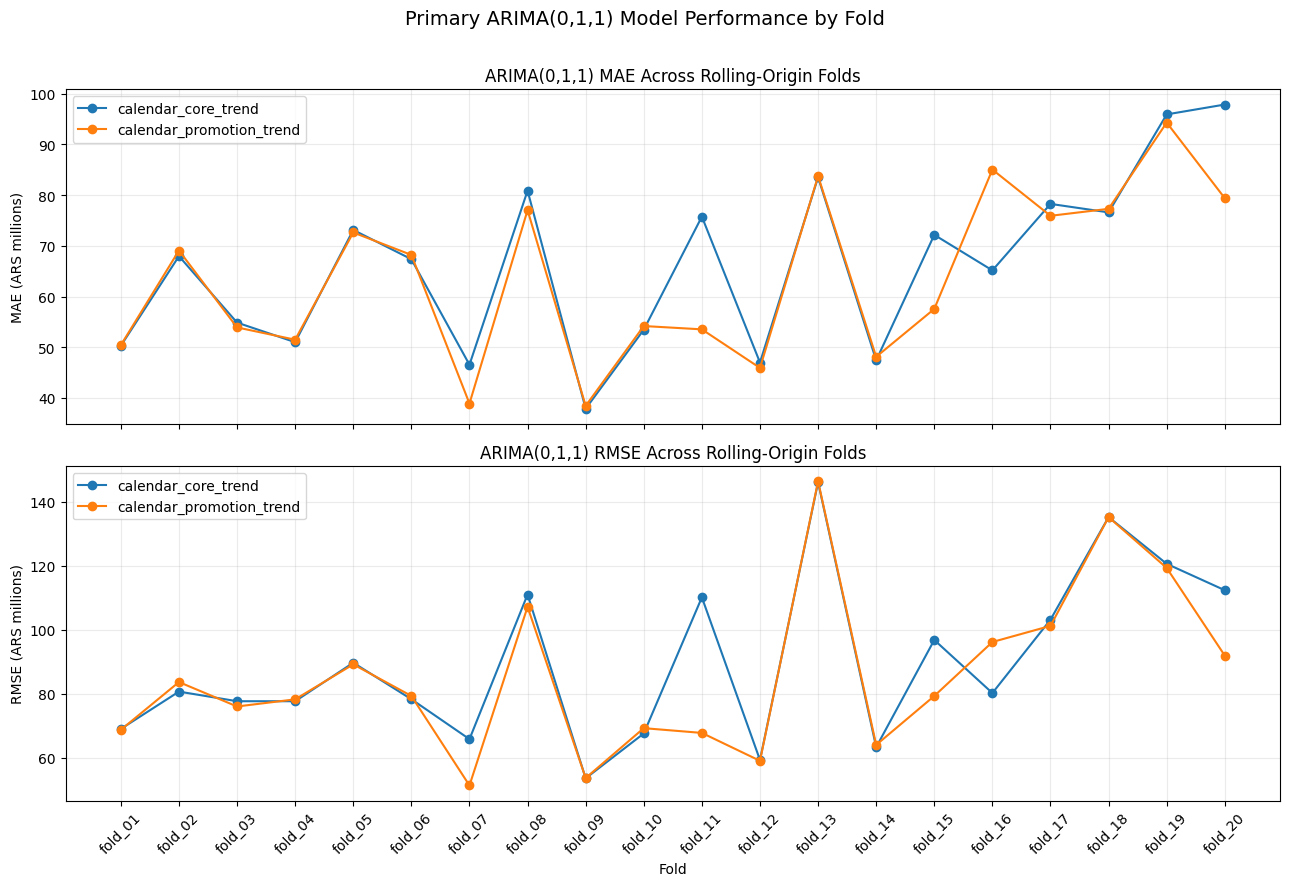

,fold_id,specification_name,original_optimizer,original_converged,selected_retry_attempt,selected_optimizer,selected_converged,selected_aic,selected_bic,selected_ma_coefficient,selected_ma_root_modulus,resolution,review_status
0,fold_09,calendar_core_trend,lbfgs,False,lbfgs_from_powell,lbfgs,True,"-1,853.5388","-1,790.1205",-0.9124,1.0960,Replaced only the affected fold-model outputs.,VALIDATED


,check,observed,expected,status
0,expected_model_fits,40,40,PASS
1,expected_prediction_rows,1120,1120,PASS
2,expected_fold_metric_rows,40,40,PASS
3,twenty_eight_horizons_per_fold_model,True,True,PASS
4,twenty_eight_dates_per_fold_model,True,True,PASS
5,all_fits_converged,True,True,PASS
6,all_fit_statuses_pass,True,True,PASS
7,all_ma_roots_above_review_threshold,True,True,PASS
8,all_predictions_positive,True,True,PASS
9,all_predictions_finite,True,True,PASS


,model_name,specification_name,point_forecast_type,folds_evaluated,predictions,mae,rmse,mean_error,mean_actual,mean_prediction,mean_fold_mase,mean_fold_rmsse,fold_mae_standard_deviation,fold_rmse_standard_deviation,minimum_fold_mae,maximum_fold_mae,promotion_days,merchant_settlement_days
0,calendar_promotion_trend_arima011_errors,calendar_promotion_trend,lognormal_mean,20,560,63.7503,89.4678,4.4592,907.6713,912.1305,0.6664,0.6491,16.4488,25.7694,38.4542,94.2808,16,3
1,calendar_core_trend_arima011_errors,calendar_core_trend,lognormal_mean,20,560,66.1448,93.4276,3.7444,907.6713,911.4157,0.6902,0.6787,17.0373,25.9727,37.8908,97.8412,16,3


,specification_name,fits,converged_fits,minimum_ma_root,maximum_ma_root,minimum_trend_coefficient,maximum_trend_coefficient,minimum_promotion_coefficient,maximum_promotion_coefficient,folds_with_warnings,passed_fits
0,calendar_core_trend,20,20,1.0865,1.1125,0.3728,0.4360,NaN,NaN,0,20
1,calendar_promotion_trend,20,20,1.0806,1.1027,0.3721,0.4373,1.0836,1.1362,0,20


Corrected prediction rows: 1,120
Validated model fits: 40


In [30]:
# ============================================================================
# Replace fold_09 calendar_core_trend with the validated retry result
# ============================================================================

assert selected_retry_result is not None
assert selected_retry_attempt == "lbfgs_from_powell"

retry_selected_row = (
    optimizer_retry_audit.loc[
        optimizer_retry_audit[
            "selected_attempt"
        ]
    ]
    .iloc[0]
)

assert retry_selected_row["attempt_status"] == "PASS"
assert bool(
    retry_selected_row["optimizer_converged"]
)

RETRY_MODEL_NAME = (
    f"{RETRY_SPECIFICATION}_"
    f"{ARIMA011_CANDIDATE_NAME}"
)


# ----------------------------------------------------------------------------
# Reconstruct the 28 replacement predictions
# ----------------------------------------------------------------------------

replacement_forecast_log_mean = np.asarray(
    selected_retry_payload[
        "forecast_log_mean"
    ],
    dtype=float,
)

replacement_forecast_log_variance = np.asarray(
    selected_retry_payload[
        "forecast_log_variance"
    ],
    dtype=float,
)

replacement_predictions = np.asarray(
    selected_retry_payload[
        "predictions"
    ],
    dtype=float,
)

replacement_actual = (
    retry_test_data[TARGET_COLUMN]
    .to_numpy(dtype=float)
)

replacement_errors = (
    replacement_predictions
    - replacement_actual
)


replacement_prediction_table = pd.DataFrame(
    {
        "fold_id": RETRY_FOLD_ID,
        "model_name": RETRY_MODEL_NAME,
        "specification_name": (
            RETRY_SPECIFICATION
        ),
        "point_forecast_type": (
            POINT_FORECAST_TYPE
        ),
        "forecast_origin": (
            retry_fold["train_end"]
        ),
        "target_date": (
            retry_test_data[DATE_COLUMN]
            .to_numpy()
        ),
        "forecast_horizon": np.arange(
            1,
            FORECAST_HORIZON + 1,
        ),
        "actual": replacement_actual,
        "forecast_log_mean": (
            replacement_forecast_log_mean
        ),
        "forecast_log_variance": (
            replacement_forecast_log_variance
        ),
        POINT_FORECAST_COLUMN: (
            replacement_predictions
        ),
        "error": replacement_errors,
        "absolute_error": np.abs(
            replacement_errors
        ),
        "squared_error": np.square(
            replacement_errors
        ),
        "is_month_end": (
            retry_test_data["is_month_end"]
            .to_numpy(dtype=int)
        ),
        "is_holiday": (
            retry_test_data["is_holiday"]
            .to_numpy(dtype=int)
        ),
        "is_payday": (
            retry_test_data["is_payday"]
            .to_numpy(dtype=int)
        ),
        "is_payday_window": (
            retry_test_data[
                "is_payday_window"
            ].to_numpy(dtype=int)
        ),
        "promotion_intensity": (
            retry_test_data[
                "promotion_intensity"
            ].to_numpy(dtype=float)
        ),
        "merchant_settlement_intensity": (
            retry_test_data[
                "merchant_settlement_intensity"
            ].to_numpy(dtype=float)
        ),
    }
)

replacement_prediction_table[
    "is_promotion"
] = (
    replacement_prediction_table[
        "promotion_intensity"
    ]
    .gt(0)
    .astype(int)
)

replacement_prediction_table[
    "is_large_merchant_settlement"
] = (
    replacement_prediction_table[
        "merchant_settlement_intensity"
    ]
    .gt(0)
    .astype(int)
)


assert len(
    replacement_prediction_table
) == FORECAST_HORIZON

assert np.isfinite(
    replacement_prediction_table[
        [
            "forecast_log_mean",
            "forecast_log_variance",
            POINT_FORECAST_COLUMN,
        ]
    ].to_numpy()
).all()

assert replacement_prediction_table[
    POINT_FORECAST_COLUMN
].gt(0).all()


# ----------------------------------------------------------------------------
# Recalculate the fold-09 metrics using training-only scaling
# ----------------------------------------------------------------------------

(
    replacement_mase_denominator,
    replacement_rmsse_denominator,
) = calculate_training_scaling_denominators(
    training_target=(
        retry_train_data[
            TARGET_COLUMN
        ].to_numpy(dtype=float)
    ),
    seasonal_lag=SEASONAL_SCALING_LAG,
)

replacement_mae = float(
    np.mean(
        np.abs(
            replacement_errors
        )
    )
)

replacement_rmse = float(
    np.sqrt(
        np.mean(
            np.square(
                replacement_errors
            )
        )
    )
)

replacement_mean_error = float(
    np.mean(
        replacement_errors
    )
)


replacement_fold_metrics = pd.DataFrame(
    [
        {
            "fold_id": RETRY_FOLD_ID,
            "model_name": RETRY_MODEL_NAME,
            "specification_name": (
                RETRY_SPECIFICATION
            ),
            "point_forecast_type": (
                POINT_FORECAST_TYPE
            ),
            "train_start": (
                retry_fold["train_start"]
            ),
            "train_end": (
                retry_fold["train_end"]
            ),
            "test_start": (
                retry_fold["test_start"]
            ),
            "test_end": (
                retry_fold["test_end"]
            ),
            "train_observations": len(
                retry_train_data
            ),
            "test_observations": len(
                retry_test_data
            ),
            "mae": replacement_mae,
            "rmse": replacement_rmse,
            "mean_error": (
                replacement_mean_error
            ),
            "mase": float(
                replacement_mae
                / replacement_mase_denominator
            ),
            "rmsse": float(
                replacement_rmse
                / replacement_rmsse_denominator
            ),
            "mase_denominator": (
                replacement_mase_denominator
            ),
            "rmsse_denominator": (
                replacement_rmsse_denominator
            ),
            "mean_actual": float(
                replacement_actual.mean()
            ),
            "mean_prediction": float(
                replacement_predictions.mean()
            ),
            "promotion_days": int(
                replacement_prediction_table[
                    "is_promotion"
                ].sum()
            ),
            "payday_window_days": int(
                replacement_prediction_table[
                    "is_payday_window"
                ].sum()
            ),
            "holiday_days": int(
                replacement_prediction_table[
                    "is_holiday"
                ].sum()
            ),
            "merchant_settlement_days": int(
                replacement_prediction_table[
                    "is_large_merchant_settlement"
                ].sum()
            ),
        }
    ]
)


# ----------------------------------------------------------------------------
# Reconstruct the validated fit-audit row
# ----------------------------------------------------------------------------

replacement_fit_audit = pd.DataFrame(
    [
        {
            "fold_id": RETRY_FOLD_ID,
            "model_name": RETRY_MODEL_NAME,
            "specification_name": (
                RETRY_SPECIFICATION
            ),
            "train_start": (
                retry_fold["train_start"]
            ),
            "train_end": (
                retry_fold["train_end"]
            ),
            "test_start": (
                retry_fold["test_start"]
            ),
            "test_end": (
                retry_fold["test_end"]
            ),
            "number_of_exogenous_features": len(
                retry_features
            ),
            "optimizer_converged": True,
            "ma_coefficient": (
                extract_named_parameter(
                    selected_retry_result,
                    "ma.L1",
                )
            ),
            "minimum_ma_root_modulus": (
                minimum_root_modulus(
                    selected_retry_result.maroots
                )
            ),
            "trend_coefficient": (
                extract_named_parameter(
                    selected_retry_result,
                    TREND_FEATURE,
                )
            ),
            "promotion_coefficient": np.nan,
            "aic": float(
                selected_retry_result.aic
            ),
            "bic": float(
                selected_retry_result.bic
            ),
            "finite_forecast": True,
            "positive_forecast": True,
            "warning_count": 0,
            "warning_messages": "",
            "fit_seconds": float(
                retry_selected_row[
                    "fit_seconds"
                ]
            ),
            "status": "PASS",
        }
    ]
)


# ----------------------------------------------------------------------------
# Reconstruct the coefficient rows
# ----------------------------------------------------------------------------

replacement_confidence_intervals = np.asarray(
    selected_retry_result.conf_int(
        alpha=0.05
    ),
    dtype=float,
)

replacement_coefficient_table = pd.DataFrame(
    {
        "fold_id": RETRY_FOLD_ID,
        "model_name": RETRY_MODEL_NAME,
        "specification_name": (
            RETRY_SPECIFICATION
        ),
        "parameter": (
            selected_retry_result.param_names
        ),
        "estimate": np.asarray(
            selected_retry_result.params,
            dtype=float,
        ),
        "standard_error": np.asarray(
            selected_retry_result.bse,
            dtype=float,
        ),
        "p_value": np.asarray(
            selected_retry_result.pvalues,
            dtype=float,
        ),
        "ci_95_lower": (
            replacement_confidence_intervals[
                :, 0
            ]
        ),
        "ci_95_upper": (
            replacement_confidence_intervals[
                :, 1
            ]
        ),
    }
)


# ----------------------------------------------------------------------------
# Replace only the affected rows
# ----------------------------------------------------------------------------

affected_prediction_mask = (
    arima011_backtest_predictions[
        "fold_id"
    ].eq(RETRY_FOLD_ID)
    & arima011_backtest_predictions[
        "specification_name"
    ].eq(RETRY_SPECIFICATION)
)

affected_metric_mask = (
    arima011_backtest_fold_metrics[
        "fold_id"
    ].eq(RETRY_FOLD_ID)
    & arima011_backtest_fold_metrics[
        "specification_name"
    ].eq(RETRY_SPECIFICATION)
)

affected_audit_mask = (
    arima011_backtest_fit_audit[
        "fold_id"
    ].eq(RETRY_FOLD_ID)
    & arima011_backtest_fit_audit[
        "specification_name"
    ].eq(RETRY_SPECIFICATION)
)

affected_coefficient_mask = (
    arima011_backtest_coefficients[
        "fold_id"
    ].eq(RETRY_FOLD_ID)
    & arima011_backtest_coefficients[
        "specification_name"
    ].eq(RETRY_SPECIFICATION)
)


assert affected_prediction_mask.sum() == FORECAST_HORIZON
assert affected_metric_mask.sum() == 1
assert affected_audit_mask.sum() == 1
assert affected_coefficient_mask.sum() > 0


arima011_backtest_predictions = pd.concat(
    [
        arima011_backtest_predictions.loc[
            ~affected_prediction_mask
        ],
        replacement_prediction_table,
    ],
    ignore_index=True,
).sort_values(
    [
        "fold_id",
        "specification_name",
        "target_date",
    ]
).reset_index(drop=True)


arima011_backtest_fold_metrics = pd.concat(
    [
        arima011_backtest_fold_metrics.loc[
            ~affected_metric_mask
        ],
        replacement_fold_metrics,
    ],
    ignore_index=True,
).sort_values(
    [
        "fold_id",
        "specification_name",
    ]
).reset_index(drop=True)


arima011_backtest_fit_audit = pd.concat(
    [
        arima011_backtest_fit_audit.loc[
            ~affected_audit_mask
        ],
        replacement_fit_audit,
    ],
    ignore_index=True,
).sort_values(
    [
        "fold_id",
        "specification_name",
    ]
).reset_index(drop=True)


arima011_backtest_coefficients = pd.concat(
    [
        arima011_backtest_coefficients.loc[
            ~affected_coefficient_mask
        ],
        replacement_coefficient_table,
    ],
    ignore_index=True,
).sort_values(
    [
        "fold_id",
        "specification_name",
        "parameter",
    ]
).reset_index(drop=True)


# ----------------------------------------------------------------------------
# Recalculate aggregate metrics
# ----------------------------------------------------------------------------

aggregate_metric_records = []

for model_name, model_predictions in (
    arima011_backtest_predictions.groupby(
        "model_name"
    )
):

    model_fold_metrics = (
        arima011_backtest_fold_metrics.loc[
            arima011_backtest_fold_metrics[
                "model_name"
            ].eq(model_name)
        ]
    )

    pooled_errors = (
        model_predictions[
            POINT_FORECAST_COLUMN
        ].to_numpy(dtype=float)
        - model_predictions[
            "actual"
        ].to_numpy(dtype=float)
    )

    aggregate_metric_records.append(
        {
            "model_name": model_name,
            "specification_name": (
                model_predictions[
                    "specification_name"
                ].iloc[0]
            ),
            "point_forecast_type": (
                POINT_FORECAST_TYPE
            ),
            "folds_evaluated": (
                model_predictions[
                    "fold_id"
                ].nunique()
            ),
            "predictions": len(
                model_predictions
            ),
            "mae": float(
                np.mean(
                    np.abs(
                        pooled_errors
                    )
                )
            ),
            "rmse": float(
                np.sqrt(
                    np.mean(
                        np.square(
                            pooled_errors
                        )
                    )
                )
            ),
            "mean_error": float(
                np.mean(
                    pooled_errors
                )
            ),
            "mean_actual": float(
                model_predictions[
                    "actual"
                ].mean()
            ),
            "mean_prediction": float(
                model_predictions[
                    POINT_FORECAST_COLUMN
                ].mean()
            ),
            "mean_fold_mase": float(
                model_fold_metrics[
                    "mase"
                ].mean()
            ),
            "mean_fold_rmsse": float(
                model_fold_metrics[
                    "rmsse"
                ].mean()
            ),
            "fold_mae_standard_deviation": float(
                model_fold_metrics[
                    "mae"
                ].std(ddof=1)
            ),
            "fold_rmse_standard_deviation": float(
                model_fold_metrics[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                model_fold_metrics[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                model_fold_metrics[
                    "mae"
                ].max()
            ),
            "promotion_days": int(
                model_predictions[
                    "is_promotion"
                ].sum()
            ),
            "merchant_settlement_days": int(
                model_predictions[
                    "is_large_merchant_settlement"
                ].sum()
            ),
        }
    )

arima011_backtest_aggregate_metrics = (
    pd.DataFrame(
        aggregate_metric_records
    )
    .sort_values("mae")
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Recalculate fold-01 reproducibility
# ----------------------------------------------------------------------------

full_fold01_metrics = (
    arima011_backtest_fold_metrics.loc[
        arima011_backtest_fold_metrics[
            "fold_id"
        ].eq(SMOKE_TEST_FOLD_ID)
    ]
    .sort_values("specification_name")
    .reset_index(drop=True)
)

fold01_matches_smoke_test = bool(
    np.allclose(
        full_fold01_metrics[
            [
                "mae",
                "rmse",
                "mean_error",
                "mase",
                "rmsse",
            ]
        ].to_numpy(dtype=float),
        smoke_fold01_metrics[
            [
                "mae",
                "rmse",
                "mean_error",
                "mase",
                "rmsse",
            ]
        ].to_numpy(dtype=float),
        rtol=1e-9,
        atol=1e-9,
    )
)


# ----------------------------------------------------------------------------
# Rebuild the final pipeline audit
# ----------------------------------------------------------------------------

expected_model_fits = (
    N_FOLDS
    * len(
        BACKTEST_SPECIFICATIONS
    )
)

expected_prediction_rows = (
    expected_model_fits
    * FORECAST_HORIZON
)

fold_model_horizon_counts = (
    arima011_backtest_predictions
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )["forecast_horizon"]
    .nunique()
)

fold_model_date_counts = (
    arima011_backtest_predictions
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )["target_date"]
    .nunique()
)


pipeline_audit = pd.DataFrame(
    [
        {
            "check": "expected_model_fits",
            "observed": len(
                arima011_backtest_fit_audit
            ),
            "expected": expected_model_fits,
            "status": (
                "PASS"
                if len(
                    arima011_backtest_fit_audit
                ) == expected_model_fits
                else "FAIL"
            ),
        },
        {
            "check": "expected_prediction_rows",
            "observed": len(
                arima011_backtest_predictions
            ),
            "expected": expected_prediction_rows,
            "status": (
                "PASS"
                if len(
                    arima011_backtest_predictions
                ) == expected_prediction_rows
                else "FAIL"
            ),
        },
        {
            "check": "expected_fold_metric_rows",
            "observed": len(
                arima011_backtest_fold_metrics
            ),
            "expected": expected_model_fits,
            "status": (
                "PASS"
                if len(
                    arima011_backtest_fold_metrics
                ) == expected_model_fits
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_horizons_per_fold_model",
            "observed": bool(
                fold_model_horizon_counts
                .eq(FORECAST_HORIZON)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold_model_horizon_counts
                .eq(FORECAST_HORIZON)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_dates_per_fold_model",
            "observed": bool(
                fold_model_date_counts
                .eq(FORECAST_HORIZON)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold_model_date_counts
                .eq(FORECAST_HORIZON)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_fits_converged",
            "observed": bool(
                arima011_backtest_fit_audit[
                    "optimizer_converged"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_fit_audit[
                    "optimizer_converged"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "all_fit_statuses_pass",
            "observed": bool(
                arima011_backtest_fit_audit[
                    "status"
                ].eq("PASS")
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_fit_audit[
                    "status"
                ].eq("PASS")
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_ma_roots_above_review_threshold",
            "observed": bool(
                arima011_backtest_fit_audit[
                    "minimum_ma_root_modulus"
                ]
                .gt(
                    MA_ROOT_REVIEW_THRESHOLD
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_fit_audit[
                    "minimum_ma_root_modulus"
                ]
                .gt(
                    MA_ROOT_REVIEW_THRESHOLD
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_positive",
            "observed": bool(
                arima011_backtest_predictions[
                    POINT_FORECAST_COLUMN
                ]
                .gt(0)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if arima011_backtest_predictions[
                    POINT_FORECAST_COLUMN
                ]
                .gt(0)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_finite",
            "observed": bool(
                np.isfinite(
                    arima011_backtest_predictions[
                        [
                            "forecast_log_mean",
                            "forecast_log_variance",
                            POINT_FORECAST_COLUMN,
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    arima011_backtest_predictions[
                        [
                            "forecast_log_mean",
                            "forecast_log_variance",
                            POINT_FORECAST_COLUMN,
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "recorded_failures",
            "observed": len(
                arima011_backtest_failures
            ),
            "expected": 0,
            "status": (
                "PASS"
                if arima011_backtest_failures.empty
                else "FAIL"
            ),
        },
        {
            "check": "fold01_matches_smoke_test",
            "observed": (
                fold01_matches_smoke_test
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold01_matches_smoke_test
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Record the retry resolution
# ----------------------------------------------------------------------------

retry_resolution = pd.DataFrame(
    [
        {
            "fold_id": RETRY_FOLD_ID,
            "specification_name": (
                RETRY_SPECIFICATION
            ),
            "original_optimizer": "lbfgs",
            "original_converged": False,
            "selected_retry_attempt": (
                selected_retry_attempt
            ),
            "selected_optimizer": "lbfgs",
            "selected_converged": True,
            "selected_aic": float(
                selected_retry_result.aic
            ),
            "selected_bic": float(
                selected_retry_result.bic
            ),
            "selected_ma_coefficient": (
                extract_named_parameter(
                    selected_retry_result,
                    "ma.L1",
                )
            ),
            "selected_ma_root_modulus": (
                minimum_root_modulus(
                    selected_retry_result.maroots
                )
            ),
            "resolution": (
                "Replaced only the affected fold-model outputs."
            ),
            "review_status": "VALIDATED",
        }
    ]
)

RETRY_RESOLUTION_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_fold09_"
        "calendar_core_retry_resolution.csv"
    )
)


# ----------------------------------------------------------------------------
# Save all corrected final outputs
# ----------------------------------------------------------------------------

arima011_backtest_predictions.to_csv(
    BACKTEST_PREDICTIONS_PATH,
    index=False,
)

arima011_backtest_fold_metrics.to_csv(
    BACKTEST_FOLD_METRICS_PATH,
    index=False,
)

arima011_backtest_aggregate_metrics.to_csv(
    BACKTEST_AGGREGATE_METRICS_PATH,
    index=False,
)

arima011_backtest_fit_audit.to_csv(
    BACKTEST_FIT_AUDIT_PATH,
    index=False,
)

arima011_backtest_coefficients.to_csv(
    BACKTEST_COEFFICIENTS_PATH,
    index=False,
)

pipeline_audit.to_csv(
    BACKTEST_PIPELINE_AUDIT_PATH,
    index=False,
)

retry_resolution.to_csv(
    RETRY_RESOLUTION_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Regenerate the fold-performance figure
# ----------------------------------------------------------------------------

fold_metric_plot = (
    arima011_backtest_fold_metrics
    .sort_values(
        [
            "fold_id",
            "specification_name",
        ]
    )
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True,
)

for specification_name in (
    BACKTEST_SPECIFICATIONS
):

    specification_metrics = (
        fold_metric_plot.loc[
            fold_metric_plot[
                "specification_name"
            ].eq(specification_name)
        ]
        .sort_values("fold_id")
    )

    axes[0].plot(
        specification_metrics["fold_id"],
        specification_metrics["mae"],
        marker="o",
        label=specification_name,
    )

    axes[1].plot(
        specification_metrics["fold_id"],
        specification_metrics["rmse"],
        marker="o",
        label=specification_name,
    )

axes[0].set_title(
    "ARIMA(0,1,1) MAE Across Rolling-Origin Folds"
)
axes[0].set_ylabel("MAE (ARS millions)")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title(
    "ARIMA(0,1,1) RMSE Across Rolling-Origin Folds"
)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("RMSE (ARS millions)")
axes[1].legend()
axes[1].grid(alpha=0.25)
axes[1].tick_params(
    axis="x",
    rotation=45,
)

fig.suptitle(
    "Primary ARIMA(0,1,1) Model Performance by Fold",
    fontsize=14,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

fig.savefig(
    BACKTEST_METRICS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Final verification
# ----------------------------------------------------------------------------

for output_path in [
    BACKTEST_PREDICTIONS_PATH,
    BACKTEST_FOLD_METRICS_PATH,
    BACKTEST_AGGREGATE_METRICS_PATH,
    BACKTEST_FIT_AUDIT_PATH,
    BACKTEST_COEFFICIENTS_PATH,
    BACKTEST_PIPELINE_AUDIT_PATH,
    BACKTEST_METRICS_FIGURE_PATH,
    RETRY_RESOLUTION_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert pipeline_audit[
    "status"
].eq("PASS").all(), (
    "The corrected backtest still fails at least one audit."
)


# ----------------------------------------------------------------------------
# Display final corrected outputs
# ----------------------------------------------------------------------------

display(retry_resolution)

display(pipeline_audit)

display(
    arima011_backtest_aggregate_metrics
)

display(
    arima011_backtest_fit_audit[
        [
            "specification_name",
            "optimizer_converged",
            "minimum_ma_root_modulus",
            "trend_coefficient",
            "promotion_coefficient",
            "warning_count",
            "status",
        ]
    ]
    .groupby("specification_name")
    .agg(
        fits=("status", "size"),
        converged_fits=(
            "optimizer_converged",
            "sum",
        ),
        minimum_ma_root=(
            "minimum_ma_root_modulus",
            "min",
        ),
        maximum_ma_root=(
            "minimum_ma_root_modulus",
            "max",
        ),
        minimum_trend_coefficient=(
            "trend_coefficient",
            "min",
        ),
        maximum_trend_coefficient=(
            "trend_coefficient",
            "max",
        ),
        minimum_promotion_coefficient=(
            "promotion_coefficient",
            "min",
        ),
        maximum_promotion_coefficient=(
            "promotion_coefficient",
            "max",
        ),
        folds_with_warnings=(
            "warning_count",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        passed_fits=(
            "status",
            lambda values: int(
                values.eq("PASS").sum()
            ),
        ),
    )
    .reset_index()
)

print(
    "Corrected prediction rows: "
    f"{len(arima011_backtest_predictions):,}"
)

print(
    "Validated model fits: "
    f"{len(arima011_backtest_fit_audit)}"
)

## 17. Out-of-sample contribution of planned promotions

The full backtest shows that adding planned promotion intensity improves the
aggregate ARIMA(0,1,1) forecast:

- Lower overall MAE.
- Lower overall RMSE.
- Similar and relatively small global bias.

However, aggregate metrics do not establish whether this improvement occurs
specifically on future promotion dates.

Because both models forecast exactly the same dates, their errors can be
compared directly for every out-of-sample observation.

For each date, the paired absolute-error improvement is defined as:

$$
\Delta AE_t
=
AE_{t,\text{calendar core}}
-
AE_{t,\text{calendar promotion}}
$$

A positive value means that the promotion model produced the smaller absolute
error.

Similarly, the paired squared-error improvement is:

$$
\Delta SE_t
=
SE_{t,\text{calendar core}}
-
SE_{t,\text{calendar promotion}}
$$

The analysis separates:

1. Promotion dates.
2. Non-promotion dates.
3. Folds containing at least one promotion date.
4. Folds without promotions in the forecast horizon.

Only sixteen promotion dates occur in the complete backtest. Therefore, the
results in this block are descriptive and should not yet be interpreted as
strong statistical evidence.

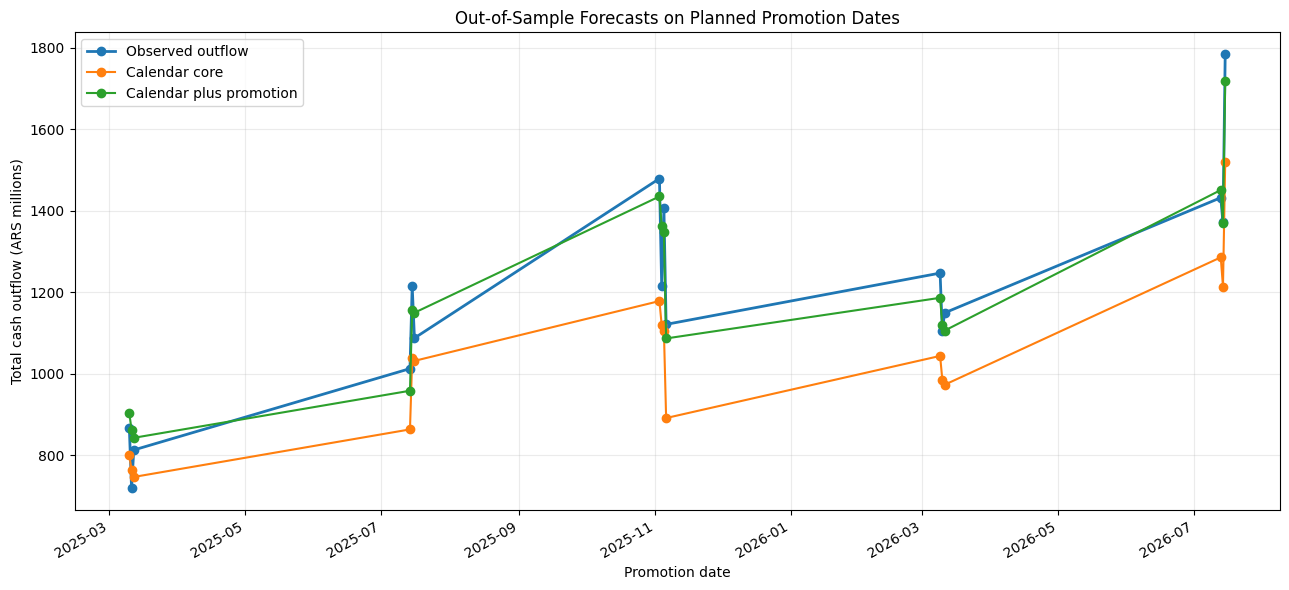

,check,observed,expected,status
0,paired_prediction_rows,560,560,PASS
1,promotion_day_rows,16,16,PASS
2,promotion_folds,5,5,PASS
3,actual_values_match_between_models,True,True,PASS
4,fold_comparison_rows,20,20,PASS
5,missing_paired_values,0,0,PASS


,evaluation_group,observations,folds_represented,core_mae,promotion_mae,mae_improvement,mae_improvement_pct,core_rmse,promotion_rmse,rmse_improvement,rmse_improvement_pct,core_mean_error,promotion_mean_error
0,all_days,560,20,66.1448,63.7503,2.3945,3.6201,93.4276,89.4678,3.9598,4.2383,3.7444,4.4592
1,promotion_day,16,5,159.6362,54.6988,104.9374,65.7353,179.0239,67.0167,112.0071,62.5655,-154.0438,1.8663
2,non_promotion_day,544,20,63.3951,64.0165,-0.6214,-0.9802,89.6817,90.0435,-0.3617,-0.4034,8.3852,4.5355


,event_group,observations,folds_represented,mean_prediction_difference,mean_absolute_error_improvement,median_absolute_error_improvement,mean_squared_error_improvement,days_with_lower_absolute_error,days_with_lower_squared_error,pct_days_with_lower_absolute_error,pct_days_with_lower_squared_error
0,non_promotion_day,544,20,-3.8498,-0.6214,-0.0763,-65.0146,270,270,49.6324,49.6324
1,promotion_day,16,5,155.9101,104.9374,123.2504,"27,558.2957",13,13,81.2500,81.2500


,has_promotion_in_test,folds,total_promotion_days,mean_mae_improvement,median_mae_improvement,folds_with_mae_improvement,mean_rmse_improvement,median_rmse_improvement,folds_with_rmse_improvement,mean_absolute_bias_improvement
0,False,15,0,-0.9293,-0.2356,6,-0.7001,0.0146,8,-0.9789
1,True,5,16,12.3661,14.6037,4,18.3511,17.4965,4,-6.6666


,fold_id,target_date,forecast_horizon,promotion_intensity,actual,core_prediction,promotion_prediction,core_absolute_error,promotion_absolute_error,absolute_error_improvement
0,fold_02,2025-03-10,24,0.1100,867.9070,799.8077,903.1806,68.0993,35.2736,32.8257
1,fold_02,2025-03-11,25,0.1100,719.8960,764.6351,863.1080,44.7391,143.2120,-98.4729
2,fold_02,2025-03-12,26,0.1100,813.3120,747.1711,843.1466,66.1409,29.8346,36.3064
3,fold_07,2025-07-14,10,0.1000,"1,012.7990",863.7659,958.5998,149.0331,54.1992,94.8339
4,fold_07,2025-07-15,11,0.1000,"1,214.7800","1,038.2098","1,157.2384",176.5702,57.5416,119.0286
5,fold_07,2025-07-16,12,0.1000,"1,087.7180","1,031.8174","1,149.8709",55.9006,62.1529,-6.2523
6,fold_11,2025-11-03,10,0.1800,"1,478.8770","1,178.5036","1,435.0129",300.3734,43.8641,256.5094
7,fold_11,2025-11-04,11,0.1800,"1,216.0840","1,119.4247","1,363.5670",96.6593,147.4830,-50.8237
8,fold_11,2025-11-05,12,0.1800,"1,406.3470","1,105.7974","1,346.6230",300.5496,59.7240,240.8256
9,fold_11,2025-11-06,13,0.1800,"1,121.3540",891.6667,"1,086.8267",229.6873,34.5273,195.1601


Promotion dates evaluated: 16
Promotion folds evaluated: 5
Saved promotion comparison figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_promotion_day_forecast_comparison.png


In [31]:
# ============================================================================
# 19. Evaluate the out-of-sample contribution of planned promotions
# ============================================================================

CORE_MODEL_NAME = (
    "calendar_core_trend_arima011_errors"
)

PROMOTION_MODEL_NAME = (
    "calendar_promotion_trend_arima011_errors"
)


# ----------------------------------------------------------------------------
# Extract and validate both comparable prediction sets
# ----------------------------------------------------------------------------

core_predictions = (
    arima011_backtest_predictions.loc[
        arima011_backtest_predictions[
            "model_name"
        ].eq(CORE_MODEL_NAME)
    ]
    .copy()
    .reset_index(drop=True)
)

promotion_predictions = (
    arima011_backtest_predictions.loc[
        arima011_backtest_predictions[
            "model_name"
        ].eq(PROMOTION_MODEL_NAME)
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(core_predictions) == 560
assert len(promotion_predictions) == 560

comparison_keys = [
    "fold_id",
    "target_date",
    "forecast_horizon",
]

assert not core_predictions.duplicated(
    comparison_keys
).any()

assert not promotion_predictions.duplicated(
    comparison_keys
).any()


# ----------------------------------------------------------------------------
# Build a paired daily comparison
# ----------------------------------------------------------------------------

core_daily = core_predictions[
    [
        *comparison_keys,
        "forecast_origin",
        "actual",
        POINT_FORECAST_COLUMN,
        "error",
        "absolute_error",
        "squared_error",
        "is_month_end",
        "is_holiday",
        "is_payday",
        "is_payday_window",
        "promotion_intensity",
        "is_promotion",
        "merchant_settlement_intensity",
        "is_large_merchant_settlement",
    ]
].rename(
    columns={
        POINT_FORECAST_COLUMN: (
            "core_prediction"
        ),
        "error": "core_error",
        "absolute_error": (
            "core_absolute_error"
        ),
        "squared_error": (
            "core_squared_error"
        ),
    }
)

promotion_daily = promotion_predictions[
    [
        *comparison_keys,
        "actual",
        POINT_FORECAST_COLUMN,
        "error",
        "absolute_error",
        "squared_error",
    ]
].rename(
    columns={
        "actual": "promotion_model_actual",
        POINT_FORECAST_COLUMN: (
            "promotion_prediction"
        ),
        "error": "promotion_error",
        "absolute_error": (
            "promotion_absolute_error"
        ),
        "squared_error": (
            "promotion_squared_error"
        ),
    }
)


promotion_day_paired_comparison = (
    core_daily.merge(
        promotion_daily,
        on=comparison_keys,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        [
            "fold_id",
            "target_date",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Confirm identical observed values
# ----------------------------------------------------------------------------

actual_values_match = bool(
    np.allclose(
        promotion_day_paired_comparison[
            "actual"
        ].to_numpy(dtype=float),
        promotion_day_paired_comparison[
            "promotion_model_actual"
        ].to_numpy(dtype=float),
        rtol=0.0,
        atol=0.0,
    )
)

assert actual_values_match

promotion_day_paired_comparison = (
    promotion_day_paired_comparison.drop(
        columns=[
            "promotion_model_actual"
        ]
    )
)


# ----------------------------------------------------------------------------
# Paired loss differences
# ----------------------------------------------------------------------------

promotion_day_paired_comparison[
    "absolute_error_improvement"
] = (
    promotion_day_paired_comparison[
        "core_absolute_error"
    ]
    - promotion_day_paired_comparison[
        "promotion_absolute_error"
    ]
)

promotion_day_paired_comparison[
    "squared_error_improvement"
] = (
    promotion_day_paired_comparison[
        "core_squared_error"
    ]
    - promotion_day_paired_comparison[
        "promotion_squared_error"
    ]
)

promotion_day_paired_comparison[
    "promotion_model_better_absolute_error"
] = (
    promotion_day_paired_comparison[
        "absolute_error_improvement"
    ] > 0
)

promotion_day_paired_comparison[
    "promotion_model_better_squared_error"
] = (
    promotion_day_paired_comparison[
        "squared_error_improvement"
    ] > 0
)

promotion_day_paired_comparison[
    "prediction_difference"
] = (
    promotion_day_paired_comparison[
        "promotion_prediction"
    ]
    - promotion_day_paired_comparison[
        "core_prediction"
    ]
)

promotion_day_paired_comparison[
    "event_group"
] = np.where(
    promotion_day_paired_comparison[
        "is_promotion"
    ].eq(1),
    "promotion_day",
    "non_promotion_day",
)


# ----------------------------------------------------------------------------
# Model metrics by promotion-day status
# ----------------------------------------------------------------------------

long_prediction_data = pd.concat(
    [
        core_predictions.assign(
            comparison_model="calendar_core"
        ),
        promotion_predictions.assign(
            comparison_model=(
                "calendar_promotion"
            )
        ),
    ],
    ignore_index=True,
)

long_prediction_data[
    "event_group"
] = np.where(
    long_prediction_data[
        "is_promotion"
    ].eq(1),
    "promotion_day",
    "non_promotion_day",
)


promotion_metric_records = []

evaluation_groups = {
    "all_days": (
        long_prediction_data.index
        == long_prediction_data.index
    ),
    "promotion_day": (
        long_prediction_data[
            "is_promotion"
        ].eq(1)
    ),
    "non_promotion_day": (
        long_prediction_data[
            "is_promotion"
        ].eq(0)
    ),
}


for evaluation_group, group_mask in (
    evaluation_groups.items()
):

    group_data = (
        long_prediction_data.loc[
            group_mask
        ]
    )

    for comparison_model, model_data in (
        group_data.groupby(
            "comparison_model"
        )
    ):

        model_errors = (
            model_data[
                POINT_FORECAST_COLUMN
            ].to_numpy(dtype=float)
            - model_data[
                "actual"
            ].to_numpy(dtype=float)
        )

        promotion_metric_records.append(
            {
                "evaluation_group": (
                    evaluation_group
                ),
                "comparison_model": (
                    comparison_model
                ),
                "observations": len(
                    model_data
                ),
                "folds_represented": (
                    model_data[
                        "fold_id"
                    ].nunique()
                ),
                "mae": float(
                    np.mean(
                        np.abs(
                            model_errors
                        )
                    )
                ),
                "rmse": float(
                    np.sqrt(
                        np.mean(
                            np.square(
                                model_errors
                            )
                        )
                    )
                ),
                "mean_error": float(
                    np.mean(
                        model_errors
                    )
                ),
                "mean_actual": float(
                    model_data[
                        "actual"
                    ].mean()
                ),
                "mean_prediction": float(
                    model_data[
                        POINT_FORECAST_COLUMN
                    ].mean()
                ),
            }
        )


promotion_day_model_metrics = pd.DataFrame(
    promotion_metric_records
)


# ----------------------------------------------------------------------------
# Add relative improvements within each evaluation group
# ----------------------------------------------------------------------------

metric_pivot = (
    promotion_day_model_metrics
    .pivot(
        index="evaluation_group",
        columns="comparison_model",
        values=[
            "mae",
            "rmse",
            "mean_error",
        ],
    )
)

group_improvement_records = []

for evaluation_group in (
    promotion_day_model_metrics[
        "evaluation_group"
    ].unique()
):

    core_group_metrics = (
        promotion_day_model_metrics.loc[
            promotion_day_model_metrics[
                "evaluation_group"
            ].eq(evaluation_group)
            & promotion_day_model_metrics[
                "comparison_model"
            ].eq("calendar_core")
        ]
        .iloc[0]
    )

    promotion_group_metrics = (
        promotion_day_model_metrics.loc[
            promotion_day_model_metrics[
                "evaluation_group"
            ].eq(evaluation_group)
            & promotion_day_model_metrics[
                "comparison_model"
            ].eq("calendar_promotion")
        ]
        .iloc[0]
    )

    group_improvement_records.append(
        {
            "evaluation_group": (
                evaluation_group
            ),
            "observations": int(
                core_group_metrics[
                    "observations"
                ]
            ),
            "folds_represented": int(
                core_group_metrics[
                    "folds_represented"
                ]
            ),
            "core_mae": float(
                core_group_metrics["mae"]
            ),
            "promotion_mae": float(
                promotion_group_metrics[
                    "mae"
                ]
            ),
            "mae_improvement": float(
                core_group_metrics["mae"]
                - promotion_group_metrics[
                    "mae"
                ]
            ),
            "mae_improvement_pct": float(
                100
                * (
                    core_group_metrics[
                        "mae"
                    ]
                    - promotion_group_metrics[
                        "mae"
                    ]
                )
                / core_group_metrics["mae"]
            ),
            "core_rmse": float(
                core_group_metrics["rmse"]
            ),
            "promotion_rmse": float(
                promotion_group_metrics[
                    "rmse"
                ]
            ),
            "rmse_improvement": float(
                core_group_metrics["rmse"]
                - promotion_group_metrics[
                    "rmse"
                ]
            ),
            "rmse_improvement_pct": float(
                100
                * (
                    core_group_metrics[
                        "rmse"
                    ]
                    - promotion_group_metrics[
                        "rmse"
                    ]
                )
                / core_group_metrics["rmse"]
            ),
            "core_mean_error": float(
                core_group_metrics[
                    "mean_error"
                ]
            ),
            "promotion_mean_error": float(
                promotion_group_metrics[
                    "mean_error"
                ]
            ),
        }
    )

promotion_group_improvements = pd.DataFrame(
    group_improvement_records
)


# ----------------------------------------------------------------------------
# Fold-level paired metric comparison
# ----------------------------------------------------------------------------

core_fold_metrics = (
    arima011_backtest_fold_metrics.loc[
        arima011_backtest_fold_metrics[
            "specification_name"
        ].eq("calendar_core_trend")
    ][
        [
            "fold_id",
            "test_start",
            "test_end",
            "mae",
            "rmse",
            "mean_error",
            "promotion_days",
        ]
    ]
    .rename(
        columns={
            "mae": "core_mae",
            "rmse": "core_rmse",
            "mean_error": (
                "core_mean_error"
            ),
        }
    )
)

promotion_fold_metrics = (
    arima011_backtest_fold_metrics.loc[
        arima011_backtest_fold_metrics[
            "specification_name"
        ].eq(
            "calendar_promotion_trend"
        )
    ][
        [
            "fold_id",
            "mae",
            "rmse",
            "mean_error",
            "promotion_days",
        ]
    ]
    .rename(
        columns={
            "mae": "promotion_mae",
            "rmse": "promotion_rmse",
            "mean_error": (
                "promotion_mean_error"
            ),
            "promotion_days": (
                "promotion_days_check"
            ),
        }
    )
)

promotion_fold_comparison = (
    core_fold_metrics.merge(
        promotion_fold_metrics,
        on="fold_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("fold_id")
    .reset_index(drop=True)
)

assert (
    promotion_fold_comparison[
        "promotion_days"
    ]
    .eq(
        promotion_fold_comparison[
            "promotion_days_check"
        ]
    )
    .all()
)

promotion_fold_comparison = (
    promotion_fold_comparison.drop(
        columns=[
            "promotion_days_check"
        ]
    )
)

promotion_fold_comparison[
    "has_promotion_in_test"
] = (
    promotion_fold_comparison[
        "promotion_days"
    ].gt(0)
)

promotion_fold_comparison[
    "mae_improvement"
] = (
    promotion_fold_comparison[
        "core_mae"
    ]
    - promotion_fold_comparison[
        "promotion_mae"
    ]
)

promotion_fold_comparison[
    "rmse_improvement"
] = (
    promotion_fold_comparison[
        "core_rmse"
    ]
    - promotion_fold_comparison[
        "promotion_rmse"
    ]
)

promotion_fold_comparison[
    "absolute_bias_improvement"
] = (
    promotion_fold_comparison[
        "core_mean_error"
    ].abs()
    - promotion_fold_comparison[
        "promotion_mean_error"
    ].abs()
)


promotion_fold_group_summary = (
    promotion_fold_comparison
    .groupby(
        "has_promotion_in_test",
        as_index=False,
    )
    .agg(
        folds=("fold_id", "size"),
        total_promotion_days=(
            "promotion_days",
            "sum",
        ),
        mean_mae_improvement=(
            "mae_improvement",
            "mean",
        ),
        median_mae_improvement=(
            "mae_improvement",
            "median",
        ),
        folds_with_mae_improvement=(
            "mae_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        mean_rmse_improvement=(
            "rmse_improvement",
            "mean",
        ),
        median_rmse_improvement=(
            "rmse_improvement",
            "median",
        ),
        folds_with_rmse_improvement=(
            "rmse_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        mean_absolute_bias_improvement=(
            "absolute_bias_improvement",
            "mean",
        ),
    )
)


# ----------------------------------------------------------------------------
# Paired daily summary
# ----------------------------------------------------------------------------

paired_daily_summary = (
    promotion_day_paired_comparison
    .groupby(
        "event_group",
        as_index=False,
    )
    .agg(
        observations=(
            "target_date",
            "size",
        ),
        folds_represented=(
            "fold_id",
            "nunique",
        ),
        mean_prediction_difference=(
            "prediction_difference",
            "mean",
        ),
        mean_absolute_error_improvement=(
            "absolute_error_improvement",
            "mean",
        ),
        median_absolute_error_improvement=(
            "absolute_error_improvement",
            "median",
        ),
        mean_squared_error_improvement=(
            "squared_error_improvement",
            "mean",
        ),
        days_with_lower_absolute_error=(
            "promotion_model_better_absolute_error",
            "sum",
        ),
        days_with_lower_squared_error=(
            "promotion_model_better_squared_error",
            "sum",
        ),
    )
)

paired_daily_summary[
    "pct_days_with_lower_absolute_error"
] = (
    100
    * paired_daily_summary[
        "days_with_lower_absolute_error"
    ]
    / paired_daily_summary[
        "observations"
    ]
)

paired_daily_summary[
    "pct_days_with_lower_squared_error"
] = (
    100
    * paired_daily_summary[
        "days_with_lower_squared_error"
    ]
    / paired_daily_summary[
        "observations"
    ]
)


# ----------------------------------------------------------------------------
# Structural audit
# ----------------------------------------------------------------------------

promotion_effect_audit = pd.DataFrame(
    [
        {
            "check": "paired_prediction_rows",
            "observed": len(
                promotion_day_paired_comparison
            ),
            "expected": 560,
            "status": (
                "PASS"
                if len(
                    promotion_day_paired_comparison
                ) == 560
                else "FAIL"
            ),
        },
        {
            "check": "promotion_day_rows",
            "observed": int(
                promotion_day_paired_comparison[
                    "is_promotion"
                ].sum()
            ),
            "expected": 16,
            "status": (
                "PASS"
                if promotion_day_paired_comparison[
                    "is_promotion"
                ].sum() == 16
                else "FAIL"
            ),
        },
        {
            "check": "promotion_folds",
            "observed": int(
                promotion_day_paired_comparison.loc[
                    promotion_day_paired_comparison[
                        "is_promotion"
                    ].eq(1),
                    "fold_id",
                ].nunique()
            ),
            "expected": 5,
            "status": (
                "PASS"
                if promotion_day_paired_comparison.loc[
                    promotion_day_paired_comparison[
                        "is_promotion"
                    ].eq(1),
                    "fold_id",
                ].nunique() == 5
                else "FAIL"
            ),
        },
        {
            "check": "actual_values_match_between_models",
            "observed": actual_values_match,
            "expected": True,
            "status": (
                "PASS"
                if actual_values_match
                else "FAIL"
            ),
        },
        {
            "check": "fold_comparison_rows",
            "observed": len(
                promotion_fold_comparison
            ),
            "expected": N_FOLDS,
            "status": (
                "PASS"
                if len(
                    promotion_fold_comparison
                ) == N_FOLDS
                else "FAIL"
            ),
        },
        {
            "check": "missing_paired_values",
            "observed": int(
                promotion_day_paired_comparison[
                    [
                        "actual",
                        "core_prediction",
                        "promotion_prediction",
                        "absolute_error_improvement",
                    ]
                ].isna().sum().sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if promotion_day_paired_comparison[
                    [
                        "actual",
                        "core_prediction",
                        "promotion_prediction",
                        "absolute_error_improvement",
                    ]
                ].isna().sum().sum() == 0
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save all generated tables
# ----------------------------------------------------------------------------

PROMOTION_MODEL_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_day_model_metrics.csv"
)

PROMOTION_GROUP_IMPROVEMENTS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_group_improvements.csv"
)

PROMOTION_PAIRED_COMPARISON_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_day_paired_comparison.csv"
)

PROMOTION_PAIRED_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_day_paired_summary.csv"
)

PROMOTION_FOLD_COMPARISON_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_fold_comparison.csv"
)

PROMOTION_FOLD_GROUP_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_fold_group_summary.csv"
)

PROMOTION_EFFECT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_effect_audit.csv"
)


promotion_day_model_metrics.to_csv(
    PROMOTION_MODEL_METRICS_PATH,
    index=False,
)

promotion_group_improvements.to_csv(
    PROMOTION_GROUP_IMPROVEMENTS_PATH,
    index=False,
)

promotion_day_paired_comparison.to_csv(
    PROMOTION_PAIRED_COMPARISON_PATH,
    index=False,
)

paired_daily_summary.to_csv(
    PROMOTION_PAIRED_SUMMARY_PATH,
    index=False,
)

promotion_fold_comparison.to_csv(
    PROMOTION_FOLD_COMPARISON_PATH,
    index=False,
)

promotion_fold_group_summary.to_csv(
    PROMOTION_FOLD_GROUP_SUMMARY_PATH,
    index=False,
)

promotion_effect_audit.to_csv(
    PROMOTION_EFFECT_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Promotion-date forecast comparison figure
# ----------------------------------------------------------------------------

promotion_plot_data = (
    promotion_day_paired_comparison.loc[
        promotion_day_paired_comparison[
            "is_promotion"
        ].eq(1)
    ]
    .sort_values("target_date")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    promotion_plot_data[
        "target_date"
    ],
    promotion_plot_data[
        "actual"
    ],
    marker="o",
    linewidth=2,
    label="Observed outflow",
)

ax.plot(
    promotion_plot_data[
        "target_date"
    ],
    promotion_plot_data[
        "core_prediction"
    ],
    marker="o",
    label="Calendar core",
)

ax.plot(
    promotion_plot_data[
        "target_date"
    ],
    promotion_plot_data[
        "promotion_prediction"
    ],
    marker="o",
    label="Calendar plus promotion",
)

ax.set_title(
    "Out-of-Sample Forecasts on Planned Promotion Dates"
)

ax.set_xlabel("Promotion date")
ax.set_ylabel(
    "Total cash outflow (ARS millions)"
)

ax.legend()
ax.grid(alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()

PROMOTION_COMPARISON_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_day_forecast_comparison.png"
)

fig.savefig(
    PROMOTION_COMPARISON_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs and critical controls
# ----------------------------------------------------------------------------

for output_path in [
    PROMOTION_MODEL_METRICS_PATH,
    PROMOTION_GROUP_IMPROVEMENTS_PATH,
    PROMOTION_PAIRED_COMPARISON_PATH,
    PROMOTION_PAIRED_SUMMARY_PATH,
    PROMOTION_FOLD_COMPARISON_PATH,
    PROMOTION_FOLD_GROUP_SUMMARY_PATH,
    PROMOTION_EFFECT_AUDIT_PATH,
    PROMOTION_COMPARISON_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: "
        f"{output_path}"
    )


assert promotion_effect_audit[
    "status"
].eq("PASS").all(), (
    "The promotion-effect analysis failed at least one audit."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(promotion_effect_audit)

display(
    promotion_group_improvements
)

display(
    paired_daily_summary
)

display(
    promotion_fold_group_summary
)

display(
    promotion_plot_data[
        [
            "fold_id",
            "target_date",
            "forecast_horizon",
            "promotion_intensity",
            "actual",
            "core_prediction",
            "promotion_prediction",
            "core_absolute_error",
            "promotion_absolute_error",
            "absolute_error_improvement",
        ]
    ]
)

print(
    "Promotion dates evaluated: "
    f"{len(promotion_plot_data)}"
)

print(
    "Promotion folds evaluated: "
    f"{promotion_plot_data['fold_id'].nunique()}"
)

print(
    "Saved promotion comparison figure: "
    f"{PROMOTION_COMPARISON_FIGURE_PATH}"
)

## 18. Promotion-feature decision

The out-of-sample paired comparison validates `promotion_intensity` as a
primary known-future regressor.

Across the sixteen promotion dates:

- MAE decreases by approximately 65.7%.
- RMSE decreases by approximately 62.6%.
- Absolute error is lower on thirteen of sixteen dates.
- Four of the five promotion-containing folds improve.
- The large negative bias of the calendar-only model is almost completely
  removed.

Performance on non-promotion dates deteriorates only marginally. Therefore,
the operational benefit during planned campaigns outweighs the small loss on
ordinary dates.

The primary exogenous specification is frozen as:

`calendar_promotion_trend`

The `calendar_core_trend` specification is retained as an ablation model to
quantify the incremental value of planned promotion information.

These results describe predictive value rather than a causal effect of
promotions.

In [32]:
# ============================================================================
# 20. Freeze the promotion-feature and primary-specification decisions
# ============================================================================

PRIMARY_MODELING_SPECIFICATION = (
    "calendar_promotion_trend"
)

ABLATION_MODELING_SPECIFICATION = (
    "calendar_core_trend"
)


# ----------------------------------------------------------------------------
# Recover the validated evidence
# ----------------------------------------------------------------------------

promotion_day_evidence = (
    promotion_group_improvements.loc[
        promotion_group_improvements[
            "evaluation_group"
        ].eq("promotion_day")
    ]
    .iloc[0]
)

non_promotion_day_evidence = (
    promotion_group_improvements.loc[
        promotion_group_improvements[
            "evaluation_group"
        ].eq("non_promotion_day")
    ]
    .iloc[0]
)

promotion_daily_evidence = (
    paired_daily_summary.loc[
        paired_daily_summary[
            "event_group"
        ].eq("promotion_day")
    ]
    .iloc[0]
)

promotion_fold_evidence = (
    promotion_fold_group_summary.loc[
        promotion_fold_group_summary[
            "has_promotion_in_test"
        ].eq(True)
    ]
    .iloc[0]
)

promotion_fit_rows = (
    arima011_backtest_fit_audit.loc[
        arima011_backtest_fit_audit[
            "specification_name"
        ].eq(PRIMARY_MODELING_SPECIFICATION)
    ]
    .copy()
)


# ----------------------------------------------------------------------------
# Promotion-feature decision
# ----------------------------------------------------------------------------

promotion_feature_decision = pd.DataFrame(
    [
        {
            "feature": "promotion_intensity",
            "future_availability": "known_in_advance",
            "previous_role": "primary_candidate",
            "final_role": "validated_primary_regressor",
            "out_of_sample_promotion_days": int(
                promotion_day_evidence[
                    "observations"
                ]
            ),
            "promotion_folds": int(
                promotion_day_evidence[
                    "folds_represented"
                ]
            ),
            "promotion_day_core_mae": float(
                promotion_day_evidence[
                    "core_mae"
                ]
            ),
            "promotion_day_model_mae": float(
                promotion_day_evidence[
                    "promotion_mae"
                ]
            ),
            "promotion_day_mae_improvement_pct": float(
                promotion_day_evidence[
                    "mae_improvement_pct"
                ]
            ),
            "promotion_day_core_rmse": float(
                promotion_day_evidence[
                    "core_rmse"
                ]
            ),
            "promotion_day_model_rmse": float(
                promotion_day_evidence[
                    "promotion_rmse"
                ]
            ),
            "promotion_day_rmse_improvement_pct": float(
                promotion_day_evidence[
                    "rmse_improvement_pct"
                ]
            ),
            "promotion_days_with_lower_absolute_error": int(
                promotion_daily_evidence[
                    "days_with_lower_absolute_error"
                ]
            ),
            "promotion_days_with_lower_error_pct": float(
                promotion_daily_evidence[
                    "pct_days_with_lower_absolute_error"
                ]
            ),
            "promotion_folds_with_mae_improvement": int(
                promotion_fold_evidence[
                    "folds_with_mae_improvement"
                ]
            ),
            "non_promotion_day_mae_change_pct": float(
                non_promotion_day_evidence[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_fold_coefficient": float(
                promotion_fit_rows[
                    "promotion_coefficient"
                ].min()
            ),
            "maximum_fold_coefficient": float(
                promotion_fit_rows[
                    "promotion_coefficient"
                ].max()
            ),
            "decision_reason": (
                "The feature materially reduces MAE, RMSE and negative bias "
                "on planned promotion dates, while producing only a marginal "
                "performance loss on non-promotion dates."
            ),
            "review_status": "VALIDATED",
        }
    ]
)


# ----------------------------------------------------------------------------
# Primary specification decision
# ----------------------------------------------------------------------------

primary_specification_decision = pd.DataFrame(
    [
        {
            "selected_specification": (
                PRIMARY_MODELING_SPECIFICATION
            ),
            "selected_error_model": (
                ARIMA011_CANDIDATE_NAME
            ),
            "selected_order": str(
                ARIMA011_ORDER
            ),
            "point_forecast_transformation": (
                POINT_FORECAST_TYPE
            ),
            "ablation_specification": (
                ABLATION_MODELING_SPECIFICATION
            ),
            "selection_stage": (
                "primary_exogenous_specification"
            ),
            "global_mae": float(
                arima011_backtest_aggregate_metrics.loc[
                    arima011_backtest_aggregate_metrics[
                        "specification_name"
                    ].eq(
                        PRIMARY_MODELING_SPECIFICATION
                    ),
                    "mae",
                ].iloc[0]
            ),
            "global_rmse": float(
                arima011_backtest_aggregate_metrics.loc[
                    arima011_backtest_aggregate_metrics[
                        "specification_name"
                    ].eq(
                        PRIMARY_MODELING_SPECIFICATION
                    ),
                    "rmse",
                ].iloc[0]
            ),
            "global_mean_error": float(
                arima011_backtest_aggregate_metrics.loc[
                    arima011_backtest_aggregate_metrics[
                        "specification_name"
                    ].eq(
                        PRIMARY_MODELING_SPECIFICATION
                    ),
                    "mean_error",
                ].iloc[0]
            ),
            "decision_reason": (
                "The specification improves global MAE and RMSE and "
                "substantially corrects underprediction during known "
                "promotion periods."
            ),
            "review_status": "VALIDATED",
        }
    ]
)


# ----------------------------------------------------------------------------
# Decision audit
# ----------------------------------------------------------------------------

promotion_decision_audit = pd.DataFrame(
    [
        {
            "check": "promotion_days_evaluated",
            "observed": int(
                promotion_day_evidence[
                    "observations"
                ]
            ),
            "expected": 16,
            "status": (
                "PASS"
                if int(
                    promotion_day_evidence[
                        "observations"
                    ]
                ) == 16
                else "FAIL"
            ),
        },
        {
            "check": "promotion_folds_evaluated",
            "observed": int(
                promotion_day_evidence[
                    "folds_represented"
                ]
            ),
            "expected": 5,
            "status": (
                "PASS"
                if int(
                    promotion_day_evidence[
                        "folds_represented"
                    ]
                ) == 5
                else "FAIL"
            ),
        },
        {
            "check": "promotion_day_mae_improves",
            "observed": bool(
                promotion_day_evidence[
                    "mae_improvement"
                ] > 0
            ),
            "expected": True,
            "status": (
                "PASS"
                if promotion_day_evidence[
                    "mae_improvement"
                ] > 0
                else "FAIL"
            ),
        },
        {
            "check": "promotion_day_rmse_improves",
            "observed": bool(
                promotion_day_evidence[
                    "rmse_improvement"
                ] > 0
            ),
            "expected": True,
            "status": (
                "PASS"
                if promotion_day_evidence[
                    "rmse_improvement"
                ] > 0
                else "FAIL"
            ),
        },
        {
            "check": "promotion_coefficients_positive",
            "observed": bool(
                promotion_fit_rows[
                    "promotion_coefficient"
                ].gt(0).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if promotion_fit_rows[
                    "promotion_coefficient"
                ].gt(0).all()
                else "FAIL"
            ),
        },
        {
            "check": "decision_tables_validated",
            "observed": bool(
                promotion_feature_decision[
                    "review_status"
                ].eq("VALIDATED").all()
                and primary_specification_decision[
                    "review_status"
                ].eq("VALIDATED").all()
            ),
            "expected": True,
            "status": "PASS",
        },
    ]
)


# ----------------------------------------------------------------------------
# Save and verify outputs
# ----------------------------------------------------------------------------

PROMOTION_FEATURE_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_feature_decision.csv"
)

PRIMARY_SPECIFICATION_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_primary_exogenous_specification_decision.csv"
)

PROMOTION_DECISION_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_promotion_decision_audit.csv"
)

promotion_feature_decision.to_csv(
    PROMOTION_FEATURE_DECISION_PATH,
    index=False,
)

primary_specification_decision.to_csv(
    PRIMARY_SPECIFICATION_DECISION_PATH,
    index=False,
)

promotion_decision_audit.to_csv(
    PROMOTION_DECISION_AUDIT_PATH,
    index=False,
)

for output_path in [
    PROMOTION_FEATURE_DECISION_PATH,
    PRIMARY_SPECIFICATION_DECISION_PATH,
    PROMOTION_DECISION_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )

assert promotion_decision_audit[
    "status"
].eq("PASS").all()


# ----------------------------------------------------------------------------
# Display the validated decisions
# ----------------------------------------------------------------------------

display(promotion_decision_audit)
display(promotion_feature_decision)
display(primary_specification_decision)

print(
    "Validated primary specification: "
    f"{PRIMARY_MODELING_SPECIFICATION}"
)

print(
    "Retained ablation specification: "
    f"{ABLATION_MODELING_SPECIFICATION}"
)

,check,observed,expected,status
0,promotion_days_evaluated,16,16,PASS
1,promotion_folds_evaluated,5,5,PASS
2,promotion_day_mae_improves,True,True,PASS
3,promotion_day_rmse_improves,True,True,PASS
4,promotion_coefficients_positive,True,True,PASS
5,decision_tables_validated,True,True,PASS


,feature,future_availability,previous_role,final_role,out_of_sample_promotion_days,promotion_folds,promotion_day_core_mae,promotion_day_model_mae,promotion_day_mae_improvement_pct,promotion_day_core_rmse,promotion_day_model_rmse,promotion_day_rmse_improvement_pct,promotion_days_with_lower_absolute_error,promotion_days_with_lower_error_pct,promotion_folds_with_mae_improvement,non_promotion_day_mae_change_pct,minimum_fold_coefficient,maximum_fold_coefficient,decision_reason,review_status
0,promotion_intensity,known_in_advance,primary_candidate,validated_primary_regressor,16,5,159.6362,54.6988,65.7353,179.0239,67.0167,62.5655,13,81.2500,4,-0.9802,1.0836,1.1362,"The feature materially reduces MAE, RMSE and n...",VALIDATED


,selected_specification,selected_error_model,selected_order,point_forecast_transformation,ablation_specification,selection_stage,global_mae,global_rmse,global_mean_error,decision_reason,review_status
0,calendar_promotion_trend,arima011_errors,"(0, 1, 1)",lognormal_mean,calendar_core_trend,primary_exogenous_specification,63.7503,89.4678,4.4592,The specification improves global MAE and RMSE...,VALIDATED


Validated primary specification: calendar_promotion_trend
Retained ablation specification: calendar_core_trend


## 19. Merchant-settlement sensitivity backtest

Scheduled merchant settlements are operationally relevant and are assumed to
be known before the forecast origin.

However, their historical support is extremely limited:

- Only five settlement dates occur in the complete dataset.
- The initial training fold contains only two settlement observations.
- Eighteen of twenty training folds contain fewer than five observations.
- Only three settlement dates occur in the complete out-of-sample period.

Therefore, `merchant_settlement_intensity` is evaluated only through the
extended sensitivity specification:

`calendar_promotion_settlement_trend`

The primary specification remains:

`calendar_promotion_trend`

Both specifications use the same validated ARIMA error structure and point
forecast transformation:

$$
n_t \sim \operatorname{ARIMA}(0,1,1)
$$

$$
\widehat{Y}_{t+h}
=
\exp\left(
\widehat{\mu}_{t+h}
+
\frac{1}{2}\widehat{\sigma}_{t+h}^{2}
\right)
$$

This block evaluates numerical stability and aggregate performance across all
twenty rolling-origin folds. Event-level performance on the three settlement
dates will be reviewed separately.

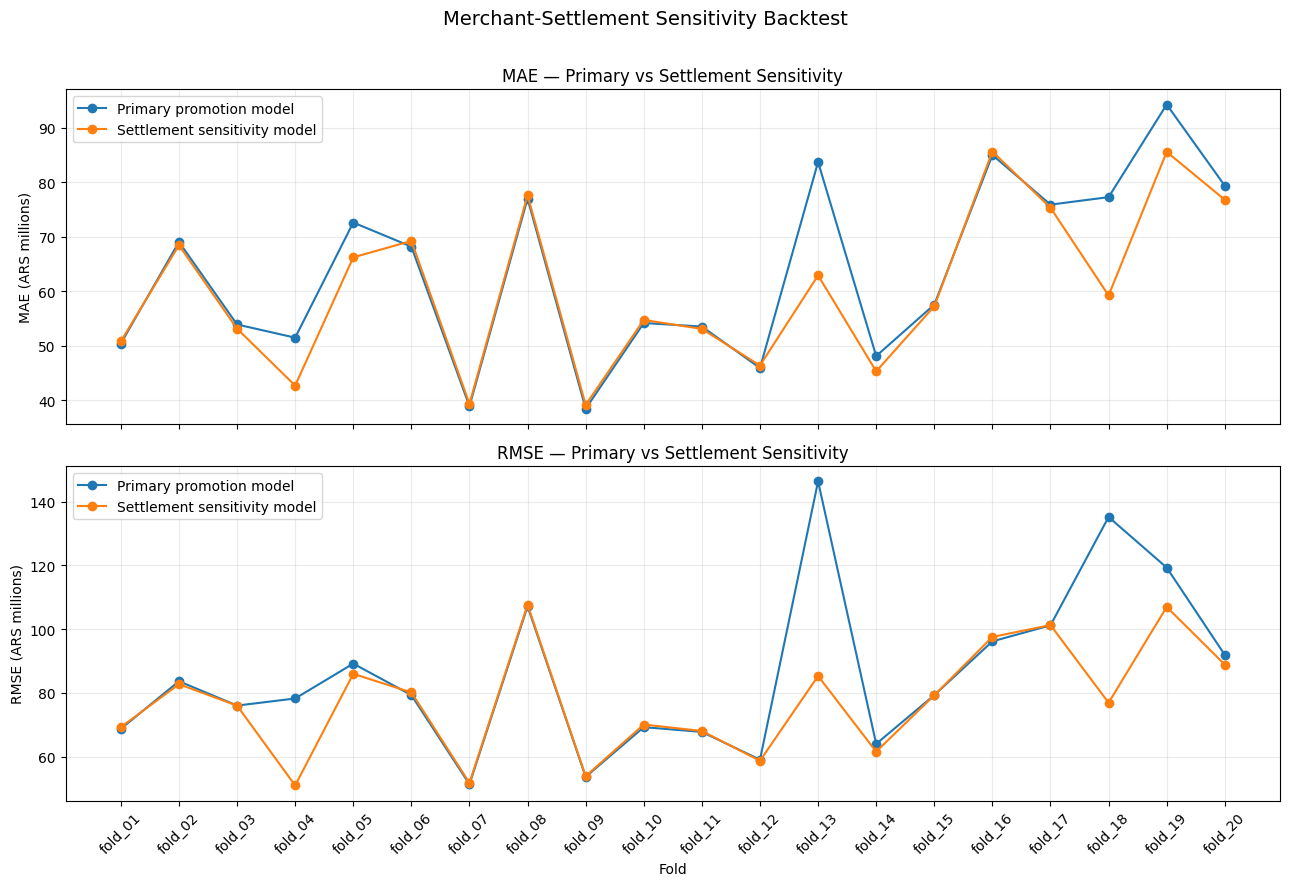

,check,observed,expected,status
0,expected_model_fits,20,20,PASS
1,expected_prediction_rows,560,560,PASS
2,expected_fold_metric_rows,20,20,PASS
3,twenty_eight_horizons_per_fold,True,True,PASS
4,twenty_eight_dates_per_fold,True,True,PASS
5,all_fits_converged,True,True,PASS
6,all_fit_statuses_pass,True,True,PASS
7,all_ma_roots_above_review_threshold,True,True,PASS
8,all_predictions_positive,True,True,PASS
9,all_predictions_finite,True,True,PASS


,model_name,specification_name,point_forecast_type,folds_evaluated,predictions,mae,rmse,mean_error,mean_actual,mean_prediction,mean_fold_mase,mean_fold_rmsse,fold_mae_standard_deviation,fold_rmse_standard_deviation,minimum_fold_mae,maximum_fold_mae,promotion_days,merchant_settlement_days
0,calendar_promotion_settlement_trend_arima011_e...,calendar_promotion_settlement_trend,lognormal_mean,20,560,60.4518,79.5164,5.2051,907.6713,912.8764,0.6331,0.5895,14.7248,17.4538,39.1473,85.6565,16,3


,comparison,primary_model,sensitivity_model,primary_mae,sensitivity_mae,mae_improvement,mae_improvement_pct,primary_rmse,sensitivity_rmse,rmse_improvement,rmse_improvement_pct,primary_mean_error,sensitivity_mean_error,out_of_sample_settlement_days,interpretation_status
0,settlement_sensitivity_vs_primary,calendar_promotion_trend_arima011_errors,calendar_promotion_settlement_trend_arima011_e...,63.7503,60.4518,3.2985,5.1741,89.4678,79.5164,9.9515,11.1230,4.4592,5.2051,3,SENSITIVITY_ONLY


,fold_id,optimizer_converged,minimum_ma_root_modulus,trend_coefficient,promotion_coefficient,settlement_coefficient,settlement_standard_error,settlement_p_value,warning_count,status
0,fold_01,True,1.0971,0.4386,1.1274,1.3901,0.1966,0.0000,0,PASS
1,fold_02,True,1.0894,0.4383,1.1340,1.3973,0.2104,0.0000,0,PASS
2,fold_03,True,1.0974,0.4090,1.1072,1.3985,0.2062,0.0000,0,PASS
3,fold_04,True,1.0911,0.4116,1.0953,1.4025,0.2104,0.0000,0,PASS
4,fold_05,True,1.0904,0.4131,1.0915,1.3478,0.1976,0.0000,0,PASS
5,fold_06,True,1.0915,0.4114,1.0933,1.3636,0.2025,0.0000,0,PASS
6,fold_07,True,1.0974,0.4062,1.0861,1.3557,0.1945,0.0000,0,PASS
7,fold_08,True,1.0988,0.4190,1.0958,1.3498,0.1888,0.0000,0,PASS
8,fold_09,True,1.0904,0.3975,1.1034,1.3541,0.2071,0.0000,0,PASS
9,fold_10,True,1.0896,0.3955,1.1045,1.3525,0.2004,0.0000,0,PASS


No settlement-sensitivity fit failures were recorded.
Settlement sensitivity fits: 20
Settlement sensitivity predictions: 560
Out-of-sample settlement dates: 3


In [33]:
# ============================================================================
# 21. Run the merchant-settlement sensitivity backtest
# ============================================================================

SETTLEMENT_SPECIFICATION = (
    "calendar_promotion_settlement_trend"
)

SETTLEMENT_MODEL_NAME = (
    f"{SETTLEMENT_SPECIFICATION}_"
    f"{ARIMA011_CANDIDATE_NAME}"
)

PRIMARY_MODEL_NAME = (
    f"{PRIMARY_MODELING_SPECIFICATION}_"
    f"{ARIMA011_CANDIDATE_NAME}"
)


# ----------------------------------------------------------------------------
# Execute the extended specification on the same twenty folds
# ----------------------------------------------------------------------------

settlement_prediction_outputs = []
settlement_fold_metric_outputs = []
settlement_fit_audit_outputs = []
settlement_coefficient_outputs = []
settlement_failure_records = []


for _, fold in folds_for_backtest.iterrows():

    try:
        (
            prediction_table,
            fold_metrics,
            fit_audit,
            coefficient_table,
        ) = fit_arima011_backtest_fold(
            fold=fold,
            specification_name=(
                SETTLEMENT_SPECIFICATION
            ),
        )

        settlement_prediction_outputs.append(
            prediction_table
        )

        settlement_fold_metric_outputs.append(
            fold_metrics
        )

        settlement_fit_audit_outputs.append(
            fit_audit
        )

        settlement_coefficient_outputs.append(
            coefficient_table
        )

    except Exception as error:

        settlement_failure_records.append(
            {
                "fold_id": fold["fold_id"],
                "specification_name": (
                    SETTLEMENT_SPECIFICATION
                ),
                "model_name": (
                    SETTLEMENT_MODEL_NAME
                ),
                "train_start": fold["train_start"],
                "train_end": fold["train_end"],
                "test_start": fold["test_start"],
                "test_end": fold["test_end"],
                "error_type": (
                    type(error).__name__
                ),
                "error_message": str(error),
            }
        )


# ----------------------------------------------------------------------------
# Consolidate the outputs
# ----------------------------------------------------------------------------

settlement_sensitivity_predictions = pd.concat(
    settlement_prediction_outputs,
    ignore_index=True,
)

settlement_sensitivity_fold_metrics = pd.concat(
    settlement_fold_metric_outputs,
    ignore_index=True,
)

settlement_sensitivity_fit_audit = pd.concat(
    settlement_fit_audit_outputs,
    ignore_index=True,
)

settlement_sensitivity_coefficients = pd.concat(
    settlement_coefficient_outputs,
    ignore_index=True,
)

settlement_sensitivity_failures = pd.DataFrame(
    settlement_failure_records,
    columns=[
        "fold_id",
        "specification_name",
        "model_name",
        "train_start",
        "train_end",
        "test_start",
        "test_end",
        "error_type",
        "error_message",
    ],
)


# ----------------------------------------------------------------------------
# Recover settlement coefficients from every fold
# ----------------------------------------------------------------------------

settlement_coefficient_summary = (
    settlement_sensitivity_coefficients.loc[
        settlement_sensitivity_coefficients[
            "parameter"
        ].eq(
            "merchant_settlement_intensity"
        )
    ][
        [
            "fold_id",
            "estimate",
            "standard_error",
            "p_value",
            "ci_95_lower",
            "ci_95_upper",
        ]
    ]
    .rename(
        columns={
            "estimate": (
                "settlement_coefficient"
            ),
            "standard_error": (
                "settlement_standard_error"
            ),
            "p_value": (
                "settlement_p_value"
            ),
            "ci_95_lower": (
                "settlement_ci_95_lower"
            ),
            "ci_95_upper": (
                "settlement_ci_95_upper"
            ),
        }
    )
)

assert settlement_coefficient_summary[
    "fold_id"
].is_unique


settlement_sensitivity_fit_audit = (
    settlement_sensitivity_fit_audit.merge(
        settlement_coefficient_summary,
        on="fold_id",
        how="left",
        validate="one_to_one",
    )
)


# ----------------------------------------------------------------------------
# Aggregate sensitivity-model metrics
# ----------------------------------------------------------------------------

settlement_errors = (
    settlement_sensitivity_predictions[
        POINT_FORECAST_COLUMN
    ].to_numpy(dtype=float)
    - settlement_sensitivity_predictions[
        "actual"
    ].to_numpy(dtype=float)
)

settlement_sensitivity_aggregate_metrics = pd.DataFrame(
    [
        {
            "model_name": SETTLEMENT_MODEL_NAME,
            "specification_name": (
                SETTLEMENT_SPECIFICATION
            ),
            "point_forecast_type": (
                POINT_FORECAST_TYPE
            ),
            "folds_evaluated": (
                settlement_sensitivity_predictions[
                    "fold_id"
                ].nunique()
            ),
            "predictions": len(
                settlement_sensitivity_predictions
            ),
            "mae": float(
                np.mean(
                    np.abs(
                        settlement_errors
                    )
                )
            ),
            "rmse": float(
                np.sqrt(
                    np.mean(
                        np.square(
                            settlement_errors
                        )
                    )
                )
            ),
            "mean_error": float(
                np.mean(
                    settlement_errors
                )
            ),
            "mean_actual": float(
                settlement_sensitivity_predictions[
                    "actual"
                ].mean()
            ),
            "mean_prediction": float(
                settlement_sensitivity_predictions[
                    POINT_FORECAST_COLUMN
                ].mean()
            ),
            "mean_fold_mase": float(
                settlement_sensitivity_fold_metrics[
                    "mase"
                ].mean()
            ),
            "mean_fold_rmsse": float(
                settlement_sensitivity_fold_metrics[
                    "rmsse"
                ].mean()
            ),
            "fold_mae_standard_deviation": float(
                settlement_sensitivity_fold_metrics[
                    "mae"
                ].std(ddof=1)
            ),
            "fold_rmse_standard_deviation": float(
                settlement_sensitivity_fold_metrics[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                settlement_sensitivity_fold_metrics[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                settlement_sensitivity_fold_metrics[
                    "mae"
                ].max()
            ),
            "promotion_days": int(
                settlement_sensitivity_predictions[
                    "is_promotion"
                ].sum()
            ),
            "merchant_settlement_days": int(
                settlement_sensitivity_predictions[
                    "is_large_merchant_settlement"
                ].sum()
            ),
        }
    ]
)


# ----------------------------------------------------------------------------
# Compare aggregate results with the validated primary model
# ----------------------------------------------------------------------------

primary_aggregate_row = (
    arima011_backtest_aggregate_metrics.loc[
        arima011_backtest_aggregate_metrics[
            "specification_name"
        ].eq(
            PRIMARY_MODELING_SPECIFICATION
        )
    ]
    .iloc[0]
)

settlement_aggregate_row = (
    settlement_sensitivity_aggregate_metrics
    .iloc[0]
)


settlement_sensitivity_vs_primary = pd.DataFrame(
    [
        {
            "comparison": (
                "settlement_sensitivity_vs_primary"
            ),
            "primary_model": PRIMARY_MODEL_NAME,
            "sensitivity_model": (
                SETTLEMENT_MODEL_NAME
            ),
            "primary_mae": float(
                primary_aggregate_row["mae"]
            ),
            "sensitivity_mae": float(
                settlement_aggregate_row["mae"]
            ),
            "mae_improvement": float(
                primary_aggregate_row["mae"]
                - settlement_aggregate_row["mae"]
            ),
            "mae_improvement_pct": float(
                100
                * (
                    primary_aggregate_row["mae"]
                    - settlement_aggregate_row["mae"]
                )
                / primary_aggregate_row["mae"]
            ),
            "primary_rmse": float(
                primary_aggregate_row["rmse"]
            ),
            "sensitivity_rmse": float(
                settlement_aggregate_row["rmse"]
            ),
            "rmse_improvement": float(
                primary_aggregate_row["rmse"]
                - settlement_aggregate_row["rmse"]
            ),
            "rmse_improvement_pct": float(
                100
                * (
                    primary_aggregate_row["rmse"]
                    - settlement_aggregate_row["rmse"]
                )
                / primary_aggregate_row["rmse"]
            ),
            "primary_mean_error": float(
                primary_aggregate_row[
                    "mean_error"
                ]
            ),
            "sensitivity_mean_error": float(
                settlement_aggregate_row[
                    "mean_error"
                ]
            ),
            "out_of_sample_settlement_days": int(
                settlement_aggregate_row[
                    "merchant_settlement_days"
                ]
            ),
            "interpretation_status": (
                "SENSITIVITY_ONLY"
            ),
        }
    ]
)


# ----------------------------------------------------------------------------
# Pipeline audit
# ----------------------------------------------------------------------------

expected_settlement_fits = N_FOLDS
expected_settlement_predictions = (
    N_FOLDS
    * FORECAST_HORIZON
)

settlement_fold_horizon_counts = (
    settlement_sensitivity_predictions
    .groupby("fold_id")[
        "forecast_horizon"
    ]
    .nunique()
)

settlement_fold_date_counts = (
    settlement_sensitivity_predictions
    .groupby("fold_id")[
        "target_date"
    ]
    .nunique()
)


settlement_sensitivity_pipeline_audit = pd.DataFrame(
    [
        {
            "check": "expected_model_fits",
            "observed": len(
                settlement_sensitivity_fit_audit
            ),
            "expected": (
                expected_settlement_fits
            ),
            "status": (
                "PASS"
                if len(
                    settlement_sensitivity_fit_audit
                )
                == expected_settlement_fits
                else "FAIL"
            ),
        },
        {
            "check": "expected_prediction_rows",
            "observed": len(
                settlement_sensitivity_predictions
            ),
            "expected": (
                expected_settlement_predictions
            ),
            "status": (
                "PASS"
                if len(
                    settlement_sensitivity_predictions
                )
                == expected_settlement_predictions
                else "FAIL"
            ),
        },
        {
            "check": "expected_fold_metric_rows",
            "observed": len(
                settlement_sensitivity_fold_metrics
            ),
            "expected": (
                expected_settlement_fits
            ),
            "status": (
                "PASS"
                if len(
                    settlement_sensitivity_fold_metrics
                )
                == expected_settlement_fits
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_horizons_per_fold",
            "observed": bool(
                settlement_fold_horizon_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_fold_horizon_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_dates_per_fold",
            "observed": bool(
                settlement_fold_date_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_fold_date_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_fits_converged",
            "observed": bool(
                settlement_sensitivity_fit_audit[
                    "optimizer_converged"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_sensitivity_fit_audit[
                    "optimizer_converged"
                ].all()
                else "REVIEW"
            ),
        },
        {
            "check": "all_fit_statuses_pass",
            "observed": bool(
                settlement_sensitivity_fit_audit[
                    "status"
                ].eq("PASS").all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_sensitivity_fit_audit[
                    "status"
                ].eq("PASS").all()
                else "REVIEW"
            ),
        },
        {
            "check": "all_ma_roots_above_review_threshold",
            "observed": bool(
                settlement_sensitivity_fit_audit[
                    "minimum_ma_root_modulus"
                ].gt(
                    MA_ROOT_REVIEW_THRESHOLD
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_sensitivity_fit_audit[
                    "minimum_ma_root_modulus"
                ].gt(
                    MA_ROOT_REVIEW_THRESHOLD
                ).all()
                else "REVIEW"
            ),
        },
        {
            "check": "all_predictions_positive",
            "observed": bool(
                settlement_sensitivity_predictions[
                    POINT_FORECAST_COLUMN
                ].gt(0).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_sensitivity_predictions[
                    POINT_FORECAST_COLUMN
                ].gt(0).all()
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_finite",
            "observed": bool(
                np.isfinite(
                    settlement_sensitivity_predictions[
                        [
                            "forecast_log_mean",
                            "forecast_log_variance",
                            POINT_FORECAST_COLUMN,
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    settlement_sensitivity_predictions[
                        [
                            "forecast_log_mean",
                            "forecast_log_variance",
                            POINT_FORECAST_COLUMN,
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "recorded_failures",
            "observed": len(
                settlement_sensitivity_failures
            ),
            "expected": 0,
            "status": (
                "PASS"
                if settlement_sensitivity_failures.empty
                else "FAIL"
            ),
        },
        {
            "check": "settlement_coefficients_available",
            "observed": int(
                settlement_sensitivity_fit_audit[
                    "settlement_coefficient"
                ].notna().sum()
            ),
            "expected": N_FOLDS,
            "status": (
                "PASS"
                if settlement_sensitivity_fit_audit[
                    "settlement_coefficient"
                ].notna().sum()
                == N_FOLDS
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save all generated tables
# ----------------------------------------------------------------------------

SETTLEMENT_PREDICTIONS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_predictions.csv"
)

SETTLEMENT_FOLD_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_fold_metrics.csv"
)

SETTLEMENT_AGGREGATE_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_aggregate_metrics.csv"
)

SETTLEMENT_VS_PRIMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_vs_primary_metrics.csv"
)

SETTLEMENT_FIT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_fit_audit.csv"
)

SETTLEMENT_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_coefficients.csv"
)

SETTLEMENT_FAILURES_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_failures.csv"
)

SETTLEMENT_PIPELINE_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_pipeline_audit.csv"
)


settlement_sensitivity_predictions.to_csv(
    SETTLEMENT_PREDICTIONS_PATH,
    index=False,
)

settlement_sensitivity_fold_metrics.to_csv(
    SETTLEMENT_FOLD_METRICS_PATH,
    index=False,
)

settlement_sensitivity_aggregate_metrics.to_csv(
    SETTLEMENT_AGGREGATE_METRICS_PATH,
    index=False,
)

settlement_sensitivity_vs_primary.to_csv(
    SETTLEMENT_VS_PRIMARY_PATH,
    index=False,
)

settlement_sensitivity_fit_audit.to_csv(
    SETTLEMENT_FIT_AUDIT_PATH,
    index=False,
)

settlement_sensitivity_coefficients.to_csv(
    SETTLEMENT_COEFFICIENTS_PATH,
    index=False,
)

settlement_sensitivity_failures.to_csv(
    SETTLEMENT_FAILURES_PATH,
    index=False,
)

settlement_sensitivity_pipeline_audit.to_csv(
    SETTLEMENT_PIPELINE_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Fold-level comparison figure
# ----------------------------------------------------------------------------

primary_fold_metrics = (
    arima011_backtest_fold_metrics.loc[
        arima011_backtest_fold_metrics[
            "specification_name"
        ].eq(
            PRIMARY_MODELING_SPECIFICATION
        )
    ]
    .sort_values("fold_id")
)

settlement_fold_metrics = (
    settlement_sensitivity_fold_metrics
    .sort_values("fold_id")
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True,
)

axes[0].plot(
    primary_fold_metrics["fold_id"],
    primary_fold_metrics["mae"],
    marker="o",
    label="Primary promotion model",
)

axes[0].plot(
    settlement_fold_metrics["fold_id"],
    settlement_fold_metrics["mae"],
    marker="o",
    label="Settlement sensitivity model",
)

axes[0].set_title(
    "MAE — Primary vs Settlement Sensitivity"
)

axes[0].set_ylabel(
    "MAE (ARS millions)"
)

axes[0].legend()
axes[0].grid(alpha=0.25)


axes[1].plot(
    primary_fold_metrics["fold_id"],
    primary_fold_metrics["rmse"],
    marker="o",
    label="Primary promotion model",
)

axes[1].plot(
    settlement_fold_metrics["fold_id"],
    settlement_fold_metrics["rmse"],
    marker="o",
    label="Settlement sensitivity model",
)

axes[1].set_title(
    "RMSE — Primary vs Settlement Sensitivity"
)

axes[1].set_xlabel("Fold")
axes[1].set_ylabel(
    "RMSE (ARS millions)"
)

axes[1].legend()
axes[1].grid(alpha=0.25)

axes[1].tick_params(
    axis="x",
    rotation=45,
)

fig.suptitle(
    "Merchant-Settlement Sensitivity Backtest",
    fontsize=14,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

SETTLEMENT_METRICS_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_sensitivity_metrics_by_fold.png"
)

fig.savefig(
    SETTLEMENT_METRICS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs and structural controls
# ----------------------------------------------------------------------------

for output_path in [
    SETTLEMENT_PREDICTIONS_PATH,
    SETTLEMENT_FOLD_METRICS_PATH,
    SETTLEMENT_AGGREGATE_METRICS_PATH,
    SETTLEMENT_VS_PRIMARY_PATH,
    SETTLEMENT_FIT_AUDIT_PATH,
    SETTLEMENT_COEFFICIENTS_PATH,
    SETTLEMENT_FAILURES_PATH,
    SETTLEMENT_PIPELINE_AUDIT_PATH,
    SETTLEMENT_METRICS_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


structural_failures = (
    settlement_sensitivity_pipeline_audit.loc[
        settlement_sensitivity_pipeline_audit[
            "status"
        ].eq("FAIL")
    ]
)

assert structural_failures.empty, (
    "The settlement sensitivity backtest failed a structural audit."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(
    settlement_sensitivity_pipeline_audit
)

display(
    settlement_sensitivity_aggregate_metrics
)

display(
    settlement_sensitivity_vs_primary
)

display(
    settlement_sensitivity_fit_audit[
        [
            "fold_id",
            "optimizer_converged",
            "minimum_ma_root_modulus",
            "trend_coefficient",
            "promotion_coefficient",
            "settlement_coefficient",
            "settlement_standard_error",
            "settlement_p_value",
            "warning_count",
            "status",
        ]
    ]
)

if not settlement_sensitivity_failures.empty:
    display(
        settlement_sensitivity_failures
    )
else:
    print(
        "No settlement-sensitivity fit failures were recorded."
    )

print(
    "Settlement sensitivity fits: "
    f"{len(settlement_sensitivity_fit_audit)}"
)

print(
    "Settlement sensitivity predictions: "
    f"{len(settlement_sensitivity_predictions)}"
)

print(
    "Out-of-sample settlement dates: "
    f"{int(settlement_sensitivity_predictions['is_large_merchant_settlement'].sum())}"
)

## 20. Out-of-sample contribution of scheduled merchant settlements

The extended sensitivity model improves aggregate MAE and RMSE relative to the
validated primary promotion model.

However, only three merchant-settlement dates occur in the complete
out-of-sample period. Therefore, the aggregate improvement must be decomposed
into:

1. Scheduled merchant-settlement dates.
2. Ordinary non-settlement dates.
3. Folds containing a settlement date.
4. Folds without settlements in the forecast horizon.

Because both models forecast the same target dates, a paired daily comparison
is possible.

The absolute-error improvement is defined as:

$$
\Delta AE_t
=
AE_{t,\text{primary}}
-
AE_{t,\text{settlement sensitivity}}
$$

The squared-error improvement is:

$$
\Delta SE_t
=
SE_{t,\text{primary}}
-
SE_{t,\text{settlement sensitivity}}
$$

Positive values indicate that the settlement-sensitivity model produced the
smaller error.

Due to the extremely limited number of settlement events, these results are
interpreted descriptively. Even a large improvement on all three dates is not
sufficient to establish broad generalizability.

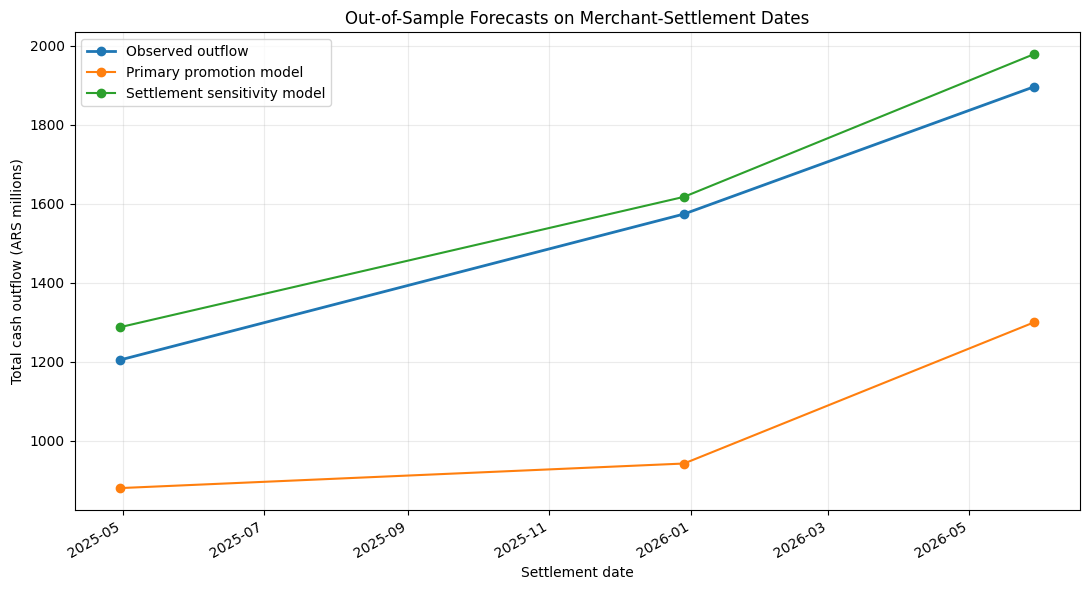

,check,observed,expected,status
0,paired_prediction_rows,560,560,PASS
1,settlement_day_rows,3,3,PASS
2,settlement_folds,3,3,PASS
3,actual_values_match_between_models,True,True,PASS
4,fold_comparison_rows,20,20,PASS
5,missing_paired_values,0,0,PASS


,evaluation_group,observations,folds_represented,primary_mae,settlement_mae,mae_improvement,mae_improvement_pct,primary_rmse,settlement_rmse,rmse_improvement,rmse_improvement_pct,primary_mean_error,settlement_mean_error
0,all_days,560,20,63.7503,60.4518,3.2985,5.1741,89.4678,79.5164,9.9515,11.1230,4.4592,5.2051
1,settlement_day,3,3,517.0599,69.6559,447.4040,86.5285,534.9351,72.0805,462.8545,86.5254,-517.0599,69.6559
2,non_settlement_day,557,20,61.3088,60.4022,0.9066,1.4787,80.6621,79.5545,1.1076,1.3731,7.2681,4.8580


,event_group,observations,folds_represented,mean_prediction_difference,mean_absolute_error_improvement,median_absolute_error_improvement,mean_squared_error_improvement,days_with_lower_absolute_error,days_with_lower_squared_error,pct_days_with_lower_absolute_error,pct_days_with_lower_squared_error
0,non_settlement_day,557,20,-2.4101,0.9066,0.4316,177.4494,301,301,54.0395,54.0395
1,settlement_day,3,3,586.7158,447.4040,513.2366,"280,959.9358",3,3,100.0000,100.0000


,has_settlement_in_test,folds,total_settlement_days,mean_mae_improvement,median_mae_improvement,folds_with_mae_improvement,mean_rmse_improvement,median_rmse_improvement,folds_with_rmse_improvement,mean_absolute_bias_improvement
0,False,17,0,1.0772,0.3044,9,1.0179,-0.0588,8,2.8859
1,True,3,3,15.8861,18.0497,3,48.8625,58.2459,3,14.9498


,fold_id,target_date,forecast_horizon,merchant_settlement_intensity,actual,primary_prediction,settlement_prediction,primary_absolute_error,settlement_absolute_error,absolute_error_improvement
0,fold_04,2025-04-30,19,0.2800,"1,205.0130",880.8106,"1,287.9354",324.2024,82.9224,241.2800
1,fold_13,2025-12-29,10,0.4000,"1,574.0530",942.9179,"1,617.4927",631.1351,43.4397,587.6954
2,fold_18,2026-05-29,21,0.3200,"1,896.1550","1,300.3128","1,978.7606",595.8422,82.6056,513.2366


Settlement dates evaluated: 3
Settlement folds evaluated: 3
Saved settlement comparison figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_settlement_day_forecast_comparison.png


In [34]:
# ============================================================================
# 22. Evaluate the out-of-sample contribution of merchant settlements
# ============================================================================

# ----------------------------------------------------------------------------
# Extract the comparable primary and sensitivity predictions
# ----------------------------------------------------------------------------

primary_predictions = (
    arima011_backtest_predictions.loc[
        arima011_backtest_predictions[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
    .copy()
    .reset_index(drop=True)
)

settlement_predictions = (
    settlement_sensitivity_predictions.loc[
        settlement_sensitivity_predictions[
            "model_name"
        ].eq(SETTLEMENT_MODEL_NAME)
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(primary_predictions) == 560
assert len(settlement_predictions) == 560


comparison_keys = [
    "fold_id",
    "target_date",
    "forecast_horizon",
]

assert not primary_predictions.duplicated(
    comparison_keys
).any()

assert not settlement_predictions.duplicated(
    comparison_keys
).any()


# ----------------------------------------------------------------------------
# Construct the paired daily table
# ----------------------------------------------------------------------------

primary_daily = primary_predictions[
    [
        *comparison_keys,
        "forecast_origin",
        "actual",
        POINT_FORECAST_COLUMN,
        "error",
        "absolute_error",
        "squared_error",
        "is_month_end",
        "is_holiday",
        "is_payday",
        "is_payday_window",
        "promotion_intensity",
        "is_promotion",
        "merchant_settlement_intensity",
        "is_large_merchant_settlement",
    ]
].rename(
    columns={
        POINT_FORECAST_COLUMN: "primary_prediction",
        "error": "primary_error",
        "absolute_error": "primary_absolute_error",
        "squared_error": "primary_squared_error",
    }
)


settlement_daily = settlement_predictions[
    [
        *comparison_keys,
        "actual",
        POINT_FORECAST_COLUMN,
        "error",
        "absolute_error",
        "squared_error",
    ]
].rename(
    columns={
        "actual": "settlement_model_actual",
        POINT_FORECAST_COLUMN: "settlement_prediction",
        "error": "settlement_error",
        "absolute_error": "settlement_absolute_error",
        "squared_error": "settlement_squared_error",
    }
)


settlement_day_paired_comparison = (
    primary_daily.merge(
        settlement_daily,
        on=comparison_keys,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        [
            "fold_id",
            "target_date",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Confirm that both models forecast the same observations
# ----------------------------------------------------------------------------

actual_values_match = bool(
    np.allclose(
        settlement_day_paired_comparison[
            "actual"
        ].to_numpy(dtype=float),
        settlement_day_paired_comparison[
            "settlement_model_actual"
        ].to_numpy(dtype=float),
        rtol=0.0,
        atol=0.0,
    )
)

assert actual_values_match

settlement_day_paired_comparison = (
    settlement_day_paired_comparison.drop(
        columns=["settlement_model_actual"]
    )
)


# ----------------------------------------------------------------------------
# Calculate paired loss improvements
# ----------------------------------------------------------------------------

settlement_day_paired_comparison[
    "absolute_error_improvement"
] = (
    settlement_day_paired_comparison[
        "primary_absolute_error"
    ]
    - settlement_day_paired_comparison[
        "settlement_absolute_error"
    ]
)

settlement_day_paired_comparison[
    "squared_error_improvement"
] = (
    settlement_day_paired_comparison[
        "primary_squared_error"
    ]
    - settlement_day_paired_comparison[
        "settlement_squared_error"
    ]
)

settlement_day_paired_comparison[
    "settlement_model_better_absolute_error"
] = (
    settlement_day_paired_comparison[
        "absolute_error_improvement"
    ] > 0
)

settlement_day_paired_comparison[
    "settlement_model_better_squared_error"
] = (
    settlement_day_paired_comparison[
        "squared_error_improvement"
    ] > 0
)

settlement_day_paired_comparison[
    "prediction_difference"
] = (
    settlement_day_paired_comparison[
        "settlement_prediction"
    ]
    - settlement_day_paired_comparison[
        "primary_prediction"
    ]
)

settlement_day_paired_comparison[
    "event_group"
] = np.where(
    settlement_day_paired_comparison[
        "is_large_merchant_settlement"
    ].eq(1),
    "settlement_day",
    "non_settlement_day",
)


# ----------------------------------------------------------------------------
# Long-format model predictions
# ----------------------------------------------------------------------------

long_settlement_data = pd.concat(
    [
        primary_predictions.assign(
            comparison_model="primary_promotion"
        ),
        settlement_predictions.assign(
            comparison_model="settlement_sensitivity"
        ),
    ],
    ignore_index=True,
)

long_settlement_data[
    "event_group"
] = np.where(
    long_settlement_data[
        "is_large_merchant_settlement"
    ].eq(1),
    "settlement_day",
    "non_settlement_day",
)


# ----------------------------------------------------------------------------
# Model metrics by settlement status
# ----------------------------------------------------------------------------

evaluation_groups = {
    "all_days": (
        long_settlement_data.index
        == long_settlement_data.index
    ),
    "settlement_day": (
        long_settlement_data[
            "is_large_merchant_settlement"
        ].eq(1)
    ),
    "non_settlement_day": (
        long_settlement_data[
            "is_large_merchant_settlement"
        ].eq(0)
    ),
}


settlement_metric_records = []

for evaluation_group, group_mask in evaluation_groups.items():

    group_data = long_settlement_data.loc[
        group_mask
    ]

    for comparison_model, model_data in group_data.groupby(
        "comparison_model"
    ):

        model_errors = (
            model_data[
                POINT_FORECAST_COLUMN
            ].to_numpy(dtype=float)
            - model_data[
                "actual"
            ].to_numpy(dtype=float)
        )

        settlement_metric_records.append(
            {
                "evaluation_group": evaluation_group,
                "comparison_model": comparison_model,
                "observations": len(model_data),
                "folds_represented": (
                    model_data[
                        "fold_id"
                    ].nunique()
                ),
                "mae": float(
                    np.mean(
                        np.abs(model_errors)
                    )
                ),
                "rmse": float(
                    np.sqrt(
                        np.mean(
                            np.square(model_errors)
                        )
                    )
                ),
                "mean_error": float(
                    np.mean(model_errors)
                ),
                "mean_actual": float(
                    model_data["actual"].mean()
                ),
                "mean_prediction": float(
                    model_data[
                        POINT_FORECAST_COLUMN
                    ].mean()
                ),
            }
        )


settlement_day_model_metrics = pd.DataFrame(
    settlement_metric_records
)


# ----------------------------------------------------------------------------
# Relative improvements by event group
# ----------------------------------------------------------------------------

settlement_group_improvement_records = []

for evaluation_group in (
    settlement_day_model_metrics[
        "evaluation_group"
    ].unique()
):

    primary_group_metrics = (
        settlement_day_model_metrics.loc[
            settlement_day_model_metrics[
                "evaluation_group"
            ].eq(evaluation_group)
            & settlement_day_model_metrics[
                "comparison_model"
            ].eq("primary_promotion")
        ]
        .iloc[0]
    )

    sensitivity_group_metrics = (
        settlement_day_model_metrics.loc[
            settlement_day_model_metrics[
                "evaluation_group"
            ].eq(evaluation_group)
            & settlement_day_model_metrics[
                "comparison_model"
            ].eq("settlement_sensitivity")
        ]
        .iloc[0]
    )

    settlement_group_improvement_records.append(
        {
            "evaluation_group": evaluation_group,
            "observations": int(
                primary_group_metrics[
                    "observations"
                ]
            ),
            "folds_represented": int(
                primary_group_metrics[
                    "folds_represented"
                ]
            ),
            "primary_mae": float(
                primary_group_metrics["mae"]
            ),
            "settlement_mae": float(
                sensitivity_group_metrics["mae"]
            ),
            "mae_improvement": float(
                primary_group_metrics["mae"]
                - sensitivity_group_metrics["mae"]
            ),
            "mae_improvement_pct": float(
                100
                * (
                    primary_group_metrics["mae"]
                    - sensitivity_group_metrics["mae"]
                )
                / primary_group_metrics["mae"]
            ),
            "primary_rmse": float(
                primary_group_metrics["rmse"]
            ),
            "settlement_rmse": float(
                sensitivity_group_metrics["rmse"]
            ),
            "rmse_improvement": float(
                primary_group_metrics["rmse"]
                - sensitivity_group_metrics["rmse"]
            ),
            "rmse_improvement_pct": float(
                100
                * (
                    primary_group_metrics["rmse"]
                    - sensitivity_group_metrics["rmse"]
                )
                / primary_group_metrics["rmse"]
            ),
            "primary_mean_error": float(
                primary_group_metrics[
                    "mean_error"
                ]
            ),
            "settlement_mean_error": float(
                sensitivity_group_metrics[
                    "mean_error"
                ]
            ),
        }
    )


settlement_group_improvements = pd.DataFrame(
    settlement_group_improvement_records
)


# ----------------------------------------------------------------------------
# Daily paired summary
# ----------------------------------------------------------------------------

settlement_paired_daily_summary = (
    settlement_day_paired_comparison
    .groupby(
        "event_group",
        as_index=False,
    )
    .agg(
        observations=(
            "target_date",
            "size",
        ),
        folds_represented=(
            "fold_id",
            "nunique",
        ),
        mean_prediction_difference=(
            "prediction_difference",
            "mean",
        ),
        mean_absolute_error_improvement=(
            "absolute_error_improvement",
            "mean",
        ),
        median_absolute_error_improvement=(
            "absolute_error_improvement",
            "median",
        ),
        mean_squared_error_improvement=(
            "squared_error_improvement",
            "mean",
        ),
        days_with_lower_absolute_error=(
            "settlement_model_better_absolute_error",
            "sum",
        ),
        days_with_lower_squared_error=(
            "settlement_model_better_squared_error",
            "sum",
        ),
    )
)

settlement_paired_daily_summary[
    "pct_days_with_lower_absolute_error"
] = (
    100
    * settlement_paired_daily_summary[
        "days_with_lower_absolute_error"
    ]
    / settlement_paired_daily_summary[
        "observations"
    ]
)

settlement_paired_daily_summary[
    "pct_days_with_lower_squared_error"
] = (
    100
    * settlement_paired_daily_summary[
        "days_with_lower_squared_error"
    ]
    / settlement_paired_daily_summary[
        "observations"
    ]
)


# ----------------------------------------------------------------------------
# Fold-level comparison
# ----------------------------------------------------------------------------

primary_fold_metrics = (
    arima011_backtest_fold_metrics.loc[
        arima011_backtest_fold_metrics[
            "specification_name"
        ].eq(
            PRIMARY_MODELING_SPECIFICATION
        )
    ][
        [
            "fold_id",
            "test_start",
            "test_end",
            "mae",
            "rmse",
            "mean_error",
            "merchant_settlement_days",
        ]
    ]
    .rename(
        columns={
            "mae": "primary_mae",
            "rmse": "primary_rmse",
            "mean_error": "primary_mean_error",
        }
    )
)


sensitivity_fold_metrics = (
    settlement_sensitivity_fold_metrics[
        [
            "fold_id",
            "mae",
            "rmse",
            "mean_error",
            "merchant_settlement_days",
        ]
    ]
    .rename(
        columns={
            "mae": "settlement_mae",
            "rmse": "settlement_rmse",
            "mean_error": "settlement_mean_error",
            "merchant_settlement_days": (
                "settlement_days_check"
            ),
        }
    )
)


settlement_fold_comparison = (
    primary_fold_metrics.merge(
        sensitivity_fold_metrics,
        on="fold_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("fold_id")
    .reset_index(drop=True)
)


assert settlement_fold_comparison[
    "merchant_settlement_days"
].eq(
    settlement_fold_comparison[
        "settlement_days_check"
    ]
).all()


settlement_fold_comparison = (
    settlement_fold_comparison.drop(
        columns=["settlement_days_check"]
    )
)

settlement_fold_comparison[
    "has_settlement_in_test"
] = (
    settlement_fold_comparison[
        "merchant_settlement_days"
    ].gt(0)
)

settlement_fold_comparison[
    "mae_improvement"
] = (
    settlement_fold_comparison[
        "primary_mae"
    ]
    - settlement_fold_comparison[
        "settlement_mae"
    ]
)

settlement_fold_comparison[
    "rmse_improvement"
] = (
    settlement_fold_comparison[
        "primary_rmse"
    ]
    - settlement_fold_comparison[
        "settlement_rmse"
    ]
)

settlement_fold_comparison[
    "absolute_bias_improvement"
] = (
    settlement_fold_comparison[
        "primary_mean_error"
    ].abs()
    - settlement_fold_comparison[
        "settlement_mean_error"
    ].abs()
)


settlement_fold_group_summary = (
    settlement_fold_comparison
    .groupby(
        "has_settlement_in_test",
        as_index=False,
    )
    .agg(
        folds=("fold_id", "size"),
        total_settlement_days=(
            "merchant_settlement_days",
            "sum",
        ),
        mean_mae_improvement=(
            "mae_improvement",
            "mean",
        ),
        median_mae_improvement=(
            "mae_improvement",
            "median",
        ),
        folds_with_mae_improvement=(
            "mae_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        mean_rmse_improvement=(
            "rmse_improvement",
            "mean",
        ),
        median_rmse_improvement=(
            "rmse_improvement",
            "median",
        ),
        folds_with_rmse_improvement=(
            "rmse_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        mean_absolute_bias_improvement=(
            "absolute_bias_improvement",
            "mean",
        ),
    )
)


# ----------------------------------------------------------------------------
# Structural audit
# ----------------------------------------------------------------------------

settlement_effect_audit = pd.DataFrame(
    [
        {
            "check": "paired_prediction_rows",
            "observed": len(
                settlement_day_paired_comparison
            ),
            "expected": 560,
            "status": (
                "PASS"
                if len(
                    settlement_day_paired_comparison
                ) == 560
                else "FAIL"
            ),
        },
        {
            "check": "settlement_day_rows",
            "observed": int(
                settlement_day_paired_comparison[
                    "is_large_merchant_settlement"
                ].sum()
            ),
            "expected": 3,
            "status": (
                "PASS"
                if settlement_day_paired_comparison[
                    "is_large_merchant_settlement"
                ].sum() == 3
                else "FAIL"
            ),
        },
        {
            "check": "settlement_folds",
            "observed": int(
                settlement_day_paired_comparison.loc[
                    settlement_day_paired_comparison[
                        "is_large_merchant_settlement"
                    ].eq(1),
                    "fold_id",
                ].nunique()
            ),
            "expected": 3,
            "status": (
                "PASS"
                if settlement_day_paired_comparison.loc[
                    settlement_day_paired_comparison[
                        "is_large_merchant_settlement"
                    ].eq(1),
                    "fold_id",
                ].nunique() == 3
                else "FAIL"
            ),
        },
        {
            "check": "actual_values_match_between_models",
            "observed": actual_values_match,
            "expected": True,
            "status": (
                "PASS"
                if actual_values_match
                else "FAIL"
            ),
        },
        {
            "check": "fold_comparison_rows",
            "observed": len(
                settlement_fold_comparison
            ),
            "expected": N_FOLDS,
            "status": (
                "PASS"
                if len(
                    settlement_fold_comparison
                ) == N_FOLDS
                else "FAIL"
            ),
        },
        {
            "check": "missing_paired_values",
            "observed": int(
                settlement_day_paired_comparison[
                    [
                        "actual",
                        "primary_prediction",
                        "settlement_prediction",
                        "absolute_error_improvement",
                    ]
                ].isna().sum().sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if settlement_day_paired_comparison[
                    [
                        "actual",
                        "primary_prediction",
                        "settlement_prediction",
                        "absolute_error_improvement",
                    ]
                ].isna().sum().sum() == 0
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

SETTLEMENT_DAY_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_day_model_metrics.csv"
)

SETTLEMENT_GROUP_IMPROVEMENTS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_group_improvements.csv"
)

SETTLEMENT_DAY_PAIRED_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_day_paired_comparison.csv"
)

SETTLEMENT_PAIRED_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_day_paired_summary.csv"
)

SETTLEMENT_FOLD_COMPARISON_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_fold_comparison.csv"
)

SETTLEMENT_FOLD_GROUP_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_fold_group_summary.csv"
)

SETTLEMENT_EFFECT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_effect_audit.csv"
)


settlement_day_model_metrics.to_csv(
    SETTLEMENT_DAY_METRICS_PATH,
    index=False,
)

settlement_group_improvements.to_csv(
    SETTLEMENT_GROUP_IMPROVEMENTS_PATH,
    index=False,
)

settlement_day_paired_comparison.to_csv(
    SETTLEMENT_DAY_PAIRED_PATH,
    index=False,
)

settlement_paired_daily_summary.to_csv(
    SETTLEMENT_PAIRED_SUMMARY_PATH,
    index=False,
)

settlement_fold_comparison.to_csv(
    SETTLEMENT_FOLD_COMPARISON_PATH,
    index=False,
)

settlement_fold_group_summary.to_csv(
    SETTLEMENT_FOLD_GROUP_SUMMARY_PATH,
    index=False,
)

settlement_effect_audit.to_csv(
    SETTLEMENT_EFFECT_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Settlement-day forecast comparison figure
# ----------------------------------------------------------------------------

settlement_plot_data = (
    settlement_day_paired_comparison.loc[
        settlement_day_paired_comparison[
            "is_large_merchant_settlement"
        ].eq(1)
    ]
    .sort_values("target_date")
    .reset_index(drop=True)
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.plot(
    settlement_plot_data[
        "target_date"
    ],
    settlement_plot_data["actual"],
    marker="o",
    linewidth=2,
    label="Observed outflow",
)

ax.plot(
    settlement_plot_data[
        "target_date"
    ],
    settlement_plot_data[
        "primary_prediction"
    ],
    marker="o",
    label="Primary promotion model",
)

ax.plot(
    settlement_plot_data[
        "target_date"
    ],
    settlement_plot_data[
        "settlement_prediction"
    ],
    marker="o",
    label="Settlement sensitivity model",
)

ax.set_title(
    "Out-of-Sample Forecasts on Merchant-Settlement Dates"
)

ax.set_xlabel("Settlement date")
ax.set_ylabel(
    "Total cash outflow (ARS millions)"
)

ax.legend()
ax.grid(alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()

SETTLEMENT_DAY_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_settlement_day_forecast_comparison.png"
)

fig.savefig(
    SETTLEMENT_DAY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs
# ----------------------------------------------------------------------------

for output_path in [
    SETTLEMENT_DAY_METRICS_PATH,
    SETTLEMENT_GROUP_IMPROVEMENTS_PATH,
    SETTLEMENT_DAY_PAIRED_PATH,
    SETTLEMENT_PAIRED_SUMMARY_PATH,
    SETTLEMENT_FOLD_COMPARISON_PATH,
    SETTLEMENT_FOLD_GROUP_SUMMARY_PATH,
    SETTLEMENT_EFFECT_AUDIT_PATH,
    SETTLEMENT_DAY_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert settlement_effect_audit[
    "status"
].eq("PASS").all(), (
    "The settlement-effect analysis failed at least one audit."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(settlement_effect_audit)

display(settlement_group_improvements)

display(settlement_paired_daily_summary)

display(settlement_fold_group_summary)

display(
    settlement_plot_data[
        [
            "fold_id",
            "target_date",
            "forecast_horizon",
            "merchant_settlement_intensity",
            "actual",
            "primary_prediction",
            "settlement_prediction",
            "primary_absolute_error",
            "settlement_absolute_error",
            "absolute_error_improvement",
        ]
    ]
)

print(
    "Settlement dates evaluated: "
    f"{len(settlement_plot_data)}"
)

print(
    "Settlement folds evaluated: "
    f"{settlement_plot_data['fold_id'].nunique()}"
)

print(
    "Saved settlement comparison figure: "
    f"{SETTLEMENT_DAY_FIGURE_PATH}"
)

## 21. Merchant-settlement feature decision

The out-of-sample analysis confirms that scheduled merchant-settlement
information has substantial predictive value within the available synthetic
dataset.

Across the three settlement dates:

- MAE decreases by approximately 86.5%.
- RMSE decreases by approximately 86.5%.
- Absolute and squared errors decrease on all three dates.
- The large negative bias of the primary model is substantially corrected.

The extended specification also produces a small improvement on
non-settlement dates and remains numerically stable across all twenty folds.

Nevertheless, only three settlement observations are available out of sample.
This is insufficient to claim broad generalizability or to replace the
validated primary model unconditionally.

Two operational variants are therefore retained:

1. **Operational core model:** `calendar_promotion_trend`.
2. **Conditional event-aware variant:**
   `calendar_promotion_settlement_trend`.

The event-aware variant should be used only when a complete and reliable
merchant-settlement schedule is available at the forecast origin for the
entire 28-day horizon. Otherwise, the operational core model remains the
fallback.

The settlement coefficient represents a predictive association in the
synthetic dataset and should not be interpreted automatically as a causal
effect.

In [35]:
# ============================================================================
# 23. Freeze the merchant-settlement and operational-variant decisions
# ============================================================================

OPERATIONAL_CORE_SPECIFICATION = (
    "calendar_promotion_trend"
)

CONDITIONAL_SETTLEMENT_SPECIFICATION = (
    "calendar_promotion_settlement_trend"
)

ABLATION_SPECIFICATION = (
    "calendar_core_trend"
)


# ----------------------------------------------------------------------------
# Recover the validated evidence
# ----------------------------------------------------------------------------

settlement_day_evidence = (
    settlement_group_improvements.loc[
        settlement_group_improvements[
            "evaluation_group"
        ].eq("settlement_day")
    ]
    .iloc[0]
)

non_settlement_day_evidence = (
    settlement_group_improvements.loc[
        settlement_group_improvements[
            "evaluation_group"
        ].eq("non_settlement_day")
    ]
    .iloc[0]
)

settlement_daily_evidence = (
    settlement_paired_daily_summary.loc[
        settlement_paired_daily_summary[
            "event_group"
        ].eq("settlement_day")
    ]
    .iloc[0]
)

settlement_fold_evidence = (
    settlement_fold_group_summary.loc[
        settlement_fold_group_summary[
            "has_settlement_in_test"
        ].eq(True)
    ]
    .iloc[0]
)

settlement_fit_evidence = (
    settlement_sensitivity_fit_audit
    .copy()
)


# ----------------------------------------------------------------------------
# Merchant-settlement feature decision
# ----------------------------------------------------------------------------

merchant_settlement_feature_decision = pd.DataFrame(
    [
        {
            "feature": (
                "merchant_settlement_intensity"
            ),
            "future_availability": (
                "known_in_advance_under_schedule_assumption"
            ),
            "previous_role": (
                "sensitivity_only"
            ),
            "final_role": (
                "conditional_operational_regressor"
            ),
            "activation_condition": (
                "Use only when a complete and reliable settlement "
                "schedule is available at the forecast origin for "
                "the full 28-day horizon."
            ),
            "fallback_specification": (
                OPERATIONAL_CORE_SPECIFICATION
            ),
            "out_of_sample_settlement_days": int(
                settlement_day_evidence[
                    "observations"
                ]
            ),
            "settlement_folds": int(
                settlement_day_evidence[
                    "folds_represented"
                ]
            ),
            "primary_settlement_day_mae": float(
                settlement_day_evidence[
                    "primary_mae"
                ]
            ),
            "extended_settlement_day_mae": float(
                settlement_day_evidence[
                    "settlement_mae"
                ]
            ),
            "settlement_day_mae_improvement_pct": float(
                settlement_day_evidence[
                    "mae_improvement_pct"
                ]
            ),
            "primary_settlement_day_rmse": float(
                settlement_day_evidence[
                    "primary_rmse"
                ]
            ),
            "extended_settlement_day_rmse": float(
                settlement_day_evidence[
                    "settlement_rmse"
                ]
            ),
            "settlement_day_rmse_improvement_pct": float(
                settlement_day_evidence[
                    "rmse_improvement_pct"
                ]
            ),
            "settlement_days_with_lower_absolute_error": int(
                settlement_daily_evidence[
                    "days_with_lower_absolute_error"
                ]
            ),
            "settlement_days_with_lower_error_pct": float(
                settlement_daily_evidence[
                    "pct_days_with_lower_absolute_error"
                ]
            ),
            "settlement_folds_with_mae_improvement": int(
                settlement_fold_evidence[
                    "folds_with_mae_improvement"
                ]
            ),
            "non_settlement_day_mae_improvement_pct": float(
                non_settlement_day_evidence[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_fold_coefficient": float(
                settlement_fit_evidence[
                    "settlement_coefficient"
                ].min()
            ),
            "maximum_fold_coefficient": float(
                settlement_fit_evidence[
                    "settlement_coefficient"
                ].max()
            ),
            "successful_fold_fits": int(
                settlement_fit_evidence[
                    "status"
                ].eq("PASS").sum()
            ),
            "generalization_status": (
                "LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT"
            ),
            "decision_reason": (
                "The scheduled-settlement regressor strongly corrects "
                "underprediction on all three observed settlement dates "
                "and remains stable across folds. It is retained only "
                "as a conditional event-aware extension because three "
                "out-of-sample events are insufficient for broad "
                "generalization."
            ),
            "review_status": "VALIDATED",
        }
    ]
)


# ----------------------------------------------------------------------------
# Operational model registry
# ----------------------------------------------------------------------------

dynamic_regression_operational_variants = pd.DataFrame(
    [
        {
            "model_variant": (
                "operational_core"
            ),
            "specification_name": (
                OPERATIONAL_CORE_SPECIFICATION
            ),
            "model_name": (
                f"{OPERATIONAL_CORE_SPECIFICATION}_"
                f"{ARIMA011_CANDIDATE_NAME}"
            ),
            "error_model": (
                ARIMA011_CANDIDATE_NAME
            ),
            "order": str(
                ARIMA011_ORDER
            ),
            "point_forecast_transformation": (
                POINT_FORECAST_TYPE
            ),
            "usage_condition": (
                "Default dynamic-regression forecast."
            ),
            "promotion_information_required": True,
            "settlement_schedule_required": False,
            "evaluation_role": (
                "primary_operational_model"
            ),
            "validation_status": "VALIDATED",
        },
        {
            "model_variant": (
                "conditional_settlement_event_aware"
            ),
            "specification_name": (
                CONDITIONAL_SETTLEMENT_SPECIFICATION
            ),
            "model_name": (
                f"{CONDITIONAL_SETTLEMENT_SPECIFICATION}_"
                f"{ARIMA011_CANDIDATE_NAME}"
            ),
            "error_model": (
                ARIMA011_CANDIDATE_NAME
            ),
            "order": str(
                ARIMA011_ORDER
            ),
            "point_forecast_transformation": (
                POINT_FORECAST_TYPE
            ),
            "usage_condition": (
                "Use only when the full 28-day scheduled-settlement "
                "path is known and operationally reliable."
            ),
            "promotion_information_required": True,
            "settlement_schedule_required": True,
            "evaluation_role": (
                "conditional_operational_variant"
            ),
            "validation_status": (
                "VALIDATED_WITH_LIMITED_EVENT_SUPPORT"
            ),
        },
        {
            "model_variant": (
                "promotion_ablation"
            ),
            "specification_name": (
                ABLATION_SPECIFICATION
            ),
            "model_name": (
                f"{ABLATION_SPECIFICATION}_"
                f"{ARIMA011_CANDIDATE_NAME}"
            ),
            "error_model": (
                ARIMA011_CANDIDATE_NAME
            ),
            "order": str(
                ARIMA011_ORDER
            ),
            "point_forecast_transformation": (
                POINT_FORECAST_TYPE
            ),
            "usage_condition": (
                "Retained only to quantify the incremental value "
                "of planned promotion information."
            ),
            "promotion_information_required": False,
            "settlement_schedule_required": False,
            "evaluation_role": "ablation_only",
            "validation_status": "VALIDATED",
        },
    ]
)


# ----------------------------------------------------------------------------
# Decision audit
# ----------------------------------------------------------------------------

settlement_decision_audit = pd.DataFrame(
    [
        {
            "check": "settlement_days_evaluated",
            "observed": int(
                settlement_day_evidence[
                    "observations"
                ]
            ),
            "expected": 3,
            "status": (
                "PASS"
                if int(
                    settlement_day_evidence[
                        "observations"
                    ]
                ) == 3
                else "FAIL"
            ),
        },
        {
            "check": "settlement_folds_evaluated",
            "observed": int(
                settlement_day_evidence[
                    "folds_represented"
                ]
            ),
            "expected": 3,
            "status": (
                "PASS"
                if int(
                    settlement_day_evidence[
                        "folds_represented"
                    ]
                ) == 3
                else "FAIL"
            ),
        },
        {
            "check": "all_settlement_days_improve",
            "observed": int(
                settlement_daily_evidence[
                    "days_with_lower_absolute_error"
                ]
            ),
            "expected": 3,
            "status": (
                "PASS"
                if int(
                    settlement_daily_evidence[
                        "days_with_lower_absolute_error"
                    ]
                ) == 3
                else "FAIL"
            ),
        },
        {
            "check": "settlement_day_mae_improves",
            "observed": bool(
                settlement_day_evidence[
                    "mae_improvement"
                ] > 0
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_day_evidence[
                    "mae_improvement"
                ] > 0
                else "FAIL"
            ),
        },
        {
            "check": "non_settlement_day_mae_does_not_deteriorate",
            "observed": bool(
                non_settlement_day_evidence[
                    "mae_improvement"
                ] >= 0
            ),
            "expected": True,
            "status": (
                "PASS"
                if non_settlement_day_evidence[
                    "mae_improvement"
                ] >= 0
                else "FAIL"
            ),
        },
        {
            "check": "all_settlement_coefficients_positive",
            "observed": bool(
                settlement_fit_evidence[
                    "settlement_coefficient"
                ].gt(0).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if settlement_fit_evidence[
                    "settlement_coefficient"
                ].gt(0).all()
                else "FAIL"
            ),
        },
        {
            "check": "all_extended_fits_pass",
            "observed": int(
                settlement_fit_evidence[
                    "status"
                ].eq("PASS").sum()
            ),
            "expected": N_FOLDS,
            "status": (
                "PASS"
                if settlement_fit_evidence[
                    "status"
                ].eq("PASS").sum()
                == N_FOLDS
                else "FAIL"
            ),
        },
        {
            "check": "limited_support_guardrail_recorded",
            "observed": (
                merchant_settlement_feature_decision[
                    "generalization_status"
                ].iloc[0]
            ),
            "expected": (
                "LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT"
            ),
            "status": (
                "PASS"
                if merchant_settlement_feature_decision[
                    "generalization_status"
                ].iloc[0]
                == "LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT"
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save and verify outputs
# ----------------------------------------------------------------------------

SETTLEMENT_FEATURE_DECISION_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_merchant_settlement_feature_decision.csv"
)

OPERATIONAL_VARIANTS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_dynamic_regression_operational_variants.csv"
)

SETTLEMENT_DECISION_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_merchant_settlement_decision_audit.csv"
)

merchant_settlement_feature_decision.to_csv(
    SETTLEMENT_FEATURE_DECISION_PATH,
    index=False,
)

dynamic_regression_operational_variants.to_csv(
    OPERATIONAL_VARIANTS_PATH,
    index=False,
)

settlement_decision_audit.to_csv(
    SETTLEMENT_DECISION_AUDIT_PATH,
    index=False,
)

for output_path in [
    SETTLEMENT_FEATURE_DECISION_PATH,
    OPERATIONAL_VARIANTS_PATH,
    SETTLEMENT_DECISION_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )

assert settlement_decision_audit[
    "status"
].eq("PASS").all()


# ----------------------------------------------------------------------------
# Display the frozen decisions
# ----------------------------------------------------------------------------

display(settlement_decision_audit)

display(merchant_settlement_feature_decision)

display(dynamic_regression_operational_variants)

print(
    "Operational core specification: "
    f"{OPERATIONAL_CORE_SPECIFICATION}"
)

print(
    "Conditional settlement specification: "
    f"{CONDITIONAL_SETTLEMENT_SPECIFICATION}"
)

print(
    "Settlement generalization status: "
    "LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT"
)

,check,observed,expected,status
0,settlement_days_evaluated,3,3,PASS
1,settlement_folds_evaluated,3,3,PASS
2,all_settlement_days_improve,3,3,PASS
3,settlement_day_mae_improves,True,True,PASS
4,non_settlement_day_mae_does_not_deteriorate,True,True,PASS
5,all_settlement_coefficients_positive,True,True,PASS
6,all_extended_fits_pass,20,20,PASS
7,limited_support_guardrail_recorded,LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT,LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT,PASS


,feature,future_availability,previous_role,final_role,activation_condition,fallback_specification,out_of_sample_settlement_days,settlement_folds,primary_settlement_day_mae,extended_settlement_day_mae,settlement_day_mae_improvement_pct,primary_settlement_day_rmse,extended_settlement_day_rmse,settlement_day_rmse_improvement_pct,settlement_days_with_lower_absolute_error,settlement_days_with_lower_error_pct,settlement_folds_with_mae_improvement,non_settlement_day_mae_improvement_pct,minimum_fold_coefficient,maximum_fold_coefficient,successful_fold_fits,generalization_status,decision_reason,review_status
0,merchant_settlement_intensity,known_in_advance_under_schedule_assumption,sensitivity_only,conditional_operational_regressor,Use only when a complete and reliable settleme...,calendar_promotion_trend,3,3,517.0599,69.6559,86.5285,534.9351,72.0805,86.5254,3,100.0000,3,1.4787,1.2724,1.4025,20,LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT,The scheduled-settlement regressor strongly co...,VALIDATED


,model_variant,specification_name,model_name,error_model,order,point_forecast_transformation,usage_condition,promotion_information_required,settlement_schedule_required,evaluation_role,validation_status
0,operational_core,calendar_promotion_trend,calendar_promotion_trend_arima011_errors,arima011_errors,"(0, 1, 1)",lognormal_mean,Default dynamic-regression forecast.,True,False,primary_operational_model,VALIDATED
1,conditional_settlement_event_aware,calendar_promotion_settlement_trend,calendar_promotion_settlement_trend_arima011_e...,arima011_errors,"(0, 1, 1)",lognormal_mean,Use only when the full 28-day scheduled-settle...,True,True,conditional_operational_variant,VALIDATED_WITH_LIMITED_EVENT_SUPPORT
2,promotion_ablation,calendar_core_trend,calendar_core_trend_arima011_errors,arima011_errors,"(0, 1, 1)",lognormal_mean,Retained only to quantify the incremental valu...,False,False,ablation_only,VALIDATED


Operational core specification: calendar_promotion_trend
Conditional settlement specification: calendar_promotion_settlement_trend
Settlement generalization status: LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT


## 22. Notebook 03 output inventory

The validated dynamic-regression models must be compared against the best
benchmark and the selected ETS model using exactly the same rolling-origin
folds.

The required Notebook 03 reference models are:

- `historical_weekday_average`
- `ets_log_damped_additive`

Before merging any results, all CSV outputs generated by Notebook 03 are
inventoried. Each file is inspected for:

- Row and column counts.
- Available column names.
- Presence of model identifiers.
- Presence of fold identifiers.
- Presence of prediction and metric fields.
- Occurrence of the two required reference models.

This prevents the final comparison from relying on assumed file names or
incompatible table structures.

In [36]:
# ============================================================================
# 24. Inventory Notebook 03 outputs required for model comparison
# ============================================================================

NOTEBOOK03_PREFIX = "03"

REFERENCE_NOTEBOOK03_MODELS = [
    "historical_weekday_average",
    "ets_log_damped_additive",
]


# ----------------------------------------------------------------------------
# Locate every Notebook 03 CSV output
# ----------------------------------------------------------------------------

notebook03_csv_paths = sorted(
    DATA_PROCESSED_DIR.glob(
        f"{NOTEBOOK03_PREFIX}_*.csv"
    )
)

assert notebook03_csv_paths, (
    "No Notebook 03 CSV outputs were found in data/processed."
)


# ----------------------------------------------------------------------------
# Inspect file structures and search for the required model identifiers
# ----------------------------------------------------------------------------

inventory_records = []
model_match_records = []

candidate_model_columns = [
    "model_name",
    "model",
    "benchmark_name",
    "candidate_name",
    "selected_model",
    "specification_name",
]

metric_like_columns = {
    "mae",
    "rmse",
    "mean_error",
    "mase",
    "rmsse",
}

prediction_like_columns = {
    "prediction",
    "forecast",
    "forecast_value",
    "y_pred",
    "actual",
    "target_date",
    "forecast_horizon",
}


for csv_path in notebook03_csv_paths:

    try:
        table = pd.read_csv(
            csv_path,
            low_memory=False,
        )

        available_model_columns = [
            column
            for column in candidate_model_columns
            if column in table.columns
        ]

        contains_fold_id = (
            "fold_id" in table.columns
        )

        contains_metric_columns = bool(
            metric_like_columns.intersection(
                table.columns
            )
        )

        contains_prediction_columns = bool(
            prediction_like_columns.intersection(
                table.columns
            )
        )

        inventory_records.append(
            {
                "file_name": csv_path.name,
                "file_path": str(csv_path),
                "read_status": "SUCCESS",
                "row_count": len(table),
                "column_count": table.shape[1],
                "contains_fold_id": (
                    contains_fold_id
                ),
                "contains_metric_columns": (
                    contains_metric_columns
                ),
                "contains_prediction_columns": (
                    contains_prediction_columns
                ),
                "model_identifier_columns": (
                    " | ".join(
                        available_model_columns
                    )
                ),
                "column_list": " | ".join(
                    table.columns.astype(str)
                ),
                "error_message": "",
            }
        )


        # --------------------------------------------------------------------
        # Search every plausible model-name column
        # --------------------------------------------------------------------

        for model_column in available_model_columns:

            model_values = (
                table[model_column]
                .dropna()
                .astype(str)
            )

            for reference_model in (
                REFERENCE_NOTEBOOK03_MODELS
            ):

                match_mask = model_values.str.contains(
                    reference_model,
                    case=False,
                    regex=False,
                )

                matching_values = sorted(
                    model_values.loc[
                        match_mask
                    ].unique().tolist()
                )

                if matching_values:
                    model_match_records.append(
                        {
                            "reference_model": (
                                reference_model
                            ),
                            "file_name": (
                                csv_path.name
                            ),
                            "file_path": str(
                                csv_path
                            ),
                            "model_column": (
                                model_column
                            ),
                            "matching_values": (
                                " | ".join(
                                    matching_values
                                )
                            ),
                            "matching_rows": int(
                                match_mask.sum()
                            ),
                            "contains_fold_id": (
                                contains_fold_id
                            ),
                            "contains_metric_columns": (
                                contains_metric_columns
                            ),
                            "contains_prediction_columns": (
                                contains_prediction_columns
                            ),
                        }
                    )

    except Exception as error:

        inventory_records.append(
            {
                "file_name": csv_path.name,
                "file_path": str(csv_path),
                "read_status": "FAILED",
                "row_count": np.nan,
                "column_count": np.nan,
                "contains_fold_id": False,
                "contains_metric_columns": False,
                "contains_prediction_columns": False,
                "model_identifier_columns": "",
                "column_list": "",
                "error_message": str(error),
            }
        )


notebook03_output_inventory = pd.DataFrame(
    inventory_records
)

notebook03_reference_model_matches = (
    pd.DataFrame(
        model_match_records,
        columns=[
            "reference_model",
            "file_name",
            "file_path",
            "model_column",
            "matching_values",
            "matching_rows",
            "contains_fold_id",
            "contains_metric_columns",
            "contains_prediction_columns",
        ],
    )
)


# ----------------------------------------------------------------------------
# Audit the inventory
# ----------------------------------------------------------------------------

matched_reference_models = set(
    notebook03_reference_model_matches[
        "reference_model"
    ]
)

missing_reference_models = (
    set(
        REFERENCE_NOTEBOOK03_MODELS
    )
    - matched_reference_models
)

notebook03_inventory_audit = pd.DataFrame(
    [
        {
            "check": "notebook03_csv_files_found",
            "observed": len(
                notebook03_csv_paths
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if notebook03_csv_paths
                else "FAIL"
            ),
        },
        {
            "check": "csv_files_read_successfully",
            "observed": int(
                notebook03_output_inventory[
                    "read_status"
                ].eq("SUCCESS").sum()
            ),
            "expected": len(
                notebook03_csv_paths
            ),
            "status": (
                "PASS"
                if notebook03_output_inventory[
                    "read_status"
                ].eq("SUCCESS").all()
                else "FAIL"
            ),
        },
        {
            "check": "historical_weekday_average_found",
            "observed": (
                "historical_weekday_average"
                in matched_reference_models
            ),
            "expected": True,
            "status": (
                "PASS"
                if "historical_weekday_average"
                in matched_reference_models
                else "FAIL"
            ),
        },
        {
            "check": "ets_log_damped_additive_found",
            "observed": (
                "ets_log_damped_additive"
                in matched_reference_models
            ),
            "expected": True,
            "status": (
                "PASS"
                if "ets_log_damped_additive"
                in matched_reference_models
                else "FAIL"
            ),
        },
        {
            "check": "missing_reference_models",
            "observed": (
                " | ".join(
                    sorted(
                        missing_reference_models
                    )
                )
                if missing_reference_models
                else ""
            ),
            "expected": "",
            "status": (
                "PASS"
                if not missing_reference_models
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

NOTEBOOK03_OUTPUT_INVENTORY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_output_inventory.csv"
)

NOTEBOOK03_MODEL_MATCHES_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_reference_model_matches.csv"
)

NOTEBOOK03_INVENTORY_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_output_inventory_audit.csv"
)

notebook03_output_inventory.to_csv(
    NOTEBOOK03_OUTPUT_INVENTORY_PATH,
    index=False,
)

notebook03_reference_model_matches.to_csv(
    NOTEBOOK03_MODEL_MATCHES_PATH,
    index=False,
)

notebook03_inventory_audit.to_csv(
    NOTEBOOK03_INVENTORY_AUDIT_PATH,
    index=False,
)

for output_path in [
    NOTEBOOK03_OUTPUT_INVENTORY_PATH,
    NOTEBOOK03_MODEL_MATCHES_PATH,
    NOTEBOOK03_INVENTORY_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


# ----------------------------------------------------------------------------
# Display the relevant results
# ----------------------------------------------------------------------------

display(notebook03_inventory_audit)

display(
    notebook03_reference_model_matches.sort_values(
        [
            "reference_model",
            "file_name",
        ]
    ).reset_index(drop=True)
)

display(
    notebook03_output_inventory.loc[
        notebook03_output_inventory[
            "contains_metric_columns"
        ]
        | notebook03_output_inventory[
            "contains_prediction_columns"
        ],
        [
            "file_name",
            "row_count",
            "column_count",
            "contains_fold_id",
            "contains_metric_columns",
            "contains_prediction_columns",
            "model_identifier_columns",
            "column_list",
        ],
    ].reset_index(drop=True)
)

print(
    "Notebook 03 CSV files found: "
    f"{len(notebook03_csv_paths)}"
)

print(
    "Reference-model matches found: "
    f"{len(notebook03_reference_model_matches)}"
)

,check,observed,expected,status
0,notebook03_csv_files_found,41,> 0,PASS
1,csv_files_read_successfully,41,41,PASS
2,historical_weekday_average_found,True,True,PASS
3,ets_log_damped_additive_found,True,True,PASS
4,missing_reference_models,,,PASS


,reference_model,file_name,file_path,model_column,matching_values,matching_rows,contains_fold_id,contains_metric_columns,contains_prediction_columns
0,ets_log_damped_additive,03_all_model_fold_winner_summary.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,1,False,False,False
1,ets_log_damped_additive,03_all_model_metrics_by_fold.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,20,True,True,False
2,ets_log_damped_additive,03_all_model_metrics_by_horizon.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,28,False,True,True
3,ets_log_damped_additive,03_all_model_metrics_summary.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,1,False,True,False
4,ets_log_damped_additive,03_ets_backtest_fit_diagnostics.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,20,True,False,False
5,ets_log_damped_additive,03_ets_backtest_forecasts.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,560,True,False,True
6,ets_log_damped_additive,03_ets_candidate_definitions.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,1,False,False,False
7,ets_log_damped_additive,03_ets_metrics_by_fold.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,20,True,True,False
8,ets_log_damped_additive,03_ets_metrics_summary.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,1,False,True,False
9,ets_log_damped_additive,03_ets_smoke_test_fit_diagnostics.csv,C:\Users\Peter\ai-imaging-portfolio\projects\0...,model_name,ets_log_damped_additive,1,False,False,False


,file_name,row_count,column_count,contains_fold_id,contains_metric_columns,contains_prediction_columns,model_identifier_columns,column_list
0,03_all_model_metrics_by_fold.csv,200,13,True,True,False,model_name,model_family | fold_id | model_name | forecast...
1,03_all_model_metrics_by_horizon.csv,280,10,False,True,True,model_name,model_family | model_name | forecast_horizon |...
2,03_all_model_metrics_summary.csv,10,22,False,True,False,model_name,model_family | model_name | observations | mea...
3,03_benchmark_forecasts.csv,2240,10,True,False,True,model_name,fold_id | model_name | forecast_origin | targe...
4,03_benchmark_forecasts_with_scaled_errors.csv,2240,14,True,False,True,model_name,fold_id | model_name | forecast_origin | targe...
5,03_benchmark_metrics_by_fold.csv,80,14,True,True,False,model_name,fold_id | model_name | forecast_origin | test_...
6,03_benchmark_metrics_by_horizon.csv,112,11,False,True,True,model_name,model_name | forecast_horizon | observations |...
7,03_benchmark_metrics_summary.csv,4,20,False,True,False,model_name,model_name | observations | mean_actual | mean...
8,03_best_benchmark_by_horizon.csv,28,6,False,True,True,,forecast_horizon | best_model_by_mae | mae | r...
9,03_ets_backtest_forecasts.csv,3360,14,True,False,True,model_name,fold_id | model_name | forecast_origin | targe...


Notebook 03 CSV files found: 41
Reference-model matches found: 30


## 23. Notebook 03 reference-forecast normalization and alignment

The selected Notebook 03 reference forecasts are loaded from:

- `03_benchmark_forecasts_with_scaled_errors.csv`
- `03_selected_ets_oos_forecasts.csv`

Only the following validated models are retained:

- `historical_weekday_average`
- `ets_log_damped_additive`

The two forecast tables may use slightly different column structures.
Therefore, their date, actual-value and prediction columns are resolved
explicitly and converted into one common format.

Before comparing performance, the normalized forecasts must satisfy:

- 560 predictions per model.
- Twenty rolling-origin folds.
- Twenty-eight target dates per fold.
- Unique fold-date-horizon keys.
- Exact agreement with the Notebook 04 forecast dates.
- Agreement on the observed target values.

No model comparison is performed until these alignment checks pass.

In [37]:
# ============================================================================
# 25. Normalize and align the Notebook 03 reference forecasts
# ============================================================================

BENCHMARK_REFERENCE_MODEL = (
    "historical_weekday_average"
)

ETS_REFERENCE_MODEL = (
    "ets_log_damped_additive"
)


# ----------------------------------------------------------------------------
# Source paths
# ----------------------------------------------------------------------------

NOTEBOOK03_BENCHMARK_FORECASTS_PATH = (
    DATA_PROCESSED_DIR
    / "03_benchmark_forecasts_with_scaled_errors.csv"
)

NOTEBOOK03_ETS_FORECASTS_PATH = (
    DATA_PROCESSED_DIR
    / "03_selected_ets_oos_forecasts.csv"
)

for source_path in [
    NOTEBOOK03_BENCHMARK_FORECASTS_PATH,
    NOTEBOOK03_ETS_FORECASTS_PATH,
]:
    assert source_path.exists(), (
        f"Required Notebook 03 file was not found: {source_path}"
    )


# ----------------------------------------------------------------------------
# Load source tables
# ----------------------------------------------------------------------------

notebook03_benchmark_forecasts_raw = pd.read_csv(
    NOTEBOOK03_BENCHMARK_FORECASTS_PATH,
    low_memory=False,
)

notebook03_ets_forecasts_raw = pd.read_csv(
    NOTEBOOK03_ETS_FORECASTS_PATH,
    low_memory=False,
)


# ----------------------------------------------------------------------------
# Resolve common semantic columns without assuming an exact source schema
# ----------------------------------------------------------------------------

COLUMN_CANDIDATES = {
    "fold_id": [
        "fold_id",
    ],
    "model_name": [
        "model_name",
        "model",
    ],
    "forecast_origin": [
        "forecast_origin",
        "origin_date",
    ],
    "target_date": [
        "target_date",
        "forecast_date",
        "date",
    ],
    "forecast_horizon": [
        "forecast_horizon",
        "horizon",
        "step_ahead",
    ],
    "actual": [
        "actual",
        "observed",
        "y_true",
        "actual_value",
    ],
    "prediction": [
        "prediction",
        "forecast",
        "y_pred",
        "forecast_value",
        "point_forecast",
    ],
}


def resolve_column_name(
    table,
    semantic_name,
    required=True,
):
    """
    Resolve one semantic field from a list of accepted column names.
    """

    matching_columns = [
        candidate
        for candidate in COLUMN_CANDIDATES[
            semantic_name
        ]
        if candidate in table.columns
    ]

    if len(matching_columns) > 1:
        raise ValueError(
            f"Multiple columns match {semantic_name}: "
            f"{matching_columns}"
        )

    if not matching_columns:
        if required:
            raise ValueError(
                f"Could not resolve required field "
                f"'{semantic_name}'. Available columns: "
                f"{table.columns.tolist()}"
            )

        return None

    return matching_columns[0]


def normalize_reference_forecasts(
    table,
    source_file,
    expected_model_name,
):
    """
    Convert a Notebook 03 forecast table to the common comparison schema.
    """

    resolved_columns = {
        semantic_name: resolve_column_name(
            table=table,
            semantic_name=semantic_name,
            required=(
                semantic_name
                != "forecast_origin"
            ),
        )
        for semantic_name in COLUMN_CANDIDATES
    }

    model_column = resolved_columns[
        "model_name"
    ]

    selected_rows = (
        table.loc[
            table[model_column]
            .astype(str)
            .eq(expected_model_name)
        ]
        .copy()
        .reset_index(drop=True)
    )

    if selected_rows.empty:
        raise ValueError(
            f"Model '{expected_model_name}' was not found in "
            f"{source_file}."
        )

    normalized = pd.DataFrame(
        {
            "source_file": source_file,
            "model_name": (
                selected_rows[
                    resolved_columns[
                        "model_name"
                    ]
                ].astype(str)
            ),
            "fold_id": (
                selected_rows[
                    resolved_columns[
                        "fold_id"
                    ]
                ].astype(str)
            ),
            "target_date": pd.to_datetime(
                selected_rows[
                    resolved_columns[
                        "target_date"
                    ]
                ]
            ),
            "forecast_horizon": pd.to_numeric(
                selected_rows[
                    resolved_columns[
                        "forecast_horizon"
                    ]
                ],
                errors="raise",
            ).astype(int),
            "actual": pd.to_numeric(
                selected_rows[
                    resolved_columns[
                        "actual"
                    ]
                ],
                errors="raise",
            ).astype(float),
            "prediction": pd.to_numeric(
                selected_rows[
                    resolved_columns[
                        "prediction"
                    ]
                ],
                errors="raise",
            ).astype(float),
        }
    )

    forecast_origin_column = (
        resolved_columns[
            "forecast_origin"
        ]
    )

    if forecast_origin_column is not None:
        normalized[
            "forecast_origin"
        ] = pd.to_datetime(
            selected_rows[
                forecast_origin_column
            ]
        )
    else:
        normalized[
            "forecast_origin"
        ] = pd.NaT

    normalized = normalized[
        [
            "source_file",
            "model_name",
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
            "prediction",
        ]
    ]

    schema_record = {
        "source_file": source_file,
        "expected_model_name": (
            expected_model_name
        ),
        "source_row_count": len(table),
        "selected_row_count": len(
            selected_rows
        ),
        "resolved_fold_id_column": (
            resolved_columns["fold_id"]
        ),
        "resolved_model_name_column": (
            resolved_columns["model_name"]
        ),
        "resolved_forecast_origin_column": (
            resolved_columns[
                "forecast_origin"
            ]
            if resolved_columns[
                "forecast_origin"
            ] is not None
            else ""
        ),
        "resolved_target_date_column": (
            resolved_columns["target_date"]
        ),
        "resolved_forecast_horizon_column": (
            resolved_columns[
                "forecast_horizon"
            ]
        ),
        "resolved_actual_column": (
            resolved_columns["actual"]
        ),
        "resolved_prediction_column": (
            resolved_columns[
                "prediction"
            ]
        ),
        "source_column_list": " | ".join(
            table.columns.astype(str)
        ),
    }

    return normalized, schema_record


# ----------------------------------------------------------------------------
# Normalize both reference models
# ----------------------------------------------------------------------------

(
    benchmark_reference_forecasts,
    benchmark_schema_record,
) = normalize_reference_forecasts(
    table=(
        notebook03_benchmark_forecasts_raw
    ),
    source_file=(
        NOTEBOOK03_BENCHMARK_FORECASTS_PATH.name
    ),
    expected_model_name=(
        BENCHMARK_REFERENCE_MODEL
    ),
)

(
    ets_reference_forecasts,
    ets_schema_record,
) = normalize_reference_forecasts(
    table=(
        notebook03_ets_forecasts_raw
    ),
    source_file=(
        NOTEBOOK03_ETS_FORECASTS_PATH.name
    ),
    expected_model_name=(
        ETS_REFERENCE_MODEL
    ),
)


notebook03_reference_forecast_schema = (
    pd.DataFrame(
        [
            benchmark_schema_record,
            ets_schema_record,
        ]
    )
)

notebook03_reference_forecasts_normalized = (
    pd.concat(
        [
            benchmark_reference_forecasts,
            ets_reference_forecasts,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "model_name",
            "fold_id",
            "target_date",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Prepare the Notebook 04 comparison keys
# ----------------------------------------------------------------------------

notebook04_primary_reference = (
    arima011_backtest_predictions.loc[
        arima011_backtest_predictions[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME),
        [
            "fold_id",
            "target_date",
            "forecast_horizon",
            "actual",
        ],
    ]
    .copy()
    .sort_values(
        [
            "fold_id",
            "target_date",
        ]
    )
    .reset_index(drop=True)
)

notebook04_primary_reference[
    "target_date"
] = pd.to_datetime(
    notebook04_primary_reference[
        "target_date"
    ]
)

notebook04_primary_reference[
    "fold_id"
] = (
    notebook04_primary_reference[
        "fold_id"
    ].astype(str)
)

notebook04_primary_reference[
    "forecast_horizon"
] = (
    notebook04_primary_reference[
        "forecast_horizon"
    ].astype(int)
)


COMPARISON_KEYS = [
    "fold_id",
    "target_date",
    "forecast_horizon",
]

notebook04_key_set = set(
    map(
        tuple,
        notebook04_primary_reference[
            COMPARISON_KEYS
        ].to_numpy(),
    )
)


# ----------------------------------------------------------------------------
# Model-level alignment checks
# ----------------------------------------------------------------------------

alignment_records = []

for model_name, model_data in (
    notebook03_reference_forecasts_normalized
    .groupby("model_name")
):

    model_data = (
        model_data
        .sort_values(
            [
                "fold_id",
                "target_date",
            ]
        )
        .reset_index(drop=True)
    )

    model_key_set = set(
        map(
            tuple,
            model_data[
                COMPARISON_KEYS
            ].to_numpy(),
        )
    )

    duplicate_key_count = int(
        model_data.duplicated(
            COMPARISON_KEYS
        ).sum()
    )

    fold_horizon_counts = (
        model_data.groupby(
            "fold_id"
        )["forecast_horizon"]
        .nunique()
    )

    aligned_actuals = (
        model_data[
            [
                *COMPARISON_KEYS,
                "actual",
            ]
        ]
        .merge(
            notebook04_primary_reference,
            on=COMPARISON_KEYS,
            how="inner",
            suffixes=(
                "_notebook03",
                "_notebook04",
            ),
            validate="one_to_one",
        )
    )

    actual_values_match = bool(
        len(aligned_actuals)
        == FORECAST_HORIZON * N_FOLDS
        and np.allclose(
            aligned_actuals[
                "actual_notebook03"
            ].to_numpy(dtype=float),
            aligned_actuals[
                "actual_notebook04"
            ].to_numpy(dtype=float),
            rtol=1e-12,
            atol=1e-9,
        )
    )

    alignment_records.extend(
        [
            {
                "model_name": model_name,
                "check": "prediction_rows",
                "observed": len(model_data),
                "expected": (
                    N_FOLDS
                    * FORECAST_HORIZON
                ),
                "status": (
                    "PASS"
                    if len(model_data)
                    == N_FOLDS
                    * FORECAST_HORIZON
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": "folds_evaluated",
                "observed": (
                    model_data[
                        "fold_id"
                    ].nunique()
                ),
                "expected": N_FOLDS,
                "status": (
                    "PASS"
                    if model_data[
                        "fold_id"
                    ].nunique()
                    == N_FOLDS
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": "twenty_eight_rows_per_fold",
                "observed": bool(
                    fold_horizon_counts
                    .eq(
                        FORECAST_HORIZON
                    )
                    .all()
                ),
                "expected": True,
                "status": (
                    "PASS"
                    if fold_horizon_counts
                    .eq(
                        FORECAST_HORIZON
                    )
                    .all()
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": "duplicate_comparison_keys",
                "observed": (
                    duplicate_key_count
                ),
                "expected": 0,
                "status": (
                    "PASS"
                    if duplicate_key_count == 0
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": (
                    "keys_match_notebook04"
                ),
                "observed": bool(
                    model_key_set
                    == notebook04_key_set
                ),
                "expected": True,
                "status": (
                    "PASS"
                    if model_key_set
                    == notebook04_key_set
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": (
                    "actual_values_match_notebook04"
                ),
                "observed": (
                    actual_values_match
                ),
                "expected": True,
                "status": (
                    "PASS"
                    if actual_values_match
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": (
                    "predictions_positive"
                ),
                "observed": bool(
                    model_data[
                        "prediction"
                    ].gt(0).all()
                ),
                "expected": True,
                "status": (
                    "PASS"
                    if model_data[
                        "prediction"
                    ].gt(0).all()
                    else "FAIL"
                ),
            },
            {
                "model_name": model_name,
                "check": (
                    "predictions_finite"
                ),
                "observed": bool(
                    np.isfinite(
                        model_data[
                            "prediction"
                        ].to_numpy()
                    ).all()
                ),
                "expected": True,
                "status": (
                    "PASS"
                    if np.isfinite(
                        model_data[
                            "prediction"
                        ].to_numpy()
                    ).all()
                    else "FAIL"
                ),
            },
        ]
    )


notebook03_reference_forecast_alignment_audit = (
    pd.DataFrame(
        alignment_records
    )
)


# ----------------------------------------------------------------------------
# Compact reference-model summary
# ----------------------------------------------------------------------------

notebook03_reference_forecast_summary = (
    notebook03_reference_forecasts_normalized
    .groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        source_file=(
            "source_file",
            "first",
        ),
        prediction_rows=(
            "target_date",
            "size",
        ),
        folds_evaluated=(
            "fold_id",
            "nunique",
        ),
        minimum_target_date=(
            "target_date",
            "min",
        ),
        maximum_target_date=(
            "target_date",
            "max",
        ),
        minimum_forecast_horizon=(
            "forecast_horizon",
            "min",
        ),
        maximum_forecast_horizon=(
            "forecast_horizon",
            "max",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
    )
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

NOTEBOOK03_REFERENCE_SCHEMA_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_reference_forecast_schema.csv"
)

NOTEBOOK03_REFERENCE_NORMALIZED_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_reference_forecasts_normalized.csv"
)

NOTEBOOK03_REFERENCE_ALIGNMENT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_reference_forecast_alignment_audit.csv"
)

NOTEBOOK03_REFERENCE_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_notebook03_reference_forecast_summary.csv"
)


notebook03_reference_forecast_schema.to_csv(
    NOTEBOOK03_REFERENCE_SCHEMA_PATH,
    index=False,
)

notebook03_reference_forecasts_normalized.to_csv(
    NOTEBOOK03_REFERENCE_NORMALIZED_PATH,
    index=False,
)

notebook03_reference_forecast_alignment_audit.to_csv(
    NOTEBOOK03_REFERENCE_ALIGNMENT_PATH,
    index=False,
)

notebook03_reference_forecast_summary.to_csv(
    NOTEBOOK03_REFERENCE_SUMMARY_PATH,
    index=False,
)


for output_path in [
    NOTEBOOK03_REFERENCE_SCHEMA_PATH,
    NOTEBOOK03_REFERENCE_NORMALIZED_PATH,
    NOTEBOOK03_REFERENCE_ALIGNMENT_PATH,
    NOTEBOOK03_REFERENCE_SUMMARY_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert (
    notebook03_reference_forecast_alignment_audit[
        "status"
    ]
    .eq("PASS")
    .all()
), (
    "At least one Notebook 03 reference forecast "
    "failed the temporal-alignment audit."
)


# ----------------------------------------------------------------------------
# Display the results required for review
# ----------------------------------------------------------------------------

display(
    notebook03_reference_forecast_schema[
        [
            "source_file",
            "expected_model_name",
            "source_row_count",
            "selected_row_count",
            "resolved_target_date_column",
            "resolved_forecast_horizon_column",
            "resolved_actual_column",
            "resolved_prediction_column",
        ]
    ]
)

display(
    notebook03_reference_forecast_alignment_audit
)

display(
    notebook03_reference_forecast_summary
)

print(
    "Normalized Notebook 03 prediction rows: "
    f"{len(notebook03_reference_forecasts_normalized):,}"
)

print(
    "Notebook 04 comparison rows: "
    f"{len(notebook04_primary_reference):,}"
)

,source_file,expected_model_name,source_row_count,selected_row_count,resolved_target_date_column,resolved_forecast_horizon_column,resolved_actual_column,resolved_prediction_column
0,03_benchmark_forecasts_with_scaled_errors.csv,historical_weekday_average,2240,560,target_date,forecast_horizon,actual,prediction
1,03_selected_ets_oos_forecasts.csv,ets_log_damped_additive,560,560,target_date,forecast_horizon,actual,prediction


,model_name,check,observed,expected,status
0,ets_log_damped_additive,prediction_rows,560,560,PASS
1,ets_log_damped_additive,folds_evaluated,20,20,PASS
2,ets_log_damped_additive,twenty_eight_rows_per_fold,True,True,PASS
3,ets_log_damped_additive,duplicate_comparison_keys,0,0,PASS
4,ets_log_damped_additive,keys_match_notebook04,True,True,PASS
5,ets_log_damped_additive,actual_values_match_notebook04,True,True,PASS
6,ets_log_damped_additive,predictions_positive,True,True,PASS
7,ets_log_damped_additive,predictions_finite,True,True,PASS
8,historical_weekday_average,prediction_rows,560,560,PASS
9,historical_weekday_average,folds_evaluated,20,20,PASS


,model_name,source_file,prediction_rows,folds_evaluated,minimum_target_date,maximum_target_date,minimum_forecast_horizon,maximum_forecast_horizon,mean_actual,mean_prediction
0,ets_log_damped_additive,03_selected_ets_oos_forecasts.csv,560,20,2025-01-18,2026-07-31,1,28,907.6713,899.8455
1,historical_weekday_average,03_benchmark_forecasts_with_scaled_errors.csv,560,20,2025-01-18,2026-07-31,1,28,907.6713,873.1620


Normalized Notebook 03 prediction rows: 1,120
Notebook 04 comparison rows: 560


## 24. Homogeneous comparison of validated forecasting models

Four validated models are compared using exactly the same 560 out-of-sample
observations:

1. `historical_weekday_average`
2. `ets_log_damped_additive`
3. `calendar_promotion_trend_arima011_errors`
4. `calendar_promotion_settlement_trend_arima011_errors`

The models have different operational roles:

- `historical_weekday_average` is the strongest simple benchmark.
- `ets_log_damped_additive` is the selected statistical benchmark.
- `calendar_promotion_trend_arima011_errors` is the default operational
  dynamic-regression model.
- `calendar_promotion_settlement_trend_arima011_errors` is a conditional
  event-aware variant and is not eligible to replace the default model unless
  the complete settlement schedule is known reliably.

For every model and fold, the metrics are recalculated from the individual
predictions.

The error is defined as:

$$
e_{t+h}
=
\widehat{Y}_{t+h}
-
Y_{t+h}
$$

The pooled metrics are:

$$
\operatorname{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}|e_i|
$$

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}e_i^2
}
$$

MASE and RMSSE denominators are recalculated separately for every fold using
only observations available in the corresponding training window and a
seven-day seasonal lag.

The comparison evaluates aggregate accuracy, bias, fold-level variability,
relative improvement against the benchmark and ETS, and the number of
rolling-origin folds won by each model.

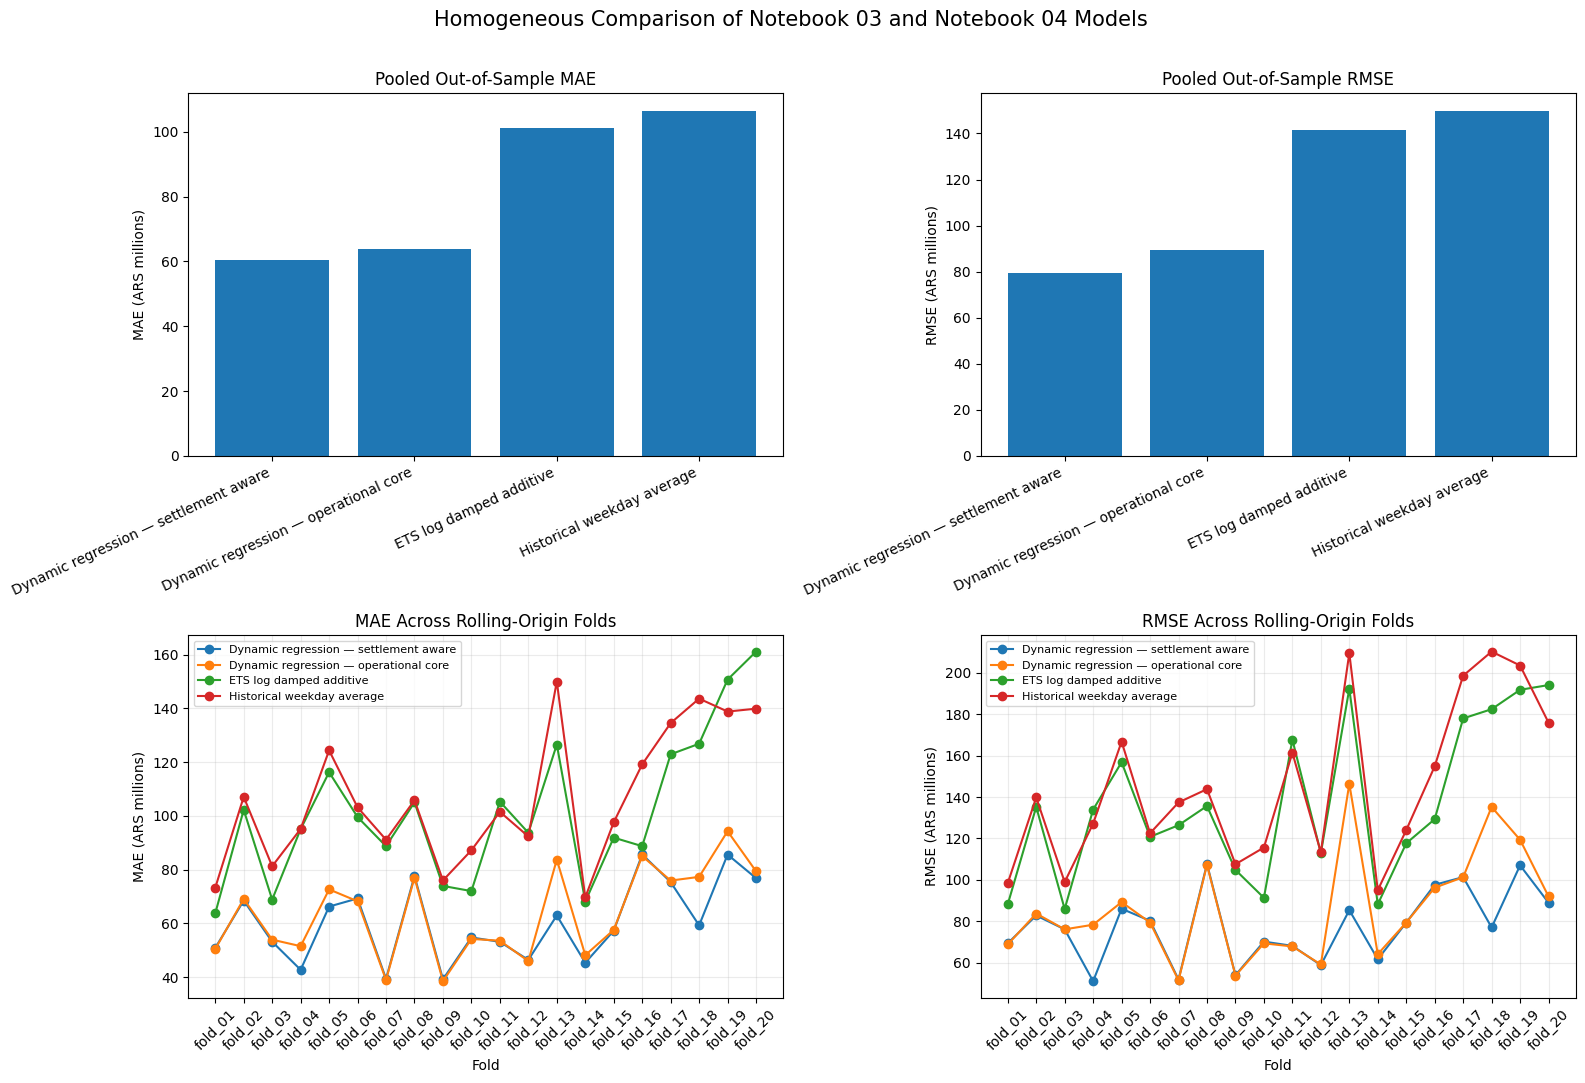

,check,observed,expected,status
0,comparison_models,4,4,PASS
1,total_prediction_rows,2240,2240,PASS
2,prediction_rows_per_model,True,True,PASS
3,twenty_eight_horizons_per_fold_model,True,True,PASS
4,all_key_sets_match,True,True,PASS
5,all_actual_values_match,True,True,PASS
6,no_duplicate_comparison_keys,0,0,PASS
7,all_predictions_positive,True,True,PASS
8,all_predictions_finite,True,True,PASS
9,fold_scaling_rows,20,20,PASS


,model_name,evaluation_role,eligible_for_default_selection,mae,rmse,mean_error,bias_pct,mean_fold_mase,mean_fold_rmsse,fold_mae_standard_deviation,fold_rmse_standard_deviation,mae_rank,rmse_rank
0,calendar_promotion_settlement_trend_arima011_e...,conditional_operational_variant,False,60.4518,79.5164,5.2051,0.5735,0.6331,0.5895,14.7248,17.4538,1,1
1,calendar_promotion_trend_arima011_errors,primary_operational_model,True,63.7503,89.4678,4.4592,0.4913,0.6664,0.6491,16.4488,25.7694,2,2
2,ets_log_damped_additive,statistical_benchmark,False,101.0620,141.3892,-7.8258,-0.8622,1.0530,1.0310,26.8759,37.2235,3,3
3,historical_weekday_average,reference_benchmark,False,106.5762,149.9408,-34.5093,-3.8020,1.1125,1.0954,24.9102,38.3587,4,4


,candidate_model,candidate_label,candidate_role,reference_model,reference_label,candidate_mae,reference_mae,mae_improvement,mae_improvement_pct,candidate_rmse,reference_rmse,rmse_improvement,rmse_improvement_pct,candidate_mean_error,reference_mean_error,default_selection_eligible
0,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,primary_operational_model,historical_weekday_average,Historical weekday average,63.7503,106.5762,42.8259,40.1834,89.4678,149.9408,60.4729,40.3312,4.4592,-34.5093,True
1,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,primary_operational_model,ets_log_damped_additive,ETS log damped additive,63.7503,101.0620,37.3117,36.9196,89.4678,141.3892,51.9214,36.7223,4.4592,-7.8258,True
2,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,conditional_operational_variant,historical_weekday_average,Historical weekday average,60.4518,106.5762,46.1244,43.2784,79.5164,149.9408,70.4244,46.9682,5.2051,-34.5093,False
3,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,conditional_operational_variant,ets_log_damped_additive,ETS log damped additive,60.4518,101.0620,40.6102,40.1835,79.5164,141.3892,61.8729,43.7607,5.2051,-7.8258,False


,metric,model_name,model_label,folds_won,tied_wins,fold_win_pct
0,mae,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,12,0,60.0000
1,mae,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,8,0,40.0000
2,rmse,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,11,0,55.0000
3,rmse,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,9,0,45.0000


Models compared: 4
Prediction rows compared: 2,240
Saved comparison figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_cross_notebook_model_comparison.png


In [39]:
# ============================================================================
# 26. Compare Notebook 03 and Notebook 04 models on identical folds
# ============================================================================

COMPARISON_MODELS = [
    BENCHMARK_REFERENCE_MODEL,
    ETS_REFERENCE_MODEL,
    PRIMARY_MODEL_NAME,
    SETTLEMENT_MODEL_NAME,
]


# ----------------------------------------------------------------------------
# Freeze the model roles used in the comparison
# ----------------------------------------------------------------------------

cross_notebook_model_registry = pd.DataFrame(
    [
        {
            "model_name": BENCHMARK_REFERENCE_MODEL,
            "model_label": "Historical weekday average",
            "source_notebook": "03",
            "model_family": "benchmark",
            "evaluation_role": "reference_benchmark",
            "eligible_for_default_selection": False,
            "usage_condition": (
                "Reference benchmark used to quantify forecast skill."
            ),
        },
        {
            "model_name": ETS_REFERENCE_MODEL,
            "model_label": "ETS log damped additive",
            "source_notebook": "03",
            "model_family": "ets",
            "evaluation_role": "statistical_benchmark",
            "eligible_for_default_selection": False,
            "usage_condition": (
                "Validated univariate statistical benchmark."
            ),
        },
        {
            "model_name": PRIMARY_MODEL_NAME,
            "model_label": "Dynamic regression — operational core",
            "source_notebook": "04",
            "model_family": "dynamic_regression",
            "evaluation_role": "primary_operational_model",
            "eligible_for_default_selection": True,
            "usage_condition": (
                "Default model when the planned promotion path is known."
            ),
        },
        {
            "model_name": SETTLEMENT_MODEL_NAME,
            "model_label": "Dynamic regression — settlement aware",
            "source_notebook": "04",
            "model_family": "dynamic_regression",
            "evaluation_role": "conditional_operational_variant",
            "eligible_for_default_selection": False,
            "usage_condition": (
                "Use only when a reliable settlement schedule is known "
                "for the complete 28-day forecast horizon."
            ),
        },
    ]
)

assert set(
    cross_notebook_model_registry["model_name"]
) == set(COMPARISON_MODELS)

assert cross_notebook_model_registry[
    "model_name"
].is_unique


# ----------------------------------------------------------------------------
# Normalize the Notebook 04 operational-core forecasts
# ----------------------------------------------------------------------------

primary_comparison_predictions = (
    arima011_backtest_predictions.loc[
        arima011_backtest_predictions[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME),
        [
            "model_name",
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
            POINT_FORECAST_COLUMN,
        ],
    ]
    .rename(
        columns={
            POINT_FORECAST_COLUMN: "prediction",
        }
    )
    .copy()
)

primary_comparison_predictions[
    "source_file"
] = BACKTEST_PREDICTIONS_PATH.name


# ----------------------------------------------------------------------------
# Normalize the settlement-aware forecasts
# ----------------------------------------------------------------------------

settlement_comparison_predictions = (
    settlement_sensitivity_predictions.loc[
        settlement_sensitivity_predictions[
            "model_name"
        ].eq(SETTLEMENT_MODEL_NAME),
        [
            "model_name",
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
            POINT_FORECAST_COLUMN,
        ],
    ]
    .rename(
        columns={
            POINT_FORECAST_COLUMN: "prediction",
        }
    )
    .copy()
)

settlement_comparison_predictions[
    "source_file"
] = SETTLEMENT_PREDICTIONS_PATH.name


# ----------------------------------------------------------------------------
# Combine Notebook 03 and Notebook 04 forecasts
# ----------------------------------------------------------------------------

notebook03_comparison_predictions = (
    notebook03_reference_forecasts_normalized[
        [
            "source_file",
            "model_name",
            "fold_id",
            "forecast_origin",
            "target_date",
            "forecast_horizon",
            "actual",
            "prediction",
        ]
    ]
    .copy()
)


cross_notebook_predictions = pd.concat(
    [
        notebook03_comparison_predictions,
        primary_comparison_predictions,
        settlement_comparison_predictions,
    ],
    ignore_index=True,
)


# ----------------------------------------------------------------------------
# Standardize data types
# ----------------------------------------------------------------------------

cross_notebook_predictions[
    "fold_id"
] = (
    cross_notebook_predictions[
        "fold_id"
    ].astype(str)
)

cross_notebook_predictions[
    "target_date"
] = pd.to_datetime(
    cross_notebook_predictions[
        "target_date"
    ]
)

cross_notebook_predictions[
    "forecast_origin"
] = pd.to_datetime(
    cross_notebook_predictions[
        "forecast_origin"
    ]
)

cross_notebook_predictions[
    "forecast_horizon"
] = pd.to_numeric(
    cross_notebook_predictions[
        "forecast_horizon"
    ],
    errors="raise",
).astype(int)

cross_notebook_predictions[
    "actual"
] = pd.to_numeric(
    cross_notebook_predictions[
        "actual"
    ],
    errors="raise",
).astype(float)

cross_notebook_predictions[
    "prediction"
] = pd.to_numeric(
    cross_notebook_predictions[
        "prediction"
    ],
    errors="raise",
).astype(float)


cross_notebook_predictions = (
    cross_notebook_predictions
    .merge(
        cross_notebook_model_registry,
        on="model_name",
        how="left",
        validate="many_to_one",
    )
    .sort_values(
        [
            "model_name",
            "fold_id",
            "target_date",
        ]
    )
    .reset_index(drop=True)
)

assert cross_notebook_predictions[
    "model_label"
].notna().all()


# ----------------------------------------------------------------------------
# Calculate the training-only fold scaling denominators
# ----------------------------------------------------------------------------

comparison_folds = folds_df.copy()

for date_column in [
    "train_start",
    "train_end",
    "forecast_origin",
    "test_start",
    "test_end",
]:
    comparison_folds[date_column] = pd.to_datetime(
        comparison_folds[date_column]
    )


fold_scaling_records = []

for _, fold in comparison_folds.iterrows():

    training_mask = (
        modeling_dataset_with_trend[
            DATE_COLUMN
        ].between(
            fold["train_start"],
            fold["train_end"],
            inclusive="both",
        )
    )

    training_values = (
        modeling_dataset_with_trend.loc[
            training_mask,
            TARGET_COLUMN,
        ].to_numpy(dtype=float)
    )

    assert len(training_values) == int(
        fold["train_size"]
    )

    (
        mase_denominator,
        rmsse_denominator,
    ) = calculate_training_scaling_denominators(
        training_target=training_values,
        seasonal_lag=SEASONAL_SCALING_LAG,
    )

    fold_scaling_records.append(
        {
            "fold_id": fold["fold_id"],
            "train_start": fold["train_start"],
            "train_end": fold["train_end"],
            "train_observations": int(
                fold["train_size"]
            ),
            "seasonal_scaling_lag": (
                SEASONAL_SCALING_LAG
            ),
            "mase_denominator": (
                mase_denominator
            ),
            "rmsse_denominator": (
                rmsse_denominator
            ),
        }
    )


cross_notebook_fold_scaling = pd.DataFrame(
    fold_scaling_records
)

assert len(cross_notebook_fold_scaling) == N_FOLDS

assert cross_notebook_fold_scaling[
    "fold_id"
].is_unique


# ----------------------------------------------------------------------------
# Attach scaling values and calculate individual errors
# ----------------------------------------------------------------------------

cross_notebook_predictions = (
    cross_notebook_predictions
    .merge(
        cross_notebook_fold_scaling[
            [
                "fold_id",
                "mase_denominator",
                "rmsse_denominator",
            ]
        ],
        on="fold_id",
        how="left",
        validate="many_to_one",
    )
)


cross_notebook_predictions[
    "error"
] = (
    cross_notebook_predictions[
        "prediction"
    ]
    - cross_notebook_predictions[
        "actual"
    ]
)

cross_notebook_predictions[
    "absolute_error"
] = (
    cross_notebook_predictions[
        "error"
    ].abs()
)

cross_notebook_predictions[
    "squared_error"
] = (
    cross_notebook_predictions[
        "error"
    ].pow(2)
)


# ----------------------------------------------------------------------------
# Validate identical fold-date-horizon keys and observed values
# ----------------------------------------------------------------------------

COMPARISON_KEYS = [
    "fold_id",
    "target_date",
    "forecast_horizon",
]

reference_comparison_data = (
    cross_notebook_predictions.loc[
        cross_notebook_predictions[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME),
        [
            *COMPARISON_KEYS,
            "actual",
        ],
    ]
    .copy()
)

reference_key_set = set(
    map(
        tuple,
        reference_comparison_data[
            COMPARISON_KEYS
        ].to_numpy(),
    )
)


model_alignment_records = []

for model_name, model_data in (
    cross_notebook_predictions.groupby(
        "model_name"
    )
):

    model_key_set = set(
        map(
            tuple,
            model_data[
                COMPARISON_KEYS
            ].to_numpy(),
        )
    )

    aligned_actuals = (
        model_data[
            [
                *COMPARISON_KEYS,
                "actual",
            ]
        ]
        .merge(
            reference_comparison_data,
            on=COMPARISON_KEYS,
            how="inner",
            suffixes=(
                "_model",
                "_reference",
            ),
            validate="one_to_one",
        )
    )

    actual_values_match = bool(
        len(aligned_actuals)
        == N_FOLDS * FORECAST_HORIZON
        and np.allclose(
            aligned_actuals[
                "actual_model"
            ].to_numpy(dtype=float),
            aligned_actuals[
                "actual_reference"
            ].to_numpy(dtype=float),
            rtol=1e-12,
            atol=1e-9,
        )
    )

    model_alignment_records.append(
        {
            "model_name": model_name,
            "prediction_rows": len(
                model_data
            ),
            "folds_evaluated": (
                model_data[
                    "fold_id"
                ].nunique()
            ),
            "duplicate_keys": int(
                model_data.duplicated(
                    COMPARISON_KEYS
                ).sum()
            ),
            "keys_match_reference": bool(
                model_key_set
                == reference_key_set
            ),
            "actual_values_match": (
                actual_values_match
            ),
            "predictions_positive": bool(
                model_data[
                    "prediction"
                ].gt(0).all()
            ),
            "predictions_finite": bool(
                np.isfinite(
                    model_data[
                        "prediction"
                    ].to_numpy()
                ).all()
            ),
        }
    )


cross_notebook_model_alignment = pd.DataFrame(
    model_alignment_records
)


# ----------------------------------------------------------------------------
# Calculate one metric row per model and fold
# ----------------------------------------------------------------------------

fold_metric_records = []

for (
    model_name,
    fold_id,
), fold_predictions in (
    cross_notebook_predictions.groupby(
        [
            "model_name",
            "fold_id",
        ]
    )
):

    errors = (
        fold_predictions[
            "error"
        ].to_numpy(dtype=float)
    )

    mae = float(
        np.mean(
            np.abs(errors)
        )
    )

    rmse = float(
        np.sqrt(
            np.mean(
                np.square(errors)
            )
        )
    )

    mase_denominator = float(
        fold_predictions[
            "mase_denominator"
        ].iloc[0]
    )

    rmsse_denominator = float(
        fold_predictions[
            "rmsse_denominator"
        ].iloc[0]
    )

    fold_metric_records.append(
        {
            "model_name": model_name,
            "model_label": (
                fold_predictions[
                    "model_label"
                ].iloc[0]
            ),
            "model_family": (
                fold_predictions[
                    "model_family"
                ].iloc[0]
            ),
            "evaluation_role": (
                fold_predictions[
                    "evaluation_role"
                ].iloc[0]
            ),
            "eligible_for_default_selection": bool(
                fold_predictions[
                    "eligible_for_default_selection"
                ].iloc[0]
            ),
            "fold_id": fold_id,
            "forecast_origin": (
                fold_predictions[
                    "forecast_origin"
                ].iloc[0]
            ),
            "test_start": (
                fold_predictions[
                    "target_date"
                ].min()
            ),
            "test_end": (
                fold_predictions[
                    "target_date"
                ].max()
            ),
            "observations": len(
                fold_predictions
            ),
            "mae": mae,
            "rmse": rmse,
            "mean_error": float(
                np.mean(errors)
            ),
            "mase": float(
                mae / mase_denominator
            ),
            "rmsse": float(
                rmse / rmsse_denominator
            ),
            "mean_actual": float(
                fold_predictions[
                    "actual"
                ].mean()
            ),
            "mean_prediction": float(
                fold_predictions[
                    "prediction"
                ].mean()
            ),
            "mase_denominator": (
                mase_denominator
            ),
            "rmsse_denominator": (
                rmsse_denominator
            ),
        }
    )


cross_notebook_fold_metrics = pd.DataFrame(
    fold_metric_records
)


# ----------------------------------------------------------------------------
# Calculate pooled and fold-averaged metrics
# ----------------------------------------------------------------------------

aggregate_metric_records = []

for model_name, model_predictions in (
    cross_notebook_predictions.groupby(
        "model_name"
    )
):

    model_fold_metrics = (
        cross_notebook_fold_metrics.loc[
            cross_notebook_fold_metrics[
                "model_name"
            ].eq(model_name)
        ]
    )

    errors = (
        model_predictions[
            "error"
        ].to_numpy(dtype=float)
    )

    mean_actual = float(
        model_predictions[
            "actual"
        ].mean()
    )

    aggregate_metric_records.append(
        {
            "model_name": model_name,
            "model_label": (
                model_predictions[
                    "model_label"
                ].iloc[0]
            ),
            "source_notebook": (
                model_predictions[
                    "source_notebook"
                ].iloc[0]
            ),
            "model_family": (
                model_predictions[
                    "model_family"
                ].iloc[0]
            ),
            "evaluation_role": (
                model_predictions[
                    "evaluation_role"
                ].iloc[0]
            ),
            "eligible_for_default_selection": bool(
                model_predictions[
                    "eligible_for_default_selection"
                ].iloc[0]
            ),
            "folds_evaluated": (
                model_predictions[
                    "fold_id"
                ].nunique()
            ),
            "predictions": len(
                model_predictions
            ),
            "mae": float(
                np.mean(
                    np.abs(errors)
                )
            ),
            "rmse": float(
                np.sqrt(
                    np.mean(
                        np.square(errors)
                    )
                )
            ),
            "mean_error": float(
                np.mean(errors)
            ),
            "bias_pct": float(
                100
                * np.mean(errors)
                / mean_actual
            ),
            "mean_actual": mean_actual,
            "mean_prediction": float(
                model_predictions[
                    "prediction"
                ].mean()
            ),
            "mean_fold_mase": float(
                model_fold_metrics[
                    "mase"
                ].mean()
            ),
            "mean_fold_rmsse": float(
                model_fold_metrics[
                    "rmsse"
                ].mean()
            ),
            "fold_mae_standard_deviation": float(
                model_fold_metrics[
                    "mae"
                ].std(ddof=1)
            ),
            "fold_rmse_standard_deviation": float(
                model_fold_metrics[
                    "rmse"
                ].std(ddof=1)
            ),
            "minimum_fold_mae": float(
                model_fold_metrics[
                    "mae"
                ].min()
            ),
            "maximum_fold_mae": float(
                model_fold_metrics[
                    "mae"
                ].max()
            ),
            "minimum_fold_rmse": float(
                model_fold_metrics[
                    "rmse"
                ].min()
            ),
            "maximum_fold_rmse": float(
                model_fold_metrics[
                    "rmse"
                ].max()
            ),
        }
    )


cross_notebook_aggregate_metrics = pd.DataFrame(
    aggregate_metric_records
)

cross_notebook_aggregate_metrics[
    "mae_rank"
] = (
    cross_notebook_aggregate_metrics[
        "mae"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

cross_notebook_aggregate_metrics[
    "rmse_rank"
] = (
    cross_notebook_aggregate_metrics[
        "rmse"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

cross_notebook_aggregate_metrics = (
    cross_notebook_aggregate_metrics
    .sort_values(
        [
            "mae",
            "rmse",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Relative improvement of the dynamic-regression variants
# ----------------------------------------------------------------------------

aggregate_metric_lookup = (
    cross_notebook_aggregate_metrics
    .set_index("model_name")
)

pairwise_improvement_records = []

for candidate_model in [
    PRIMARY_MODEL_NAME,
    SETTLEMENT_MODEL_NAME,
]:

    for reference_model in [
        BENCHMARK_REFERENCE_MODEL,
        ETS_REFERENCE_MODEL,
    ]:

        candidate_metrics = (
            aggregate_metric_lookup.loc[
                candidate_model
            ]
        )

        reference_metrics = (
            aggregate_metric_lookup.loc[
                reference_model
            ]
        )

        pairwise_improvement_records.append(
            {
                "candidate_model": (
                    candidate_model
                ),
                "candidate_label": (
                    candidate_metrics[
                        "model_label"
                    ]
                ),
                "candidate_role": (
                    candidate_metrics[
                        "evaluation_role"
                    ]
                ),
                "reference_model": (
                    reference_model
                ),
                "reference_label": (
                    reference_metrics[
                        "model_label"
                    ]
                ),
                "candidate_mae": float(
                    candidate_metrics["mae"]
                ),
                "reference_mae": float(
                    reference_metrics["mae"]
                ),
                "mae_improvement": float(
                    reference_metrics["mae"]
                    - candidate_metrics["mae"]
                ),
                "mae_improvement_pct": float(
                    100
                    * (
                        reference_metrics["mae"]
                        - candidate_metrics["mae"]
                    )
                    / reference_metrics["mae"]
                ),
                "candidate_rmse": float(
                    candidate_metrics["rmse"]
                ),
                "reference_rmse": float(
                    reference_metrics["rmse"]
                ),
                "rmse_improvement": float(
                    reference_metrics["rmse"]
                    - candidate_metrics["rmse"]
                ),
                "rmse_improvement_pct": float(
                    100
                    * (
                        reference_metrics["rmse"]
                        - candidate_metrics["rmse"]
                    )
                    / reference_metrics["rmse"]
                ),
                "candidate_mean_error": float(
                    candidate_metrics[
                        "mean_error"
                    ]
                ),
                "reference_mean_error": float(
                    reference_metrics[
                        "mean_error"
                    ]
                ),
                "default_selection_eligible": bool(
                    candidate_metrics[
                        "eligible_for_default_selection"
                    ]
                ),
            }
        )


cross_notebook_pairwise_improvements = pd.DataFrame(
    pairwise_improvement_records
)


# ----------------------------------------------------------------------------
# Count fold-level winners
# ----------------------------------------------------------------------------

fold_winner_records = []

for metric in [
    "mae",
    "rmse",
]:

    for fold_id, fold_data in (
        cross_notebook_fold_metrics.groupby(
            "fold_id"
        )
    ):

        best_metric_value = float(
            fold_data[metric].min()
        )

        winning_rows = fold_data.loc[
            np.isclose(
                fold_data[metric],
                best_metric_value,
                rtol=1e-12,
                atol=1e-9,
            )
        ]

        for _, winning_row in (
            winning_rows.iterrows()
        ):

            fold_winner_records.append(
                {
                    "metric": metric,
                    "fold_id": fold_id,
                    "model_name": (
                        winning_row[
                            "model_name"
                        ]
                    ),
                    "model_label": (
                        winning_row[
                            "model_label"
                        ]
                    ),
                    "winning_metric_value": (
                        best_metric_value
                    ),
                    "tie_count": len(
                        winning_rows
                    ),
                }
            )


cross_notebook_fold_winners = pd.DataFrame(
    fold_winner_records
)

cross_notebook_fold_winner_summary = (
    cross_notebook_fold_winners
    .groupby(
        [
            "metric",
            "model_name",
            "model_label",
        ],
        as_index=False,
    )
    .agg(
        folds_won=(
            "fold_id",
            "nunique",
        ),
        tied_wins=(
            "tie_count",
            lambda values: int(
                values.gt(1).sum()
            ),
        ),
    )
)

cross_notebook_fold_winner_summary[
    "fold_win_pct"
] = (
    100
    * cross_notebook_fold_winner_summary[
        "folds_won"
    ]
    / N_FOLDS
)


# ----------------------------------------------------------------------------
# Comparison audit
# ----------------------------------------------------------------------------

fold_model_horizon_counts = (
    cross_notebook_predictions
    .groupby(
        [
            "model_name",
            "fold_id",
        ]
    )[
        "forecast_horizon"
    ]
    .nunique()
)


cross_notebook_comparison_audit = pd.DataFrame(
    [
        {
            "check": "comparison_models",
            "observed": (
                cross_notebook_predictions[
                    "model_name"
                ].nunique()
            ),
            "expected": 4,
            "status": (
                "PASS"
                if cross_notebook_predictions[
                    "model_name"
                ].nunique() == 4
                else "FAIL"
            ),
        },
        {
            "check": "total_prediction_rows",
            "observed": len(
                cross_notebook_predictions
            ),
            "expected": (
                4
                * N_FOLDS
                * FORECAST_HORIZON
            ),
            "status": (
                "PASS"
                if len(
                    cross_notebook_predictions
                )
                == 4
                * N_FOLDS
                * FORECAST_HORIZON
                else "FAIL"
            ),
        },
        {
            "check": "prediction_rows_per_model",
            "observed": bool(
                cross_notebook_predictions
                .groupby("model_name")
                .size()
                .eq(
                    N_FOLDS
                    * FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_predictions
                .groupby("model_name")
                .size()
                .eq(
                    N_FOLDS
                    * FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "twenty_eight_horizons_per_fold_model",
            "observed": bool(
                fold_model_horizon_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if fold_model_horizon_counts
                .eq(
                    FORECAST_HORIZON
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_key_sets_match",
            "observed": bool(
                cross_notebook_model_alignment[
                    "keys_match_reference"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_model_alignment[
                    "keys_match_reference"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "all_actual_values_match",
            "observed": bool(
                cross_notebook_model_alignment[
                    "actual_values_match"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_model_alignment[
                    "actual_values_match"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "no_duplicate_comparison_keys",
            "observed": int(
                cross_notebook_model_alignment[
                    "duplicate_keys"
                ].sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if cross_notebook_model_alignment[
                    "duplicate_keys"
                ].sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_positive",
            "observed": bool(
                cross_notebook_model_alignment[
                    "predictions_positive"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_model_alignment[
                    "predictions_positive"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "all_predictions_finite",
            "observed": bool(
                cross_notebook_model_alignment[
                    "predictions_finite"
                ].all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_model_alignment[
                    "predictions_finite"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "fold_scaling_rows",
            "observed": len(
                cross_notebook_fold_scaling
            ),
            "expected": N_FOLDS,
            "status": (
                "PASS"
                if len(
                    cross_notebook_fold_scaling
                ) == N_FOLDS
                else "FAIL"
            ),
        },
        {
            "check": "missing_scaling_values",
            "observed": int(
                cross_notebook_predictions[
                    [
                        "mase_denominator",
                        "rmsse_denominator",
                    ]
                ].isna().sum().sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if cross_notebook_predictions[
                    [
                        "mase_denominator",
                        "rmsse_denominator",
                    ]
                ].isna().sum().sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "fold_metric_rows",
            "observed": len(
                cross_notebook_fold_metrics
            ),
            "expected": (
                4 * N_FOLDS
            ),
            "status": (
                "PASS"
                if len(
                    cross_notebook_fold_metrics
                ) == 4 * N_FOLDS
                else "FAIL"
            ),
        },
        {
            "check": "aggregate_metric_rows",
            "observed": len(
                cross_notebook_aggregate_metrics
            ),
            "expected": 4,
            "status": (
                "PASS"
                if len(
                    cross_notebook_aggregate_metrics
                ) == 4
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save all generated tables
# ----------------------------------------------------------------------------

CROSS_NOTEBOOK_MODEL_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_model_registry.csv"
)

CROSS_NOTEBOOK_PREDICTIONS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_predictions.csv"
)

CROSS_NOTEBOOK_FOLD_SCALING_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_fold_scaling.csv"
)

CROSS_NOTEBOOK_FOLD_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_fold_metrics.csv"
)

CROSS_NOTEBOOK_AGGREGATE_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_aggregate_metrics.csv"
)

CROSS_NOTEBOOK_PAIRWISE_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_pairwise_improvements.csv"
)

CROSS_NOTEBOOK_FOLD_WINNERS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_fold_winner_summary.csv"
)

CROSS_NOTEBOOK_COMPARISON_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_comparison_audit.csv"
)


cross_notebook_model_registry.to_csv(
    CROSS_NOTEBOOK_MODEL_REGISTRY_PATH,
    index=False,
)

cross_notebook_predictions.to_csv(
    CROSS_NOTEBOOK_PREDICTIONS_PATH,
    index=False,
)

cross_notebook_fold_scaling.to_csv(
    CROSS_NOTEBOOK_FOLD_SCALING_PATH,
    index=False,
)

cross_notebook_fold_metrics.to_csv(
    CROSS_NOTEBOOK_FOLD_METRICS_PATH,
    index=False,
)

cross_notebook_aggregate_metrics.to_csv(
    CROSS_NOTEBOOK_AGGREGATE_METRICS_PATH,
    index=False,
)

cross_notebook_pairwise_improvements.to_csv(
    CROSS_NOTEBOOK_PAIRWISE_PATH,
    index=False,
)

cross_notebook_fold_winner_summary.to_csv(
    CROSS_NOTEBOOK_FOLD_WINNERS_PATH,
    index=False,
)

cross_notebook_comparison_audit.to_csv(
    CROSS_NOTEBOOK_COMPARISON_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Comparison figure
# ----------------------------------------------------------------------------

plot_order = (
    cross_notebook_aggregate_metrics
    .sort_values("mae")[
        "model_name"
    ]
    .tolist()
)

plot_labels = (
    cross_notebook_model_registry
    .set_index("model_name")[
        "model_label"
    ]
    .to_dict()
)

plot_positions = np.arange(
    len(plot_order)
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 11),
)


aggregate_plot_data = (
    cross_notebook_aggregate_metrics
    .set_index("model_name")
    .loc[plot_order]
)


axes[0, 0].bar(
    plot_positions,
    aggregate_plot_data["mae"],
)

axes[0, 0].set_title(
    "Pooled Out-of-Sample MAE"
)

axes[0, 0].set_ylabel(
    "MAE (ARS millions)"
)

axes[0, 0].set_xticks(
    plot_positions
)

axes[0, 0].set_xticklabels(
    [
        plot_labels[
            model_name
        ]
        for model_name in plot_order
    ],
    rotation=25,
    ha="right",
)


axes[0, 1].bar(
    plot_positions,
    aggregate_plot_data["rmse"],
)

axes[0, 1].set_title(
    "Pooled Out-of-Sample RMSE"
)

axes[0, 1].set_ylabel(
    "RMSE (ARS millions)"
)

axes[0, 1].set_xticks(
    plot_positions
)

axes[0, 1].set_xticklabels(
    [
        plot_labels[
            model_name
        ]
        for model_name in plot_order
    ],
    rotation=25,
    ha="right",
)


for model_name in plot_order:

    model_fold_data = (
        cross_notebook_fold_metrics.loc[
            cross_notebook_fold_metrics[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values("fold_id")
    )

    axes[1, 0].plot(
        model_fold_data["fold_id"],
        model_fold_data["mae"],
        marker="o",
        label=plot_labels[model_name],
    )

    axes[1, 1].plot(
        model_fold_data["fold_id"],
        model_fold_data["rmse"],
        marker="o",
        label=plot_labels[model_name],
    )


axes[1, 0].set_title(
    "MAE Across Rolling-Origin Folds"
)

axes[1, 0].set_xlabel("Fold")
axes[1, 0].set_ylabel(
    "MAE (ARS millions)"
)

axes[1, 0].tick_params(
    axis="x",
    rotation=45,
)

axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(fontsize=8)


axes[1, 1].set_title(
    "RMSE Across Rolling-Origin Folds"
)

axes[1, 1].set_xlabel("Fold")
axes[1, 1].set_ylabel(
    "RMSE (ARS millions)"
)

axes[1, 1].tick_params(
    axis="x",
    rotation=45,
)

axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend(fontsize=8)


fig.suptitle(
    "Homogeneous Comparison of Notebook 03 and Notebook 04 Models",
    fontsize=15,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)


CROSS_NOTEBOOK_COMPARISON_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_model_comparison.png"
)

fig.savefig(
    CROSS_NOTEBOOK_COMPARISON_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs and critical controls
# ----------------------------------------------------------------------------

for output_path in [
    CROSS_NOTEBOOK_MODEL_REGISTRY_PATH,
    CROSS_NOTEBOOK_PREDICTIONS_PATH,
    CROSS_NOTEBOOK_FOLD_SCALING_PATH,
    CROSS_NOTEBOOK_FOLD_METRICS_PATH,
    CROSS_NOTEBOOK_AGGREGATE_METRICS_PATH,
    CROSS_NOTEBOOK_PAIRWISE_PATH,
    CROSS_NOTEBOOK_FOLD_WINNERS_PATH,
    CROSS_NOTEBOOK_COMPARISON_AUDIT_PATH,
    CROSS_NOTEBOOK_COMPARISON_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert cross_notebook_comparison_audit[
    "status"
].eq("PASS").all(), (
    "The homogeneous cross-notebook comparison "
    "failed at least one audit."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(cross_notebook_comparison_audit)

display(
    cross_notebook_aggregate_metrics[
        [
            "model_name",
            "evaluation_role",
            "eligible_for_default_selection",
            "mae",
            "rmse",
            "mean_error",
            "bias_pct",
            "mean_fold_mase",
            "mean_fold_rmsse",
            "fold_mae_standard_deviation",
            "fold_rmse_standard_deviation",
            "mae_rank",
            "rmse_rank",
        ]
    ]
)

display(
    cross_notebook_pairwise_improvements
)

display(
    cross_notebook_fold_winner_summary.sort_values(
        [
            "metric",
            "folds_won",
        ],
        ascending=[
            True,
            False,
        ],
    ).reset_index(drop=True)
)

print(
    "Models compared: "
    f"{cross_notebook_predictions['model_name'].nunique()}"
)

print(
    "Prediction rows compared: "
    f"{len(cross_notebook_predictions):,}"
)

print(
    "Saved comparison figure: "
    f"{CROSS_NOTEBOOK_COMPARISON_FIGURE_PATH}"
)

## 25. Forecast performance by horizon

The homogeneous model comparison confirms that both dynamic-regression
variants outperform the Notebook 03 benchmark and ETS models in aggregate.

Aggregate metrics may still hide a deterioration at longer forecast horizons.
Therefore, performance is now evaluated separately for each horizon from one
to twenty-eight days ahead.

For model \(m\) and forecast horizon \(h\), the horizon-specific MAE is:

$$
\operatorname{MAE}_{m,h}
=
\frac{1}{N_h}
\sum_{i=1}^{N_h}
\left|
\widehat{Y}_{i,h}^{(m)}
-
Y_{i,h}
\right|
$$

The horizon-specific RMSE is:

$$
\operatorname{RMSE}_{m,h}
=
\sqrt{
\frac{1}{N_h}
\sum_{i=1}^{N_h}
\left(
\widehat{Y}_{i,h}^{(m)}
-
Y_{i,h}
\right)^2
}
$$

Each horizon contains twenty observations, one from every rolling-origin fold.

Results are also summarized into four operational horizon bands:

- Days 1–7.
- Days 8–14.
- Days 15–21.
- Days 22–28.

The analysis evaluates:

- Accuracy by exact forecast horizon.
- Bias by horizon.
- Improvement of the operational dynamic-regression model against ETS and
  the historical-weekday benchmark.
- Horizon-level model winners.
- Whether forecast skill deteriorates systematically at longer horizons.

The settlement-aware model remains a conditional operational variant even if
it achieves the lowest error at most horizons.

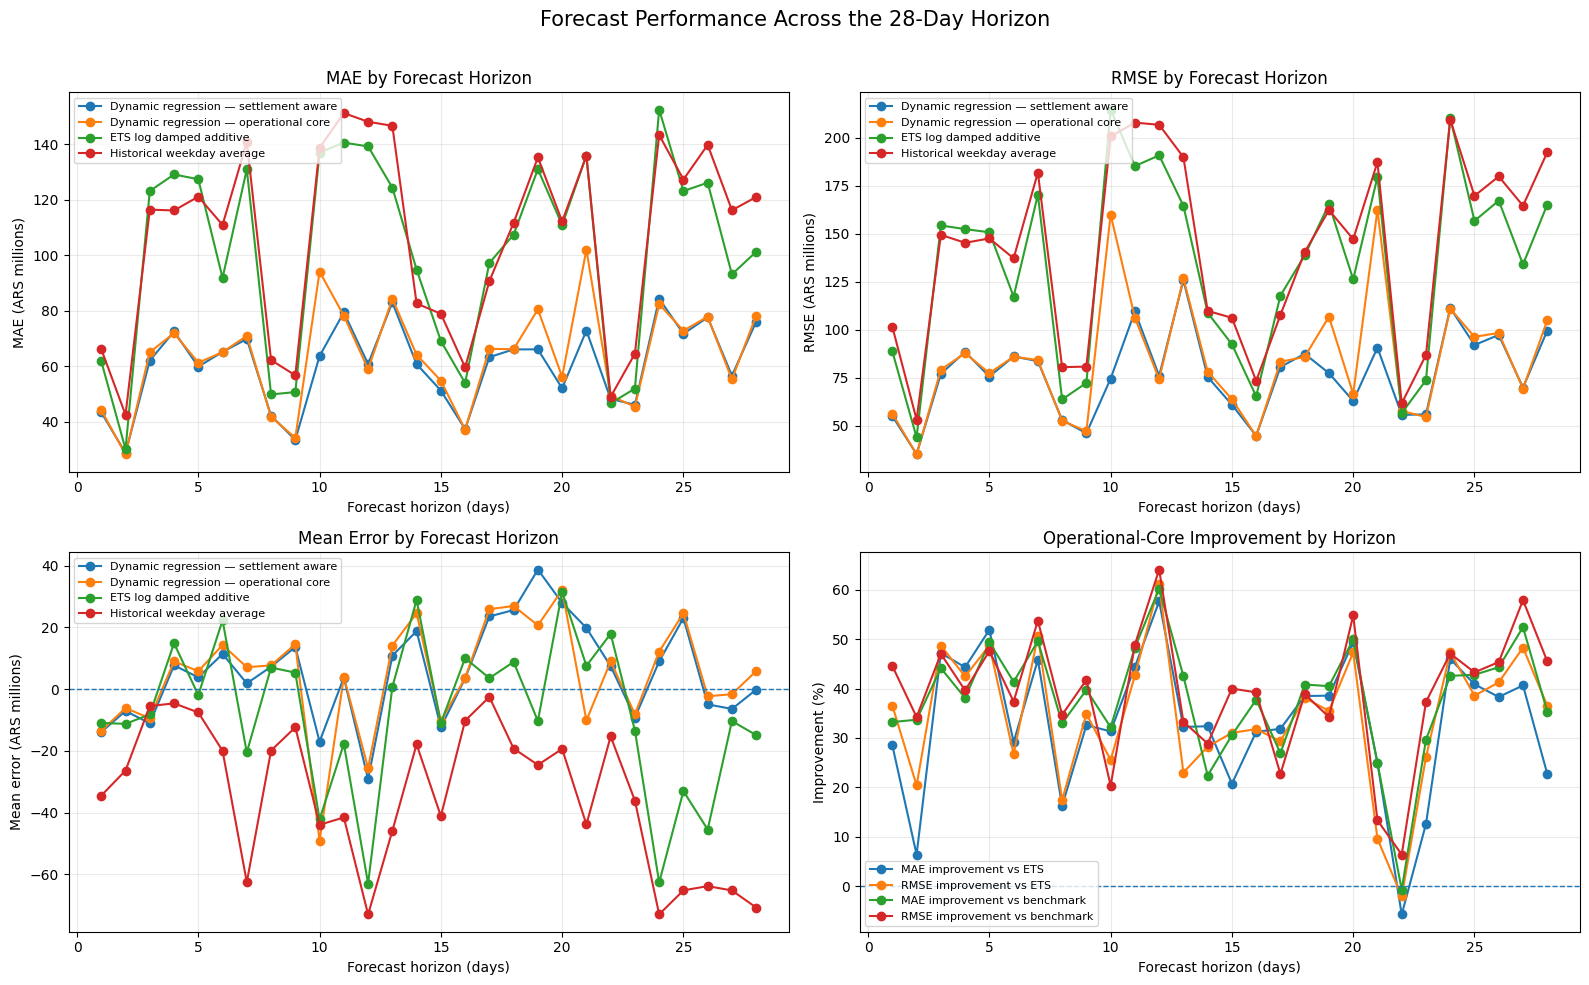

,check,observed,expected,status
0,horizon_metric_rows,112,112,PASS
1,twenty_observations_per_model_horizon,True,True,PASS
2,twenty_folds_per_model_horizon,True,True,PASS
3,all_horizons_represented,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",PASS
4,horizon_band_metric_rows,16,16,PASS
5,pairwise_horizon_rows,112,112,PASS
6,operational_core_horizon_rows,28,28,PASS
7,duplicate_model_horizon_rows,0,0,PASS
8,all_horizon_metrics_finite,True,True,PASS


,model_name,evaluation_role,horizon_band,observations,mae,rmse,mean_error,bias_pct,mase,rmsse
0,calendar_promotion_settlement_trend_arima011_e...,conditional_operational_variant,days_01_07,140,57.2909,73.7609,-1.0578,-0.1180,0.6055,0.5665
1,calendar_promotion_trend_arima011_errors,primary_operational_model,days_01_07,140,58.0366,74.4238,0.9956,0.1111,0.6139,0.5723
2,ets_log_damped_additive,statistical_benchmark,days_01_07,140,99.1384,132.2124,-2.2625,-0.2525,1.0444,1.0089
3,historical_weekday_average,reference_benchmark,days_01_07,140,101.9551,136.4279,-23.0211,-2.5688,1.0798,1.0493
4,calendar_promotion_settlement_trend_arima011_e...,conditional_operational_variant,days_08_14,140,60.4103,84.2597,1.1373,0.1250,0.6356,0.6416
5,calendar_promotion_trend_arima011_errors,primary_operational_model,days_08_14,140,65.0313,99.6520,-1.4232,-0.1565,0.6823,0.7494
6,ets_log_damped_additive,statistical_benchmark,days_08_14,140,105.1670,153.5900,-11.5943,-1.2747,1.0929,1.1360
7,historical_weekday_average,reference_benchmark,days_08_14,140,112.2713,163.6613,-36.3792,-3.9997,1.1637,1.2030
8,calendar_promotion_settlement_trend_arima011_e...,conditional_operational_variant,days_15_21,140,58.3580,73.6381,18.0877,2.0183,0.6094,0.5555
9,calendar_promotion_trend_arima011_errors,primary_operational_model,days_15_21,140,66.0877,94.5275,12.6466,1.4112,0.6876,0.7016


,candidate_model,candidate_label,candidate_role,reference_model,reference_label,horizons_evaluated,horizons_with_mae_improvement,horizons_with_rmse_improvement,mean_mae_improvement_pct,median_mae_improvement_pct,minimum_mae_improvement_pct,maximum_mae_improvement_pct,mean_rmse_improvement_pct,median_rmse_improvement_pct,minimum_rmse_improvement_pct,maximum_rmse_improvement_pct
0,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,conditional_operational_variant,ets_log_damped_additive,ETS log damped additive,28,27,28,35.9043,38.5123,-3.3723,56.3570,38.6742,40.3399,1.5561,65.3180
1,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,conditional_operational_variant,historical_weekday_average,Historical weekday average,28,28,28,40.7229,41.2258,1.5543,58.9772,43.5626,45.8364,9.7390,63.3065
2,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,primary_operational_model,ets_log_damped_additive,ETS log damped additive,28,27,27,33.2437,32.4859,-5.7671,57.6929,34.4936,36.0101,-2.1098,61.1233
3,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,primary_operational_model,historical_weekday_average,Historical weekday average,28,27,28,38.0644,40.1238,-0.7264,60.2328,39.3716,39.8205,6.3779,64.1196


,metric,model_name,model_label,horizons_won,tied_wins,horizon_win_pct
0,mae,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,17,0,60.7143
1,mae,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,10,0,35.7143
2,mae,ets_log_damped_additive,ETS log damped additive,1,0,3.5714
3,rmse,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,17,0,60.7143
4,rmse,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,11,0,39.2857


,forecast_horizon,mae_improvement_pct_vs_ets,rmse_improvement_pct_vs_ets,mae_improvement_pct_vs_benchmark,rmse_improvement_pct_vs_benchmark
0,1,28.5116,36.5602,33.2271,44.5871
1,2,6.3688,20.3918,33.6958,34.2350
2,3,47.1977,48.7208,44.1495,47.0522
3,4,44.3297,42.4658,38.1062,39.6352
4,5,51.9122,48.7363,49.4110,47.6237
5,6,29.1798,26.7388,41.3794,37.3827
6,7,45.8329,50.6270,49.6287,53.7688
7,8,16.2404,17.4214,32.9575,34.6939
8,9,32.5895,34.8853,39.7482,41.7588
9,10,31.3330,25.5376,32.1811,20.3294


Exact horizon metric rows: 112
Horizon-band metric rows: 16
Saved horizon figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_cross_notebook_metrics_by_horizon.png


In [40]:
# ============================================================================
# 27. Evaluate cross-notebook forecast performance by horizon
# ============================================================================

HORIZON_BAND_DEFINITIONS = {
    "days_01_07": (1, 7),
    "days_08_14": (8, 14),
    "days_15_21": (15, 21),
    "days_22_28": (22, 28),
}


# ----------------------------------------------------------------------------
# Prepare prediction-level scaled errors
# ----------------------------------------------------------------------------

horizon_predictions = (
    cross_notebook_predictions
    .copy()
)

horizon_predictions[
    "absolute_scaled_error"
] = (
    horizon_predictions[
        "absolute_error"
    ]
    / horizon_predictions[
        "mase_denominator"
    ]
)

horizon_predictions[
    "squared_scaled_error"
] = (
    horizon_predictions[
        "squared_error"
    ]
    / np.square(
        horizon_predictions[
            "rmsse_denominator"
        ]
    )
)


def assign_horizon_band(horizon):
    """Map a forecast horizon to one of four seven-day bands."""

    for band_name, (
        minimum_horizon,
        maximum_horizon,
    ) in HORIZON_BAND_DEFINITIONS.items():

        if (
            minimum_horizon
            <= horizon
            <= maximum_horizon
        ):
            return band_name

    raise ValueError(
        f"Unexpected forecast horizon: {horizon}"
    )


horizon_predictions[
    "horizon_band"
] = (
    horizon_predictions[
        "forecast_horizon"
    ].apply(assign_horizon_band)
)


# ----------------------------------------------------------------------------
# Exact-horizon metrics
# ----------------------------------------------------------------------------

horizon_metric_records = []

for (
    model_name,
    forecast_horizon,
), horizon_data in (
    horizon_predictions.groupby(
        [
            "model_name",
            "forecast_horizon",
        ]
    )
):

    errors = horizon_data[
        "error"
    ].to_numpy(dtype=float)

    mean_actual = float(
        horizon_data["actual"].mean()
    )

    horizon_metric_records.append(
        {
            "model_name": model_name,
            "model_label": (
                horizon_data[
                    "model_label"
                ].iloc[0]
            ),
            "model_family": (
                horizon_data[
                    "model_family"
                ].iloc[0]
            ),
            "evaluation_role": (
                horizon_data[
                    "evaluation_role"
                ].iloc[0]
            ),
            "eligible_for_default_selection": bool(
                horizon_data[
                    "eligible_for_default_selection"
                ].iloc[0]
            ),
            "forecast_horizon": int(
                forecast_horizon
            ),
            "observations": len(
                horizon_data
            ),
            "folds_represented": (
                horizon_data[
                    "fold_id"
                ].nunique()
            ),
            "mae": float(
                np.mean(
                    np.abs(errors)
                )
            ),
            "rmse": float(
                np.sqrt(
                    np.mean(
                        np.square(errors)
                    )
                )
            ),
            "mean_error": float(
                np.mean(errors)
            ),
            "bias_pct": float(
                100
                * np.mean(errors)
                / mean_actual
            ),
            "mase": float(
                horizon_data[
                    "absolute_scaled_error"
                ].mean()
            ),
            "rmsse": float(
                np.sqrt(
                    horizon_data[
                        "squared_scaled_error"
                    ].mean()
                )
            ),
            "mean_actual": mean_actual,
            "mean_prediction": float(
                horizon_data[
                    "prediction"
                ].mean()
            ),
        }
    )


cross_notebook_metrics_by_horizon = (
    pd.DataFrame(
        horizon_metric_records
    )
    .sort_values(
        [
            "forecast_horizon",
            "mae",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Seven-day horizon-band metrics
# ----------------------------------------------------------------------------

horizon_band_metric_records = []

for (
    model_name,
    horizon_band,
), band_data in (
    horizon_predictions.groupby(
        [
            "model_name",
            "horizon_band",
        ]
    )
):

    errors = band_data[
        "error"
    ].to_numpy(dtype=float)

    mean_actual = float(
        band_data["actual"].mean()
    )

    minimum_horizon = int(
        band_data[
            "forecast_horizon"
        ].min()
    )

    maximum_horizon = int(
        band_data[
            "forecast_horizon"
        ].max()
    )

    horizon_band_metric_records.append(
        {
            "model_name": model_name,
            "model_label": (
                band_data[
                    "model_label"
                ].iloc[0]
            ),
            "evaluation_role": (
                band_data[
                    "evaluation_role"
                ].iloc[0]
            ),
            "horizon_band": horizon_band,
            "minimum_horizon": (
                minimum_horizon
            ),
            "maximum_horizon": (
                maximum_horizon
            ),
            "observations": len(
                band_data
            ),
            "folds_represented": (
                band_data[
                    "fold_id"
                ].nunique()
            ),
            "mae": float(
                np.mean(
                    np.abs(errors)
                )
            ),
            "rmse": float(
                np.sqrt(
                    np.mean(
                        np.square(errors)
                    )
                )
            ),
            "mean_error": float(
                np.mean(errors)
            ),
            "bias_pct": float(
                100
                * np.mean(errors)
                / mean_actual
            ),
            "mase": float(
                band_data[
                    "absolute_scaled_error"
                ].mean()
            ),
            "rmsse": float(
                np.sqrt(
                    band_data[
                        "squared_scaled_error"
                    ].mean()
                )
            ),
            "mean_actual": mean_actual,
            "mean_prediction": float(
                band_data[
                    "prediction"
                ].mean()
            ),
        }
    )


cross_notebook_metrics_by_horizon_band = (
    pd.DataFrame(
        horizon_band_metric_records
    )
    .sort_values(
        [
            "minimum_horizon",
            "mae",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Pairwise horizon improvements
# ----------------------------------------------------------------------------

horizon_metric_lookup = (
    cross_notebook_metrics_by_horizon
    .set_index(
        [
            "forecast_horizon",
            "model_name",
        ]
    )
)

horizon_pairwise_records = []

for forecast_horizon in range(
    1,
    FORECAST_HORIZON + 1,
):

    for candidate_model in [
        PRIMARY_MODEL_NAME,
        SETTLEMENT_MODEL_NAME,
    ]:

        for reference_model in [
            BENCHMARK_REFERENCE_MODEL,
            ETS_REFERENCE_MODEL,
        ]:

            candidate_metrics = (
                horizon_metric_lookup.loc[
                    (
                        forecast_horizon,
                        candidate_model,
                    )
                ]
            )

            reference_metrics = (
                horizon_metric_lookup.loc[
                    (
                        forecast_horizon,
                        reference_model,
                    )
                ]
            )

            horizon_pairwise_records.append(
                {
                    "forecast_horizon": (
                        forecast_horizon
                    ),
                    "candidate_model": (
                        candidate_model
                    ),
                    "candidate_label": (
                        candidate_metrics[
                            "model_label"
                        ]
                    ),
                    "candidate_role": (
                        candidate_metrics[
                            "evaluation_role"
                        ]
                    ),
                    "reference_model": (
                        reference_model
                    ),
                    "reference_label": (
                        reference_metrics[
                            "model_label"
                        ]
                    ),
                    "candidate_mae": float(
                        candidate_metrics["mae"]
                    ),
                    "reference_mae": float(
                        reference_metrics["mae"]
                    ),
                    "mae_improvement": float(
                        reference_metrics["mae"]
                        - candidate_metrics["mae"]
                    ),
                    "mae_improvement_pct": float(
                        100
                        * (
                            reference_metrics[
                                "mae"
                            ]
                            - candidate_metrics[
                                "mae"
                            ]
                        )
                        / reference_metrics["mae"]
                    ),
                    "candidate_rmse": float(
                        candidate_metrics["rmse"]
                    ),
                    "reference_rmse": float(
                        reference_metrics["rmse"]
                    ),
                    "rmse_improvement": float(
                        reference_metrics["rmse"]
                        - candidate_metrics["rmse"]
                    ),
                    "rmse_improvement_pct": float(
                        100
                        * (
                            reference_metrics[
                                "rmse"
                            ]
                            - candidate_metrics[
                                "rmse"
                            ]
                        )
                        / reference_metrics["rmse"]
                    ),
                    "candidate_mean_error": float(
                        candidate_metrics[
                            "mean_error"
                        ]
                    ),
                    "reference_mean_error": float(
                        reference_metrics[
                            "mean_error"
                        ]
                    ),
                }
            )


cross_notebook_horizon_pairwise_improvements = (
    pd.DataFrame(
        horizon_pairwise_records
    )
)


# ----------------------------------------------------------------------------
# Compact pairwise summary
# ----------------------------------------------------------------------------

cross_notebook_horizon_pairwise_summary = (
    cross_notebook_horizon_pairwise_improvements
    .groupby(
        [
            "candidate_model",
            "candidate_label",
            "candidate_role",
            "reference_model",
            "reference_label",
        ],
        as_index=False,
    )
    .agg(
        horizons_evaluated=(
            "forecast_horizon",
            "nunique",
        ),
        horizons_with_mae_improvement=(
            "mae_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        horizons_with_rmse_improvement=(
            "rmse_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        mean_mae_improvement_pct=(
            "mae_improvement_pct",
            "mean",
        ),
        median_mae_improvement_pct=(
            "mae_improvement_pct",
            "median",
        ),
        minimum_mae_improvement_pct=(
            "mae_improvement_pct",
            "min",
        ),
        maximum_mae_improvement_pct=(
            "mae_improvement_pct",
            "max",
        ),
        mean_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "mean",
        ),
        median_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "median",
        ),
        minimum_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "min",
        ),
        maximum_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "max",
        ),
    )
)


# ----------------------------------------------------------------------------
# Compact operational-core improvement table
# ----------------------------------------------------------------------------

operational_vs_ets = (
    cross_notebook_horizon_pairwise_improvements.loc[
        cross_notebook_horizon_pairwise_improvements[
            "candidate_model"
        ].eq(PRIMARY_MODEL_NAME)
        & cross_notebook_horizon_pairwise_improvements[
            "reference_model"
        ].eq(ETS_REFERENCE_MODEL),
        [
            "forecast_horizon",
            "mae_improvement_pct",
            "rmse_improvement_pct",
        ],
    ]
    .rename(
        columns={
            "mae_improvement_pct": (
                "mae_improvement_pct_vs_ets"
            ),
            "rmse_improvement_pct": (
                "rmse_improvement_pct_vs_ets"
            ),
        }
    )
)

operational_vs_benchmark = (
    cross_notebook_horizon_pairwise_improvements.loc[
        cross_notebook_horizon_pairwise_improvements[
            "candidate_model"
        ].eq(PRIMARY_MODEL_NAME)
        & cross_notebook_horizon_pairwise_improvements[
            "reference_model"
        ].eq(BENCHMARK_REFERENCE_MODEL),
        [
            "forecast_horizon",
            "mae_improvement_pct",
            "rmse_improvement_pct",
        ],
    ]
    .rename(
        columns={
            "mae_improvement_pct": (
                "mae_improvement_pct_vs_benchmark"
            ),
            "rmse_improvement_pct": (
                "rmse_improvement_pct_vs_benchmark"
            ),
        }
    )
)

operational_core_horizon_improvements = (
    operational_vs_ets.merge(
        operational_vs_benchmark,
        on="forecast_horizon",
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "forecast_horizon"
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Horizon-level winners
# ----------------------------------------------------------------------------

horizon_winner_records = []

for metric in [
    "mae",
    "rmse",
]:

    for forecast_horizon, horizon_data in (
        cross_notebook_metrics_by_horizon.groupby(
            "forecast_horizon"
        )
    ):

        best_metric_value = float(
            horizon_data[metric].min()
        )

        winning_rows = horizon_data.loc[
            np.isclose(
                horizon_data[metric],
                best_metric_value,
                rtol=1e-12,
                atol=1e-9,
            )
        ]

        for _, winning_row in (
            winning_rows.iterrows()
        ):

            horizon_winner_records.append(
                {
                    "metric": metric,
                    "forecast_horizon": int(
                        forecast_horizon
                    ),
                    "model_name": (
                        winning_row[
                            "model_name"
                        ]
                    ),
                    "model_label": (
                        winning_row[
                            "model_label"
                        ]
                    ),
                    "winning_metric_value": (
                        best_metric_value
                    ),
                    "tie_count": len(
                        winning_rows
                    ),
                }
            )


cross_notebook_horizon_winners = pd.DataFrame(
    horizon_winner_records
)

cross_notebook_horizon_winner_summary = (
    cross_notebook_horizon_winners
    .groupby(
        [
            "metric",
            "model_name",
            "model_label",
        ],
        as_index=False,
    )
    .agg(
        horizons_won=(
            "forecast_horizon",
            "nunique",
        ),
        tied_wins=(
            "tie_count",
            lambda values: int(
                values.gt(1).sum()
            ),
        ),
    )
)

cross_notebook_horizon_winner_summary[
    "horizon_win_pct"
] = (
    100
    * cross_notebook_horizon_winner_summary[
        "horizons_won"
    ]
    / FORECAST_HORIZON
)


# ----------------------------------------------------------------------------
# Structural audit
# ----------------------------------------------------------------------------

expected_horizon_metric_rows = (
    len(COMPARISON_MODELS)
    * FORECAST_HORIZON
)

expected_band_metric_rows = (
    len(COMPARISON_MODELS)
    * len(HORIZON_BAND_DEFINITIONS)
)

expected_pairwise_rows = (
    2
    * 2
    * FORECAST_HORIZON
)

horizon_comparison_audit = pd.DataFrame(
    [
        {
            "check": "horizon_metric_rows",
            "observed": len(
                cross_notebook_metrics_by_horizon
            ),
            "expected": (
                expected_horizon_metric_rows
            ),
            "status": (
                "PASS"
                if len(
                    cross_notebook_metrics_by_horizon
                )
                == expected_horizon_metric_rows
                else "FAIL"
            ),
        },
        {
            "check": "twenty_observations_per_model_horizon",
            "observed": bool(
                cross_notebook_metrics_by_horizon[
                    "observations"
                ].eq(N_FOLDS).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_metrics_by_horizon[
                    "observations"
                ].eq(N_FOLDS).all()
                else "FAIL"
            ),
        },
        {
            "check": "twenty_folds_per_model_horizon",
            "observed": bool(
                cross_notebook_metrics_by_horizon[
                    "folds_represented"
                ].eq(N_FOLDS).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if cross_notebook_metrics_by_horizon[
                    "folds_represented"
                ].eq(N_FOLDS).all()
                else "FAIL"
            ),
        },
        {
            "check": "all_horizons_represented",
            "observed": sorted(
                cross_notebook_metrics_by_horizon[
                    "forecast_horizon"
                ].unique().tolist()
            ),
            "expected": list(
                range(
                    1,
                    FORECAST_HORIZON + 1,
                )
            ),
            "status": (
                "PASS"
                if set(
                    cross_notebook_metrics_by_horizon[
                        "forecast_horizon"
                    ]
                )
                == set(
                    range(
                        1,
                        FORECAST_HORIZON + 1,
                    )
                )
                else "FAIL"
            ),
        },
        {
            "check": "horizon_band_metric_rows",
            "observed": len(
                cross_notebook_metrics_by_horizon_band
            ),
            "expected": (
                expected_band_metric_rows
            ),
            "status": (
                "PASS"
                if len(
                    cross_notebook_metrics_by_horizon_band
                )
                == expected_band_metric_rows
                else "FAIL"
            ),
        },
        {
            "check": "pairwise_horizon_rows",
            "observed": len(
                cross_notebook_horizon_pairwise_improvements
            ),
            "expected": (
                expected_pairwise_rows
            ),
            "status": (
                "PASS"
                if len(
                    cross_notebook_horizon_pairwise_improvements
                )
                == expected_pairwise_rows
                else "FAIL"
            ),
        },
        {
            "check": "operational_core_horizon_rows",
            "observed": len(
                operational_core_horizon_improvements
            ),
            "expected": FORECAST_HORIZON,
            "status": (
                "PASS"
                if len(
                    operational_core_horizon_improvements
                )
                == FORECAST_HORIZON
                else "FAIL"
            ),
        },
        {
            "check": "duplicate_model_horizon_rows",
            "observed": int(
                cross_notebook_metrics_by_horizon
                .duplicated(
                    [
                        "model_name",
                        "forecast_horizon",
                    ]
                )
                .sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if cross_notebook_metrics_by_horizon
                .duplicated(
                    [
                        "model_name",
                        "forecast_horizon",
                    ]
                )
                .sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "all_horizon_metrics_finite",
            "observed": bool(
                np.isfinite(
                    cross_notebook_metrics_by_horizon[
                        [
                            "mae",
                            "rmse",
                            "mean_error",
                            "bias_pct",
                            "mase",
                            "rmsse",
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    cross_notebook_metrics_by_horizon[
                        [
                            "mae",
                            "rmse",
                            "mean_error",
                            "bias_pct",
                            "mase",
                            "rmsse",
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

HORIZON_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_metrics_by_horizon.csv"
)

HORIZON_BAND_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_metrics_by_horizon_band.csv"
)

HORIZON_PAIRWISE_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_horizon_pairwise_improvements.csv"
)

HORIZON_PAIRWISE_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_horizon_pairwise_summary.csv"
)

OPERATIONAL_CORE_HORIZON_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_operational_core_horizon_improvements.csv"
)

HORIZON_WINNER_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_horizon_winner_summary.csv"
)

HORIZON_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_horizon_comparison_audit.csv"
)


cross_notebook_metrics_by_horizon.to_csv(
    HORIZON_METRICS_PATH,
    index=False,
)

cross_notebook_metrics_by_horizon_band.to_csv(
    HORIZON_BAND_METRICS_PATH,
    index=False,
)

cross_notebook_horizon_pairwise_improvements.to_csv(
    HORIZON_PAIRWISE_PATH,
    index=False,
)

cross_notebook_horizon_pairwise_summary.to_csv(
    HORIZON_PAIRWISE_SUMMARY_PATH,
    index=False,
)

operational_core_horizon_improvements.to_csv(
    OPERATIONAL_CORE_HORIZON_PATH,
    index=False,
)

cross_notebook_horizon_winner_summary.to_csv(
    HORIZON_WINNER_SUMMARY_PATH,
    index=False,
)

horizon_comparison_audit.to_csv(
    HORIZON_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Horizon-performance figure
# ----------------------------------------------------------------------------

plot_order = (
    cross_notebook_aggregate_metrics
    .sort_values("mae")[
        "model_name"
    ]
    .tolist()
)

plot_labels = (
    cross_notebook_model_registry
    .set_index("model_name")[
        "model_label"
    ]
    .to_dict()
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
)


for model_name in plot_order:

    model_horizon_data = (
        cross_notebook_metrics_by_horizon.loc[
            cross_notebook_metrics_by_horizon[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values(
            "forecast_horizon"
        )
    )

    axes[0, 0].plot(
        model_horizon_data[
            "forecast_horizon"
        ],
        model_horizon_data["mae"],
        marker="o",
        label=plot_labels[model_name],
    )

    axes[0, 1].plot(
        model_horizon_data[
            "forecast_horizon"
        ],
        model_horizon_data["rmse"],
        marker="o",
        label=plot_labels[model_name],
    )

    axes[1, 0].plot(
        model_horizon_data[
            "forecast_horizon"
        ],
        model_horizon_data[
            "mean_error"
        ],
        marker="o",
        label=plot_labels[model_name],
    )


axes[0, 0].set_title(
    "MAE by Forecast Horizon"
)
axes[0, 0].set_xlabel(
    "Forecast horizon (days)"
)
axes[0, 0].set_ylabel(
    "MAE (ARS millions)"
)
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)


axes[0, 1].set_title(
    "RMSE by Forecast Horizon"
)
axes[0, 1].set_xlabel(
    "Forecast horizon (days)"
)
axes[0, 1].set_ylabel(
    "RMSE (ARS millions)"
)
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend(fontsize=8)


axes[1, 0].axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

axes[1, 0].set_title(
    "Mean Error by Forecast Horizon"
)
axes[1, 0].set_xlabel(
    "Forecast horizon (days)"
)
axes[1, 0].set_ylabel(
    "Mean error (ARS millions)"
)
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(fontsize=8)


axes[1, 1].plot(
    operational_core_horizon_improvements[
        "forecast_horizon"
    ],
    operational_core_horizon_improvements[
        "mae_improvement_pct_vs_ets"
    ],
    marker="o",
    label="MAE improvement vs ETS",
)

axes[1, 1].plot(
    operational_core_horizon_improvements[
        "forecast_horizon"
    ],
    operational_core_horizon_improvements[
        "rmse_improvement_pct_vs_ets"
    ],
    marker="o",
    label="RMSE improvement vs ETS",
)

axes[1, 1].plot(
    operational_core_horizon_improvements[
        "forecast_horizon"
    ],
    operational_core_horizon_improvements[
        "mae_improvement_pct_vs_benchmark"
    ],
    marker="o",
    label="MAE improvement vs benchmark",
)

axes[1, 1].plot(
    operational_core_horizon_improvements[
        "forecast_horizon"
    ],
    operational_core_horizon_improvements[
        "rmse_improvement_pct_vs_benchmark"
    ],
    marker="o",
    label="RMSE improvement vs benchmark",
)

axes[1, 1].axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

axes[1, 1].set_title(
    "Operational-Core Improvement by Horizon"
)
axes[1, 1].set_xlabel(
    "Forecast horizon (days)"
)
axes[1, 1].set_ylabel(
    "Improvement (%)"
)
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend(fontsize=8)


fig.suptitle(
    "Forecast Performance Across the 28-Day Horizon",
    fontsize=15,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)


HORIZON_FIGURE_PATH = (
    FIGURES_DIR
    / f"{NOTEBOOK_PREFIX}_cross_notebook_metrics_by_horizon.png"
)

fig.savefig(
    HORIZON_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs and critical controls
# ----------------------------------------------------------------------------

for output_path in [
    HORIZON_METRICS_PATH,
    HORIZON_BAND_METRICS_PATH,
    HORIZON_PAIRWISE_PATH,
    HORIZON_PAIRWISE_SUMMARY_PATH,
    OPERATIONAL_CORE_HORIZON_PATH,
    HORIZON_WINNER_SUMMARY_PATH,
    HORIZON_AUDIT_PATH,
    HORIZON_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert horizon_comparison_audit[
    "status"
].eq("PASS").all(), (
    "The horizon-level comparison failed at least one audit."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(horizon_comparison_audit)

display(
    cross_notebook_metrics_by_horizon_band[
        [
            "model_name",
            "evaluation_role",
            "horizon_band",
            "observations",
            "mae",
            "rmse",
            "mean_error",
            "bias_pct",
            "mase",
            "rmsse",
        ]
    ]
)

display(
    cross_notebook_horizon_pairwise_summary
)

display(
    cross_notebook_horizon_winner_summary
    .sort_values(
        [
            "metric",
            "horizons_won",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    operational_core_horizon_improvements
)

print(
    "Exact horizon metric rows: "
    f"{len(cross_notebook_metrics_by_horizon)}"
)

print(
    "Horizon-band metric rows: "
    f"{len(cross_notebook_metrics_by_horizon_band)}"
)

print(
    "Saved horizon figure: "
    f"{HORIZON_FIGURE_PATH}"
)

## 26. Cross-model performance by operational condition

Aggregate and horizon-level results validate the dynamic-regression approach,
but liquidity forecasts are operationally most important during specific
calendar and event conditions.

The four aligned models are therefore compared on:

- Payday dates.
- Payday windows.
- Holidays.
- Month-end dates.
- Planned promotion dates.
- Scheduled merchant-settlement dates.
- System-incident dates.
- Macroeconomic-shock dates.
- Dates without any known special calendar or planned event.

The first five event variables are either deterministic or potentially known
at the forecast origin. System incidents and macroeconomic shocks are not used
as future regressors and are evaluated only as diagnostic conditions.

For model \(m\) and condition \(c\), the conditional MAE is:

$$
\operatorname{MAE}_{m,c}
=
\frac{1}{N_c}
\sum_{t \in c}
\left|
\widehat{Y}_{t}^{(m)}
-
Y_t
\right|
$$

The conditional RMSE is:

$$
\operatorname{RMSE}_{m,c}
=
\sqrt{
\frac{1}{N_c}
\sum_{t \in c}
\left(
\widehat{Y}_{t}^{(m)}
-
Y_t
\right)^2
}
$$

Conditions are not required to be mutually exclusive. For example, a
promotion date may also occur inside a payday window.

The analysis distinguishes predictive performance from causal
interpretation. Conditions with very limited support are retained as
descriptive diagnostics and cannot independently justify broad model
selection.

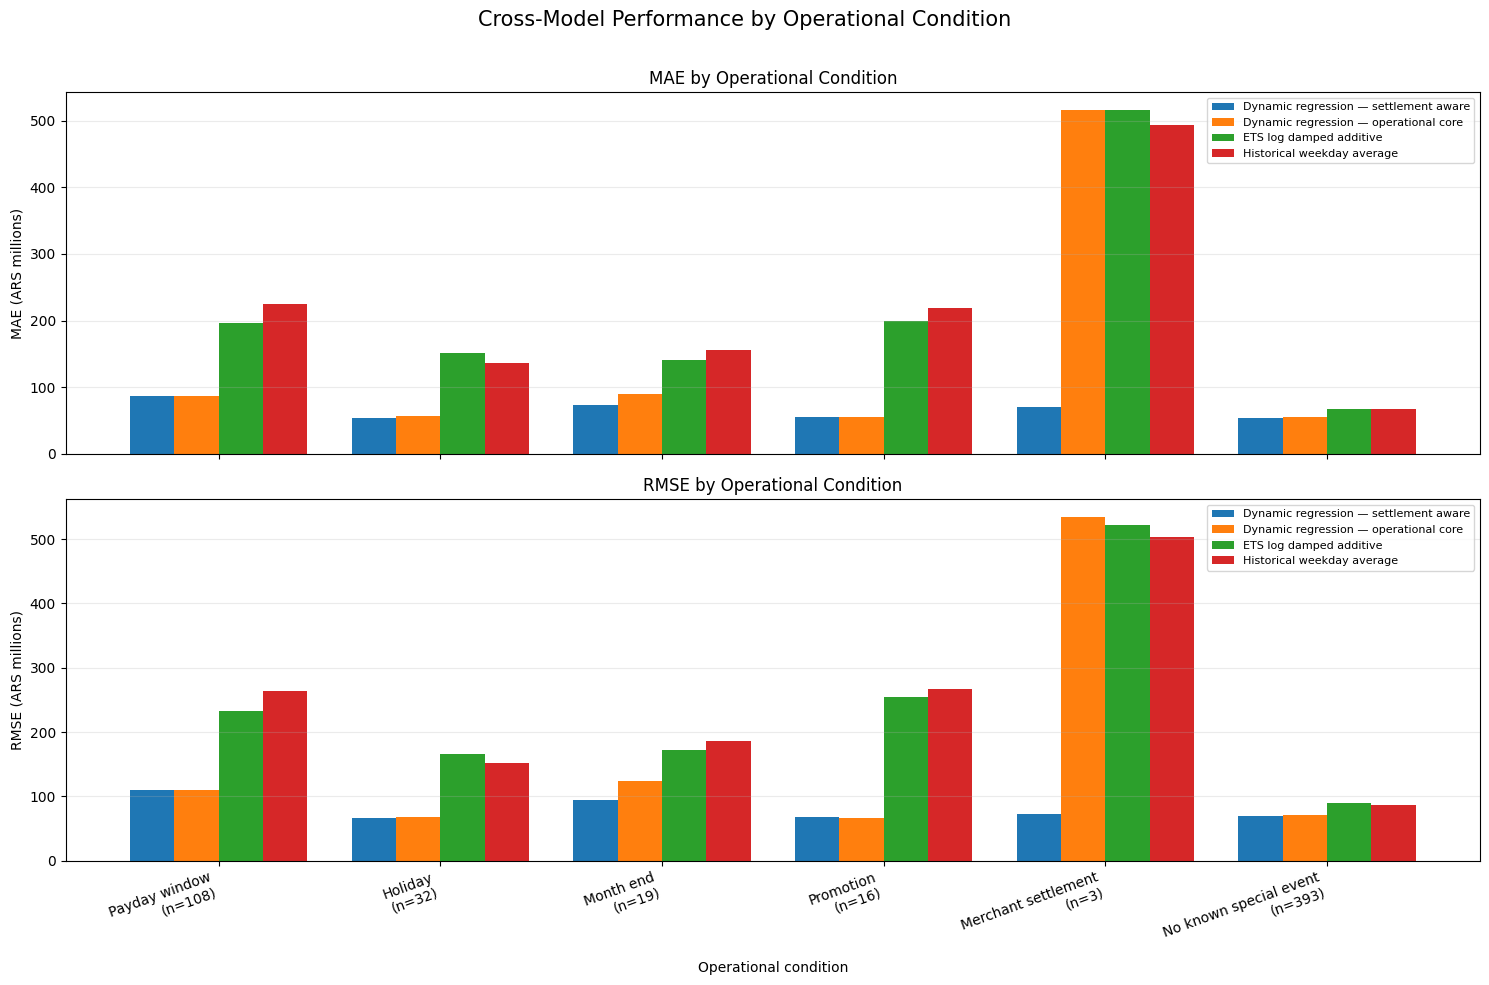

,selected_variable_name,candidate_dataframes_found,row_count,column_count,date_start,date_end,missing_condition_values,duplicated_dates,status
0,df,1,1308,39,2023-01-01,2026-07-31,0,0,PASS


,check,observed,expected,status
0,condition_source_recovered,PASS,PASS,PASS
1,comparison_models,4,4,PASS
2,supported_conditions,10,> 0,PASS
3,condition_metric_rows,40,40,PASS
4,observations_match_condition_support,True,True,PASS
5,no_duplicate_model_condition_rows,0,0,PASS
6,all_condition_metrics_finite,True,True,PASS
7,all_days_support,560,560,PASS
8,promotion_support,16,16,PASS
9,settlement_support,3,3,PASS


,condition_name,condition_label,evaluation_role,future_availability,out_of_sample_observations,folds_represented,support_level,available_for_evaluation
0,all_days,All days,reference,not_applicable,560,20,broad_descriptive_support,True
1,payday_day,Payday,known_future_condition,known_in_advance,36,20,moderate_descriptive_support,True
2,payday_window,Payday window,known_future_condition,known_in_advance,108,20,broad_descriptive_support,True
3,holiday,Holiday,known_future_condition,known_in_advance,32,17,moderate_descriptive_support,True
4,month_end,Month end,known_future_condition,known_in_advance,19,19,limited_descriptive_support,True
5,promotion,Promotion,known_future_condition,known_in_advance_under_plan_assumption,16,5,limited_descriptive_support,True
6,merchant_settlement,Merchant settlement,limited_support_condition,known_in_advance_under_schedule_assumption,3,3,very_limited_descriptive_support,True
7,system_incident,System incident,diagnostic_only,not_available_at_origin,3,3,very_limited_descriptive_support,True
8,macro_shock,Macro shock,diagnostic_only,not_available_at_origin,2,2,very_limited_descriptive_support,True
9,no_known_special_event,No known special event,reference_condition,known_in_advance,393,20,broad_descriptive_support,True


,condition_name,support_level,model_name,observations,mae,rmse,mean_error,bias_pct,mase,rmsse
0,holiday,moderate_descriptive_support,calendar_promotion_settlement_trend_arima011_e...,32,54.1738,66.4953,-7.3766,-0.8776,0.5631,0.4919
1,holiday,moderate_descriptive_support,calendar_promotion_trend_arima011_errors,32,55.8791,68.0236,-7.1169,-0.8467,0.5799,0.5017
2,holiday,moderate_descriptive_support,historical_weekday_average,32,136.2735,152.4934,104.0893,12.3837,1.4208,1.1495
3,holiday,moderate_descriptive_support,ets_log_damped_additive,32,150.7031,166.2896,124.8313,14.8515,1.5698,1.2480
4,macro_shock,very_limited_descriptive_support,calendar_promotion_trend_arima011_errors,2,146.4794,167.2205,-146.4794,-10.9033,1.6332,1.3966
5,macro_shock,very_limited_descriptive_support,calendar_promotion_settlement_trend_arima011_e...,2,153.0804,176.3323,-153.0804,-11.3946,1.7098,1.4747
6,macro_shock,very_limited_descriptive_support,ets_log_damped_additive,2,380.5747,388.8389,-380.5747,-28.3283,4.1207,3.1281
7,macro_shock,very_limited_descriptive_support,historical_weekday_average,2,393.2610,399.8757,-393.2610,-29.2726,4.2487,3.2041
8,merchant_settlement,very_limited_descriptive_support,calendar_promotion_settlement_trend_arima011_e...,3,69.6559,72.0805,69.6559,4.4697,0.7326,0.5567
9,merchant_settlement,very_limited_descriptive_support,historical_weekday_average,3,493.4965,503.3503,-493.4965,-31.6667,5.0491,3.6807


,condition_name,condition_label,condition_evaluation_role,future_availability,support_level,observations,folds_represented,candidate_model,reference_model,candidate_mae,reference_mae,mae_improvement,mae_improvement_pct,candidate_rmse,reference_rmse,rmse_improvement,rmse_improvement_pct,candidate_mean_error,reference_mean_error
0,all_days,All days,reference,not_applicable,broad_descriptive_support,560,20,calendar_promotion_trend_arima011_errors,ets_log_damped_additive,63.7503,101.0620,37.3117,36.9196,89.4678,141.3892,51.9214,36.7223,4.4592,-7.8258
1,all_days,All days,reference,not_applicable,broad_descriptive_support,560,20,calendar_promotion_trend_arima011_errors,historical_weekday_average,63.7503,106.5762,42.8259,40.1834,89.4678,149.9408,60.4729,40.3312,4.4592,-34.5093
2,holiday,Holiday,known_future_condition,known_in_advance,moderate_descriptive_support,32,17,calendar_promotion_trend_arima011_errors,ets_log_damped_additive,55.8791,150.7031,94.8240,62.9211,68.0236,166.2896,98.2661,59.0933,-7.1169,124.8313
3,holiday,Holiday,known_future_condition,known_in_advance,moderate_descriptive_support,32,17,calendar_promotion_trend_arima011_errors,historical_weekday_average,55.8791,136.2735,80.3944,58.9949,68.0236,152.4934,84.4699,55.3925,-7.1169,104.0893
4,macro_shock,Macro shock,diagnostic_only,not_available_at_origin,very_limited_descriptive_support,2,2,calendar_promotion_trend_arima011_errors,ets_log_damped_additive,146.4794,380.5747,234.0953,61.5110,167.2205,388.8389,221.6184,56.9949,-146.4794,-380.5747
5,macro_shock,Macro shock,diagnostic_only,not_available_at_origin,very_limited_descriptive_support,2,2,calendar_promotion_trend_arima011_errors,historical_weekday_average,146.4794,393.2610,246.7816,62.7526,167.2205,399.8757,232.6552,58.1819,-146.4794,-393.2610
6,merchant_settlement,Merchant settlement,limited_support_condition,known_in_advance_under_schedule_assumption,very_limited_descriptive_support,3,3,calendar_promotion_trend_arima011_errors,ets_log_damped_additive,517.0599,516.2174,-0.8425,-0.1632,534.9351,521.7839,-13.1511,-2.5204,-517.0599,-516.2174
7,merchant_settlement,Merchant settlement,limited_support_condition,known_in_advance_under_schedule_assumption,very_limited_descriptive_support,3,3,calendar_promotion_trend_arima011_errors,historical_weekday_average,517.0599,493.4965,-23.5633,-4.7748,534.9351,503.3503,-31.5848,-6.2749,-517.0599,-493.4965
8,month_end,Month end,known_future_condition,known_in_advance,limited_descriptive_support,19,19,calendar_promotion_trend_arima011_errors,ets_log_damped_additive,89.9615,140.1579,50.1964,35.8142,124.2302,172.0200,47.7898,27.7816,-1.3316,-127.6798
9,month_end,Month end,known_future_condition,known_in_advance,limited_descriptive_support,19,19,calendar_promotion_trend_arima011_errors,historical_weekday_average,89.9615,156.0730,66.1115,42.3593,124.2302,186.5252,62.2950,33.3976,-1.3316,-156.0730


,metric,condition_name,condition_label,support_level,observations,model_name,model_label,winning_metric_value,tie_count
0,mae,all_days,All days,broad_descriptive_support,560,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,60.4518,1
1,mae,holiday,Holiday,moderate_descriptive_support,32,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,54.1738,1
2,mae,macro_shock,Macro shock,very_limited_descriptive_support,2,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,146.4794,1
3,mae,merchant_settlement,Merchant settlement,very_limited_descriptive_support,3,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,69.6559,1
4,mae,month_end,Month end,limited_descriptive_support,19,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,73.2883,1
5,mae,no_known_special_event,No known special event,broad_descriptive_support,393,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,53.6506,1
6,mae,payday_day,Payday,moderate_descriptive_support,36,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,102.0680,1
7,mae,payday_window,Payday window,broad_descriptive_support,108,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,86.7481,1
8,mae,promotion,Promotion,limited_descriptive_support,16,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,54.6988,1
9,mae,system_incident,System incident,very_limited_descriptive_support,3,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,276.5124,1


,metric,model_name,model_label,conditions_won,tied_wins
0,mae,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,7,0
1,mae,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,3,0
2,rmse,calendar_promotion_settlement_trend_arima011_e...,Dynamic regression — settlement aware,5,0
3,rmse,calendar_promotion_trend_arima011_errors,Dynamic regression — operational core,5,0


Complete condition source selected: df
Supported conditions evaluated: 10
Condition-model metric rows: 40
Saved condition figure: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\04_cross_notebook_metrics_by_condition.png


In [46]:
# ============================================================================
# 28. Evaluate cross-model performance by operational condition
# ============================================================================

# ----------------------------------------------------------------------------
# Validate required objects
# ----------------------------------------------------------------------------

required_objects = [
    "cross_notebook_predictions",
    "cross_notebook_aggregate_metrics",
    "cross_notebook_model_registry",
    "modeling_dataset_with_trend",
]

missing_required_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

assert not missing_required_objects, (
    "Missing required objects: "
    f"{missing_required_objects}"
)


# ----------------------------------------------------------------------------
# Define the conditions to be evaluated
# ----------------------------------------------------------------------------

condition_registry_records = [
    {
        "condition_name": "all_days",
        "condition_label": "All days",
        "evaluation_role": "reference",
        "future_availability": "not_applicable",
        "condition_definition": (
            "All out-of-sample forecast dates."
        ),
    },
    {
        "condition_name": "payday_day",
        "condition_label": "Payday",
        "evaluation_role": "known_future_condition",
        "future_availability": "known_in_advance",
        "condition_definition": "is_payday == 1",
    },
    {
        "condition_name": "payday_window",
        "condition_label": "Payday window",
        "evaluation_role": "known_future_condition",
        "future_availability": "known_in_advance",
        "condition_definition": (
            "is_payday_window == 1"
        ),
    },
    {
        "condition_name": "holiday",
        "condition_label": "Holiday",
        "evaluation_role": "known_future_condition",
        "future_availability": "known_in_advance",
        "condition_definition": "is_holiday == 1",
    },
    {
        "condition_name": "month_end",
        "condition_label": "Month end",
        "evaluation_role": "known_future_condition",
        "future_availability": "known_in_advance",
        "condition_definition": (
            "is_month_end == 1"
        ),
    },
    {
        "condition_name": "promotion",
        "condition_label": "Promotion",
        "evaluation_role": "known_future_condition",
        "future_availability": (
            "known_in_advance_under_plan_assumption"
        ),
        "condition_definition": (
            "promotion_intensity > 0"
        ),
    },
    {
        "condition_name": "merchant_settlement",
        "condition_label": "Merchant settlement",
        "evaluation_role": (
            "limited_support_condition"
        ),
        "future_availability": (
            "known_in_advance_under_schedule_assumption"
        ),
        "condition_definition": (
            "is_large_merchant_settlement == 1"
        ),
    },
    {
        "condition_name": "system_incident",
        "condition_label": "System incident",
        "evaluation_role": "diagnostic_only",
        "future_availability": (
            "not_available_at_origin"
        ),
        "condition_definition": (
            "system_incident == 1"
        ),
    },
    {
        "condition_name": "macro_shock",
        "condition_label": "Macro shock",
        "evaluation_role": "diagnostic_only",
        "future_availability": (
            "not_available_at_origin"
        ),
        "condition_definition": (
            "is_macro_shock == 1"
        ),
    },
    {
        "condition_name": "no_known_special_event",
        "condition_label": (
            "No known special event"
        ),
        "evaluation_role": "reference_condition",
        "future_availability": "known_in_advance",
        "condition_definition": (
            "No payday window, holiday, month end, "
            "promotion or scheduled merchant settlement."
        ),
    },
]

cross_notebook_condition_registry = pd.DataFrame(
    condition_registry_records
)

assert cross_notebook_condition_registry[
    "condition_name"
].is_unique


# ----------------------------------------------------------------------------
# Recover condition labels from the complete validated input dataset
# ----------------------------------------------------------------------------

condition_source_columns = [
    DATE_COLUMN,
    "is_payday",
    "is_payday_window",
    "is_holiday",
    "is_month_end",
    "promotion_intensity",
    "is_large_merchant_settlement",
    "merchant_settlement_intensity",
    "system_incident",
    "is_macro_shock",
]

# Use the original complete validated dataset explicitly.
assert "df" in globals(), (
    "The complete validated input dataset 'df' is not loaded."
)

condition_source_name = "df"

condition_source_data = df.copy()

missing_condition_source_columns = [
    column
    for column in condition_source_columns
    if column not in condition_source_data.columns
]

assert not missing_condition_source_columns, (
    "The complete dataset is missing condition columns: "
    f"{missing_condition_source_columns}"
)


expected_dates = pd.to_datetime(
    modeling_dataset_with_trend[
        DATE_COLUMN
    ],
    errors="raise",
)

condition_source_dates = pd.to_datetime(
    condition_source_data[
        DATE_COLUMN
    ],
    errors="raise",
)

assert len(
    condition_source_data
) == len(
    modeling_dataset_with_trend
)

assert condition_source_dates.is_unique

assert set(
    condition_source_dates
) == set(
    expected_dates
)


# Retain a one-row source registry so that the downstream audit
# remains unchanged.
condition_source_candidates = [
    {
        "variable_name": condition_source_name,
        "dataframe": condition_source_data,
        "row_count": len(
            condition_source_data
        ),
        "column_count": (
            condition_source_data.shape[1]
        ),
    }
]


selected_comparison = (
    condition_source_data[
        condition_source_columns
    ]
    .copy()
)

selected_comparison[
    DATE_COLUMN
] = pd.to_datetime(
    selected_comparison[
        DATE_COLUMN
    ],
    errors="raise",
)

selected_comparison = (
    selected_comparison
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)
# ----------------------------------------------------------------------------
# Build the unique daily condition-label table
# ----------------------------------------------------------------------------

condition_labels = (
    selected_comparison
    .rename(
        columns={
            DATE_COLUMN: "target_date",
        }
    )
)

assert len(condition_labels) == len(
    modeling_dataset_with_trend
)

assert condition_labels[
    "target_date"
].is_unique

assert (
    condition_labels
    .isna()
    .sum()
    .sum()
    == 0
)


# ----------------------------------------------------------------------------
# Validate binary condition indicators
# ----------------------------------------------------------------------------

binary_condition_columns = [
    "is_payday",
    "is_payday_window",
    "is_holiday",
    "is_month_end",
    "is_large_merchant_settlement",
    "system_incident",
    "is_macro_shock",
]

for column in binary_condition_columns:

    observed_values = set(
        condition_labels[
            column
        ].unique()
    )

    assert observed_values.issubset(
        {0, 1}
    ), (
        f"Unexpected values in {column}: "
        f"{observed_values}"
    )


condition_labels[
    "is_promotion"
] = (
    condition_labels[
        "promotion_intensity"
    ]
    .gt(0)
    .astype(int)
)

condition_labels[
    "no_known_special_event"
] = (
    condition_labels[
        [
            "is_payday_window",
            "is_holiday",
            "is_month_end",
            "is_promotion",
            "is_large_merchant_settlement",
        ]
    ]
    .eq(0)
    .all(axis=1)
    .astype(int)
)


# ----------------------------------------------------------------------------
# Record the recovered condition source
# ----------------------------------------------------------------------------

condition_source_recovery_audit = pd.DataFrame(
    [
        {
            "selected_variable_name": (
                condition_source_name
            ),
            "candidate_dataframes_found": len(
                condition_source_candidates
            ),
            "row_count": len(
                condition_source_data
            ),
            "column_count": (
                condition_source_data.shape[1]
            ),
            "date_start": (
                condition_labels[
                    "target_date"
                ].min()
            ),
            "date_end": (
                condition_labels[
                    "target_date"
                ].max()
            ),
            "missing_condition_values": int(
                condition_labels
                .isna()
                .sum()
                .sum()
            ),
            "duplicated_dates": int(
                condition_labels[
                    "target_date"
                ]
                .duplicated()
                .sum()
            ),
            "status": "PASS",
        }
    ]
)

CONDITION_SOURCE_RECOVERY_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "condition_source_recovery_audit.csv"
    )
)

condition_source_recovery_audit.to_csv(
    CONDITION_SOURCE_RECOVERY_AUDIT_PATH,
    index=False,
)

assert (
    CONDITION_SOURCE_RECOVERY_AUDIT_PATH
    .exists()
)


# ----------------------------------------------------------------------------
# Attach the event labels to every aligned prediction
# ----------------------------------------------------------------------------

cross_notebook_predictions_with_conditions = (
    cross_notebook_predictions
    .merge(
        condition_labels,
        on="target_date",
        how="left",
        validate="many_to_one",
    )
)

attached_condition_columns = [
    "is_payday",
    "is_payday_window",
    "is_holiday",
    "is_month_end",
    "is_promotion",
    "is_large_merchant_settlement",
    "system_incident",
    "is_macro_shock",
    "no_known_special_event",
]

assert (
    cross_notebook_predictions_with_conditions[
        attached_condition_columns
    ]
    .isna()
    .sum()
    .sum()
    == 0
)


# ----------------------------------------------------------------------------
# Condition-mask helper
# ----------------------------------------------------------------------------

def build_condition_mask(
    data,
    condition_name,
):
    """Return the Boolean mask for one operational condition."""

    if condition_name == "all_days":
        return pd.Series(
            True,
            index=data.index,
        )

    if condition_name == "payday_day":
        return data[
            "is_payday"
        ].eq(1)

    if condition_name == "payday_window":
        return data[
            "is_payday_window"
        ].eq(1)

    if condition_name == "holiday":
        return data[
            "is_holiday"
        ].eq(1)

    if condition_name == "month_end":
        return data[
            "is_month_end"
        ].eq(1)

    if condition_name == "promotion":
        return data[
            "is_promotion"
        ].eq(1)

    if condition_name == "merchant_settlement":
        return data[
            "is_large_merchant_settlement"
        ].eq(1)

    if condition_name == "system_incident":
        return data[
            "system_incident"
        ].eq(1)

    if condition_name == "macro_shock":
        return data[
            "is_macro_shock"
        ].eq(1)

    if condition_name == "no_known_special_event":
        return data[
            "no_known_special_event"
        ].eq(1)

    raise ValueError(
        f"Unknown condition: {condition_name}"
    )


# ----------------------------------------------------------------------------
# Determine out-of-sample support using one reference prediction set
# ----------------------------------------------------------------------------

condition_reference_predictions = (
    cross_notebook_predictions_with_conditions.loc[
        cross_notebook_predictions_with_conditions[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
    .copy()
)

assert len(
    condition_reference_predictions
) == (
    N_FOLDS
    * FORECAST_HORIZON
)


condition_support_records = []

for _, condition_row in (
    cross_notebook_condition_registry
    .iterrows()
):

    condition_name = (
        condition_row[
            "condition_name"
        ]
    )

    condition_mask = build_condition_mask(
        condition_reference_predictions,
        condition_name,
    )

    condition_data = (
        condition_reference_predictions.loc[
            condition_mask
        ]
    )

    observations = len(
        condition_data
    )

    if observations >= 100:
        support_level = (
            "broad_descriptive_support"
        )

    elif observations >= 20:
        support_level = (
            "moderate_descriptive_support"
        )

    elif observations >= 5:
        support_level = (
            "limited_descriptive_support"
        )

    elif observations > 0:
        support_level = (
            "very_limited_descriptive_support"
        )

    else:
        support_level = (
            "not_observed_out_of_sample"
        )

    condition_support_records.append(
        {
            "condition_name": condition_name,
            "out_of_sample_observations": (
                observations
            ),
            "folds_represented": (
                condition_data[
                    "fold_id"
                ].nunique()
            ),
            "minimum_target_date": (
                condition_data[
                    "target_date"
                ].min()
                if observations > 0
                else pd.NaT
            ),
            "maximum_target_date": (
                condition_data[
                    "target_date"
                ].max()
                if observations > 0
                else pd.NaT
            ),
            "support_level": (
                support_level
            ),
            "available_for_evaluation": bool(
                observations > 0
            ),
        }
    )


cross_notebook_condition_support = (
    pd.DataFrame(
        condition_support_records
    )
)

cross_notebook_condition_registry = (
    cross_notebook_condition_registry
    .merge(
        cross_notebook_condition_support,
        on="condition_name",
        how="left",
        validate="one_to_one",
    )
)

supported_conditions = (
    cross_notebook_condition_registry.loc[
        cross_notebook_condition_registry[
            "available_for_evaluation"
        ],
        "condition_name",
    ]
    .tolist()
)

assert supported_conditions


# ----------------------------------------------------------------------------
# Calculate metrics for every model and supported condition
# ----------------------------------------------------------------------------

condition_metric_records = []

for condition_name in supported_conditions:

    condition_mask = build_condition_mask(
        cross_notebook_predictions_with_conditions,
        condition_name,
    )

    condition_predictions = (
        cross_notebook_predictions_with_conditions.loc[
            condition_mask
        ]
    )

    registry_row = (
        cross_notebook_condition_registry.loc[
            cross_notebook_condition_registry[
                "condition_name"
            ].eq(condition_name)
        ]
        .iloc[0]
    )

    for model_name, model_data in (
        condition_predictions.groupby(
            "model_name"
        )
    ):

        errors = (
            model_data[
                "error"
            ]
            .to_numpy(dtype=float)
        )

        mean_actual = float(
            model_data[
                "actual"
            ].mean()
        )

        condition_metric_records.append(
            {
                "condition_name": (
                    condition_name
                ),
                "condition_label": (
                    registry_row[
                        "condition_label"
                    ]
                ),
                "condition_evaluation_role": (
                    registry_row[
                        "evaluation_role"
                    ]
                ),
                "future_availability": (
                    registry_row[
                        "future_availability"
                    ]
                ),
                "support_level": (
                    registry_row[
                        "support_level"
                    ]
                ),
                "model_name": model_name,
                "model_label": (
                    model_data[
                        "model_label"
                    ].iloc[0]
                ),
                "model_family": (
                    model_data[
                        "model_family"
                    ].iloc[0]
                ),
                "model_evaluation_role": (
                    model_data[
                        "evaluation_role"
                    ].iloc[0]
                ),
                "observations": len(
                    model_data
                ),
                "folds_represented": (
                    model_data[
                        "fold_id"
                    ].nunique()
                ),
                "mae": float(
                    np.mean(
                        np.abs(errors)
                    )
                ),
                "rmse": float(
                    np.sqrt(
                        np.mean(
                            np.square(errors)
                        )
                    )
                ),
                "mean_error": float(
                    np.mean(errors)
                ),
                "bias_pct": float(
                    100
                    * np.mean(errors)
                    / mean_actual
                ),
                "mase": float(
                    np.mean(
                        model_data[
                            "absolute_error"
                        ]
                        / model_data[
                            "mase_denominator"
                        ]
                    )
                ),
                "rmsse": float(
                    np.sqrt(
                        np.mean(
                            model_data[
                                "squared_error"
                            ]
                            / np.square(
                                model_data[
                                    "rmsse_denominator"
                                ]
                            )
                        )
                    )
                ),
                "mean_actual": (
                    mean_actual
                ),
                "mean_prediction": float(
                    model_data[
                        "prediction"
                    ].mean()
                ),
            }
        )


cross_notebook_metrics_by_condition = (
    pd.DataFrame(
        condition_metric_records
    )
    .sort_values(
        [
            "condition_name",
            "mae",
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Operational-core improvements against Notebook 03 reference models
# ----------------------------------------------------------------------------

condition_metric_lookup = (
    cross_notebook_metrics_by_condition
    .set_index(
        [
            "condition_name",
            "model_name",
        ]
    )
)

operational_condition_improvement_records = []

for condition_name in supported_conditions:

    operational_metrics = (
        condition_metric_lookup.loc[
            (
                condition_name,
                PRIMARY_MODEL_NAME,
            )
        ]
    )

    for reference_model in [
        ETS_REFERENCE_MODEL,
        BENCHMARK_REFERENCE_MODEL,
    ]:

        reference_metrics = (
            condition_metric_lookup.loc[
                (
                    condition_name,
                    reference_model,
                )
            ]
        )

        operational_condition_improvement_records.append(
            {
                "condition_name": (
                    condition_name
                ),
                "condition_label": (
                    operational_metrics[
                        "condition_label"
                    ]
                ),
                "condition_evaluation_role": (
                    operational_metrics[
                        "condition_evaluation_role"
                    ]
                ),
                "future_availability": (
                    operational_metrics[
                        "future_availability"
                    ]
                ),
                "support_level": (
                    operational_metrics[
                        "support_level"
                    ]
                ),
                "observations": int(
                    operational_metrics[
                        "observations"
                    ]
                ),
                "folds_represented": int(
                    operational_metrics[
                        "folds_represented"
                    ]
                ),
                "candidate_model": (
                    PRIMARY_MODEL_NAME
                ),
                "reference_model": (
                    reference_model
                ),
                "candidate_mae": float(
                    operational_metrics[
                        "mae"
                    ]
                ),
                "reference_mae": float(
                    reference_metrics[
                        "mae"
                    ]
                ),
                "mae_improvement": float(
                    reference_metrics[
                        "mae"
                    ]
                    - operational_metrics[
                        "mae"
                    ]
                ),
                "mae_improvement_pct": float(
                    100
                    * (
                        reference_metrics[
                            "mae"
                        ]
                        - operational_metrics[
                            "mae"
                        ]
                    )
                    / reference_metrics[
                        "mae"
                    ]
                ),
                "candidate_rmse": float(
                    operational_metrics[
                        "rmse"
                    ]
                ),
                "reference_rmse": float(
                    reference_metrics[
                        "rmse"
                    ]
                ),
                "rmse_improvement": float(
                    reference_metrics[
                        "rmse"
                    ]
                    - operational_metrics[
                        "rmse"
                    ]
                ),
                "rmse_improvement_pct": float(
                    100
                    * (
                        reference_metrics[
                            "rmse"
                        ]
                        - operational_metrics[
                            "rmse"
                        ]
                    )
                    / reference_metrics[
                        "rmse"
                    ]
                ),
                "candidate_mean_error": float(
                    operational_metrics[
                        "mean_error"
                    ]
                ),
                "reference_mean_error": float(
                    reference_metrics[
                        "mean_error"
                    ]
                ),
            }
        )


operational_core_condition_improvements = (
    pd.DataFrame(
        operational_condition_improvement_records
    )
)


# ----------------------------------------------------------------------------
# Condition-level model winners
# ----------------------------------------------------------------------------

condition_winner_records = []

for metric in [
    "mae",
    "rmse",
]:

    for condition_name, condition_data in (
        cross_notebook_metrics_by_condition
        .groupby(
            "condition_name"
        )
    ):

        best_metric_value = float(
            condition_data[
                metric
            ].min()
        )

        winning_rows = (
            condition_data.loc[
                np.isclose(
                    condition_data[
                        metric
                    ],
                    best_metric_value,
                    rtol=1e-12,
                    atol=1e-9,
                )
            ]
        )

        for _, winning_row in (
            winning_rows.iterrows()
        ):

            condition_winner_records.append(
                {
                    "metric": metric,
                    "condition_name": (
                        condition_name
                    ),
                    "condition_label": (
                        winning_row[
                            "condition_label"
                        ]
                    ),
                    "support_level": (
                        winning_row[
                            "support_level"
                        ]
                    ),
                    "observations": int(
                        winning_row[
                            "observations"
                        ]
                    ),
                    "model_name": (
                        winning_row[
                            "model_name"
                        ]
                    ),
                    "model_label": (
                        winning_row[
                            "model_label"
                        ]
                    ),
                    "winning_metric_value": (
                        best_metric_value
                    ),
                    "tie_count": len(
                        winning_rows
                    ),
                }
            )


cross_notebook_condition_winners = (
    pd.DataFrame(
        condition_winner_records
    )
)

cross_notebook_condition_winner_summary = (
    cross_notebook_condition_winners
    .groupby(
        [
            "metric",
            "model_name",
            "model_label",
        ],
        as_index=False,
    )
    .agg(
        conditions_won=(
            "condition_name",
            "nunique",
        ),
        tied_wins=(
            "tie_count",
            lambda values: int(
                values.gt(1).sum()
            ),
        ),
    )
)


# ----------------------------------------------------------------------------
# Structural audit
# ----------------------------------------------------------------------------

expected_condition_metric_rows = (
    len(supported_conditions)
    * len(COMPARISON_MODELS)
)

condition_observation_check = (
    cross_notebook_metrics_by_condition
    .merge(
        cross_notebook_condition_registry[
            [
                "condition_name",
                "out_of_sample_observations",
            ]
        ],
        on="condition_name",
        how="left",
        validate="many_to_one",
    )
)

condition_comparison_audit = pd.DataFrame(
    [
        {
            "check": "condition_source_recovered",
            "observed": (
                condition_source_recovery_audit[
                    "status"
                ].iloc[0]
            ),
            "expected": "PASS",
            "status": (
                "PASS"
                if condition_source_recovery_audit[
                    "status"
                ].iloc[0] == "PASS"
                else "FAIL"
            ),
        },
        {
            "check": "comparison_models",
            "observed": (
                cross_notebook_metrics_by_condition[
                    "model_name"
                ].nunique()
            ),
            "expected": len(
                COMPARISON_MODELS
            ),
            "status": (
                "PASS"
                if cross_notebook_metrics_by_condition[
                    "model_name"
                ].nunique()
                == len(COMPARISON_MODELS)
                else "FAIL"
            ),
        },
        {
            "check": "supported_conditions",
            "observed": len(
                supported_conditions
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if len(
                    supported_conditions
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": "condition_metric_rows",
            "observed": len(
                cross_notebook_metrics_by_condition
            ),
            "expected": (
                expected_condition_metric_rows
            ),
            "status": (
                "PASS"
                if len(
                    cross_notebook_metrics_by_condition
                )
                == expected_condition_metric_rows
                else "FAIL"
            ),
        },
        {
            "check": (
                "observations_match_condition_support"
            ),
            "observed": bool(
                condition_observation_check[
                    "observations"
                ].eq(
                    condition_observation_check[
                        "out_of_sample_observations"
                    ]
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if condition_observation_check[
                    "observations"
                ].eq(
                    condition_observation_check[
                        "out_of_sample_observations"
                    ]
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": (
                "no_duplicate_model_condition_rows"
            ),
            "observed": int(
                cross_notebook_metrics_by_condition
                .duplicated(
                    [
                        "condition_name",
                        "model_name",
                    ]
                )
                .sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if cross_notebook_metrics_by_condition
                .duplicated(
                    [
                        "condition_name",
                        "model_name",
                    ]
                )
                .sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": "all_condition_metrics_finite",
            "observed": bool(
                np.isfinite(
                    cross_notebook_metrics_by_condition[
                        [
                            "mae",
                            "rmse",
                            "mean_error",
                            "bias_pct",
                            "mase",
                            "rmsse",
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    cross_notebook_metrics_by_condition[
                        [
                            "mae",
                            "rmse",
                            "mean_error",
                            "bias_pct",
                            "mase",
                            "rmsse",
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "all_days_support",
            "observed": int(
                cross_notebook_condition_registry.loc[
                    cross_notebook_condition_registry[
                        "condition_name"
                    ].eq("all_days"),
                    "out_of_sample_observations",
                ].iloc[0]
            ),
            "expected": (
                N_FOLDS
                * FORECAST_HORIZON
            ),
            "status": (
                "PASS"
                if int(
                    cross_notebook_condition_registry.loc[
                        cross_notebook_condition_registry[
                            "condition_name"
                        ].eq("all_days"),
                        "out_of_sample_observations",
                    ].iloc[0]
                )
                == N_FOLDS
                * FORECAST_HORIZON
                else "FAIL"
            ),
        },
        {
            "check": "promotion_support",
            "observed": int(
                cross_notebook_condition_registry.loc[
                    cross_notebook_condition_registry[
                        "condition_name"
                    ].eq("promotion"),
                    "out_of_sample_observations",
                ].iloc[0]
            ),
            "expected": 16,
            "status": (
                "PASS"
                if int(
                    cross_notebook_condition_registry.loc[
                        cross_notebook_condition_registry[
                            "condition_name"
                        ].eq("promotion"),
                        "out_of_sample_observations",
                    ].iloc[0]
                ) == 16
                else "FAIL"
            ),
        },
        {
            "check": "settlement_support",
            "observed": int(
                cross_notebook_condition_registry.loc[
                    cross_notebook_condition_registry[
                        "condition_name"
                    ].eq(
                        "merchant_settlement"
                    ),
                    "out_of_sample_observations",
                ].iloc[0]
            ),
            "expected": 3,
            "status": (
                "PASS"
                if int(
                    cross_notebook_condition_registry.loc[
                        cross_notebook_condition_registry[
                            "condition_name"
                        ].eq(
                            "merchant_settlement"
                        ),
                        "out_of_sample_observations",
                    ].iloc[0]
                ) == 3
                else "FAIL"
            ),
        },
        {
            "check": "missing_condition_labels",
            "observed": int(
                cross_notebook_predictions_with_conditions[
                    attached_condition_columns
                ]
                .isna()
                .sum()
                .sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if cross_notebook_predictions_with_conditions[
                    attached_condition_columns
                ]
                .isna()
                .sum()
                .sum() == 0
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

CONDITION_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_condition_registry.csv"
    )
)

CONDITION_PREDICTIONS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_predictions_with_conditions.csv"
    )
)

CONDITION_METRICS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_metrics_by_condition.csv"
    )
)

OPERATIONAL_CONDITION_IMPROVEMENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "operational_core_condition_improvements.csv"
    )
)

CONDITION_WINNERS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_condition_winners.csv"
    )
)

CONDITION_WINNER_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_condition_winner_summary.csv"
    )
)

CONDITION_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_condition_comparison_audit.csv"
    )
)


cross_notebook_condition_registry.to_csv(
    CONDITION_REGISTRY_PATH,
    index=False,
)

cross_notebook_predictions_with_conditions.to_csv(
    CONDITION_PREDICTIONS_PATH,
    index=False,
)

cross_notebook_metrics_by_condition.to_csv(
    CONDITION_METRICS_PATH,
    index=False,
)

operational_core_condition_improvements.to_csv(
    OPERATIONAL_CONDITION_IMPROVEMENTS_PATH,
    index=False,
)

cross_notebook_condition_winners.to_csv(
    CONDITION_WINNERS_PATH,
    index=False,
)

cross_notebook_condition_winner_summary.to_csv(
    CONDITION_WINNER_SUMMARY_PATH,
    index=False,
)

condition_comparison_audit.to_csv(
    CONDITION_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Condition-comparison figure
# ----------------------------------------------------------------------------

figure_condition_order = [
    condition_name
    for condition_name in [
        "payday_window",
        "holiday",
        "month_end",
        "promotion",
        "merchant_settlement",
        "no_known_special_event",
    ]
    if condition_name in supported_conditions
]

assert figure_condition_order

figure_condition_registry = (
    cross_notebook_condition_registry
    .set_index("condition_name")
)

figure_model_order = (
    cross_notebook_aggregate_metrics
    .sort_values("mae")[
        "model_name"
    ]
    .tolist()
)

figure_model_labels = (
    cross_notebook_model_registry
    .set_index("model_name")[
        "model_label"
    ]
    .to_dict()
)

figure_positions = np.arange(
    len(figure_condition_order)
)

bar_width = (
    0.8
    / len(figure_model_order)
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 10),
    sharex=True,
)


for model_index, model_name in enumerate(
    figure_model_order
):

    model_condition_data = (
        cross_notebook_metrics_by_condition.loc[
            cross_notebook_metrics_by_condition[
                "model_name"
            ].eq(model_name)
            & cross_notebook_metrics_by_condition[
                "condition_name"
            ].isin(
                figure_condition_order
            )
        ]
        .set_index("condition_name")
        .loc[figure_condition_order]
    )

    position_offset = (
        model_index
        - (
            len(figure_model_order)
            - 1
        ) / 2
    ) * bar_width

    axes[0].bar(
        figure_positions
        + position_offset,
        model_condition_data[
            "mae"
        ],
        width=bar_width,
        label=figure_model_labels[
            model_name
        ],
    )

    axes[1].bar(
        figure_positions
        + position_offset,
        model_condition_data[
            "rmse"
        ],
        width=bar_width,
        label=figure_model_labels[
            model_name
        ],
    )


axes[0].set_title(
    "MAE by Operational Condition"
)

axes[0].set_ylabel(
    "MAE (ARS millions)"
)

axes[0].legend(
    fontsize=8
)

axes[0].grid(
    axis="y",
    alpha=0.25,
)


axes[1].set_title(
    "RMSE by Operational Condition"
)

axes[1].set_ylabel(
    "RMSE (ARS millions)"
)

axes[1].set_xlabel(
    "Operational condition"
)

axes[1].legend(
    fontsize=8
)

axes[1].grid(
    axis="y",
    alpha=0.25,
)

axes[1].set_xticks(
    figure_positions
)

axes[1].set_xticklabels(
    [
        (
            f"{figure_condition_registry.loc[condition_name, 'condition_label']}"
            f"\n(n={int(figure_condition_registry.loc[condition_name, 'out_of_sample_observations'])})"
        )
        for condition_name in figure_condition_order
    ],
    rotation=20,
    ha="right",
)


fig.suptitle(
    "Cross-Model Performance by Operational Condition",
    fontsize=15,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)


CONDITION_FIGURE_PATH = (
    FIGURES_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "cross_notebook_metrics_by_condition.png"
    )
)

fig.savefig(
    CONDITION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs and critical controls
# ----------------------------------------------------------------------------

for output_path in [
    CONDITION_SOURCE_RECOVERY_AUDIT_PATH,
    CONDITION_REGISTRY_PATH,
    CONDITION_PREDICTIONS_PATH,
    CONDITION_METRICS_PATH,
    OPERATIONAL_CONDITION_IMPROVEMENTS_PATH,
    CONDITION_WINNERS_PATH,
    CONDITION_WINNER_SUMMARY_PATH,
    CONDITION_AUDIT_PATH,
    CONDITION_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: "
        f"{output_path}"
    )


assert condition_comparison_audit[
    "status"
].eq("PASS").all(), (
    "The condition-level model comparison "
    "failed at least one audit."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(
    condition_source_recovery_audit
)

display(
    condition_comparison_audit
)

display(
    cross_notebook_condition_registry[
        [
            "condition_name",
            "condition_label",
            "evaluation_role",
            "future_availability",
            "out_of_sample_observations",
            "folds_represented",
            "support_level",
            "available_for_evaluation",
        ]
    ]
)

display(
    cross_notebook_metrics_by_condition.loc[
        cross_notebook_metrics_by_condition[
            "condition_name"
        ].isin(
            [
                "payday_window",
                "holiday",
                "month_end",
                "promotion",
                "merchant_settlement",
                "system_incident",
                "macro_shock",
                "no_known_special_event",
            ]
        ),
        [
            "condition_name",
            "support_level",
            "model_name",
            "observations",
            "mae",
            "rmse",
            "mean_error",
            "bias_pct",
            "mase",
            "rmsse",
        ],
    ]
    .reset_index(drop=True)
)

display(
    operational_core_condition_improvements
    .sort_values(
        [
            "condition_name",
            "reference_model",
        ]
    )
    .reset_index(drop=True)
)

display(
    cross_notebook_condition_winners
    .sort_values(
        [
            "metric",
            "condition_name",
        ]
    )
    .reset_index(drop=True)
)

display(
    cross_notebook_condition_winner_summary
    .sort_values(
        [
            "metric",
            "conditions_won",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

print(
    "Complete condition source selected: "
    f"{condition_source_name}"
)

print(
    "Supported conditions evaluated: "
    f"{len(supported_conditions)}"
)

print(
    "Condition-model metric rows: "
    f"{len(cross_notebook_metrics_by_condition)}"
)

print(
    "Saved condition figure: "
    f"{CONDITION_FIGURE_PATH}"
)

## 27. Final operational model selection

The final model decision combines statistical performance with the future
availability of the required regressors.

The default operational model is:

`calendar_promotion_trend_arima011_errors`

This model is selected because it:

- Outperforms the historical-weekday benchmark and the selected ETS model
  on the same 560 out-of-sample observations.
- Maintains its advantage across almost the complete 28-day horizon.
- Produces substantially lower errors during payday windows, holidays,
  month-end dates and planned promotions.
- Also improves performance on dates without known special events.
- Uses regressors that can be known at the forecast origin, provided that
  the complete promotion plan is available.

The settlement-aware specification achieves the lowest aggregate errors, but
it is not selected as the universal default model. Its out-of-sample evidence
contains only three scheduled settlement events.

Therefore:

- `calendar_promotion_trend_arima011_errors` is the default operational model.
- `calendar_promotion_settlement_trend_arima011_errors` is a conditional
  event-aware variant.
- The conditional variant may only be activated when the complete and
  reliable settlement schedule is known for the full 28-day horizon.
- ETS remains the validated univariate statistical benchmark.
- System incidents and macroeconomic shocks remain unanticipated operational
  risks and are not treated as known-future regressors.

The selection is an operational decision rather than a purely numerical
ranking.

In [47]:
# ============================================================================
# 29. Freeze the final operational model selection
# ============================================================================

# ----------------------------------------------------------------------------
# Validate required objects
# ----------------------------------------------------------------------------

required_selection_objects = [
    "cross_notebook_aggregate_metrics",
    "cross_notebook_pairwise_improvements",
    "cross_notebook_horizon_pairwise_summary",
    "operational_core_condition_improvements",
    "cross_notebook_condition_registry",
    "merchant_settlement_feature_decision",
    "dynamic_regression_operational_variants",
    "cross_notebook_comparison_audit",
    "horizon_comparison_audit",
    "condition_comparison_audit",
    "settlement_decision_audit",
]

missing_selection_objects = [
    object_name
    for object_name in required_selection_objects
    if object_name not in globals()
]

assert not missing_selection_objects, (
    "Missing required selection objects: "
    f"{missing_selection_objects}"
)


# ----------------------------------------------------------------------------
# Helper for retrieving one validated row
# ----------------------------------------------------------------------------

def get_unique_validated_row(
    table,
    mask,
    row_description,
):
    """Return exactly one row selected from a validated table."""

    selected_rows = table.loc[
        mask
    ]

    assert len(selected_rows) == 1, (
        f"Expected exactly one row for {row_description}, "
        f"but found {len(selected_rows)}."
    )

    return selected_rows.iloc[0]


# ----------------------------------------------------------------------------
# Retrieve aggregate model results
# ----------------------------------------------------------------------------

aggregate_metric_lookup = (
    cross_notebook_aggregate_metrics
    .set_index("model_name")
)

assert PRIMARY_MODEL_NAME in (
    aggregate_metric_lookup.index
)

assert SETTLEMENT_MODEL_NAME in (
    aggregate_metric_lookup.index
)

assert ETS_REFERENCE_MODEL in (
    aggregate_metric_lookup.index
)

assert BENCHMARK_REFERENCE_MODEL in (
    aggregate_metric_lookup.index
)


primary_aggregate = (
    aggregate_metric_lookup.loc[
        PRIMARY_MODEL_NAME
    ]
)

settlement_aggregate = (
    aggregate_metric_lookup.loc[
        SETTLEMENT_MODEL_NAME
    ]
)

ets_aggregate = (
    aggregate_metric_lookup.loc[
        ETS_REFERENCE_MODEL
    ]
)

benchmark_aggregate = (
    aggregate_metric_lookup.loc[
        BENCHMARK_REFERENCE_MODEL
    ]
)


# ----------------------------------------------------------------------------
# Retrieve pairwise aggregate improvements
# ----------------------------------------------------------------------------

primary_vs_ets = get_unique_validated_row(
    table=cross_notebook_pairwise_improvements,
    mask=(
        cross_notebook_pairwise_improvements[
            "candidate_model"
        ].eq(PRIMARY_MODEL_NAME)
        & cross_notebook_pairwise_improvements[
            "reference_model"
        ].eq(ETS_REFERENCE_MODEL)
    ),
    row_description=(
        "operational core versus ETS"
    ),
)

primary_vs_benchmark = get_unique_validated_row(
    table=cross_notebook_pairwise_improvements,
    mask=(
        cross_notebook_pairwise_improvements[
            "candidate_model"
        ].eq(PRIMARY_MODEL_NAME)
        & cross_notebook_pairwise_improvements[
            "reference_model"
        ].eq(BENCHMARK_REFERENCE_MODEL)
    ),
    row_description=(
        "operational core versus benchmark"
    ),
)


# ----------------------------------------------------------------------------
# Retrieve horizon-level evidence
# ----------------------------------------------------------------------------

primary_horizon_vs_ets = get_unique_validated_row(
    table=cross_notebook_horizon_pairwise_summary,
    mask=(
        cross_notebook_horizon_pairwise_summary[
            "candidate_model"
        ].eq(PRIMARY_MODEL_NAME)
        & cross_notebook_horizon_pairwise_summary[
            "reference_model"
        ].eq(ETS_REFERENCE_MODEL)
    ),
    row_description=(
        "operational-core horizon summary versus ETS"
    ),
)

primary_horizon_vs_benchmark = get_unique_validated_row(
    table=cross_notebook_horizon_pairwise_summary,
    mask=(
        cross_notebook_horizon_pairwise_summary[
            "candidate_model"
        ].eq(PRIMARY_MODEL_NAME)
        & cross_notebook_horizon_pairwise_summary[
            "reference_model"
        ].eq(BENCHMARK_REFERENCE_MODEL)
    ),
    row_description=(
        "operational-core horizon summary versus benchmark"
    ),
)


# ----------------------------------------------------------------------------
# Retrieve condition-level evidence
# ----------------------------------------------------------------------------

def get_condition_improvement(
    condition_name,
    reference_model,
):
    """Retrieve one operational-core condition comparison."""

    return get_unique_validated_row(
        table=(
            operational_core_condition_improvements
        ),
        mask=(
            operational_core_condition_improvements[
                "condition_name"
            ].eq(condition_name)
            & operational_core_condition_improvements[
                "reference_model"
            ].eq(reference_model)
        ),
        row_description=(
            f"{condition_name} versus {reference_model}"
        ),
    )


promotion_vs_ets = get_condition_improvement(
    condition_name="promotion",
    reference_model=ETS_REFERENCE_MODEL,
)

payday_window_vs_ets = (
    get_condition_improvement(
        condition_name="payday_window",
        reference_model=ETS_REFERENCE_MODEL,
    )
)

holiday_vs_ets = get_condition_improvement(
    condition_name="holiday",
    reference_model=ETS_REFERENCE_MODEL,
)

month_end_vs_ets = get_condition_improvement(
    condition_name="month_end",
    reference_model=ETS_REFERENCE_MODEL,
)

ordinary_days_vs_ets = get_condition_improvement(
    condition_name="no_known_special_event",
    reference_model=ETS_REFERENCE_MODEL,
)


# ----------------------------------------------------------------------------
# Retrieve the previously validated settlement guardrail
# ----------------------------------------------------------------------------

settlement_feature_row = get_unique_validated_row(
    table=merchant_settlement_feature_decision,
    mask=(
        merchant_settlement_feature_decision[
            "feature"
        ].eq(
            "merchant_settlement_intensity"
        )
    ),
    row_description=(
        "merchant-settlement feature decision"
    ),
)

primary_variant_row = get_unique_validated_row(
    table=dynamic_regression_operational_variants,
    mask=(
        dynamic_regression_operational_variants[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ),
    row_description=(
        "primary operational variant"
    ),
)

settlement_variant_row = get_unique_validated_row(
    table=dynamic_regression_operational_variants,
    mask=(
        dynamic_regression_operational_variants[
            "model_name"
        ].eq(SETTLEMENT_MODEL_NAME)
    ),
    row_description=(
        "conditional settlement-aware variant"
    ),
)


# ----------------------------------------------------------------------------
# Retrieve condition-availability guardrails
# ----------------------------------------------------------------------------

system_incident_registry_row = (
    get_unique_validated_row(
        table=cross_notebook_condition_registry,
        mask=(
            cross_notebook_condition_registry[
                "condition_name"
            ].eq("system_incident")
        ),
        row_description=(
            "system-incident condition registry"
        ),
    )
)

macro_shock_registry_row = (
    get_unique_validated_row(
        table=cross_notebook_condition_registry,
        mask=(
            cross_notebook_condition_registry[
                "condition_name"
            ].eq("macro_shock")
        ),
        row_description=(
            "macro-shock condition registry"
        ),
    )
)


# ----------------------------------------------------------------------------
# Final model-selection decision
# ----------------------------------------------------------------------------

final_model_selection_decision = pd.DataFrame(
    [
        {
            "decision_scope": (
                "default_28_day_operational_forecast"
            ),
            "selected_model_name": (
                PRIMARY_MODEL_NAME
            ),
            "selected_specification_name": (
                primary_variant_row[
                    "specification_name"
                ]
            ),
            "selected_error_model": (
                primary_variant_row[
                    "error_model"
                ]
            ),
            "selected_order": (
                primary_variant_row[
                    "order"
                ]
            ),
            "point_forecast_transformation": (
                primary_variant_row[
                    "point_forecast_transformation"
                ]
            ),
            "global_mae": float(
                primary_aggregate["mae"]
            ),
            "global_rmse": float(
                primary_aggregate["rmse"]
            ),
            "global_mean_error": float(
                primary_aggregate["mean_error"]
            ),
            "global_bias_pct": float(
                primary_aggregate["bias_pct"]
            ),
            "mae_improvement_pct_vs_ets": float(
                primary_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "rmse_improvement_pct_vs_ets": float(
                primary_vs_ets[
                    "rmse_improvement_pct"
                ]
            ),
            "mae_improvement_pct_vs_benchmark": float(
                primary_vs_benchmark[
                    "mae_improvement_pct"
                ]
            ),
            "rmse_improvement_pct_vs_benchmark": float(
                primary_vs_benchmark[
                    "rmse_improvement_pct"
                ]
            ),
            "horizons_with_mae_improvement_vs_ets": int(
                primary_horizon_vs_ets[
                    "horizons_with_mae_improvement"
                ]
            ),
            "horizons_with_rmse_improvement_vs_ets": int(
                primary_horizon_vs_ets[
                    "horizons_with_rmse_improvement"
                ]
            ),
            "forecast_horizons_evaluated": int(
                primary_horizon_vs_ets[
                    "horizons_evaluated"
                ]
            ),
            "promotion_schedule_required": True,
            "settlement_schedule_required": False,
            "conditional_variant_model_name": (
                SETTLEMENT_MODEL_NAME
            ),
            "conditional_variant_activation": (
                settlement_variant_row[
                    "usage_condition"
                ]
            ),
            "settlement_generalization_status": (
                settlement_feature_row[
                    "generalization_status"
                ]
            ),
            "statistical_benchmark_model": (
                ETS_REFERENCE_MODEL
            ),
            "reference_benchmark_model": (
                BENCHMARK_REFERENCE_MODEL
            ),
            "selection_status": (
                "VALIDATED_DEFAULT_OPERATIONAL_MODEL"
            ),
            "decision_reason": (
                "The operational core materially outperforms ETS and the "
                "historical-weekday benchmark across aggregate metrics, "
                "nearly the full 28-day horizon, known calendar conditions "
                "and dates without special events. The settlement-aware "
                "variant is numerically stronger but remains conditional "
                "because only three settlement events were observed "
                "out of sample."
            ),
        }
    ]
)


# ----------------------------------------------------------------------------
# Structured evidence supporting the selection
# ----------------------------------------------------------------------------

final_selection_evidence = pd.DataFrame(
    [
        {
            "evidence_id": "aggregate_mae_vs_ets",
            "evidence_scope": "aggregate",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                primary_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": 560,
            "support_interpretation": (
                "Full aligned out-of-sample comparison."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "aggregate_rmse_vs_ets",
            "evidence_scope": "aggregate",
            "metric": "rmse_improvement_pct",
            "observed_value": float(
                primary_vs_ets[
                    "rmse_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": 560,
            "support_interpretation": (
                "Full aligned out-of-sample comparison."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "aggregate_mae_vs_benchmark",
            "evidence_scope": "aggregate",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                primary_vs_benchmark[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": 560,
            "support_interpretation": (
                "Full aligned out-of-sample comparison."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "aggregate_rmse_vs_benchmark",
            "evidence_scope": "aggregate",
            "metric": "rmse_improvement_pct",
            "observed_value": float(
                primary_vs_benchmark[
                    "rmse_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": 560,
            "support_interpretation": (
                "Full aligned out-of-sample comparison."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "horizon_mae_vs_ets",
            "evidence_scope": "forecast_horizon",
            "metric": (
                "horizons_with_mae_improvement"
            ),
            "observed_value": int(
                primary_horizon_vs_ets[
                    "horizons_with_mae_improvement"
                ]
            ),
            "minimum_required_value": 27,
            "observations": 28,
            "support_interpretation": (
                "Twenty observations per exact horizon."
            ),
            "status": (
                "PASS"
                if int(
                    primary_horizon_vs_ets[
                        "horizons_with_mae_improvement"
                    ]
                ) >= 27
                else "FAIL"
            ),
        },
        {
            "evidence_id": "horizon_rmse_vs_ets",
            "evidence_scope": "forecast_horizon",
            "metric": (
                "horizons_with_rmse_improvement"
            ),
            "observed_value": int(
                primary_horizon_vs_ets[
                    "horizons_with_rmse_improvement"
                ]
            ),
            "minimum_required_value": 27,
            "observations": 28,
            "support_interpretation": (
                "Twenty observations per exact horizon."
            ),
            "status": (
                "PASS"
                if int(
                    primary_horizon_vs_ets[
                        "horizons_with_rmse_improvement"
                    ]
                ) >= 27
                else "FAIL"
            ),
        },
        {
            "evidence_id": "promotion_mae_vs_ets",
            "evidence_scope": "operational_condition",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                promotion_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": int(
                promotion_vs_ets[
                    "observations"
                ]
            ),
            "support_interpretation": (
                "Limited descriptive support across five folds."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "payday_window_mae_vs_ets",
            "evidence_scope": "operational_condition",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                payday_window_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": int(
                payday_window_vs_ets[
                    "observations"
                ]
            ),
            "support_interpretation": (
                "Broad descriptive support across all folds."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "holiday_mae_vs_ets",
            "evidence_scope": "operational_condition",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                holiday_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": int(
                holiday_vs_ets[
                    "observations"
                ]
            ),
            "support_interpretation": (
                "Moderate descriptive support."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "month_end_mae_vs_ets",
            "evidence_scope": "operational_condition",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                month_end_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": int(
                month_end_vs_ets[
                    "observations"
                ]
            ),
            "support_interpretation": (
                "Limited descriptive support."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "ordinary_days_mae_vs_ets",
            "evidence_scope": "operational_condition",
            "metric": "mae_improvement_pct",
            "observed_value": float(
                ordinary_days_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "minimum_required_value": 0.0,
            "observations": int(
                ordinary_days_vs_ets[
                    "observations"
                ]
            ),
            "support_interpretation": (
                "Broad evidence that the improvement is not "
                "restricted to special-event dates."
            ),
            "status": "PASS",
        },
        {
            "evidence_id": "settlement_support_guardrail",
            "evidence_scope": "conditional_variant",
            "metric": "out_of_sample_settlement_days",
            "observed_value": int(
                settlement_feature_row[
                    "out_of_sample_settlement_days"
                ]
            ),
            "minimum_required_value": np.nan,
            "observations": int(
                settlement_feature_row[
                    "out_of_sample_settlement_days"
                ]
            ),
            "support_interpretation": (
                "Very limited support; the variant cannot become "
                "the universal default."
            ),
            "status": "GUARDRAIL",
        },
        {
            "evidence_id": "system_incident_availability",
            "evidence_scope": "unanticipated_event",
            "metric": "out_of_sample_observations",
            "observed_value": int(
                system_incident_registry_row[
                    "out_of_sample_observations"
                ]
            ),
            "minimum_required_value": np.nan,
            "observations": int(
                system_incident_registry_row[
                    "out_of_sample_observations"
                ]
            ),
            "support_interpretation": (
                "Diagnostic only; incidents are not available "
                "at the forecast origin."
            ),
            "status": "GUARDRAIL",
        },
        {
            "evidence_id": "macro_shock_availability",
            "evidence_scope": "unanticipated_event",
            "metric": "out_of_sample_observations",
            "observed_value": int(
                macro_shock_registry_row[
                    "out_of_sample_observations"
                ]
            ),
            "minimum_required_value": np.nan,
            "observations": int(
                macro_shock_registry_row[
                    "out_of_sample_observations"
                ]
            ),
            "support_interpretation": (
                "Diagnostic only; shocks are not available "
                "at the forecast origin."
            ),
            "status": "GUARDRAIL",
        },
    ]
)


# ----------------------------------------------------------------------------
# Operational model-activation policy
# ----------------------------------------------------------------------------

operational_forecast_policy = pd.DataFrame(
    [
        {
            "operational_scenario": (
                "promotion_plan_available_and_settlement_schedule_unavailable"
            ),
            "selected_model_name": (
                PRIMARY_MODEL_NAME
            ),
            "model_role": (
                "default_operational_model"
            ),
            "promotion_schedule_required": True,
            "settlement_schedule_required": False,
            "operational_action": (
                "Generate the default 28-day dynamic-regression forecast."
            ),
            "validation_status": "VALIDATED",
        },
        {
            "operational_scenario": (
                "promotion_plan_and_complete_settlement_schedule_available"
            ),
            "selected_model_name": (
                SETTLEMENT_MODEL_NAME
            ),
            "model_role": (
                "conditional_event_aware_variant"
            ),
            "promotion_schedule_required": True,
            "settlement_schedule_required": True,
            "operational_action": (
                "Activate the settlement-aware variant only when the "
                "complete settlement schedule is reliable for all "
                "twenty-eight forecast days."
            ),
            "validation_status": (
                "VALIDATED_WITH_LIMITED_EVENT_SUPPORT"
            ),
        },
        {
            "operational_scenario": (
                "promotion_plan_unavailable_or_incomplete"
            ),
            "selected_model_name": "",
            "model_role": (
                "unresolved_operational_fallback"
            ),
            "promotion_schedule_required": False,
            "settlement_schedule_required": False,
            "operational_action": (
                "Do not silently replace unknown promotion intensity "
                "with zero. A separately validated fallback policy is "
                "required before production use."
            ),
            "validation_status": (
                "REQUIRES_FALLBACK_POLICY"
            ),
        },
        {
            "operational_scenario": (
                "unplanned_system_incident_or_macro_shock"
            ),
            "selected_model_name": (
                PRIMARY_MODEL_NAME
            ),
            "model_role": (
                "forecast_not_event_aware"
            ),
            "promotion_schedule_required": True,
            "settlement_schedule_required": False,
            "operational_action": (
                "Treat the point forecast as not incident-aware. "
                "Unexpected-event risk must be handled by the later "
                "uncertainty and reserve-optimization stages."
            ),
            "validation_status": (
                "KNOWN_OPERATIONAL_LIMITATION"
            ),
        },
        {
            "operational_scenario": (
                "statistical_reference_comparison"
            ),
            "selected_model_name": (
                ETS_REFERENCE_MODEL
            ),
            "model_role": (
                "validated_statistical_benchmark"
            ),
            "promotion_schedule_required": False,
            "settlement_schedule_required": False,
            "operational_action": (
                "Retain ETS for benchmark reporting and monitoring, "
                "not as the selected default operational model."
            ),
            "validation_status": "VALIDATED_BENCHMARK",
        },
    ]
)


# ----------------------------------------------------------------------------
# Final selection audit
# ----------------------------------------------------------------------------

prerequisite_audits = {
    "cross_notebook_comparison": (
        cross_notebook_comparison_audit
    ),
    "horizon_comparison": (
        horizon_comparison_audit
    ),
    "condition_comparison": (
        condition_comparison_audit
    ),
    "settlement_decision": (
        settlement_decision_audit
    ),
}

all_prerequisite_audits_pass = all(
    audit_table[
        "status"
    ].eq("PASS").all()
    for audit_table in prerequisite_audits.values()
)


final_model_selection_audit = pd.DataFrame(
    [
        {
            "check": "all_prerequisite_audits_pass",
            "observed": (
                all_prerequisite_audits_pass
            ),
            "expected": True,
            "status": (
                "PASS"
                if all_prerequisite_audits_pass
                else "FAIL"
            ),
        },
        {
            "check": (
                "selected_model_is_default_eligible"
            ),
            "observed": bool(
                primary_aggregate[
                    "eligible_for_default_selection"
                ]
            ),
            "expected": True,
            "status": (
                "PASS"
                if bool(
                    primary_aggregate[
                        "eligible_for_default_selection"
                    ]
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "settlement_variant_not_default_eligible"
            ),
            "observed": bool(
                settlement_aggregate[
                    "eligible_for_default_selection"
                ]
            ),
            "expected": False,
            "status": (
                "PASS"
                if not bool(
                    settlement_aggregate[
                        "eligible_for_default_selection"
                    ]
                )
                else "FAIL"
            ),
        },
        {
            "check": "primary_mae_below_ets",
            "observed": float(
                primary_aggregate["mae"]
            ),
            "expected": (
                f"< {float(ets_aggregate['mae']):.4f}"
            ),
            "status": (
                "PASS"
                if float(
                    primary_aggregate["mae"]
                )
                < float(
                    ets_aggregate["mae"]
                )
                else "FAIL"
            ),
        },
        {
            "check": "primary_rmse_below_ets",
            "observed": float(
                primary_aggregate["rmse"]
            ),
            "expected": (
                f"< {float(ets_aggregate['rmse']):.4f}"
            ),
            "status": (
                "PASS"
                if float(
                    primary_aggregate["rmse"]
                )
                < float(
                    ets_aggregate["rmse"]
                )
                else "FAIL"
            ),
        },
        {
            "check": "primary_mae_below_benchmark",
            "observed": float(
                primary_aggregate["mae"]
            ),
            "expected": (
                f"< {float(benchmark_aggregate['mae']):.4f}"
            ),
            "status": (
                "PASS"
                if float(
                    primary_aggregate["mae"]
                )
                < float(
                    benchmark_aggregate["mae"]
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "mae_improvement_vs_ets_horizons"
            ),
            "observed": int(
                primary_horizon_vs_ets[
                    "horizons_with_mae_improvement"
                ]
            ),
            "expected": ">= 27",
            "status": (
                "PASS"
                if int(
                    primary_horizon_vs_ets[
                        "horizons_with_mae_improvement"
                    ]
                ) >= 27
                else "FAIL"
            ),
        },
        {
            "check": (
                "rmse_improvement_vs_ets_horizons"
            ),
            "observed": int(
                primary_horizon_vs_ets[
                    "horizons_with_rmse_improvement"
                ]
            ),
            "expected": ">= 27",
            "status": (
                "PASS"
                if int(
                    primary_horizon_vs_ets[
                        "horizons_with_rmse_improvement"
                    ]
                ) >= 27
                else "FAIL"
            ),
        },
        {
            "check": (
                "promotion_mae_improvement_positive"
            ),
            "observed": float(
                promotion_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if float(
                    promotion_vs_ets[
                        "mae_improvement_pct"
                    ]
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": (
                "ordinary_day_mae_improvement_positive"
            ),
            "observed": float(
                ordinary_days_vs_ets[
                    "mae_improvement_pct"
                ]
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if float(
                    ordinary_days_vs_ets[
                        "mae_improvement_pct"
                    ]
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": (
                "settlement_support_guardrail"
            ),
            "observed": (
                settlement_feature_row[
                    "generalization_status"
                ]
            ),
            "expected": (
                "LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT"
            ),
            "status": (
                "PASS"
                if settlement_feature_row[
                    "generalization_status"
                ]
                == (
                    "LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT"
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "system_incident_not_available_at_origin"
            ),
            "observed": (
                system_incident_registry_row[
                    "future_availability"
                ]
            ),
            "expected": (
                "not_available_at_origin"
            ),
            "status": (
                "PASS"
                if system_incident_registry_row[
                    "future_availability"
                ]
                == "not_available_at_origin"
                else "FAIL"
            ),
        },
        {
            "check": (
                "macro_shock_not_available_at_origin"
            ),
            "observed": (
                macro_shock_registry_row[
                    "future_availability"
                ]
            ),
            "expected": (
                "not_available_at_origin"
            ),
            "status": (
                "PASS"
                if macro_shock_registry_row[
                    "future_availability"
                ]
                == "not_available_at_origin"
                else "FAIL"
            ),
        },
        {
            "check": (
                "final_selection_evidence_rows"
            ),
            "observed": len(
                final_selection_evidence
            ),
            "expected": 14,
            "status": (
                "PASS"
                if len(
                    final_selection_evidence
                ) == 14
                else "FAIL"
            ),
        },
        {
            "check": (
                "failed_selection_evidence_rows"
            ),
            "observed": int(
                final_selection_evidence[
                    "status"
                ].eq("FAIL").sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if final_selection_evidence[
                    "status"
                ].eq("FAIL").sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": (
                "operational_policy_rows"
            ),
            "observed": len(
                operational_forecast_policy
            ),
            "expected": 5,
            "status": (
                "PASS"
                if len(
                    operational_forecast_policy
                ) == 5
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save every generated table
# ----------------------------------------------------------------------------

FINAL_MODEL_SELECTION_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_model_selection_decision.csv"
    )
)

FINAL_SELECTION_EVIDENCE_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_selection_evidence.csv"
    )
)

OPERATIONAL_FORECAST_POLICY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "operational_forecast_policy.csv"
    )
)

FINAL_MODEL_SELECTION_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_model_selection_audit.csv"
    )
)


final_model_selection_decision.to_csv(
    FINAL_MODEL_SELECTION_PATH,
    index=False,
)

final_selection_evidence.to_csv(
    FINAL_SELECTION_EVIDENCE_PATH,
    index=False,
)

operational_forecast_policy.to_csv(
    OPERATIONAL_FORECAST_POLICY_PATH,
    index=False,
)

final_model_selection_audit.to_csv(
    FINAL_MODEL_SELECTION_AUDIT_PATH,
    index=False,
)


for output_path in [
    FINAL_MODEL_SELECTION_PATH,
    FINAL_SELECTION_EVIDENCE_PATH,
    OPERATIONAL_FORECAST_POLICY_PATH,
    FINAL_MODEL_SELECTION_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert final_model_selection_audit[
    "status"
].eq("PASS").all(), (
    "The final operational model-selection audit "
    "failed at least one check."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(
    final_model_selection_audit
)

display(
    final_model_selection_decision
)

display(
    final_selection_evidence
)

display(
    operational_forecast_policy
)

print(
    "Selected default operational model: "
    f"{PRIMARY_MODEL_NAME}"
)

print(
    "Conditional settlement-aware variant: "
    f"{SETTLEMENT_MODEL_NAME}"
)

print(
    "Final selection status: "
    f"{final_model_selection_decision['selection_status'].iloc[0]}"
)

,check,observed,expected,status
0,all_prerequisite_audits_pass,True,True,PASS
1,selected_model_is_default_eligible,True,True,PASS
2,settlement_variant_not_default_eligible,False,False,PASS
3,primary_mae_below_ets,63.7503,< 101.0620,PASS
4,primary_rmse_below_ets,89.4678,< 141.3892,PASS
5,primary_mae_below_benchmark,63.7503,< 106.5762,PASS
6,mae_improvement_vs_ets_horizons,27,>= 27,PASS
7,rmse_improvement_vs_ets_horizons,27,>= 27,PASS
8,promotion_mae_improvement_positive,72.5767,> 0,PASS
9,ordinary_day_mae_improvement_positive,18.4559,> 0,PASS


,decision_scope,selected_model_name,selected_specification_name,selected_error_model,selected_order,point_forecast_transformation,global_mae,global_rmse,global_mean_error,global_bias_pct,mae_improvement_pct_vs_ets,rmse_improvement_pct_vs_ets,mae_improvement_pct_vs_benchmark,rmse_improvement_pct_vs_benchmark,horizons_with_mae_improvement_vs_ets,horizons_with_rmse_improvement_vs_ets,forecast_horizons_evaluated,promotion_schedule_required,settlement_schedule_required,conditional_variant_model_name,conditional_variant_activation,settlement_generalization_status,statistical_benchmark_model,reference_benchmark_model,selection_status,decision_reason
0,default_28_day_operational_forecast,calendar_promotion_trend_arima011_errors,calendar_promotion_trend,arima011_errors,"(0, 1, 1)",lognormal_mean,63.7503,89.4678,4.4592,0.4913,36.9196,36.7223,40.1834,40.3312,27,27,28,True,False,calendar_promotion_settlement_trend_arima011_e...,Use only when the full 28-day scheduled-settle...,LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT,ets_log_damped_additive,historical_weekday_average,VALIDATED_DEFAULT_OPERATIONAL_MODEL,The operational core materially outperforms ET...


,evidence_id,evidence_scope,metric,observed_value,minimum_required_value,observations,support_interpretation,status
0,aggregate_mae_vs_ets,aggregate,mae_improvement_pct,36.9196,0.0000,560,Full aligned out-of-sample comparison.,PASS
1,aggregate_rmse_vs_ets,aggregate,rmse_improvement_pct,36.7223,0.0000,560,Full aligned out-of-sample comparison.,PASS
2,aggregate_mae_vs_benchmark,aggregate,mae_improvement_pct,40.1834,0.0000,560,Full aligned out-of-sample comparison.,PASS
3,aggregate_rmse_vs_benchmark,aggregate,rmse_improvement_pct,40.3312,0.0000,560,Full aligned out-of-sample comparison.,PASS
4,horizon_mae_vs_ets,forecast_horizon,horizons_with_mae_improvement,27.0000,27.0000,28,Twenty observations per exact horizon.,PASS
5,horizon_rmse_vs_ets,forecast_horizon,horizons_with_rmse_improvement,27.0000,27.0000,28,Twenty observations per exact horizon.,PASS
6,promotion_mae_vs_ets,operational_condition,mae_improvement_pct,72.5767,0.0000,16,Limited descriptive support across five folds.,PASS
7,payday_window_mae_vs_ets,operational_condition,mae_improvement_pct,55.5404,0.0000,108,Broad descriptive support across all folds.,PASS
8,holiday_mae_vs_ets,operational_condition,mae_improvement_pct,62.9211,0.0000,32,Moderate descriptive support.,PASS
9,month_end_mae_vs_ets,operational_condition,mae_improvement_pct,35.8142,0.0000,19,Limited descriptive support.,PASS


,operational_scenario,selected_model_name,model_role,promotion_schedule_required,settlement_schedule_required,operational_action,validation_status
0,promotion_plan_available_and_settlement_schedu...,calendar_promotion_trend_arima011_errors,default_operational_model,True,False,Generate the default 28-day dynamic-regression...,VALIDATED
1,promotion_plan_and_complete_settlement_schedul...,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,True,True,Activate the settlement-aware variant only whe...,VALIDATED_WITH_LIMITED_EVENT_SUPPORT
2,promotion_plan_unavailable_or_incomplete,,unresolved_operational_fallback,False,False,Do not silently replace unknown promotion inte...,REQUIRES_FALLBACK_POLICY
3,unplanned_system_incident_or_macro_shock,calendar_promotion_trend_arima011_errors,forecast_not_event_aware,True,False,Treat the point forecast as not incident-aware...,KNOWN_OPERATIONAL_LIMITATION
4,statistical_reference_comparison,ets_log_damped_additive,validated_statistical_benchmark,False,False,Retain ETS for benchmark reporting and monitor...,VALIDATED_BENCHMARK


Selected default operational model: calendar_promotion_trend_arima011_errors
Conditional settlement-aware variant: calendar_promotion_settlement_trend_arima011_errors
Final selection status: VALIDATED_DEFAULT_OPERATIONAL_MODEL


## 28. Final full-history model fit

After completing model selection exclusively from rolling-origin
out-of-sample results, the two operational specifications are fitted using
the complete available history.

The fitted configurations are:

- Default operational model:
  `calendar_promotion_trend_arima011_errors`
- Conditional event-aware model:
  `calendar_promotion_settlement_trend_arima011_errors`

Both models retain:

- A log-transformed target.
- Deterministic trend.
- ARIMA \((0,1,1)\) errors.
- No additional intercept because the deterministic trend is already included
  in the regression matrix.
- The lognormal conditional mean as the future point-forecast
  back-transformation.

The complete-history fit is not used to recalculate forecast accuracy.
All performance claims remain based on the twenty rolling-origin folds and
560 out-of-sample observations.

The final fit is evaluated for:

- Numerical convergence.
- MA-root stability.
- Residual autocorrelation.
- Coefficient signs.
- Finite parameter estimates.
- Reproducible storage of coefficients and diagnostics.

The settlement-aware model remains conditional even when its full-history fit
is statistically stable.

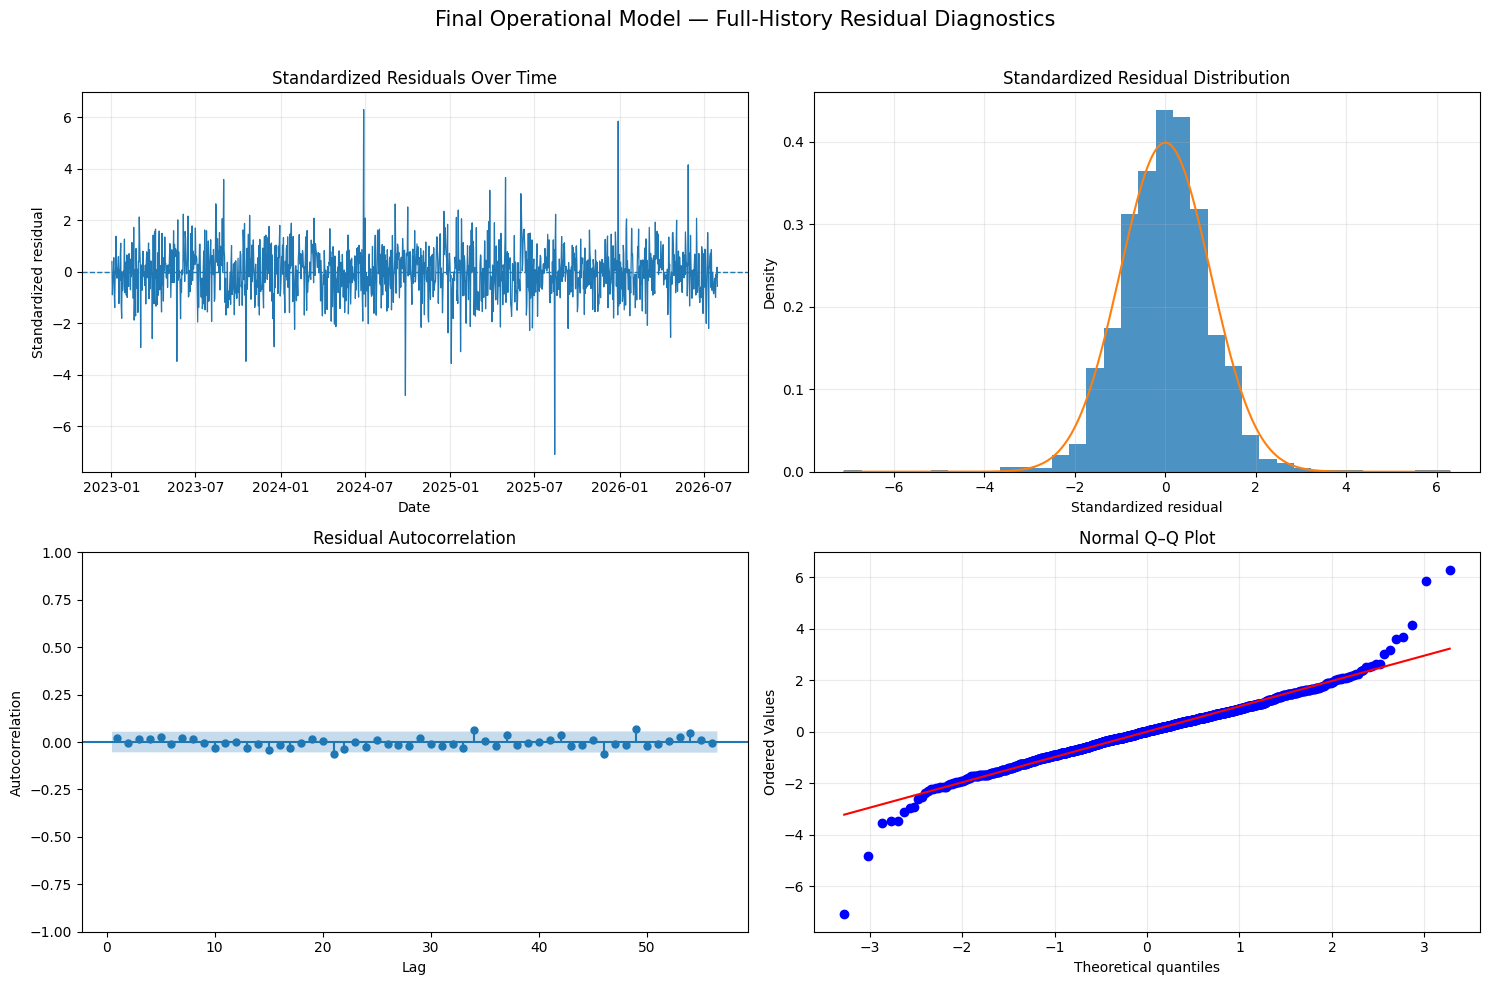

,check,observed,expected,status
0,final_model_registry_rows,2,2,PASS
1,complete_history_observations,1308,1308,PASS
2,complete_history_start,2023-01-01 00:00:00,2023-01-01 00:00:00,PASS
3,complete_history_end,2026-07-31 00:00:00,2026-07-31 00:00:00,PASS
4,final_fits_converged,2,2,PASS
5,minimum_ma_roots_above_1_05,True,True,PASS
6,all_ljung_box_tests_pass,True,True,PASS
7,primary_promotion_coefficient_positive,1.1634,> 0,PASS
8,primary_trend_coefficient_positive,0.3892,> 0,PASS
9,settlement_coefficient_positive,1.2798,> 0,PASS


,model_name,operational_role,selected_optimizer_attempt,observations,feature_count,parameter_count,converged,log_likelihood,aic,aicc,bic,residual_standard_deviation,standardized_residual_mean,standardized_residual_std,ma_coefficient,minimum_ma_root,time_trend_coefficient,promotion_coefficient,settlement_coefficient,all_ljung_box_tests_pass,fit_status
0,calendar_promotion_trend_arima011_errors,default_operational_model,initial_lbfgs,1308,12,14,True,"1,334.8311","-2,641.6621","-2,641.3373","-2,569.2053",0.0871,-0.0017,1.0006,-0.9155,1.0923,0.3892,1.1634,NaN,True,PASS
1,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,initial_lbfgs,1308,13,15,True,"1,399.0658","-2,768.1316","-2,767.7601","-2,690.4993",0.0830,-0.0016,1.0004,-0.9157,1.0921,0.3897,1.1655,1.2798,True,PASS


,model_name,attempt_name,optimizer,maxiter,fit_completed,converged,warning_count,warning_messages,log_likelihood,aic,bic,error_message,selected_attempt
0,calendar_promotion_trend_arima011_errors,initial_lbfgs,lbfgs,1000,True,True,0,,"1,334.8311","-2,641.6621","-2,569.2053",,True
1,calendar_promotion_settlement_trend_arima011_e...,initial_lbfgs,lbfgs,1000,True,True,0,,"1,399.0658","-2,768.1316","-2,690.4993",,True


,model_name,operational_role,parameter_name,parameter_role,estimate,standard_error,z_statistic,p_value,confidence_interval_lower,confidence_interval_upper
0,calendar_promotion_trend_arima011_errors,default_operational_model,is_month_end,exogenous_regressor,0.1757,0.0121,14.5041,0.0000,0.1520,0.1994
1,calendar_promotion_trend_arima011_errors,default_operational_model,is_holiday,exogenous_regressor,-0.1330,0.0134,-9.9306,0.0000,-0.1593,-0.1068
2,calendar_promotion_trend_arima011_errors,default_operational_model,is_payday,exogenous_regressor,-0.0005,0.0109,-0.0470,0.9625,-0.0219,0.0209
3,calendar_promotion_trend_arima011_errors,default_operational_model,is_payday_window,exogenous_regressor,0.2413,0.0074,32.7469,0.0000,0.2268,0.2557
4,calendar_promotion_trend_arima011_errors,default_operational_model,promotion_intensity,exogenous_regressor,1.1634,0.1406,8.2758,0.0000,0.8879,1.4390
5,calendar_promotion_trend_arima011_errors,default_operational_model,time_index_years,exogenous_regressor,0.3892,0.0773,5.0350,0.0000,0.2377,0.5407
6,calendar_promotion_trend_arima011_errors,default_operational_model,ma.L1,error_model_parameter,-0.9155,0.0121,-75.6977,0.0000,-0.9392,-0.8918
7,calendar_promotion_trend_arima011_errors,default_operational_model,sigma2,innovation_variance,0.0076,0.0002,41.6904,0.0000,0.0072,0.0079
8,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,is_month_end,exogenous_regressor,0.1603,0.0144,11.1115,0.0000,0.1320,0.1885
9,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,is_holiday,exogenous_regressor,-0.1303,0.0122,-10.6470,0.0000,-0.1543,-0.1063


,model_name,operational_role,diagnostic,lag,statistic,p_value,significance_level,passes_residual_whiteness,residual_observations
0,calendar_promotion_trend_arima011_errors,default_operational_model,ljung_box,7,2.8666,0.8254,0.0500,True,1307
1,calendar_promotion_trend_arima011_errors,default_operational_model,ljung_box,14,5.8666,0.9509,0.0500,True,1307
2,calendar_promotion_trend_arima011_errors,default_operational_model,ljung_box,21,15.1994,0.7649,0.0500,True,1307
3,calendar_promotion_trend_arima011_errors,default_operational_model,ljung_box,28,18.7351,0.8795,0.0500,True,1307
4,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,ljung_box,7,3.1346,0.7918,0.0500,True,1307
5,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,ljung_box,14,4.7819,0.9797,0.0500,True,1307
6,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,ljung_box,21,19.1016,0.5152,0.0500,True,1307
7,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,ljung_box,28,22.8693,0.6920,0.0500,True,1307


Final full-history models fitted: 2
Selected default model: calendar_promotion_trend_arima011_errors
History used: 2023-01-01 to 2026-07-31


In [48]:
# ============================================================================
# 30. Fit the final operational models on the complete available history
# ============================================================================

import warnings

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX


# ----------------------------------------------------------------------------
# Final model definitions
# ----------------------------------------------------------------------------

FINAL_LOG_TARGET_COLUMN = "log_total_cash_outflow"

FINAL_PRIMARY_FEATURES = [
    "dow_1",
    "dow_2",
    "dow_3",
    "dow_4",
    "dow_5",
    "dow_6",
    "is_month_end",
    "is_holiday",
    "is_payday",
    "is_payday_window",
    "promotion_intensity",
    "time_index_years",
]

FINAL_SETTLEMENT_FEATURES = [
    *FINAL_PRIMARY_FEATURES,
    "merchant_settlement_intensity",
]


final_full_history_model_registry = pd.DataFrame(
    [
        {
            "model_name": PRIMARY_MODEL_NAME,
            "specification_name": (
                "calendar_promotion_trend"
            ),
            "operational_role": (
                "default_operational_model"
            ),
            "order": "(0, 1, 1)",
            "trend": "n",
            "target_column": (
                FINAL_LOG_TARGET_COLUMN
            ),
            "feature_count": len(
                FINAL_PRIMARY_FEATURES
            ),
            "feature_list": " | ".join(
                FINAL_PRIMARY_FEATURES
            ),
            "promotion_schedule_required": True,
            "settlement_schedule_required": False,
            "validation_status": "VALIDATED",
        },
        {
            "model_name": SETTLEMENT_MODEL_NAME,
            "specification_name": (
                "calendar_promotion_settlement_trend"
            ),
            "operational_role": (
                "conditional_event_aware_variant"
            ),
            "order": "(0, 1, 1)",
            "trend": "n",
            "target_column": (
                FINAL_LOG_TARGET_COLUMN
            ),
            "feature_count": len(
                FINAL_SETTLEMENT_FEATURES
            ),
            "feature_list": " | ".join(
                FINAL_SETTLEMENT_FEATURES
            ),
            "promotion_schedule_required": True,
            "settlement_schedule_required": True,
            "validation_status": (
                "VALIDATED_WITH_LIMITED_EVENT_SUPPORT"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Validate and prepare the complete-history modeling table
# ----------------------------------------------------------------------------

required_final_columns = [
    DATE_COLUMN,
    FINAL_LOG_TARGET_COLUMN,
    *FINAL_SETTLEMENT_FEATURES,
]

missing_final_columns = [
    column
    for column in required_final_columns
    if column not in modeling_dataset_with_trend.columns
]

assert not missing_final_columns, (
    "Missing columns required for the final fit: "
    f"{missing_final_columns}"
)


final_fit_data = (
    modeling_dataset_with_trend[
        required_final_columns
    ]
    .copy()
)

final_fit_data[
    DATE_COLUMN
] = pd.to_datetime(
    final_fit_data[
        DATE_COLUMN
    ],
    errors="raise",
)

final_fit_data = (
    final_fit_data
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

assert len(final_fit_data) == 1308

assert final_fit_data[
    DATE_COLUMN
].is_unique

assert (
    final_fit_data[
        DATE_COLUMN
    ].min()
    == pd.Timestamp("2023-01-01")
)

assert (
    final_fit_data[
        DATE_COLUMN
    ].max()
    == pd.Timestamp("2026-07-31")
)

assert (
    final_fit_data
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    final_fit_data[
        [
            FINAL_LOG_TARGET_COLUMN,
            *FINAL_SETTLEMENT_FEATURES,
        ]
    ].to_numpy(dtype=float)
).all()


final_date_index = pd.DatetimeIndex(
    final_fit_data[
        DATE_COLUMN
    ],
    name=DATE_COLUMN,
)

final_endog = pd.Series(
    final_fit_data[
        FINAL_LOG_TARGET_COLUMN
    ].to_numpy(dtype=float),
    index=final_date_index,
    name=FINAL_LOG_TARGET_COLUMN,
)


# ----------------------------------------------------------------------------
# Robust optimizer helper
# ----------------------------------------------------------------------------

def fit_final_sarimax_with_fallback(
    endog,
    exog,
    model_name,
):
    """
    Fit SARIMAX with a deterministic optimizer fallback sequence.

    The sequence is:

    1. L-BFGS.
    2. Powell when the first fit does not converge.
    3. L-BFGS initialized from the Powell solution.
    """

    model = SARIMAX(
        endog=endog,
        exog=exog,
        order=(0, 1, 1),
        seasonal_order=(0, 0, 0, 0),
        trend="n",
        enforce_stationarity=True,
        enforce_invertibility=True,
        simple_differencing=False,
    )

    attempt_records = []
    fitted_results = {}


    def run_attempt(
        attempt_name,
        method,
        maxiter,
        start_params=None,
    ):

        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter("always")

            try:
                result = model.fit(
                    method=method,
                    maxiter=maxiter,
                    start_params=start_params,
                    disp=False,
                )

                convergence_info = getattr(
                    result,
                    "mle_retvals",
                    {},
                )

                converged = bool(
                    convergence_info.get(
                        "converged",
                        False,
                    )
                )

                warning_messages = [
                    str(
                        warning_item.message
                    )
                    for warning_item
                    in captured_warnings
                ]

                attempt_records.append(
                    {
                        "model_name": model_name,
                        "attempt_name": (
                            attempt_name
                        ),
                        "optimizer": method,
                        "maxiter": maxiter,
                        "fit_completed": True,
                        "converged": converged,
                        "warning_count": len(
                            warning_messages
                        ),
                        "warning_messages": (
                            " | ".join(
                                warning_messages
                            )
                        ),
                        "log_likelihood": float(
                            result.llf
                        ),
                        "aic": float(
                            result.aic
                        ),
                        "bic": float(
                            result.bic
                        ),
                        "error_message": "",
                    }
                )

                fitted_results[
                    attempt_name
                ] = result

                return result

            except Exception as error:

                warning_messages = [
                    str(
                        warning_item.message
                    )
                    for warning_item
                    in captured_warnings
                ]

                attempt_records.append(
                    {
                        "model_name": model_name,
                        "attempt_name": (
                            attempt_name
                        ),
                        "optimizer": method,
                        "maxiter": maxiter,
                        "fit_completed": False,
                        "converged": False,
                        "warning_count": len(
                            warning_messages
                        ),
                        "warning_messages": (
                            " | ".join(
                                warning_messages
                            )
                        ),
                        "log_likelihood": np.nan,
                        "aic": np.nan,
                        "bic": np.nan,
                        "error_message": str(
                            error
                        ),
                    }
                )

                return None


    initial_result = run_attempt(
        attempt_name="initial_lbfgs",
        method="lbfgs",
        maxiter=1000,
    )

    if (
        initial_result is not None
        and bool(
            initial_result.mle_retvals.get(
                "converged",
                False,
            )
        )
    ):
        return (
            initial_result,
            "initial_lbfgs",
            pd.DataFrame(
                attempt_records
            ),
        )


    powell_result = run_attempt(
        attempt_name="powell_fallback",
        method="powell",
        maxiter=2000,
    )

    if powell_result is not None:

        refined_result = run_attempt(
            attempt_name=(
                "lbfgs_initialized_from_powell"
            ),
            method="lbfgs",
            maxiter=2000,
            start_params=(
                powell_result.params
            ),
        )

        if (
            refined_result is not None
            and bool(
                refined_result.mle_retvals.get(
                    "converged",
                    False,
                )
            )
        ):
            return (
                refined_result,
                "lbfgs_initialized_from_powell",
                pd.DataFrame(
                    attempt_records
                ),
            )

        if bool(
            powell_result.mle_retvals.get(
                "converged",
                False,
            )
        ):
            return (
                powell_result,
                "powell_fallback",
                pd.DataFrame(
                    attempt_records
                ),
            )


    successful_attempts = {
        attempt_name: result
        for attempt_name, result
        in fitted_results.items()
        if result is not None
    }

    assert successful_attempts, (
        f"All fitting attempts failed for {model_name}."
    )

    selected_attempt_name = max(
        successful_attempts,
        key=lambda attempt_name: (
            successful_attempts[
                attempt_name
            ].llf
        ),
    )

    return (
        successful_attempts[
            selected_attempt_name
        ],
        selected_attempt_name,
        pd.DataFrame(
            attempt_records
        ),
    )


# ----------------------------------------------------------------------------
# Fit both complete-history specifications
# ----------------------------------------------------------------------------

final_model_definitions = {
    PRIMARY_MODEL_NAME: {
        "features": (
            FINAL_PRIMARY_FEATURES
        ),
        "operational_role": (
            "default_operational_model"
        ),
    },
    SETTLEMENT_MODEL_NAME: {
        "features": (
            FINAL_SETTLEMENT_FEATURES
        ),
        "operational_role": (
            "conditional_event_aware_variant"
        ),
    },
}


final_full_history_results = {}

fit_attempt_tables = []
fit_diagnostic_records = []
coefficient_records = []
residual_diagnostic_records = []
in_sample_records = []


for (
    model_name,
    model_definition,
) in final_model_definitions.items():

    feature_columns = (
        model_definition[
            "features"
        ]
    )

    final_exog = pd.DataFrame(
        final_fit_data[
            feature_columns
        ].to_numpy(dtype=float),
        index=final_date_index,
        columns=feature_columns,
    )

    assert np.linalg.matrix_rank(
        np.column_stack(
            [
                np.ones(
                    len(final_exog)
                ),
                final_exog.to_numpy(),
            ]
        )
    ) == (
        len(feature_columns)
        + 1
    ), (
        f"The final exogenous matrix is not full rank "
        f"for {model_name}."
    )


    (
        fitted_result,
        selected_attempt,
        attempt_table,
    ) = fit_final_sarimax_with_fallback(
        endog=final_endog,
        exog=final_exog,
        model_name=model_name,
    )

    final_full_history_results[
        model_name
    ] = fitted_result

    attempt_table[
        "selected_attempt"
    ] = (
        attempt_table[
            "attempt_name"
        ].eq(selected_attempt)
    )

    fit_attempt_tables.append(
        attempt_table
    )


    # ------------------------------------------------------------------------
    # Parameter estimates
    # ------------------------------------------------------------------------

    parameter_names = list(
        fitted_result.params.index
    )

    confidence_intervals = (
        fitted_result.conf_int(
            alpha=0.05
        )
    )

    for parameter_name in parameter_names:

        if parameter_name in feature_columns:
            parameter_role = (
                "exogenous_regressor"
            )

        elif parameter_name.startswith(
            "ma."
        ):
            parameter_role = (
                "error_model_parameter"
            )

        elif parameter_name == "sigma2":
            parameter_role = (
                "innovation_variance"
            )

        else:
            parameter_role = "other"

        coefficient_records.append(
            {
                "model_name": model_name,
                "operational_role": (
                    model_definition[
                        "operational_role"
                    ]
                ),
                "parameter_name": (
                    parameter_name
                ),
                "parameter_role": (
                    parameter_role
                ),
                "estimate": float(
                    fitted_result.params.loc[
                        parameter_name
                    ]
                ),
                "standard_error": float(
                    fitted_result.bse.loc[
                        parameter_name
                    ]
                ),
                "z_statistic": float(
                    fitted_result.zvalues.loc[
                        parameter_name
                    ]
                ),
                "p_value": float(
                    fitted_result.pvalues.loc[
                        parameter_name
                    ]
                ),
                "confidence_interval_lower": float(
                    confidence_intervals.loc[
                        parameter_name
                    ].iloc[0]
                ),
                "confidence_interval_upper": float(
                    confidence_intervals.loc[
                        parameter_name
                    ].iloc[1]
                ),
            }
        )


    # ------------------------------------------------------------------------
    # Residual diagnostics
    # ------------------------------------------------------------------------

    likelihood_burn = max(
        int(
            getattr(
                fitted_result,
                "loglikelihood_burn",
                0,
            )
        ),
        1,
    )

    raw_residuals = np.asarray(
        fitted_result.resid,
        dtype=float,
    )

    standardized_residuals = np.asarray(
        fitted_result.filter_results
        .standardized_forecasts_error[0],
        dtype=float,
    )

    valid_residual_mask = (
        np.arange(
            len(raw_residuals)
        )
        >= likelihood_burn
    )

    valid_residual_mask &= (
        np.isfinite(
            raw_residuals
        )
        & np.isfinite(
            standardized_residuals
        )
    )

    diagnostic_raw_residuals = (
        raw_residuals[
            valid_residual_mask
        ]
    )

    diagnostic_standardized_residuals = (
        standardized_residuals[
            valid_residual_mask
        ]
    )


    ljung_box_results = acorr_ljungbox(
        diagnostic_standardized_residuals,
        lags=[
            7,
            14,
            21,
            28,
        ],
        model_df=1,
        return_df=True,
    )

    for lag in [
        7,
        14,
        21,
        28,
    ]:

        lag_p_value = float(
            ljung_box_results.loc[
                lag,
                "lb_pvalue",
            ]
        )

        residual_diagnostic_records.append(
            {
                "model_name": model_name,
                "operational_role": (
                    model_definition[
                        "operational_role"
                    ]
                ),
                "diagnostic": (
                    "ljung_box"
                ),
                "lag": lag,
                "statistic": float(
                    ljung_box_results.loc[
                        lag,
                        "lb_stat",
                    ]
                ),
                "p_value": lag_p_value,
                "significance_level": 0.05,
                "passes_residual_whiteness": bool(
                    lag_p_value > 0.05
                ),
                "residual_observations": len(
                    diagnostic_standardized_residuals
                ),
            }
        )


    # ------------------------------------------------------------------------
    # Fit-level summary
    # ------------------------------------------------------------------------

    convergence_information = getattr(
        fitted_result,
        "mle_retvals",
        {},
    )

    converged = bool(
        convergence_information.get(
            "converged",
            False,
        )
    )

    parameter_count = len(
        fitted_result.params
    )

    fitted_observations = int(
        fitted_result.nobs
    )

    if (
        fitted_observations
        > parameter_count + 1
    ):
        aicc = float(
            fitted_result.aic
            + (
                2
                * parameter_count
                * (
                    parameter_count
                    + 1
                )
            )
            / (
                fitted_observations
                - parameter_count
                - 1
            )
        )

    else:
        aicc = np.nan


    ma_roots = np.asarray(
        fitted_result.maroots,
        dtype=complex,
    )

    minimum_ma_root = (
        float(
            np.min(
                np.abs(
                    ma_roots
                )
            )
        )
        if len(ma_roots) > 0
        else np.nan
    )


    all_ljung_box_tests_pass = bool(
        ljung_box_results[
            "lb_pvalue"
        ]
        .gt(0.05)
        .all()
    )


    fit_diagnostic_records.append(
        {
            "model_name": model_name,
            "operational_role": (
                model_definition[
                    "operational_role"
                ]
            ),
            "selected_optimizer_attempt": (
                selected_attempt
            ),
            "observations": (
                fitted_observations
            ),
            "feature_count": len(
                feature_columns
            ),
            "parameter_count": (
                parameter_count
            ),
            "converged": converged,
            "log_likelihood": float(
                fitted_result.llf
            ),
            "aic": float(
                fitted_result.aic
            ),
            "aicc": aicc,
            "bic": float(
                fitted_result.bic
            ),
            "residual_standard_deviation": float(
                np.std(
                    diagnostic_raw_residuals,
                    ddof=1,
                )
            ),
            "standardized_residual_mean": float(
                np.mean(
                    diagnostic_standardized_residuals
                )
            ),
            "standardized_residual_std": float(
                np.std(
                    diagnostic_standardized_residuals,
                    ddof=1,
                )
            ),
            "ma_coefficient": float(
                fitted_result.params.get(
                    "ma.L1",
                    np.nan,
                )
            ),
            "minimum_ma_root": (
                minimum_ma_root
            ),
            "time_trend_coefficient": float(
                fitted_result.params.get(
                    "time_index_years",
                    np.nan,
                )
            ),
            "promotion_coefficient": float(
                fitted_result.params.get(
                    "promotion_intensity",
                    np.nan,
                )
            ),
            "settlement_coefficient": float(
                fitted_result.params.get(
                    "merchant_settlement_intensity",
                    np.nan,
                )
            ),
            "all_ljung_box_tests_pass": (
                all_ljung_box_tests_pass
            ),
            "fit_status": (
                "PASS"
                if (
                    converged
                    and minimum_ma_root > 1.05
                    and all_ljung_box_tests_pass
                )
                else "REVIEW"
            ),
        }
    )


    # ------------------------------------------------------------------------
    # Save fitted values and residuals
    # ------------------------------------------------------------------------

    fitted_log_values = np.asarray(
        fitted_result.fittedvalues,
        dtype=float,
    )

    for row_index, row_date in enumerate(
        final_date_index
    ):

        in_sample_records.append(
            {
                "model_name": model_name,
                "operational_role": (
                    model_definition[
                        "operational_role"
                    ]
                ),
                "date": row_date,
                "actual_log_target": float(
                    final_endog.iloc[
                        row_index
                    ]
                ),
                "fitted_log_target": float(
                    fitted_log_values[
                        row_index
                    ]
                ),
                "raw_residual": float(
                    raw_residuals[
                        row_index
                    ]
                ),
                "standardized_residual": float(
                    standardized_residuals[
                        row_index
                    ]
                ),
                "likelihood_burn": (
                    likelihood_burn
                ),
                "included_in_residual_diagnostics": bool(
                    valid_residual_mask[
                        row_index
                    ]
                ),
            }
        )


# ----------------------------------------------------------------------------
# Consolidate result tables
# ----------------------------------------------------------------------------

final_full_history_fit_attempts = (
    pd.concat(
        fit_attempt_tables,
        ignore_index=True,
    )
)

final_full_history_fit_diagnostics = (
    pd.DataFrame(
        fit_diagnostic_records
    )
)

final_full_history_coefficients = (
    pd.DataFrame(
        coefficient_records
    )
)

final_full_history_residual_diagnostics = (
    pd.DataFrame(
        residual_diagnostic_records
    )
)

final_full_history_in_sample_diagnostics = (
    pd.DataFrame(
        in_sample_records
    )
)


# ----------------------------------------------------------------------------
# Final-fit audit
# ----------------------------------------------------------------------------

primary_final_diagnostics = (
    final_full_history_fit_diagnostics.loc[
        final_full_history_fit_diagnostics[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
    .iloc[0]
)

settlement_final_diagnostics = (
    final_full_history_fit_diagnostics.loc[
        final_full_history_fit_diagnostics[
            "model_name"
        ].eq(SETTLEMENT_MODEL_NAME)
    ]
    .iloc[0]
)


final_full_history_fit_audit = pd.DataFrame(
    [
        {
            "check": "final_model_registry_rows",
            "observed": len(
                final_full_history_model_registry
            ),
            "expected": 2,
            "status": (
                "PASS"
                if len(
                    final_full_history_model_registry
                ) == 2
                else "FAIL"
            ),
        },
        {
            "check": "complete_history_observations",
            "observed": len(
                final_fit_data
            ),
            "expected": 1308,
            "status": (
                "PASS"
                if len(
                    final_fit_data
                ) == 1308
                else "FAIL"
            ),
        },
        {
            "check": "complete_history_start",
            "observed": (
                final_fit_data[
                    DATE_COLUMN
                ].min()
            ),
            "expected": (
                pd.Timestamp(
                    "2023-01-01"
                )
            ),
            "status": (
                "PASS"
                if final_fit_data[
                    DATE_COLUMN
                ].min()
                == pd.Timestamp(
                    "2023-01-01"
                )
                else "FAIL"
            ),
        },
        {
            "check": "complete_history_end",
            "observed": (
                final_fit_data[
                    DATE_COLUMN
                ].max()
            ),
            "expected": (
                pd.Timestamp(
                    "2026-07-31"
                )
            ),
            "status": (
                "PASS"
                if final_fit_data[
                    DATE_COLUMN
                ].max()
                == pd.Timestamp(
                    "2026-07-31"
                )
                else "FAIL"
            ),
        },
        {
            "check": "final_fits_converged",
            "observed": int(
                final_full_history_fit_diagnostics[
                    "converged"
                ].sum()
            ),
            "expected": 2,
            "status": (
                "PASS"
                if final_full_history_fit_diagnostics[
                    "converged"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": "minimum_ma_roots_above_1_05",
            "observed": bool(
                final_full_history_fit_diagnostics[
                    "minimum_ma_root"
                ]
                .gt(1.05)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_full_history_fit_diagnostics[
                    "minimum_ma_root"
                ]
                .gt(1.05)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "all_ljung_box_tests_pass",
            "observed": bool(
                final_full_history_fit_diagnostics[
                    "all_ljung_box_tests_pass"
                ]
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_full_history_fit_diagnostics[
                    "all_ljung_box_tests_pass"
                ]
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "primary_promotion_coefficient_positive",
            "observed": float(
                primary_final_diagnostics[
                    "promotion_coefficient"
                ]
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if float(
                    primary_final_diagnostics[
                        "promotion_coefficient"
                    ]
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": "primary_trend_coefficient_positive",
            "observed": float(
                primary_final_diagnostics[
                    "time_trend_coefficient"
                ]
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if float(
                    primary_final_diagnostics[
                        "time_trend_coefficient"
                    ]
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": "settlement_coefficient_positive",
            "observed": float(
                settlement_final_diagnostics[
                    "settlement_coefficient"
                ]
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if float(
                    settlement_final_diagnostics[
                        "settlement_coefficient"
                    ]
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": "all_parameter_estimates_finite",
            "observed": bool(
                np.isfinite(
                    final_full_history_coefficients[
                        [
                            "estimate",
                            "standard_error",
                            "z_statistic",
                            "p_value",
                            "confidence_interval_lower",
                            "confidence_interval_upper",
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    final_full_history_coefficients[
                        [
                            "estimate",
                            "standard_error",
                            "z_statistic",
                            "p_value",
                            "confidence_interval_lower",
                            "confidence_interval_upper",
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "selected_model_matches_final_decision",
            "observed": (
                final_model_selection_decision[
                    "selected_model_name"
                ].iloc[0]
            ),
            "expected": PRIMARY_MODEL_NAME,
            "status": (
                "PASS"
                if final_model_selection_decision[
                    "selected_model_name"
                ].iloc[0]
                == PRIMARY_MODEL_NAME
                else "FAIL"
            ),
        },
        {
            "check": "in_sample_diagnostic_rows",
            "observed": len(
                final_full_history_in_sample_diagnostics
            ),
            "expected": (
                2
                * len(
                    final_fit_data
                )
            ),
            "status": (
                "PASS"
                if len(
                    final_full_history_in_sample_diagnostics
                )
                == (
                    2
                    * len(
                        final_fit_data
                    )
                )
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save all tables
# ----------------------------------------------------------------------------

FINAL_FULL_HISTORY_MODEL_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_model_registry.csv"
    )
)

FINAL_FULL_HISTORY_FIT_ATTEMPTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_fit_attempts.csv"
    )
)

FINAL_FULL_HISTORY_FIT_DIAGNOSTICS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_fit_diagnostics.csv"
    )
)

FINAL_FULL_HISTORY_COEFFICIENTS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_coefficients.csv"
    )
)

FINAL_FULL_HISTORY_RESIDUAL_DIAGNOSTICS_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_residual_diagnostics.csv"
    )
)

FINAL_FULL_HISTORY_IN_SAMPLE_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_in_sample_diagnostics.csv"
    )
)

FINAL_FULL_HISTORY_FIT_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_full_history_fit_audit.csv"
    )
)


final_full_history_model_registry.to_csv(
    FINAL_FULL_HISTORY_MODEL_REGISTRY_PATH,
    index=False,
)

final_full_history_fit_attempts.to_csv(
    FINAL_FULL_HISTORY_FIT_ATTEMPTS_PATH,
    index=False,
)

final_full_history_fit_diagnostics.to_csv(
    FINAL_FULL_HISTORY_FIT_DIAGNOSTICS_PATH,
    index=False,
)

final_full_history_coefficients.to_csv(
    FINAL_FULL_HISTORY_COEFFICIENTS_PATH,
    index=False,
)

final_full_history_residual_diagnostics.to_csv(
    FINAL_FULL_HISTORY_RESIDUAL_DIAGNOSTICS_PATH,
    index=False,
)

final_full_history_in_sample_diagnostics.to_csv(
    FINAL_FULL_HISTORY_IN_SAMPLE_PATH,
    index=False,
)

final_full_history_fit_audit.to_csv(
    FINAL_FULL_HISTORY_FIT_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Residual-diagnostic figure for the selected default model
# ----------------------------------------------------------------------------

primary_result = (
    final_full_history_results[
        PRIMARY_MODEL_NAME
    ]
)

primary_in_sample = (
    final_full_history_in_sample_diagnostics.loc[
        final_full_history_in_sample_diagnostics[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
        & final_full_history_in_sample_diagnostics[
            "included_in_residual_diagnostics"
        ]
    ]
    .copy()
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 10),
)


axes[0, 0].plot(
    primary_in_sample["date"],
    primary_in_sample[
        "standardized_residual"
    ],
    linewidth=0.9,
)

axes[0, 0].axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

axes[0, 0].set_title(
    "Standardized Residuals Over Time"
)

axes[0, 0].set_xlabel("Date")

axes[0, 0].set_ylabel(
    "Standardized residual"
)

axes[0, 0].grid(alpha=0.25)


axes[0, 1].hist(
    primary_in_sample[
        "standardized_residual"
    ],
    bins=35,
    density=True,
    alpha=0.8,
)

residual_grid = np.linspace(
    primary_in_sample[
        "standardized_residual"
    ].min(),
    primary_in_sample[
        "standardized_residual"
    ].max(),
    300,
)

axes[0, 1].plot(
    residual_grid,
    stats.norm.pdf(
        residual_grid,
        loc=0.0,
        scale=1.0,
    ),
)

axes[0, 1].set_title(
    "Standardized Residual Distribution"
)

axes[0, 1].set_xlabel(
    "Standardized residual"
)

axes[0, 1].set_ylabel(
    "Density"
)

axes[0, 1].grid(alpha=0.25)


plot_acf(
    primary_in_sample[
        "standardized_residual"
    ],
    lags=56,
    zero=False,
    ax=axes[1, 0],
)

axes[1, 0].set_title(
    "Residual Autocorrelation"
)

axes[1, 0].set_xlabel("Lag")

axes[1, 0].set_ylabel(
    "Autocorrelation"
)


stats.probplot(
    primary_in_sample[
        "standardized_residual"
    ],
    dist="norm",
    plot=axes[1, 1],
)

axes[1, 1].set_title(
    "Normal Q–Q Plot"
)

axes[1, 1].grid(alpha=0.25)


fig.suptitle(
    "Final Operational Model — Full-History Residual Diagnostics",
    fontsize=15,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)


FINAL_OPERATIONAL_RESIDUAL_FIGURE_PATH = (
    FIGURES_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_operational_model_residual_diagnostics.png"
    )
)

fig.savefig(
    FINAL_OPERATIONAL_RESIDUAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------------------
# Verify outputs
# ----------------------------------------------------------------------------

for output_path in [
    FINAL_FULL_HISTORY_MODEL_REGISTRY_PATH,
    FINAL_FULL_HISTORY_FIT_ATTEMPTS_PATH,
    FINAL_FULL_HISTORY_FIT_DIAGNOSTICS_PATH,
    FINAL_FULL_HISTORY_COEFFICIENTS_PATH,
    FINAL_FULL_HISTORY_RESIDUAL_DIAGNOSTICS_PATH,
    FINAL_FULL_HISTORY_IN_SAMPLE_PATH,
    FINAL_FULL_HISTORY_FIT_AUDIT_PATH,
    FINAL_OPERATIONAL_RESIDUAL_FIGURE_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: "
        f"{output_path}"
    )


assert final_full_history_fit_audit[
    "status"
].eq("PASS").all(), (
    "The complete-history final-fit audit "
    "failed at least one check."
)


# ----------------------------------------------------------------------------
# Display outputs required for review
# ----------------------------------------------------------------------------

display(
    final_full_history_fit_audit
)

display(
    final_full_history_fit_diagnostics
)

display(
    final_full_history_fit_attempts
)

display(
    final_full_history_coefficients.loc[
        final_full_history_coefficients[
            "parameter_name"
        ].isin(
            [
                "time_index_years",
                "promotion_intensity",
                "merchant_settlement_intensity",
                "is_payday",
                "is_payday_window",
                "is_holiday",
                "is_month_end",
                "ma.L1",
                "sigma2",
            ]
        )
    ]
    .reset_index(drop=True)
)

display(
    final_full_history_residual_diagnostics
)

print(
    "Final full-history models fitted: "
    f"{len(final_full_history_results)}"
)

print(
    "Selected default model: "
    f"{PRIMARY_MODEL_NAME}"
)

print(
    "History used: "
    f"{final_fit_data[DATE_COLUMN].min().date()} "
    f"to "
    f"{final_fit_data[DATE_COLUMN].max().date()}"
)

## 29. Residual-distribution guardrail

The final full-history residuals show no meaningful remaining
autocorrelation, but residual whiteness does not imply Gaussianity.

The standardized residual distribution is therefore evaluated using:

- Sample skewness.
- Excess kurtosis.
- Jarque–Bera normality test.
- Counts of residuals exceeding three, four and five standard deviations.

This diagnostic does not alter the validated point-forecast model selection.

Non-Gaussian tails are recorded as a guardrail for the later uncertainty
modeling stage. Prediction intervals and liquidity-risk estimates should not
rely exclusively on unadjusted Gaussian residual assumptions.

In [49]:
# ============================================================================
# 31. Quantify the final residual-distribution guardrail
# ============================================================================

from scipy import stats


# ----------------------------------------------------------------------------
# Validate required inputs
# ----------------------------------------------------------------------------

required_residual_objects = [
    "final_full_history_in_sample_diagnostics",
    "final_full_history_fit_diagnostics",
    "final_fit_data",
]

missing_residual_objects = [
    object_name
    for object_name in required_residual_objects
    if object_name not in globals()
]

assert not missing_residual_objects, (
    "Missing required residual-diagnostic objects: "
    f"{missing_residual_objects}"
)


# ----------------------------------------------------------------------------
# Calculate distribution diagnostics for both final models
# ----------------------------------------------------------------------------

residual_distribution_records = []

for model_name, model_data in (
    final_full_history_in_sample_diagnostics.loc[
        final_full_history_in_sample_diagnostics[
            "included_in_residual_diagnostics"
        ]
    ]
    .groupby("model_name")
):

    standardized_residuals = (
        model_data[
            "standardized_residual"
        ]
        .to_numpy(dtype=float)
    )

    assert len(
        standardized_residuals
    ) > 0

    assert np.isfinite(
        standardized_residuals
    ).all()

    jarque_bera_result = (
        stats.jarque_bera(
            standardized_residuals
        )
    )

    skewness = float(
        stats.skew(
            standardized_residuals,
            bias=False,
        )
    )

    excess_kurtosis = float(
        stats.kurtosis(
            standardized_residuals,
            fisher=True,
            bias=False,
        )
    )

    jarque_bera_statistic = float(
        jarque_bera_result.statistic
    )

    jarque_bera_p_value = float(
        jarque_bera_result.pvalue
    )

    approximately_gaussian = bool(
        jarque_bera_p_value >= 0.05
        and abs(skewness) < 0.50
        and abs(excess_kurtosis) < 1.00
    )

    if approximately_gaussian:
        distribution_status = (
            "APPROXIMATELY_GAUSSIAN"
        )

        uncertainty_guardrail = (
            "Gaussian residual assumptions are not rejected by "
            "the recorded diagnostics, but empirical interval "
            "calibration remains preferred."
        )

    else:
        distribution_status = (
            "NON_GAUSSIAN_TAILS_RECORDED"
        )

        uncertainty_guardrail = (
            "Do not rely exclusively on unadjusted Gaussian "
            "residual assumptions. Evaluate empirical, bootstrap "
            "or simulation-based uncertainty calibration in the "
            "probabilistic forecasting stage."
        )

    operational_role = (
        model_data[
            "operational_role"
        ].iloc[0]
    )

    residual_distribution_records.append(
        {
            "model_name": model_name,
            "operational_role": operational_role,
            "residual_observations": len(
                standardized_residuals
            ),
            "residual_mean": float(
                np.mean(
                    standardized_residuals
                )
            ),
            "residual_standard_deviation": float(
                np.std(
                    standardized_residuals,
                    ddof=1,
                )
            ),
            "minimum_residual": float(
                np.min(
                    standardized_residuals
                )
            ),
            "maximum_residual": float(
                np.max(
                    standardized_residuals
                )
            ),
            "skewness": skewness,
            "excess_kurtosis": (
                excess_kurtosis
            ),
            "jarque_bera_statistic": (
                jarque_bera_statistic
            ),
            "jarque_bera_p_value": (
                jarque_bera_p_value
            ),
            "absolute_residuals_above_3": int(
                np.abs(
                    standardized_residuals
                ).gt(3).sum()
                if isinstance(
                    standardized_residuals,
                    pd.Series,
                )
                else np.sum(
                    np.abs(
                        standardized_residuals
                    ) > 3
                )
            ),
            "absolute_residuals_above_4": int(
                np.sum(
                    np.abs(
                        standardized_residuals
                    ) > 4
                )
            ),
            "absolute_residuals_above_5": int(
                np.sum(
                    np.abs(
                        standardized_residuals
                    ) > 5
                )
            ),
            "approximately_gaussian": (
                approximately_gaussian
            ),
            "distribution_status": (
                distribution_status
            ),
            "point_model_selection_implication": (
                "NO_CHANGE"
            ),
            "uncertainty_modeling_guardrail": (
                uncertainty_guardrail
            ),
        }
    )


final_residual_distribution_diagnostics = (
    pd.DataFrame(
        residual_distribution_records
    )
    .sort_values(
        "model_name"
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------------
# Guardrail audit
# ----------------------------------------------------------------------------

expected_residual_observations = (
    len(final_fit_data) - 1
)

primary_distribution_row = (
    final_residual_distribution_diagnostics.loc[
        final_residual_distribution_diagnostics[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
)

final_residual_distribution_audit = pd.DataFrame(
    [
        {
            "check": "distribution_diagnostic_rows",
            "observed": len(
                final_residual_distribution_diagnostics
            ),
            "expected": 2,
            "status": (
                "PASS"
                if len(
                    final_residual_distribution_diagnostics
                ) == 2
                else "FAIL"
            ),
        },
        {
            "check": "primary_model_distribution_recorded",
            "observed": len(
                primary_distribution_row
            ),
            "expected": 1,
            "status": (
                "PASS"
                if len(
                    primary_distribution_row
                ) == 1
                else "FAIL"
            ),
        },
        {
            "check": "residual_observations_per_model",
            "observed": bool(
                final_residual_distribution_diagnostics[
                    "residual_observations"
                ]
                .eq(
                    expected_residual_observations
                )
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_residual_distribution_diagnostics[
                    "residual_observations"
                ]
                .eq(
                    expected_residual_observations
                )
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "distribution_metrics_finite",
            "observed": bool(
                np.isfinite(
                    final_residual_distribution_diagnostics[
                        [
                            "residual_mean",
                            "residual_standard_deviation",
                            "minimum_residual",
                            "maximum_residual",
                            "skewness",
                            "excess_kurtosis",
                            "jarque_bera_statistic",
                            "jarque_bera_p_value",
                        ]
                    ].to_numpy(dtype=float)
                ).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if np.isfinite(
                    final_residual_distribution_diagnostics[
                        [
                            "residual_mean",
                            "residual_standard_deviation",
                            "minimum_residual",
                            "maximum_residual",
                            "skewness",
                            "excess_kurtosis",
                            "jarque_bera_statistic",
                            "jarque_bera_p_value",
                        ]
                    ].to_numpy(dtype=float)
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "distribution_status_recorded",
            "observed": bool(
                final_residual_distribution_diagnostics[
                    "distribution_status"
                ]
                .notna()
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_residual_distribution_diagnostics[
                    "distribution_status"
                ]
                .notna()
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "point_model_selection_unchanged",
            "observed": bool(
                final_residual_distribution_diagnostics[
                    "point_model_selection_implication"
                ]
                .eq("NO_CHANGE")
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_residual_distribution_diagnostics[
                    "point_model_selection_implication"
                ]
                .eq("NO_CHANGE")
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "uncertainty_guardrail_recorded",
            "observed": bool(
                final_residual_distribution_diagnostics[
                    "uncertainty_modeling_guardrail"
                ]
                .str.len()
                .gt(0)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_residual_distribution_diagnostics[
                    "uncertainty_modeling_guardrail"
                ]
                .str.len()
                .gt(0)
                .all()
                else "FAIL"
            ),
        },
    ]
)


# ----------------------------------------------------------------------------
# Save generated tables
# ----------------------------------------------------------------------------

FINAL_RESIDUAL_DISTRIBUTION_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_residual_distribution_diagnostics.csv"
    )
)

FINAL_RESIDUAL_DISTRIBUTION_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "final_residual_distribution_audit.csv"
    )
)


final_residual_distribution_diagnostics.to_csv(
    FINAL_RESIDUAL_DISTRIBUTION_PATH,
    index=False,
)

final_residual_distribution_audit.to_csv(
    FINAL_RESIDUAL_DISTRIBUTION_AUDIT_PATH,
    index=False,
)


for output_path in [
    FINAL_RESIDUAL_DISTRIBUTION_PATH,
    FINAL_RESIDUAL_DISTRIBUTION_AUDIT_PATH,
]:
    assert output_path.exists(), (
        f"Output was not created: {output_path}"
    )


assert final_residual_distribution_audit[
    "status"
].eq("PASS").all(), (
    "The residual-distribution guardrail "
    "failed at least one structural check."
)


# ----------------------------------------------------------------------------
# Display results
# ----------------------------------------------------------------------------

display(
    final_residual_distribution_audit
)

display(
    final_residual_distribution_diagnostics[
        [
            "model_name",
            "operational_role",
            "residual_observations",
            "residual_mean",
            "residual_standard_deviation",
            "minimum_residual",
            "maximum_residual",
            "skewness",
            "excess_kurtosis",
            "jarque_bera_statistic",
            "jarque_bera_p_value",
            "absolute_residuals_above_3",
            "absolute_residuals_above_4",
            "absolute_residuals_above_5",
            "approximately_gaussian",
            "distribution_status",
            "point_model_selection_implication",
        ]
    ]
)

,check,observed,expected,status
0,distribution_diagnostic_rows,2,2,PASS
1,primary_model_distribution_recorded,1,1,PASS
2,residual_observations_per_model,True,True,PASS
3,distribution_metrics_finite,True,True,PASS
4,distribution_status_recorded,True,True,PASS
5,point_model_selection_unchanged,True,True,PASS
6,uncertainty_guardrail_recorded,True,True,PASS


,model_name,operational_role,residual_observations,residual_mean,residual_standard_deviation,minimum_residual,maximum_residual,skewness,excess_kurtosis,jarque_bera_statistic,jarque_bera_p_value,absolute_residuals_above_3,absolute_residuals_above_4,absolute_residuals_above_5,approximately_gaussian,distribution_status,point_model_selection_implication
0,calendar_promotion_settlement_trend_arima011_e...,conditional_event_aware_variant,1307,-0.0016,1.0004,-7.4511,3.3299,-0.4932,2.8843,501.0201,0.0000,10,2,2,False,NON_GAUSSIAN_TAILS_RECORDED,NO_CHANGE
1,calendar_promotion_trend_arima011_errors,default_operational_model,1307,-0.0017,1.0006,-7.0988,6.2904,0.0019,4.4513,"1,068.5804",0.0000,13,5,3,False,NON_GAUSSIAN_TAILS_RECORDED,NO_CHANGE


## 30. Notebook closure and artifact handoff

Notebook 04 closes after validating the dynamic-regression modeling workflow,
the operational model decision and all generated artifacts.

Within the models evaluated through Notebook 04, the current default
operational model is:

`calendar_promotion_trend_arima011_errors`

This selection is not yet the final project-wide model comparison. Notebook 05
will introduce LightGBM, and Notebook 06 will compare all validated models
under the same rolling-origin folds.

The closure audit verifies:

- Completion of all major modeling audits.
- Preservation of the selected operational policy.
- Reproducibility of the final full-history fits.
- Recording of the non-Gaussian residual-tail guardrail.
- Existence and readability of all required tables.
- Existence and readability of all required figures.
- Creation of a structured handoff for Notebook 05.

In [56]:
# ============================================================================
# 32. Close Notebook 04 and register all generated artifacts
# ============================================================================

from pathlib import Path


# ----------------------------------------------------------------------------
# Validate required closure objects
# ----------------------------------------------------------------------------

required_closure_objects = [
    "notebook03_reference_forecast_alignment_audit",
    "cross_notebook_comparison_audit",
    "horizon_comparison_audit",
    "condition_comparison_audit",
    "settlement_decision_audit",
    "final_model_selection_audit",
    "final_full_history_fit_audit",
    "final_residual_distribution_audit",
    "final_model_selection_decision",
    "operational_forecast_policy",
    "cross_notebook_aggregate_metrics",
    "cross_notebook_horizon_pairwise_summary",
    "cross_notebook_condition_registry",
    "final_full_history_fit_diagnostics",
    "final_residual_distribution_diagnostics",
]

missing_closure_objects = [
    object_name
    for object_name in required_closure_objects
    if object_name not in globals()
]

assert not missing_closure_objects, (
    "Missing objects required for Notebook 04 closure: "
    f"{missing_closure_objects}"
)


# ----------------------------------------------------------------------------
# Retrieve validated final rows
# ----------------------------------------------------------------------------

assert len(
    final_model_selection_decision
) == 1

selected_decision = (
    final_model_selection_decision
    .iloc[0]
)


primary_aggregate_metrics = (
    cross_notebook_aggregate_metrics.loc[
        cross_notebook_aggregate_metrics[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
)

assert len(
    primary_aggregate_metrics
) == 1

primary_aggregate_metrics = (
    primary_aggregate_metrics
    .iloc[0]
)


settlement_aggregate_metrics = (
    cross_notebook_aggregate_metrics.loc[
        cross_notebook_aggregate_metrics[
            "model_name"
        ].eq(SETTLEMENT_MODEL_NAME)
    ]
)

assert len(
    settlement_aggregate_metrics
) == 1

settlement_aggregate_metrics = (
    settlement_aggregate_metrics
    .iloc[0]
)


primary_final_fit = (
    final_full_history_fit_diagnostics.loc[
        final_full_history_fit_diagnostics[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
)

assert len(
    primary_final_fit
) == 1

primary_final_fit = (
    primary_final_fit
    .iloc[0]
)


primary_residual_distribution = (
    final_residual_distribution_diagnostics.loc[
        final_residual_distribution_diagnostics[
            "model_name"
        ].eq(PRIMARY_MODEL_NAME)
    ]
)

assert len(
    primary_residual_distribution
) == 1

primary_residual_distribution = (
    primary_residual_distribution
    .iloc[0]
)


fallback_policy_row = (
    operational_forecast_policy.loc[
        operational_forecast_policy[
            "operational_scenario"
        ].eq(
            "promotion_plan_unavailable_or_incomplete"
        )
    ]
)

assert len(
    fallback_policy_row
) == 1

fallback_policy_row = (
    fallback_policy_row
    .iloc[0]
)


# ----------------------------------------------------------------------------
# Notebook 04 final summary
# ----------------------------------------------------------------------------

notebook04_final_summary = pd.DataFrame(
    [
        {
            "notebook_id": "04",
            "notebook_name": (
                "dynamic_regression_and_sarimax"
            ),
            "notebook_status": (
                "VALIDATED_AND_CLOSED"
            ),
            "selection_scope": (
                "current_operational_default_among_models_"
                "evaluated_through_notebook04"
            ),
            "project_wide_model_selection_status": (
                "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
            "history_start": pd.Timestamp(
                "2023-01-01"
            ),
            "history_end": pd.Timestamp(
                "2026-07-31"
            ),
            "history_observations": 1308,
            "rolling_origin_folds": (
                N_FOLDS
            ),
            "forecast_horizon_days": (
                FORECAST_HORIZON
            ),
            "out_of_sample_predictions_per_model": (
                N_FOLDS
                * FORECAST_HORIZON
            ),
            "selected_operational_model": (
                PRIMARY_MODEL_NAME
            ),
            "selected_specification": (
                selected_decision[
                    "selected_specification_name"
                ]
            ),
            "selected_error_model": (
                selected_decision[
                    "selected_error_model"
                ]
            ),
            "selected_order": (
                selected_decision[
                    "selected_order"
                ]
            ),
            "point_forecast_transformation": (
                selected_decision[
                    "point_forecast_transformation"
                ]
            ),
            "out_of_sample_mae": float(
                primary_aggregate_metrics[
                    "mae"
                ]
            ),
            "out_of_sample_rmse": float(
                primary_aggregate_metrics[
                    "rmse"
                ]
            ),
            "out_of_sample_mean_error": float(
                primary_aggregate_metrics[
                    "mean_error"
                ]
            ),
            "out_of_sample_bias_pct": float(
                primary_aggregate_metrics[
                    "bias_pct"
                ]
            ),
            "mae_improvement_pct_vs_ets": float(
                selected_decision[
                    "mae_improvement_pct_vs_ets"
                ]
            ),
            "rmse_improvement_pct_vs_ets": float(
                selected_decision[
                    "rmse_improvement_pct_vs_ets"
                ]
            ),
            "mae_improvement_pct_vs_benchmark": float(
                selected_decision[
                    "mae_improvement_pct_vs_benchmark"
                ]
            ),
            "rmse_improvement_pct_vs_benchmark": float(
                selected_decision[
                    "rmse_improvement_pct_vs_benchmark"
                ]
            ),
            "horizons_with_mae_improvement_vs_ets": int(
                selected_decision[
                    "horizons_with_mae_improvement_vs_ets"
                ]
            ),
            "horizons_with_rmse_improvement_vs_ets": int(
                selected_decision[
                    "horizons_with_rmse_improvement_vs_ets"
                ]
            ),
            "conditional_settlement_model": (
                SETTLEMENT_MODEL_NAME
            ),
            "conditional_settlement_mae": float(
                settlement_aggregate_metrics[
                    "mae"
                ]
            ),
            "conditional_settlement_rmse": float(
                settlement_aggregate_metrics[
                    "rmse"
                ]
            ),
            "settlement_generalization_status": (
                selected_decision[
                    "settlement_generalization_status"
                ]
            ),
            "full_history_fit_converged": bool(
                primary_final_fit[
                    "converged"
                ]
            ),
            "full_history_minimum_ma_root": float(
                primary_final_fit[
                    "minimum_ma_root"
                ]
            ),
            "full_history_ljung_box_pass": bool(
                primary_final_fit[
                    "all_ljung_box_tests_pass"
                ]
            ),
            "residual_distribution_status": (
                primary_residual_distribution[
                    "distribution_status"
                ]
            ),
            "residual_skewness": float(
                primary_residual_distribution[
                    "skewness"
                ]
            ),
            "residual_excess_kurtosis": float(
                primary_residual_distribution[
                    "excess_kurtosis"
                ]
            ),
            "residuals_above_3_standard_deviations": int(
                primary_residual_distribution[
                    "absolute_residuals_above_3"
                ]
            ),
            "point_model_selection_implication": (
                primary_residual_distribution[
                    "point_model_selection_implication"
                ]
            ),
            "promotion_fallback_status": (
                fallback_policy_row[
                    "validation_status"
                ]
            ),
            "next_notebook": (
                "05_lightgbm_feature_engineering"
            ),
        }
    ]
)


# ----------------------------------------------------------------------------
# Structured handoff to Notebook 05
# ----------------------------------------------------------------------------

notebook05_handoff_requirements = pd.DataFrame(
    [
        {
            "handoff_area": (
                "temporal_validation"
            ),
            "requirement": (
                "Reuse the same twenty expanding-window folds, "
                "twenty-eight-day horizon and twenty-eight-day step."
            ),
            "validation_rule": (
                "Random cross-validation is prohibited."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "target_definition"
            ),
            "requirement": (
                "Use total_cash_outflow as the operational target "
                "and preserve the validated date alignment."
            ),
            "validation_rule": (
                "Every prediction must retain fold_id, forecast origin, "
                "target date and forecast horizon."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "feature_leakage"
            ),
            "requirement": (
                "Shift all lag and rolling-window inputs before computing "
                "features available at a forecast origin."
            ),
            "validation_rule": (
                "No feature may include the target date or later data."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "future_availability"
            ),
            "requirement": (
                "Classify every LightGBM feature as known future, "
                "historical-only, scenario-based or unavailable at origin."
            ),
            "validation_rule": (
                "System incidents and realized macro shocks cannot be "
                "used as known-future regressors."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "reference_models"
            ),
            "requirement": (
                "Retain historical_weekday_average, "
                "ets_log_damped_additive and the selected dynamic "
                "regression model as comparison references."
            ),
            "validation_rule": (
                "All comparisons must use identical out-of-sample keys."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "operational_events"
            ),
            "requirement": (
                "Preserve payday, payday-window, holiday, month-end and "
                "planned-promotion information when available."
            ),
            "validation_rule": (
                "Merchant settlements remain scenario-based and require "
                "a complete reliable schedule."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "uncertainty_guardrail"
            ),
            "requirement": (
                "Preserve the recorded non-Gaussian residual-tail "
                "diagnostic for the later probabilistic stage."
            ),
            "validation_rule": (
                "Do not assume that unadjusted Gaussian intervals are "
                "automatically calibrated."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
        {
            "handoff_area": (
                "project_wide_selection"
            ),
            "requirement": (
                "Do not declare a final project-wide winner "
                "in Notebook 05."
            ),
            "validation_rule": (
                "Notebook 06 must compare all validated models under the "
                "same rolling-origin design."
            ),
            "source_notebook": "04",
            "status": "REQUIRED",
        },
    ]
)


# ----------------------------------------------------------------------------
# Closure output paths
# ----------------------------------------------------------------------------

NOTEBOOK04_FINAL_SUMMARY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "notebook_final_summary.csv"
    )
)

NOTEBOOK05_HANDOFF_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "notebook05_handoff_requirements.csv"
    )
)

ALLOWED_EMPTY_ARTIFACT_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "allowed_empty_artifact_registry.csv"
    )
)

REQUIRED_KEY_ARTIFACT_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "required_key_artifact_registry.csv"
    )
)

NOTEBOOK04_ARTIFACT_REGISTRY_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "artifact_registry.csv"
    )
)

NOTEBOOK04_CLOSURE_AUDIT_PATH = (
    DATA_PROCESSED_DIR
    / (
        f"{NOTEBOOK_PREFIX}_"
        "notebook_closure_audit.csv"
    )
)


# ----------------------------------------------------------------------------
# Save final summary and Notebook 05 handoff
# ----------------------------------------------------------------------------

notebook04_final_summary.to_csv(
    NOTEBOOK04_FINAL_SUMMARY_PATH,
    index=False,
)

notebook05_handoff_requirements.to_csv(
    NOTEBOOK05_HANDOFF_PATH,
    index=False,
)

assert (
    NOTEBOOK04_FINAL_SUMMARY_PATH
    .exists()
)

assert (
    NOTEBOOK05_HANDOFF_PATH
    .exists()
)


# ----------------------------------------------------------------------------
# Register intentionally empty audit and failure tables
# ----------------------------------------------------------------------------

ALLOWED_EMPTY_CSV_ARTIFACTS = {
    "04_arima011_backtest_failures.csv",
    "04_arima011_fold_parameter_failures.csv",
    "04_arma11_fold_parameter_failures.csv",
    "04_development_arima_candidate_failures.csv",
    "04_development_integrated_error_failures.csv",
    "04_exact_duplicate_exogenous_columns.csv",
    "04_settlement_sensitivity_failures.csv",
}


allowed_empty_artifact_registry = pd.DataFrame(
    [
        {
            "file_name": (
                "04_arima011_backtest_failures.csv"
            ),
            "artifact_role": (
                "ARIMA(0,1,1) backtest failure log"
            ),
            "expected_empty_meaning": (
                "No failed ARIMA(0,1,1) backtest fits "
                "were recorded."
            ),
        },
        {
            "file_name": (
                "04_arima011_fold_parameter_failures.csv"
            ),
            "artifact_role": (
                "ARIMA(0,1,1) fold-parameter failure log"
            ),
            "expected_empty_meaning": (
                "No fold-level ARIMA parameter extraction "
                "failures were recorded."
            ),
        },
        {
            "file_name": (
                "04_arma11_fold_parameter_failures.csv"
            ),
            "artifact_role": (
                "ARMA(1,1) fold-parameter failure log"
            ),
            "expected_empty_meaning": (
                "No fold-level ARMA parameter extraction "
                "failures were recorded."
            ),
        },
        {
            "file_name": (
                "04_development_arima_candidate_failures.csv"
            ),
            "artifact_role": (
                "Development ARMA-candidate failure log"
            ),
            "expected_empty_meaning": (
                "No development ARMA candidate fits failed."
            ),
        },
        {
            "file_name": (
                "04_development_integrated_error_failures.csv"
            ),
            "artifact_role": (
                "Development integrated-error failure log"
            ),
            "expected_empty_meaning": (
                "No development integrated-error candidate "
                "fits failed."
            ),
        },
        {
            "file_name": (
                "04_exact_duplicate_exogenous_columns.csv"
            ),
            "artifact_role": (
                "Exact duplicate exogenous-column audit"
            ),
            "expected_empty_meaning": (
                "No exactly duplicated exogenous columns "
                "were detected."
            ),
        },
        {
            "file_name": (
                "04_settlement_sensitivity_failures.csv"
            ),
            "artifact_role": (
                "Settlement-sensitivity failure log"
            ),
            "expected_empty_meaning": (
                "No settlement-sensitivity model fits failed."
            ),
        },
    ]
)

assert len(
    allowed_empty_artifact_registry
) == 7

assert set(
    allowed_empty_artifact_registry[
        "file_name"
    ]
) == ALLOWED_EMPTY_CSV_ARTIFACTS

allowed_empty_artifact_registry.to_csv(
    ALLOWED_EMPTY_ARTIFACT_REGISTRY_PATH,
    index=False,
)

assert (
    ALLOWED_EMPTY_ARTIFACT_REGISTRY_PATH
    .exists()
)


# ----------------------------------------------------------------------------
# Required key artifacts generated throughout Notebook 04
# ----------------------------------------------------------------------------

required_artifact_path_variables = {
    "notebook03_reference_alignment": (
        "NOTEBOOK03_REFERENCE_ALIGNMENT_PATH"
    ),
    "notebook03_reference_forecasts": (
        "NOTEBOOK03_REFERENCE_NORMALIZED_PATH"
    ),
    "primary_dynamic_regression_predictions": (
        "BACKTEST_PREDICTIONS_PATH"
    ),
    "settlement_variant_predictions": (
        "SETTLEMENT_PREDICTIONS_PATH"
    ),
    "cross_notebook_predictions": (
        "CROSS_NOTEBOOK_PREDICTIONS_PATH"
    ),
    "cross_notebook_aggregate_metrics": (
        "CROSS_NOTEBOOK_AGGREGATE_METRICS_PATH"
    ),
    "cross_notebook_pairwise_improvements": (
        "CROSS_NOTEBOOK_PAIRWISE_PATH"
    ),
    "cross_notebook_comparison_audit": (
        "CROSS_NOTEBOOK_COMPARISON_AUDIT_PATH"
    ),
    "cross_notebook_comparison_figure": (
        "CROSS_NOTEBOOK_COMPARISON_FIGURE_PATH"
    ),
    "horizon_metrics": (
        "HORIZON_METRICS_PATH"
    ),
    "horizon_band_metrics": (
        "HORIZON_BAND_METRICS_PATH"
    ),
    "horizon_comparison_audit": (
        "HORIZON_AUDIT_PATH"
    ),
    "horizon_comparison_figure": (
        "HORIZON_FIGURE_PATH"
    ),
    "condition_registry": (
        "CONDITION_REGISTRY_PATH"
    ),
    "condition_metrics": (
        "CONDITION_METRICS_PATH"
    ),
    "condition_comparison_audit": (
        "CONDITION_AUDIT_PATH"
    ),
    "condition_comparison_figure": (
        "CONDITION_FIGURE_PATH"
    ),
    "final_model_selection": (
        "FINAL_MODEL_SELECTION_PATH"
    ),
    "final_selection_evidence": (
        "FINAL_SELECTION_EVIDENCE_PATH"
    ),
    "operational_forecast_policy": (
        "OPERATIONAL_FORECAST_POLICY_PATH"
    ),
    "final_model_selection_audit": (
        "FINAL_MODEL_SELECTION_AUDIT_PATH"
    ),
    "full_history_model_registry": (
        "FINAL_FULL_HISTORY_MODEL_REGISTRY_PATH"
    ),
    "full_history_fit_diagnostics": (
        "FINAL_FULL_HISTORY_FIT_DIAGNOSTICS_PATH"
    ),
    "full_history_coefficients": (
        "FINAL_FULL_HISTORY_COEFFICIENTS_PATH"
    ),
    "full_history_residual_diagnostics": (
        "FINAL_FULL_HISTORY_RESIDUAL_DIAGNOSTICS_PATH"
    ),
    "full_history_fit_audit": (
        "FINAL_FULL_HISTORY_FIT_AUDIT_PATH"
    ),
    "full_history_residual_figure": (
        "FINAL_OPERATIONAL_RESIDUAL_FIGURE_PATH"
    ),
    "residual_distribution_diagnostics": (
        "FINAL_RESIDUAL_DISTRIBUTION_PATH"
    ),
    "residual_distribution_audit": (
        "FINAL_RESIDUAL_DISTRIBUTION_AUDIT_PATH"
    ),
}


missing_artifact_path_variables = [
    variable_name
    for variable_name
    in required_artifact_path_variables.values()
    if variable_name not in globals()
]

assert not missing_artifact_path_variables, (
    "Missing required output-path variables: "
    f"{missing_artifact_path_variables}"
)


required_key_artifacts = []

for (
    artifact_role,
    variable_name,
) in required_artifact_path_variables.items():

    artifact_path = Path(
        globals()[
            variable_name
        ]
    )

    required_key_artifacts.append(
        {
            "artifact_role": (
                artifact_role
            ),
            "path_variable": (
                variable_name
            ),
            "artifact_path": (
                artifact_path
            ),
        }
    )


required_key_artifacts.extend(
    [
        {
            "artifact_role": (
                "notebook_final_summary"
            ),
            "path_variable": (
                "NOTEBOOK04_FINAL_SUMMARY_PATH"
            ),
            "artifact_path": (
                NOTEBOOK04_FINAL_SUMMARY_PATH
            ),
        },
        {
            "artifact_role": (
                "notebook05_handoff_requirements"
            ),
            "path_variable": (
                "NOTEBOOK05_HANDOFF_PATH"
            ),
            "artifact_path": (
                NOTEBOOK05_HANDOFF_PATH
            ),
        },
        {
            "artifact_role": (
                "allowed_empty_artifact_registry"
            ),
            "path_variable": (
                "ALLOWED_EMPTY_ARTIFACT_REGISTRY_PATH"
            ),
            "artifact_path": (
                ALLOWED_EMPTY_ARTIFACT_REGISTRY_PATH
            ),
        },
    ]
)


required_key_artifact_registry = pd.DataFrame(
    [
        {
            "artifact_role": (
                record[
                    "artifact_role"
                ]
            ),
            "path_variable": (
                record[
                    "path_variable"
                ]
            ),
            "artifact_path": str(
                record[
                    "artifact_path"
                ]
            ),
            "file_name": (
                record[
                    "artifact_path"
                ].name
            ),
            "suffix": (
                record[
                    "artifact_path"
                ].suffix.lower()
            ),
            "exists": (
                record[
                    "artifact_path"
                ].exists()
            ),
            "file_size_bytes": (
                record[
                    "artifact_path"
                ].stat().st_size
                if record[
                    "artifact_path"
                ].exists()
                else 0
            ),
        }
        for record in required_key_artifacts
    ]
)

required_key_artifact_registry.to_csv(
    REQUIRED_KEY_ARTIFACT_REGISTRY_PATH,
    index=False,
)

assert (
    REQUIRED_KEY_ARTIFACT_REGISTRY_PATH
    .exists()
)


# ----------------------------------------------------------------------------
# Build a complete inventory of all Notebook 04 CSV and PNG artifacts
# ----------------------------------------------------------------------------

def build_notebook04_artifact_registry():
    """
    Inspect every Notebook 04 table and figure.

    A readable CSV normally requires at least one row. The seven explicitly
    registered audit/failure tables are allowed to contain zero rows because
    an empty table means that no failure or duplication was detected.
    """

    artifact_paths = sorted(
        set(
            DATA_PROCESSED_DIR.glob(
                f"{NOTEBOOK_PREFIX}_*.csv"
            )
        )
        | set(
            FIGURES_DIR.glob(
                f"{NOTEBOOK_PREFIX}_*.png"
            )
        ),
        key=lambda path: str(path),
    )

    artifact_records = []

    for artifact_path in artifact_paths:

        suffix = (
            artifact_path
            .suffix
            .lower()
        )

        record = {
            "file_name": (
                artifact_path.name
            ),
            "artifact_path": str(
                artifact_path
            ),
            "artifact_type": (
                "table"
                if suffix == ".csv"
                else "figure"
            ),
            "suffix": suffix,
            "file_size_bytes": (
                artifact_path
                .stat()
                .st_size
            ),
            "row_count": np.nan,
            "column_count": np.nan,
            "image_height": np.nan,
            "image_width": np.nan,
            "is_empty_table": False,
            "empty_table_allowed": False,
            "content_status": (
                "NOT_CHECKED"
            ),
            "read_status": (
                "NOT_CHECKED"
            ),
            "error_message": "",
            "status": "FAIL",
        }

        try:

            if suffix == ".csv":

                artifact_table = pd.read_csv(
                    artifact_path,
                    low_memory=False,
                )

                row_count = len(
                    artifact_table
                )

                column_count = (
                    artifact_table
                    .shape[1]
                )

                is_empty_table = bool(
                    row_count == 0
                )

                empty_table_allowed = bool(
                    artifact_path.name
                    in ALLOWED_EMPTY_CSV_ARTIFACTS
                )

                record[
                    "row_count"
                ] = row_count

                record[
                    "column_count"
                ] = column_count

                record[
                    "is_empty_table"
                ] = is_empty_table

                record[
                    "empty_table_allowed"
                ] = empty_table_allowed


                if (
                    is_empty_table
                    and empty_table_allowed
                ):

                    record[
                        "read_status"
                    ] = (
                        "READABLE_EMPTY_AUDIT_CSV"
                    )

                    record[
                        "content_status"
                    ] = (
                        "EMPTY_BY_DESIGN"
                    )

                elif is_empty_table:

                    record[
                        "read_status"
                    ] = (
                        "READABLE_EMPTY_CSV"
                    )

                    record[
                        "content_status"
                    ] = (
                        "UNEXPECTED_EMPTY_TABLE"
                    )

                    record[
                        "error_message"
                    ] = (
                        "The CSV is readable and has a schema, "
                        "but contains zero rows and is not included "
                        "in the allowed-empty artifact registry."
                    )

                else:

                    record[
                        "read_status"
                    ] = (
                        "READABLE_CSV"
                    )

                    record[
                        "content_status"
                    ] = (
                        "NONEMPTY_TABLE"
                    )


                csv_is_valid = bool(
                    artifact_path
                    .stat()
                    .st_size
                    > 0
                    and column_count > 0
                    and (
                        row_count > 0
                        or empty_table_allowed
                    )
                )

                record[
                    "status"
                ] = (
                    "PASS"
                    if csv_is_valid
                    else "FAIL"
                )


            elif suffix == ".png":

                image_array = plt.imread(
                    artifact_path
                )

                image_height = int(
                    image_array.shape[0]
                )

                image_width = int(
                    image_array.shape[1]
                )

                record[
                    "image_height"
                ] = image_height

                record[
                    "image_width"
                ] = image_width

                record[
                    "read_status"
                ] = (
                    "READABLE_PNG"
                )

                record[
                    "content_status"
                ] = (
                    "NONEMPTY_FIGURE"
                )

                png_is_valid = bool(
                    artifact_path
                    .stat()
                    .st_size
                    > 0
                    and image_height > 0
                    and image_width > 0
                )

                record[
                    "status"
                ] = (
                    "PASS"
                    if png_is_valid
                    else "FAIL"
                )


            else:

                record[
                    "read_status"
                ] = (
                    "UNSUPPORTED_SUFFIX"
                )

                record[
                    "content_status"
                ] = (
                    "UNSUPPORTED_ARTIFACT"
                )

                record[
                    "error_message"
                ] = (
                    f"Unsupported suffix: {suffix}"
                )

                record[
                    "status"
                ] = "FAIL"


        except Exception as error:

            record[
                "read_status"
            ] = "FAILED"

            record[
                "content_status"
            ] = (
                "READ_FAILURE"
            )

            record[
                "error_message"
            ] = str(error)

            record[
                "status"
            ] = "FAIL"


        artifact_records.append(
            record
        )


    return pd.DataFrame(
        artifact_records
    )


# ----------------------------------------------------------------------------
# Initial artifact-registry build
# ----------------------------------------------------------------------------

notebook04_artifact_registry = (
    build_notebook04_artifact_registry()
)

notebook04_artifact_registry.to_csv(
    NOTEBOOK04_ARTIFACT_REGISTRY_PATH,
    index=False,
)

assert (
    NOTEBOOK04_ARTIFACT_REGISTRY_PATH
    .exists()
)


# ----------------------------------------------------------------------------
# Validate the allowed-empty artifacts
# ----------------------------------------------------------------------------

allowed_empty_inventory = (
    notebook04_artifact_registry.loc[
        notebook04_artifact_registry[
            "file_name"
        ].isin(
            ALLOWED_EMPTY_CSV_ARTIFACTS
        )
    ]
    .copy()
)

allowed_empty_files_found = set(
    allowed_empty_inventory[
        "file_name"
    ]
)

missing_allowed_empty_files = (
    ALLOWED_EMPTY_CSV_ARTIFACTS
    - allowed_empty_files_found
)

allowed_empty_files_are_empty = bool(
    len(
        allowed_empty_inventory
    )
    == len(
        ALLOWED_EMPTY_CSV_ARTIFACTS
    )
    and allowed_empty_inventory[
        "row_count"
    ]
    .eq(0)
    .all()
)

allowed_empty_files_pass = bool(
    len(
        allowed_empty_inventory
    )
    == len(
        ALLOWED_EMPTY_CSV_ARTIFACTS
    )
    and allowed_empty_inventory[
        "status"
    ]
    .eq("PASS")
    .all()
)


# ----------------------------------------------------------------------------
# Consolidate prerequisite audits
# ----------------------------------------------------------------------------

prerequisite_audit_tables = {
    "notebook03_reference_alignment": (
        notebook03_reference_forecast_alignment_audit
    ),
    "cross_notebook_comparison": (
        cross_notebook_comparison_audit
    ),
    "horizon_comparison": (
        horizon_comparison_audit
    ),
    "condition_comparison": (
        condition_comparison_audit
    ),
    "settlement_decision": (
        settlement_decision_audit
    ),
    "final_model_selection": (
        final_model_selection_audit
    ),
    "full_history_fit": (
        final_full_history_fit_audit
    ),
    "residual_distribution": (
        final_residual_distribution_audit
    ),
}


failed_prerequisite_audits = [
    audit_name
    for (
        audit_name,
        audit_table,
    ) in prerequisite_audit_tables.items()
    if not audit_table[
        "status"
    ].eq("PASS").all()
]


# ----------------------------------------------------------------------------
# Notebook closure audit
# ----------------------------------------------------------------------------

notebook04_closure_audit = pd.DataFrame(
    [
        {
            "check": (
                "all_prerequisite_audits_pass"
            ),
            "observed": (
                len(
                    failed_prerequisite_audits
                )
                == 0
            ),
            "expected": True,
            "status": (
                "PASS"
                if not failed_prerequisite_audits
                else "FAIL"
            ),
        },
        {
            "check": (
                "selected_model_matches_decision"
            ),
            "observed": (
                selected_decision[
                    "selected_model_name"
                ]
            ),
            "expected": (
                PRIMARY_MODEL_NAME
            ),
            "status": (
                "PASS"
                if selected_decision[
                    "selected_model_name"
                ]
                == PRIMARY_MODEL_NAME
                else "FAIL"
            ),
        },
        {
            "check": (
                "selection_status_validated"
            ),
            "observed": (
                selected_decision[
                    "selection_status"
                ]
            ),
            "expected": (
                "VALIDATED_DEFAULT_OPERATIONAL_MODEL"
            ),
            "status": (
                "PASS"
                if selected_decision[
                    "selection_status"
                ]
                == (
                    "VALIDATED_DEFAULT_OPERATIONAL_MODEL"
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "project_wide_selection_pending_notebook06"
            ),
            "observed": (
                notebook04_final_summary[
                    "project_wide_model_selection_status"
                ].iloc[0]
            ),
            "expected": (
                "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
            ),
            "status": (
                "PASS"
                if notebook04_final_summary[
                    "project_wide_model_selection_status"
                ].iloc[0]
                == (
                    "PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON"
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "final_full_history_fit_passes"
            ),
            "observed": bool(
                final_full_history_fit_diagnostics[
                    "fit_status"
                ]
                .eq("PASS")
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if final_full_history_fit_diagnostics[
                    "fit_status"
                ]
                .eq("PASS")
                .all()
                else "FAIL"
            ),
        },
        {
            "check": (
                "residual_tail_guardrail_recorded"
            ),
            "observed": (
                primary_residual_distribution[
                    "distribution_status"
                ]
            ),
            "expected": (
                "NON_GAUSSIAN_TAILS_RECORDED"
            ),
            "status": (
                "PASS"
                if primary_residual_distribution[
                    "distribution_status"
                ]
                == (
                    "NON_GAUSSIAN_TAILS_RECORDED"
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "point_model_selection_unchanged"
            ),
            "observed": (
                primary_residual_distribution[
                    "point_model_selection_implication"
                ]
            ),
            "expected": (
                "NO_CHANGE"
            ),
            "status": (
                "PASS"
                if primary_residual_distribution[
                    "point_model_selection_implication"
                ]
                == "NO_CHANGE"
                else "FAIL"
            ),
        },
        {
            "check": (
                "promotion_fallback_guardrail_preserved"
            ),
            "observed": (
                fallback_policy_row[
                    "validation_status"
                ]
            ),
            "expected": (
                "REQUIRES_FALLBACK_POLICY"
            ),
            "status": (
                "PASS"
                if fallback_policy_row[
                    "validation_status"
                ]
                == (
                    "REQUIRES_FALLBACK_POLICY"
                )
                else "FAIL"
            ),
        },
        {
            "check": (
                "notebook_final_summary_rows"
            ),
            "observed": len(
                notebook04_final_summary
            ),
            "expected": 1,
            "status": (
                "PASS"
                if len(
                    notebook04_final_summary
                ) == 1
                else "FAIL"
            ),
        },
        {
            "check": (
                "notebook05_handoff_rows"
            ),
            "observed": len(
                notebook05_handoff_requirements
            ),
            "expected": 8,
            "status": (
                "PASS"
                if len(
                    notebook05_handoff_requirements
                ) == 8
                else "FAIL"
            ),
        },
        {
            "check": (
                "allowed_empty_registry_rows"
            ),
            "observed": len(
                allowed_empty_artifact_registry
            ),
            "expected": 7,
            "status": (
                "PASS"
                if len(
                    allowed_empty_artifact_registry
                ) == 7
                else "FAIL"
            ),
        },
        {
            "check": (
                "allowed_empty_files_found"
            ),
            "observed": len(
                allowed_empty_files_found
            ),
            "expected": len(
                ALLOWED_EMPTY_CSV_ARTIFACTS
            ),
            "status": (
                "PASS"
                if not missing_allowed_empty_files
                else "FAIL"
            ),
        },
        {
            "check": (
                "allowed_empty_files_are_empty"
            ),
            "observed": (
                allowed_empty_files_are_empty
            ),
            "expected": True,
            "status": (
                "PASS"
                if allowed_empty_files_are_empty
                else "FAIL"
            ),
        },
        {
            "check": (
                "allowed_empty_files_are_valid"
            ),
            "observed": (
                allowed_empty_files_pass
            ),
            "expected": True,
            "status": (
                "PASS"
                if allowed_empty_files_pass
                else "FAIL"
            ),
        },
        {
            "check": (
                "required_key_artifacts_exist"
            ),
            "observed": int(
                required_key_artifact_registry[
                    "exists"
                ].sum()
            ),
            "expected": len(
                required_key_artifact_registry
            ),
            "status": (
                "PASS"
                if required_key_artifact_registry[
                    "exists"
                ].all()
                else "FAIL"
            ),
        },
        {
            "check": (
                "required_key_artifacts_nonempty"
            ),
            "observed": bool(
                required_key_artifact_registry[
                    "file_size_bytes"
                ]
                .gt(0)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if required_key_artifact_registry[
                    "file_size_bytes"
                ]
                .gt(0)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": (
                "artifact_registry_rows"
            ),
            "observed": len(
                notebook04_artifact_registry
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if len(
                    notebook04_artifact_registry
                ) > 0
                else "FAIL"
            ),
        },
        {
            "check": (
                "unexpected_empty_tables"
            ),
            "observed": int(
                (
                    notebook04_artifact_registry[
                        "artifact_type"
                    ].eq("table")
                    & notebook04_artifact_registry[
                        "is_empty_table"
                    ]
                    & ~notebook04_artifact_registry[
                        "empty_table_allowed"
                    ]
                ).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if (
                    notebook04_artifact_registry[
                        "artifact_type"
                    ].eq("table")
                    & notebook04_artifact_registry[
                        "is_empty_table"
                    ]
                    & ~notebook04_artifact_registry[
                        "empty_table_allowed"
                    ]
                ).sum() == 0
                else "FAIL"
            ),
        },
        {
            "check": (
                "all_registered_artifacts_readable"
            ),
            "observed": bool(
                notebook04_artifact_registry[
                    "status"
                ]
                .eq("PASS")
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if notebook04_artifact_registry[
                    "status"
                ]
                .eq("PASS")
                .all()
                else "FAIL"
            ),
        },
        {
            "check": (
                "registered_figures"
            ),
            "observed": int(
                notebook04_artifact_registry[
                    "artifact_type"
                ]
                .eq("figure")
                .sum()
            ),
            "expected": ">= 4",
            "status": (
                "PASS"
                if notebook04_artifact_registry[
                    "artifact_type"
                ]
                .eq("figure")
                .sum()
                >= 4
                else "FAIL"
            ),
        },
        {
            "check": (
                "registered_tables"
            ),
            "observed": int(
                notebook04_artifact_registry[
                    "artifact_type"
                ]
                .eq("table")
                .sum()
            ),
            "expected": "> 0",
            "status": (
                "PASS"
                if notebook04_artifact_registry[
                    "artifact_type"
                ]
                .eq("table")
                .sum()
                > 0
                else "FAIL"
            ),
        },
    ]
)


notebook04_closure_audit.to_csv(
    NOTEBOOK04_CLOSURE_AUDIT_PATH,
    index=False,
)

assert (
    NOTEBOOK04_CLOSURE_AUDIT_PATH
    .exists()
)


# ----------------------------------------------------------------------------
# Rebuild the registry so it includes the closure outputs
# ----------------------------------------------------------------------------

notebook04_artifact_registry = (
    build_notebook04_artifact_registry()
)

notebook04_artifact_registry.to_csv(
    NOTEBOOK04_ARTIFACT_REGISTRY_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Closure self-verification checks
# ----------------------------------------------------------------------------

closure_self_checks = pd.DataFrame(
    [
        {
            "check": (
                "closure_audit_file_exists"
            ),
            "observed": (
                NOTEBOOK04_CLOSURE_AUDIT_PATH
                .exists()
            ),
            "expected": True,
            "status": (
                "PASS"
                if NOTEBOOK04_CLOSURE_AUDIT_PATH
                .exists()
                else "FAIL"
            ),
        },
        {
            "check": (
                "artifact_registry_file_exists"
            ),
            "observed": (
                NOTEBOOK04_ARTIFACT_REGISTRY_PATH
                .exists()
            ),
            "expected": True,
            "status": (
                "PASS"
                if NOTEBOOK04_ARTIFACT_REGISTRY_PATH
                .exists()
                else "FAIL"
            ),
        },
        {
            "check": (
                "required_key_registry_file_exists"
            ),
            "observed": (
                REQUIRED_KEY_ARTIFACT_REGISTRY_PATH
                .exists()
            ),
            "expected": True,
            "status": (
                "PASS"
                if REQUIRED_KEY_ARTIFACT_REGISTRY_PATH
                .exists()
                else "FAIL"
            ),
        },
        {
            "check": (
                "final_registered_artifacts_readable"
            ),
            "observed": bool(
                notebook04_artifact_registry[
                    "status"
                ]
                .eq("PASS")
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if notebook04_artifact_registry[
                    "status"
                ]
                .eq("PASS")
                .all()
                else "FAIL"
            ),
        },
    ]
)


notebook04_closure_audit = pd.concat(
    [
        notebook04_closure_audit,
        closure_self_checks,
    ],
    ignore_index=True,
)

notebook04_closure_audit.to_csv(
    NOTEBOOK04_CLOSURE_AUDIT_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Final registry refresh after updating the closure audit
# ----------------------------------------------------------------------------

notebook04_artifact_registry = (
    build_notebook04_artifact_registry()
)

notebook04_artifact_registry.to_csv(
    NOTEBOOK04_ARTIFACT_REGISTRY_PATH,
    index=False,
)


# ----------------------------------------------------------------------------
# Final verification
# ----------------------------------------------------------------------------

for output_path in [
    NOTEBOOK04_FINAL_SUMMARY_PATH,
    NOTEBOOK05_HANDOFF_PATH,
    ALLOWED_EMPTY_ARTIFACT_REGISTRY_PATH,
    REQUIRED_KEY_ARTIFACT_REGISTRY_PATH,
    NOTEBOOK04_ARTIFACT_REGISTRY_PATH,
    NOTEBOOK04_CLOSURE_AUDIT_PATH,
]:
    assert output_path.exists(), (
        "Closure output was not created: "
        f"{output_path}"
    )


assert notebook04_closure_audit[
    "status"
].eq("PASS").all(), (
    "Notebook 04 cannot be closed because at least "
    "one closure audit failed."
)

assert notebook04_artifact_registry[
    "status"
].eq("PASS").all(), (
    "At least one Notebook 04 artifact is unreadable, "
    "invalid or unexpectedly empty."
)


# ----------------------------------------------------------------------------
# Display closure outputs
# ----------------------------------------------------------------------------

display(
    notebook04_closure_audit
)

display(
    notebook04_final_summary
)

display(
    notebook05_handoff_requirements
)

display(
    allowed_empty_artifact_registry
)

display(
    notebook04_artifact_registry.loc[
        notebook04_artifact_registry[
            "status"
        ].ne("PASS")
    ]
)


print(
    "Notebook 04 status: "
    f"{notebook04_final_summary['notebook_status'].iloc[0]}"
)

print(
    "Registered tables: "
    f"{notebook04_artifact_registry['artifact_type'].eq('table').sum()}"
)

print(
    "Registered figures: "
    f"{notebook04_artifact_registry['artifact_type'].eq('figure').sum()}"
)

print(
    "Allowed empty audit tables: "
    f"{notebook04_artifact_registry['content_status'].eq('EMPTY_BY_DESIGN').sum()}"
)

print(
    "Selected current operational model: "
    f"{PRIMARY_MODEL_NAME}"
)

print(
    "Next notebook: "
    f"{notebook04_final_summary['next_notebook'].iloc[0]}"
)

,check,observed,expected,status
0,all_prerequisite_audits_pass,True,True,PASS
1,selected_model_matches_decision,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS
2,selection_status_validated,VALIDATED_DEFAULT_OPERATIONAL_MODEL,VALIDATED_DEFAULT_OPERATIONAL_MODEL,PASS
3,project_wide_selection_pending_notebook06,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,PASS
4,final_full_history_fit_passes,True,True,PASS
5,residual_tail_guardrail_recorded,NON_GAUSSIAN_TAILS_RECORDED,NON_GAUSSIAN_TAILS_RECORDED,PASS
6,point_model_selection_unchanged,NO_CHANGE,NO_CHANGE,PASS
7,promotion_fallback_guardrail_preserved,REQUIRES_FALLBACK_POLICY,REQUIRES_FALLBACK_POLICY,PASS
8,notebook_final_summary_rows,1,1,PASS
9,notebook05_handoff_rows,8,8,PASS


,notebook_id,notebook_name,notebook_status,selection_scope,project_wide_model_selection_status,history_start,history_end,history_observations,rolling_origin_folds,forecast_horizon_days,out_of_sample_predictions_per_model,selected_operational_model,selected_specification,selected_error_model,selected_order,point_forecast_transformation,out_of_sample_mae,out_of_sample_rmse,out_of_sample_mean_error,out_of_sample_bias_pct,mae_improvement_pct_vs_ets,rmse_improvement_pct_vs_ets,mae_improvement_pct_vs_benchmark,rmse_improvement_pct_vs_benchmark,horizons_with_mae_improvement_vs_ets,horizons_with_rmse_improvement_vs_ets,conditional_settlement_model,conditional_settlement_mae,conditional_settlement_rmse,settlement_generalization_status,full_history_fit_converged,full_history_minimum_ma_root,full_history_ljung_box_pass,residual_distribution_status,residual_skewness,residual_excess_kurtosis,residuals_above_3_standard_deviations,point_model_selection_implication,promotion_fallback_status,next_notebook
0,04,dynamic_regression_and_sarimax,VALIDATED_AND_CLOSED,current_operational_default_among_models_evalu...,PENDING_NOTEBOOK06_ALL_MODEL_COMPARISON,2023-01-01,2026-07-31,1308,20,28,560,calendar_promotion_trend_arima011_errors,calendar_promotion_trend,arima011_errors,"(0, 1, 1)",lognormal_mean,63.7503,89.4678,4.4592,0.4913,36.9196,36.7223,40.1834,40.3312,27,27,calendar_promotion_settlement_trend_arima011_e...,60.4518,79.5164,LIMITED_OUT_OF_SAMPLE_EVENT_SUPPORT,True,1.0923,True,NON_GAUSSIAN_TAILS_RECORDED,0.0019,4.4513,13,NO_CHANGE,REQUIRES_FALLBACK_POLICY,05_lightgbm_feature_engineering


,handoff_area,requirement,validation_rule,source_notebook,status
0,temporal_validation,"Reuse the same twenty expanding-window folds, ...",Random cross-validation is prohibited.,04,REQUIRED
1,target_definition,Use total_cash_outflow as the operational targ...,"Every prediction must retain fold_id, forecast...",04,REQUIRED
2,feature_leakage,Shift all lag and rolling-window inputs before...,No feature may include the target date or late...,04,REQUIRED
3,future_availability,Classify every LightGBM feature as known futur...,System incidents and realized macro shocks can...,04,REQUIRED
4,reference_models,"Retain historical_weekday_average, ets_log_dam...",All comparisons must use identical out-of-samp...,04,REQUIRED
5,operational_events,"Preserve payday, payday-window, holiday, month...",Merchant settlements remain scenario-based and...,04,REQUIRED
6,uncertainty_guardrail,Preserve the recorded non-Gaussian residual-ta...,Do not assume that unadjusted Gaussian interva...,04,REQUIRED
7,project_wide_selection,Do not declare a final project-wide winner in ...,Notebook 06 must compare all validated models ...,04,REQUIRED


,file_name,artifact_role,expected_empty_meaning
0,04_arima011_backtest_failures.csv,"ARIMA(0,1,1) backtest failure log","No failed ARIMA(0,1,1) backtest fits were reco..."
1,04_arima011_fold_parameter_failures.csv,"ARIMA(0,1,1) fold-parameter failure log",No fold-level ARIMA parameter extraction failu...
2,04_arma11_fold_parameter_failures.csv,"ARMA(1,1) fold-parameter failure log",No fold-level ARMA parameter extraction failur...
3,04_development_arima_candidate_failures.csv,Development ARMA-candidate failure log,No development ARMA candidate fits failed.
4,04_development_integrated_error_failures.csv,Development integrated-error failure log,No development integrated-error candidate fits...
5,04_exact_duplicate_exogenous_columns.csv,Exact duplicate exogenous-column audit,No exactly duplicated exogenous columns were d...
6,04_settlement_sensitivity_failures.csv,Settlement-sensitivity failure log,No settlement-sensitivity model fits failed.


,file_name,artifact_path,artifact_type,suffix,file_size_bytes,row_count,column_count,image_height,image_width,is_empty_table,empty_table_allowed,content_status,read_status,error_message,status


Notebook 04 status: VALIDATED_AND_CLOSED
Registered tables: 151
Registered figures: 13
Allowed empty audit tables: 7
Selected current operational model: calendar_promotion_trend_arima011_errors
Next notebook: 05_lightgbm_feature_engineering


## 31. Conclusion

Notebook 04 developed and validated a dynamic-regression forecasting framework
for daily fintech cash outflows using deterministic calendar variables,
planned promotion information, a long-run trend and ARIMA error dynamics.

The selected operational specification is:

`calendar_promotion_trend_arima011_errors`

The model uses:

- Calendar and weekday effects.
- Payday and payday-window indicators.
- Month-end and holiday indicators.
- Planned promotion intensity.
- A deterministic time trend.
- ARIMA \((0,1,1)\) errors.
- A lognormal conditional-mean point-forecast transformation.

Across the twenty expanding-window folds and 560 out-of-sample predictions,
the selected model achieved:

- MAE of 63.7503.
- RMSE of 89.4678.
- Mean error of 4.4592.
- Bias of 0.4913%.

Relative to the selected ETS benchmark, the dynamic-regression model reduced:

- MAE by 36.92%.
- RMSE by 36.72%.

Relative to the historical-weekday benchmark, it reduced:

- MAE by 40.18%.
- RMSE by 40.33%.

The improvement was maintained across twenty-seven of the twenty-eight
forecast horizons and was especially large during payday windows, holidays,
month-end dates and planned promotions. Performance also improved on dates
without known special events, showing that the benefit was not restricted to
event days.

A settlement-aware variant produced lower aggregate errors, but only three
merchant-settlement events were observed out of sample. It is therefore
retained as a conditional operational variant rather than the universal
default model.

The final full-history fits converged successfully, produced stable MA roots
and passed residual-whiteness diagnostics. However, the standardized residuals
showed non-Gaussian tails. This does not change point-model selection, but it
must be considered during probabilistic forecasting and prediction-interval
calibration.

Notebook 04 is validated and closed. The selected dynamic-regression model is
the current operational default among the models evaluated through this
notebook. Final project-wide model selection remains pending until Notebook 06,
after the LightGBM models developed in Notebook 05 are evaluated under the
same rolling-origin design.